# Verifier-Driven Discovery of High-Order Mimetic Operators — v12 controlled edition

This self-contained notebook has two deliberately separated layers.

1. **Audited closed-class reproduction.** It reproduces the staggered MOLE/Castillo–Grone
   operators, verifies their algebraic and spectral properties, and retains the v4 positive
   diagonal-norm search as a diagnostic baseline.
2. **True open-program discovery.** A proposer now specifies an operator-construction
   *program*, not a point in an exhaustively enumerable `(k,b,r,s)` table. Programs may select
   diagonal or block-SPD norms, reflection-symmetric or independent boundary closures,
   row-dependent supports, continuous objective weights, extra moment conditions, positivity
   margins, and verifier-level spectral/accuracy caps. A deterministic compiler, LP solver,
   exactifier, spectral verifier, and PDE tests decide what survives.

The open section includes budget-matched uniform-random and surrogate controls, repeated
seeds, best-so-far/AUC analysis, PDE accuracy inside the search loop, diversity and
cost-normalized metrics, archive ablations for the Nebius panel, a cold coefficient-recall
control, and a partial coefficient-novelty library with explicit coverage limits.

The clean notebook can run live Nebius open-program calls when `NEBIUS_API_KEY` is available.
The default open pilot is intentionally modest; publication-scale seeds and budgets are one
configuration switch away. Mock outputs are never entered into scientific comparisons.

> **Scientific status.** Passing the notebook proves the declared identities and numerical
> gates for the returned operators. It does not by itself establish literature novelty. A novelty
> claim remains blocked until the external same-topology coefficient library is complete.

## v12 — repairs and the two-stage test

v11.2 aborted after the control arms: renaming the expert prior arm reached `run_search_arm` but
not the driver's strategy list, so `heuristic` raised `ValueError` twenty minutes in. That is
fixed, both names are accepted, and the strategy list is validated in the first second of the run
rather than after the first arm.

Three changes come from the completed v11 run.

1. **Prediction fields are required again.** Making them optional dropped supply from nearly
   every generation to eight of four hundred and eighty: the models stopped committing to a
   prediction and the calibration result could not be replicated. A generation that fails the
   schema now gets one retry against a prediction-free schema, so a model that cannot emit the
   fields still contributes programs while the rest keep committing. Supply rate is reported per
   model.
2. **The infeasibility diagnostic discriminates.** In v11, 638 of 639 diagnosed programs reported
   `extended_gauss` as the binding group, which is true and useless. The group is now split by
   region into the left closure, the interior coupling and the right closure, so a refinement
   turn has something to act on. This also makes the randomised refinement contrast, which came
   out an exact null in v11 at 0.357 against 0.364, a fresh test rather than a repeat.
3. **A staged condition.** Twice now the arm with the worst hit rate has produced the best single
   exactly certified artifact. `two_stage` explores without metrics for the first half of its
   budget and switches to the full archive and diagnostics for the second, and is reported by the
   stage in force rather than averaged.

## v11.2 — controlled rerun

This edition implements the corrections from the independent v10 audit. It is designed to run
beside an in-flight v11: the output directory, prompt cache and archive are separate
(`mimetic_operator_discovery_results_v11_2`), so the two runs do not share state. They do share
the Nebius account, so expect rate-limit contention and interleaved latency.

1. **Paired model/role schedules.** The schedule is derived per seed from `SeedSequence` and is
   indexed by solver step, so retries, duplicates, repairs and pre-flight rejections cannot
   advance it and all archive conditions see the same model in the same role at the same step.
   The v10 stream was seeded on `(condition, seed)` through Python's process-randomised `hash`,
   which confounded the archive condition with model and role assignment and was not reproducible
   across kernels. The comparison now fails closed on any mismatch.
2. **2x2 archive by refinement.** `cold`, `archive_only`, `diagnostic_only` and `full_feedback`
   replace the previous condition set, so the v10 feedback effect can be attributed to the metric
   archive, to the solver diagnostic, or to their interaction.
3. **Externally fixed primary gate.** `hard_pass_all` is now computed against fixed thresholds
   declared before any model call. The proposer's own caps are scored separately as
   `hard_pass_self_declared`, and the gap between the two is reported. A model can no longer make
   passing easier by declaring a permissive threshold.
4. **Spectral pollution on rate meshes.** Every mesh contributing to a convergence fit must be
   free of extra low modes and non-real eigenvalues, which the v10 promotion of a candidate with
   two extra low modes at the coarsest rate mesh would not have survived.
5. **Asymptotic rate.** Passing candidates are refit over a late-mesh window; the three-point
   design fit is pre-asymptotic and overstated one v10 candidate at 6.36 against roughly 4.6.
6. **Frontier-probe quota consumed.** A tenth of every arm's budget may bypass the empirical
   boundary-order ceiling, so the search can discover that the presumed frontier is wrong. The
   quota was declared but never used in v10 and v11.
7. **Two-stage surrogate.** A feasibility classifier and a utility regressor conditioned on the
   feasible set, with the acquisition multiplying pass probability by expected utility. The
   single-target regressor was spending its capacity separating grades of failure.
8. **True cost accounting** from the call log, including malformed, repair, duplicate and
   pre-flight-rejected generations, not only accepted solver rows.
9. **`heuristic` renamed `expert_prior`**, which is what it is: orders, norm classes, the
   half-order frontier, row counts, support patterns and objectives already known to work.

Not addressed here, and still open: the novelty library remains incomplete, and robustness
testing of the promoted block-norm operators under boundary-supported perturbations has not been
extended to the live-LLM candidates.

## What changed in v11

The v10 paper run produced the first significant LLM comparison and two results that did not hold
up on inspection: refinement against the solver's certificate made proposals worse, and only two
of twenty order-6 elites survived transfer to order 8.

1. **The infeasibility certificate now says what is binding.** A failed compile triggers a
   group-slack relaxation that reports the minimum violation attributable to the extended Gauss
   identity, the derivative boundary moments and the gradient boundary moments separately, plus a
   second solve with the norm-margin floor dropped to zero. That distinguishes an inconsistent
   algebraic system from one that admits no strictly positive norm. Through v10 the proposer was
   refining against an undifferentiated "infeasible".
2. **Refinement is randomised.** It was previously applied to every failure, so refined proposals
   were conditioned on failure and then compared with proposals made when nothing had failed. Each
   eligible generation now refines with probability one half, capped at one consecutive
   refinement, and the report estimates the contrast within the eligible set only.
3. **Prediction fields are optional.** As required schema fields they cost Qwen3.5-397B about a
   third of its generations, and an excluded model contributes nothing to the calibration those
   fields exist to measure. Missing predictions are not scored. Calibration now also reports a
   Brier score, skill against the base rate, and overconfidence.
4. **Transfer is tested properly.** Each order-6 elite is re-posed at order 8 across a ladder of
   faithful variants rather than one arithmetic rule, and a matched control transfers non-elite
   order-6 programs so that a low elite transfer rate can be told apart from a low transfer rate
   for any construction in this class.

## What changed in v10

The first paper-mode run showed the panel reaching verified operators far more often per solver
call than random or surrogate search, while the AUC comparison reported nothing, and showed the
panel covering less of the space than uniform random. v10 addresses both.

1. **Measurement parity.** Hard passes per solver call becomes the primary endpoint, with a
   bootstrap over whole arms and a permutation test. AUC is retained at a matched budget, since
   comparing a twelve-call trajectory with a twenty-four-call one is not like for like. Time to
   first pass is reported explicitly. LLM seeds rise to ten, matching the controls: at five seeds
   the paired test could not have reached significance whatever the data showed.
2. **Illumination.** A quality-diversity archive over structural descriptor cells scores every arm
   on coverage and QD-score, not only on best utility, and a fourth archive condition asks the
   panel to fill unfilled cells. The three original conditions are unchanged so the earlier
   ablation stays comparable.
3. **Refinement against the certificate.** Failed compiles already produced an infeasibility
   status and an equality residual, which were logged and discarded. Feedback-bearing conditions
   now receive them and are asked to revise the same construction, at no extra solver call.
4. **Mechanism calibration.** Each proposal commits to whether it will pass and to a value for one
   named metric before the verifier runs. A high hit rate with uncorrelated predictions is
   sampling; a mechanism that predicts its own outcome is a result.
5. **Cross-order transfer.** Every order-6 elite is re-posed at order 8 and sent through the same
   gates, deterministically and without any model call.

## What changed in v9

The v8 run produced the first LLM-originated operators to be promoted and exactly certified,
and exposed two defects that made the comparison weaker than it looked.

1. **Independent seeds.** Model and role were selected by modular offsets of the attempt index,
   so with two usable models seed 2 was identical to seed 0 in every archive condition; the
   prompt cache then replayed it byte for byte and the paired seed-level tests ran over a
   duplicated observation. Selection is now drawn from a generator keyed on condition and seed,
   the seed enters the prompt as a declared nonce so two seeds cannot share a prompt hash, and
   the comparison fails closed if any two seeds still produce the same program sequence.
2. **Reasoning-model capability probe.** The probe allowed eighty completion tokens, which a
   reasoning-tuned model spends on deliberation before emitting anything, so GLM-5.2 and
   Qwen3.5-397B were recorded as unusable and the four-model panel silently ran as two. The
   probe budget is now configurable, deliberation wrappers are stripped, `reasoning_content` is
   read when `content` is empty, every candidate JSON start position is tried, and a failed
   probe records the finish reason and a response excerpt so an exhausted token budget is
   distinguishable from an incapable model.

## What changed in v8

The v7 open run lost most of every arm's budget before any mathematics happened: 60 of 90
budgeted programs failed at `LP infeasible`, and ten of eighteen model programs requested a
boundary closure of order six, which is infeasible in this class at every target order tested.

1. **Pre-flight screen.** A predeclared necessary-condition test runs before the linear
   program, identically for uniform-random, surrogate, heuristic and live-panel arms. A
   rejected program is resampled or repaired and never consumes a deterministic solver call,
   so the matched budget is unchanged while the budget now buys evaluations rather than
   infeasibility proofs. Rejections are logged in `open_preflight_rejections.csv`.
2. **Feasibility contract in every archive condition.** The preconditions are constraints of
   the equality system, not outcomes of a search arm, so supplying them in all three
   conditions makes the ablation measure verifier feedback rather than knowledge of one
   undisclosed fact.
3. **Repair turns.** A schema-valid program rejected by the screen is returned to the
   proposer with the violated precondition. Repair turns cost tokens and latency, never a
   solver call.
4. **Larger and more current model roster**, four models per panel, longer completions for
   reasoning-tuned models, three LLM seeds, and a per-model report
   (`open_llm_per_model_report.csv`) so model-level differences are visible.


## 0 · Environment setup

The cell installs only missing runtime packages. In a standard Google Colab or scientific Python environment it normally performs no installation. Whether any network call is made to a model provider is decided later by `CONFIG.run_nebius` together with the credential and model-resolution cascade of Section 15; if either is unavailable the notebook falls back to offline mock proposals that are explicitly marked as non-evidence.


In [1]:
import os
# Dense eigensolvers are repeatedly applied to small matrices. Limiting BLAS threads
# avoids severe oversubscription in Colab and makes the full 1008-spec campaign faster.
for _name in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_name, "1")

import importlib
import subprocess
import sys

REQUIRED = {
    "numpy": "numpy>=1.24",
    "scipy": "scipy>=1.10",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "httpx": "httpx>=0.25",
    "sympy": "sympy>=1.12",
    "threadpoolctl": "threadpoolctl>=3.2",
    "sklearn": "scikit-learn>=1.3",
}
missing = []
for module, requirement in REQUIRED.items():
    try:
        importlib.import_module(module)
    except Exception:
        missing.append(requirement)
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Runtime dependencies ready.")


Runtime dependencies ready.


## 1 · Reproducible experiment configuration

`quick_mode=True` still executes every scientific stage, but uses a compact perturbation campaign and a targeted structural search. The shipped default is `quick_mode=False`, i.e. the broader grid, more Monte Carlo trials and larger evaluation meshes.

Live model calls require `run_nebius=True`, a secret supplied through Colab Secrets or the `NEBIUS_API_KEY` environment variable, **and** a resolvable set of model IDs. Model IDs are resolved in a declared order (Section 15): explicit `CONFIG.nebius_model_ids`, then the `NEBIUS_MODEL_IDS` secret or environment variable, then the declared preference patterns intersected with the endpoint catalogue. If nothing resolves, the run degrades to the offline mock instead of aborting.


In [2]:
from dataclasses import dataclass, asdict
from datetime import datetime, timezone
from pathlib import Path
import os
import json
import random
import shutil
import numpy as np

@dataclass(frozen=True)
class ExperimentConfig:
    quick_mode: bool = False
    exhaustive_structure_grid: bool = False
    random_seed: int = 20260817
    lp_method: str = "highs-ds"
    prefer_maximum_boundary_order: bool = True

    reference_mesh: int = 200
    convergence_meshes: tuple[int, ...] = (40, 80, 160, 320)
    design_meshes: tuple[int, ...] = (32, 48)
    holdout_meshes: tuple[int, ...] = (64, 80, 120)

    # Independent promotion gates. These detect the low-frequency pollution that
    # survived the v3 conservation/real-spectrum checks.
    physical_modes: int = 5
    physical_mode_pool: int = 30
    first_mode_relative_tolerance: float = 0.05
    max_first_modes_relative_tolerance: float = 0.20
    extra_low_mode_tolerance: int = 0
    scaled_condition_tolerance: float = 2.0
    low_frequency_pde_tolerance: float = 2.0e-2
    mixed_frequency_pde_tolerance: float = 1.0e-1
    q_similarity_residual_tolerance: float = 5.0e-8
    canonical_coefficient_tolerance: float = 1.0e-11
    spectral_radius_equivalence_relative_tolerance: float = 1.0e-3

    # Coupled exact reconstruction. Free coordinates are placed on a common dyadic
    # grid; pivot coordinates are then solved exactly from the full affine system.
    exact_dyadic_powers: tuple[int, ...] = (28, 32, 36, 40, 44, 48)
    exact_candidates_per_order: int = 8
    exact_reconstruction_displacement_tolerance: float = 1.0e-8

    perturbation_mesh: int = 80
    perturbation_gammas: tuple[float, ...] = (0.02, 0.08)
    perturbation_trials_quick: int = 8
    perturbation_trials_full: int = 40

    # Nebius. Model IDs are never guessed silently: exact IDs win, then declared
    # patterns are scored deterministically against the verbose live catalogue.
    run_nebius: bool = True
    run_matched_budget_ablation: bool = False
    nebius_base_url: str = "https://api.tokenfactory.nebius.com/v1/"
    nebius_samples_per_role: int = 0
    nebius_solver_budget: int = 12
    nebius_model_ids: tuple[str, ...] = ()
    # Patterns are matched against the live verbose catalogue in declared order;
    # the first CONFIG.nebius_max_auto_models that resolve are used. Display names
    # in the console are not routing keys, so patterns are substrings that survive
    # namespace changes. Unmatched patterns are reported, never guessed.
    nebius_model_patterns: tuple[str, ...] = (
        "GLM-5.2",
        "MiniMax-M3",
        "Qwen3.5-397B",
        "Cosmos3-Super-Reasoner",
        "Nemotron-3-Ultra",
        "Kimi-K3",
        "DeepSeek-V4-Pro",
        "Qwen3-235B-A22B-Instruct-2507",
        "gpt-oss-120b",
        "Llama-3.3-70B-Instruct",
    )
    nebius_max_auto_models: int = 4
    nebius_prefer_non_fast_variants: bool = True
    nebius_temperature: float = 0.65
    # Reasoning-tuned models (MiniMax-M3, Cosmos3, Nemotron) emit long
    # deliberation before the object; 1000 truncated them mid-JSON.
    nebius_max_tokens: int = 2400
    # The capability probe previously allowed 80 completion tokens, which a
    # reasoning-tuned model spends entirely on deliberation, returning empty
    # content and failing all three modes. GLM-5.2 and Qwen3.5-397B were
    # rejected this way in the v8 run despite being usable.
    nebius_probe_max_tokens: int = 1200
    nebius_repair_attempts: int = 1
    nebius_shortlist_size: int = 24
    nebius_prompt_archive_max_chars: int = 24_000
    nebius_max_generation_multiplier: int = 4
    nebius_offline_mock_fallback: bool = True

    output_dir: str = "mimetic_operator_discovery_results_v12"
    reset_output_dir: bool = True

CONFIG = ExperimentConfig()
NOTEBOOK_SCHEMA_VERSION = "2.6.0"
ORDERS = (2, 4, 6, 8)
PERTURBATION_TRIALS = (
    CONFIG.perturbation_trials_quick if CONFIG.quick_mode
    else CONFIG.perturbation_trials_full
)
OUTPUT_DIR = Path(CONFIG.output_dir)
if CONFIG.reset_output_dir and OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for subdir in ("tables", "figures", "operators", "certificates", "llm", "llm/prompts", "llm/cache", "logs"):
    (OUTPUT_DIR / subdir).mkdir(parents=True, exist_ok=True)

np.random.seed(CONFIG.random_seed)
random.seed(CONFIG.random_seed)
RUN_STARTED_UTC = datetime.now(timezone.utc).isoformat()
print(json.dumps({**asdict(CONFIG), "schema_version": NOTEBOOK_SCHEMA_VERSION}, indent=2))


{
  "quick_mode": false,
  "exhaustive_structure_grid": false,
  "random_seed": 20260817,
  "lp_method": "highs-ds",
  "prefer_maximum_boundary_order": true,
  "reference_mesh": 200,
  "convergence_meshes": [
    40,
    80,
    160,
    320
  ],
  "design_meshes": [
    32,
    48
  ],
  "holdout_meshes": [
    64,
    80,
    120
  ],
  "physical_modes": 5,
  "physical_mode_pool": 30,
  "first_mode_relative_tolerance": 0.05,
  "max_first_modes_relative_tolerance": 0.2,
  "extra_low_mode_tolerance": 0,
  "scaled_condition_tolerance": 2.0,
  "low_frequency_pde_tolerance": 0.02,
  "mixed_frequency_pde_tolerance": 0.1,
  "q_similarity_residual_tolerance": 5e-08,
  "canonical_coefficient_tolerance": 1e-11,
  "spectral_radius_equivalence_relative_tolerance": 0.001,
  "exact_dyadic_powers": [
    28,
    32,
    36,
    40,
    44,
    48
  ],
  "exact_candidates_per_order": 8,
  "exact_reconstruction_displacement_tolerance": 1e-08,
  "perturbation_mesh": 80,
  "perturbation_gammas": [
    

## 2 · Core operator representation and exact MOLE reference tables

The staggered grid has \(m+2\) scalar nodes and \(m+1\) face nodes. The discrete maps are

\[
D:V_h\to F_h,\qquad G:F_h\to V_h,\qquad L=DG.
\]

All local moment tests use **dimensionless local coordinates**. Testing high-degree monomials in physical coordinates can make an incorrect high-order row look accurate merely because powers of \(h\) are tiny.


In [3]:
from __future__ import annotations

import hashlib
import json
import math
import os
import platform
import random
import re
import shutil
import sys
import time
import uuid
from dataclasses import asdict, dataclass, field
from fractions import Fraction
from pathlib import Path
from typing import Any, Iterable, Sequence

import numpy as np
import pandas as pd
from scipy.linalg import eig, qr
from scipy.optimize import linprog, linear_sum_assignment
import sympy as sp
from threadpoolctl import threadpool_limits


@dataclass(frozen=True)
class StaggeredGrid1D:
    cells: int
    a: float = 0.0
    b: float = 1.0

    def __post_init__(self) -> None:
        if self.cells < 8:
            raise ValueError("cells must be at least 8")
        if not self.b > self.a:
            raise ValueError("b must exceed a")

    @property
    def h(self) -> float:
        return (self.b - self.a) / self.cells

    @property
    def scalar_nodes(self) -> np.ndarray:
        h = self.h
        return np.r_[self.a, self.a + (np.arange(self.cells) + 0.5) * h, self.b]

    @property
    def vector_nodes(self) -> np.ndarray:
        return np.linspace(self.a, self.b, self.cells + 1)

    @property
    def scalar_nodes_bar(self) -> np.ndarray:
        return np.r_[0.0, np.arange(self.cells, dtype=float) + 0.5, float(self.cells)]

    @property
    def vector_nodes_bar(self) -> np.ndarray:
        return np.arange(self.cells + 1, dtype=float)

    @property
    def n_scalar(self) -> int:
        return self.cells + 2

    @property
    def n_vector(self) -> int:
        return self.cells + 1


@dataclass
class MimeticOperator1D:
    grid: StaggeredGrid1D
    D: np.ndarray
    G: np.ndarray
    q: np.ndarray
    p: np.ndarray
    metadata: dict[str, Any] = field(default_factory=dict)

    def __post_init__(self) -> None:
        self.D = np.asarray(self.D, dtype=float)
        self.G = np.asarray(self.G, dtype=float)
        self.q = np.asarray(self.q, dtype=float)
        self.p = np.asarray(self.p, dtype=float)
        if self.D.shape != (self.grid.n_scalar, self.grid.n_vector):
            raise ValueError(f"D shape {self.D.shape} is invalid")
        if self.G.shape != (self.grid.n_vector, self.grid.n_scalar):
            raise ValueError(f"G shape {self.G.shape} is invalid")
        if self.q.shape != (self.grid.n_scalar,) or self.p.shape != (self.grid.n_vector,):
            raise ValueError("weight vector shape is invalid")
        for array in (self.D, self.G, self.q, self.p):
            if not np.all(np.isfinite(array)):
                raise ValueError("operator contains non-finite values")

    @property
    def Q(self) -> np.ndarray:
        return np.diag(self.q)

    @property
    def P(self) -> np.ndarray:
        return np.diag(self.p)

    @property
    def L(self) -> np.ndarray:
        # D and G are immutable after construction in this notebook. Caching avoids
        # recomputing the dense product for every spectral and PDE diagnostic.
        if "_L_cache" not in self.__dict__:
            self.__dict__["_L_cache"] = self.D @ self.G
        return self.__dict__["_L_cache"]

    @property
    def dirichlet_block(self) -> np.ndarray:
        return self.L[1:-1, 1:-1]

    @property
    def sparse_boundary_matrix(self) -> np.ndarray:
        B = np.zeros_like(self.D)
        B[0, 0] = -1.0
        B[-1, -1] = 1.0
        return B

    def content_hash(self) -> str:
        h = hashlib.sha256()
        for array in (self.D, self.G, self.q, self.p):
            h.update(np.ascontiguousarray(array).view(np.uint8))
        h.update(json.dumps(self.metadata, sort_keys=True, default=str).encode())
        h.update(json.dumps(asdict(self.grid), sort_keys=True).encode())
        return h.hexdigest()

    def save_npz(self, path: str | Path) -> Path:
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(
            path,
            D=self.D,
            G=self.G,
            q=self.q,
            p=self.p,
            cells=self.grid.cells,
            a=self.grid.a,
            b=self.grid.b,
            metadata_json=json.dumps(self.metadata, sort_keys=True, default=str),
        )
        return path


# Exact central derivative coefficients, ordered from left to right on the
# staggered offsets -k/2+1/2, ..., k/2-1/2.
CENTRAL_DERIVATIVE_FRACTIONS: dict[int, tuple[Fraction, ...]] = {
    2: tuple(Fraction(x) for x in (-1, 1)),
    4: tuple(Fraction(x) for x in (Fraction(1, 24), Fraction(-9, 8), Fraction(9, 8), Fraction(-1, 24))),
    6: tuple(Fraction(x) for x in (Fraction(-3, 640), Fraction(25, 384), Fraction(-75, 64), Fraction(75, 64), Fraction(-25, 384), Fraction(3, 640))),
    8: tuple(Fraction(x) for x in (Fraction(5, 7168), Fraction(-49, 5120), Fraction(245, 3072), Fraction(-1225, 1024), Fraction(1225, 1024), Fraction(-245, 3072), Fraction(49, 5120), Fraction(-5, 7168))),
}


def _as_float_matrix(rows: Sequence[Sequence[Fraction | int]]) -> np.ndarray:
    return np.asarray([[float(Fraction(x)) for x in row] for row in rows], dtype=float)


def _mole_divergence_bar(order: int, cells: int) -> np.ndarray:
    """Dimensionless MOLE divergence, translated from divNonPeriodic.m."""
    m = cells
    D = np.zeros((m + 2, m + 1), dtype=float)
    if order == 2:
        for i in range(1, m + 1):
            D[i, i - 1 : i + 1] = (-1.0, 1.0)
        return D

    if order == 4:
        A = _as_float_matrix([[
            Fraction(-11, 12), Fraction(17, 24), Fraction(3, 8),
            Fraction(-5, 24), Fraction(1, 24),
        ]])
    elif order == 6:
        A = _as_float_matrix([
            [Fraction(-1627, 1920), Fraction(211, 640), Fraction(59, 48), Fraction(-235, 192), Fraction(91, 128), Fraction(-443, 1920), Fraction(31, 960)],
            [Fraction(31, 960), Fraction(-687, 640), Fraction(129, 128), Fraction(19, 192), Fraction(-3, 32), Fraction(21, 640), Fraction(-3, 640)],
        ])
    elif order == 8:
        A = _as_float_matrix([
            [Fraction(-1423, 1792), Fraction(-491, 7168), Fraction(7753, 3072), Fraction(-18509, 5120), Fraction(3535, 1024), Fraction(-2279, 1024), Fraction(953, 1024), Fraction(-1637, 7168), Fraction(2689, 107520)],
            [Fraction(2689, 107520), Fraction(-36527, 35840), Fraction(4259, 5120), Fraction(6497, 15360), Fraction(-475, 1024), Fraction(1541, 5120), Fraction(-639, 5120), Fraction(1087, 35840), Fraction(-59, 17920)],
            [Fraction(-59, 17920), Fraction(1175, 21504), Fraction(-1165, 1024), Fraction(1135, 1024), Fraction(25, 3072), Fraction(-251, 5120), Fraction(25, 1024), Fraction(-45, 7168), Fraction(5, 7168)],
        ])
    else:
        raise ValueError("MOLE reference orders are 2, 4, 6, and 8")

    r, s = A.shape
    if m < 2 * s + 2:
        raise ValueError(f"cells={m} is too small for order {order}")
    D[1 : 1 + r, :s] = A
    D[m - r + 1 : m + 1, m - s + 1 : m + 1] = -np.rot90(A, 2)
    w = np.asarray([float(x) for x in CENTRAL_DERIVATIVE_FRACTIONS[order]])
    half = order // 2
    for i in range(1 + r, m - r + 1):
        start = i - half
        D[i, start : start + order] = w
    return D


def _mole_gradient_bar(order: int, cells: int) -> np.ndarray:
    """Dimensionless MOLE gradient, translated from gradNonPeriodic.m."""
    m = cells
    G = np.zeros((m + 1, m + 2), dtype=float)
    if order == 2:
        A = _as_float_matrix([[
            Fraction(-8, 3), Fraction(3, 1), Fraction(-1, 3),
        ]])
    elif order == 4:
        A = _as_float_matrix([
            [Fraction(-352, 105), Fraction(35, 8), Fraction(-35, 24), Fraction(21, 40), Fraction(-5, 56)],
            [Fraction(16, 105), Fraction(-31, 24), Fraction(29, 24), Fraction(-3, 40), Fraction(1, 168)],
        ])
    elif order == 6:
        A = _as_float_matrix([
            [Fraction(-13016, 3465), Fraction(693, 128), Fraction(-385, 128), Fraction(693, 320), Fraction(-495, 448), Fraction(385, 1152), Fraction(-63, 1408)],
            [Fraction(496, 3465), Fraction(-811, 640), Fraction(449, 384), Fraction(-29, 960), Fraction(-11, 448), Fraction(13, 1152), Fraction(-37, 21120)],
            [Fraction(-8, 385), Fraction(179, 1920), Fraction(-153, 128), Fraction(381, 320), Fraction(-101, 1344), Fraction(1, 128), Fraction(-3, 7040)],
        ])
    elif order == 8:
        A = _as_float_matrix([
            [Fraction(-182144, 45045), Fraction(6435, 1024), Fraction(-5005, 1024), Fraction(27027, 5120), Fraction(-32175, 7168), Fraction(25025, 9216), Fraction(-12285, 11264), Fraction(3465, 13312), Fraction(-143, 5120)],
            [Fraction(86048, 675675), Fraction(-131093, 107520), Fraction(49087, 46080), Fraction(10973, 76800), Fraction(-4597, 21504), Fraction(4019, 27648), Fraction(-10331, 168960), Fraction(2983, 199680), Fraction(-2621, 1612800)],
            [Fraction(-3776, 225225), Fraction(8707, 107520), Fraction(-17947, 15360), Fraction(29319, 25600), Fraction(-533, 21504), Fraction(-263, 9216), Fraction(903, 56320), Fraction(-283, 66560), Fraction(257, 537600)],
            [Fraction(32, 9009), Fraction(-543, 35840), Fraction(265, 3072), Fraction(-1233, 1024), Fraction(8625, 7168), Fraction(-775, 9216), Fraction(639, 56320), Fraction(-15, 13312), Fraction(1, 21504)],
        ])
    else:
        raise ValueError("MOLE reference orders are 2, 4, 6, and 8")

    r, s = A.shape
    if m < 2 * s + 2:
        raise ValueError(f"cells={m} is too small for order {order}")
    G[:r, :s] = A
    G[m - r + 1 : m + 1, m - s + 2 : m + 2] = -np.rot90(A, 2)
    if order == 2:
        w = np.asarray((-1.0, 1.0))
    else:
        w = np.asarray([float(x) for x in CENTRAL_DERIVATIVE_FRACTIONS[order]])
    half = order // 2
    for j in range(r, m - r + 1):
        start = j - half + 1
        G[j, start : start + order] = w
    return G


def _endpoint_vector(length: int) -> np.ndarray:
    b = np.zeros(length, dtype=float)
    b[0] = -1.0
    b[-1] = 1.0
    return b


def mole_vector_weights(D: np.ndarray, G: np.ndarray, h: float) -> tuple[np.ndarray, np.ndarray]:
    """Reproduce MOLE weightsP/weightsQ least-squares definitions."""
    # MOLE calls these linear solves on the already 1/h-scaled operators.
    p = np.linalg.lstsq(G.T, _endpoint_vector(G.shape[1]), rcond=None)[0]
    q = np.ones(D.shape[0], dtype=float)
    q[1:-1] = np.linalg.lstsq(D[1:-1].T, _endpoint_vector(D.shape[1]), rcond=None)[0]
    return q, p


def build_mole_reference(order: int, cells: int = 200) -> MimeticOperator1D:
    grid = StaggeredGrid1D(cells=cells)
    Dbar = _mole_divergence_bar(order, cells)
    Gbar = _mole_gradient_bar(order, cells)
    D = Dbar / grid.h
    G = Gbar / grid.h
    q, p = mole_vector_weights(D, G, grid.h)
    return MimeticOperator1D(
        grid=grid,
        D=D,
        G=G,
        q=q,
        p=p,
        metadata={
            "family": "MOLE Castillo-Grone reference",
            "order": order,
            "interior_order": order,
            "boundary_order": order,
            "source": "Python translation of MOLE divNonPeriodic.m, gradNonPeriodic.m, weightsP.m, weightsQ.m",
            "license_note": "Contains a translation of GPL-3.0-or-later MOLE reference code",
        },
    )


## 3 · Independent verifier, spectral diagnostics and perturbation tests

The notebook distinguishes:

- the two vector identities \(q^T D=(-1,0,\ldots,1)\) and \(p^T G=(-1,0,\ldots,1)\);
- the stronger sparse matrix identity
  \[
  QD+(PG)^T=B,
  \]
  where \(B\) has only the two endpoint entries;
- positivity of the diagonal weights;
- a real, non-positive Dirichlet spectrum when the stronger identity and positive weights are required.

The MOLE `weightsP/weightsQ` routines reproduce the vector identities. They are not silently treated as a solution of the stronger matrix equation.


In [4]:
def local_moment_residuals_bar(
    matrix: np.ndarray,
    source_nodes_bar: np.ndarray,
    target_nodes_bar: np.ndarray,
    degrees: Iterable[int],
    rows: Iterable[int],
) -> np.ndarray:
    residuals: list[float] = []
    for i in rows:
        offsets = source_nodes_bar - target_nodes_bar[i]
        for degree in degrees:
            exact = 1.0 if degree == 1 else 0.0
            residuals.append(float(matrix[i] @ (offsets**degree) - exact))
    return np.asarray(residuals, dtype=float)


def max_moment_residual_bar(
    matrix: np.ndarray,
    source_nodes_bar: np.ndarray,
    target_nodes_bar: np.ndarray,
    max_degree: int,
    rows: Iterable[int],
) -> float:
    rows = list(rows)
    if not rows:
        return 0.0
    values = local_moment_residuals_bar(
        matrix, source_nodes_bar, target_nodes_bar, range(max_degree + 1), rows
    )
    return float(np.max(np.abs(values)))


def verified_order_bar(
    matrix: np.ndarray,
    source_nodes_bar: np.ndarray,
    target_nodes_bar: np.ndarray,
    rows: Iterable[int],
    *,
    max_order: int = 12,
    tolerance: float = 5e-9,
) -> int:
    rows = list(rows)
    out = -1
    for degree in range(max_order + 1):
        res = max_moment_residual_bar(matrix, source_nodes_bar, target_nodes_bar, degree, rows)
        if res <= tolerance:
            out = degree
        else:
            break
    return out


def verification_report(
    op: MimeticOperator1D,
    *,
    interior_order: int,
    boundary_order: int,
    boundary_rows: int,
    require_sparse_egd: bool,
    require_positive_weights: bool,
    tolerance: float = 5e-8,
) -> dict[str, Any]:
    m = op.grid.cells
    ns, nv = op.grid.n_scalar, op.grid.n_vector
    h = op.grid.h
    Dbar, Gbar = h * op.D, h * op.G
    xs, xv = op.grid.scalar_nodes_bar, op.grid.vector_nodes_bar

    br = min(boundary_rows, max(1, m // 4))
    d_boundary = list(range(1, 1 + br)) + list(range(ns - 1 - br, ns - 1))
    g_boundary = list(range(br)) + list(range(nv - br, nv))
    d_boundary = sorted(set(i for i in d_boundary if 1 <= i < ns - 1))
    g_boundary = sorted(set(i for i in g_boundary if 0 <= i < nv))
    d_interior = [i for i in range(1, ns - 1) if i not in d_boundary]
    g_interior = [i for i in range(nv) if i not in g_boundary]

    div_res = float(np.max(np.abs(op.q @ op.D - _endpoint_vector(nv))))
    grad_res = float(np.max(np.abs(op.p @ op.G - _endpoint_vector(ns))))
    egd_res = float(np.max(np.abs(op.Q @ op.D + (op.P @ op.G).T - op.sparse_boundary_matrix)))
    d_b_res = max_moment_residual_bar(Dbar, xv, xs, boundary_order, d_boundary)
    g_b_res = max_moment_residual_bar(Gbar, xs, xv, boundary_order, g_boundary)
    d_i_res = max_moment_residual_bar(Dbar, xv, xs, interior_order, d_interior)
    g_i_res = max_moment_residual_bar(Gbar, xs, xv, interior_order, g_interior)
    evals = np.linalg.eigvals(op.dirichlet_block)
    rho = float(np.max(np.abs(evals)))
    imag_tol = max(1e-9, 1e-10 * max(1.0, rho))
    max_real = float(np.max(evals.real))
    max_imag = float(np.max(np.abs(evals.imag)))
    positive = bool(np.all(op.q > 0.0) and np.all(op.p > 0.0))
    passed = (
        np.all(np.isfinite(op.D))
        and np.all(np.isfinite(op.G))
        and max(np.max(np.abs(op.D[0])), np.max(np.abs(op.D[-1]))) <= tolerance
        and div_res <= tolerance
        and grad_res <= tolerance
        and d_b_res <= tolerance
        and g_b_res <= tolerance
        and d_i_res <= tolerance
        and g_i_res <= tolerance
        and (not require_sparse_egd or egd_res <= tolerance)
        and (not require_positive_weights or positive)
        and max_real <= max(1e-8, 1e-10 * max(1.0, rho))
        and (not require_sparse_egd or max_imag <= imag_tol)
    )
    return {
        "hash": op.content_hash(),
        "cells": m,
        "interior_order_target": interior_order,
        "boundary_order_target": boundary_order,
        "boundary_rows": br,
        "positive_q": bool(np.all(op.q > 0.0)),
        "positive_p": bool(np.all(op.p > 0.0)),
        "minimum_q": float(np.min(op.q)),
        "minimum_p": float(np.min(op.p)),
        "zero_boundary_D_residual": float(max(np.max(np.abs(op.D[0])), np.max(np.abs(op.D[-1])))),
        "divergence_theorem_residual": div_res,
        "gradient_theorem_residual": grad_res,
        "sparse_extended_gauss_residual": egd_res,
        "D_boundary_moment_residual": d_b_res,
        "G_boundary_moment_residual": g_b_res,
        "D_interior_moment_residual": d_i_res,
        "G_interior_moment_residual": g_i_res,
        "D_boundary_verified_order": verified_order_bar(Dbar, xv, xs, d_boundary),
        "G_boundary_verified_order": verified_order_bar(Gbar, xs, xv, g_boundary),
        "D_interior_verified_order": verified_order_bar(Dbar, xv, xs, d_interior),
        "G_interior_verified_order": verified_order_bar(Gbar, xs, xv, g_interior),
        "max_real_eigenvalue": max_real,
        "max_abs_imaginary_eigenvalue": max_imag,
        "passed_hard_gates": bool(passed),
    }


def inverse_participation_ratio(vectors: np.ndarray) -> np.ndarray:
    denom = np.sum(np.abs(vectors) ** 2, axis=0) ** 2
    return np.sum(np.abs(vectors) ** 4, axis=0) / np.maximum(denom, np.finfo(float).tiny)


def matrix_bandwidth(matrix: np.ndarray, tolerance: float = 1e-13) -> int:
    rows, cols = np.nonzero(np.abs(matrix) > tolerance)
    return int(np.max(np.abs(rows - cols))) if len(rows) else 0


def spectral_metrics(op: MimeticOperator1D) -> dict[str, Any]:
    L = op.dirichlet_block
    evals, evecs = np.linalg.eig(L)
    rho = float(np.max(np.abs(evals)))
    scale = max(1.0, rho)
    nonreal = np.abs(evals.imag) > 1e-10 * scale
    abs_e = np.sort(np.abs(evals))
    nonzero = abs_e[abs_e > 1e-12 * scale]
    cond_spectral = float(rho / nonzero[0]) if len(nonzero) else float("inf")
    cond_v = float(np.linalg.cond(evecs))
    commutator = L.T.conj() @ L - L @ L.T.conj()
    departure = float(np.linalg.norm(commutator, "fro") / max(np.linalg.norm(L, "fro") ** 2, np.finfo(float).tiny))
    ipr = inverse_participation_ratio(evecs)
    top = np.argsort(np.abs(evals))[-min(8, len(evals)) :]
    return {
        "cells": op.grid.cells,
        "spectral_radius": rho,
        "scaled_spectral_radius": rho * op.grid.h**2,
        "smallest_abs_eigenvalue": float(nonzero[0]) if len(nonzero) else float("nan"),
        "spectral_condition_number": cond_spectral,
        "scaled_condition_number": cond_spectral * op.grid.h**2,
        "eigenvector_condition_number": cond_v,
        "departure_from_normality": departure,
        "nonreal_eigenvalue_count": int(np.count_nonzero(nonreal)),
        "max_abs_imaginary_eigenvalue": float(np.max(np.abs(evals.imag))),
        "max_real_eigenvalue": float(np.max(evals.real)),
        "mean_ipr": float(np.mean(ipr)),
        "max_ipr": float(np.max(ipr)),
        "spectral_edge_mean_ipr": float(np.mean(ipr[top])),
        "D_bandwidth": matrix_bandwidth(op.D),
        "G_bandwidth": matrix_bandwidth(op.G),
    }


def first_eigenvalue_errors(op: MimeticOperator1D, modes: int = 5) -> tuple[np.ndarray, np.ndarray]:
    evals = np.linalg.eigvals(op.dirichlet_block)
    selected = evals[np.argsort(np.abs(evals))[:modes]]
    selected = selected[np.argsort(-selected.real)]
    exact = -(np.arange(1, modes + 1) * np.pi) ** 2
    return selected, np.abs(selected - exact)


def loglog_slope(h: Sequence[float], values: Sequence[float]) -> float:
    x = np.log(np.asarray(h, dtype=float))
    y = np.log(np.maximum(np.asarray(values, dtype=float), np.finfo(float).tiny))
    return float(np.polyfit(x, y, 1)[0])


def convergence_rate_diagnostic(
    h: Sequence[float],
    values: Sequence[float],
    *,
    minimum_dynamic_range: float = 16.0,
) -> dict[str, Any]:
    """Return a slope only when the refinement sequence is numerically informative.

    Tiny first-mode eigenvalue errors can enter the floating-point noise floor for
    high-order stencils. A least-squares line through a non-monotone plateau then
    produces a convincing but meaningless negative rate. This diagnostic keeps the
    raw values, reports monotonicity and dynamic range, and returns NaN when the
    sequence is not suitable for a convergence-rate claim.
    """
    h_arr = np.asarray(h, dtype=float)
    v_arr = np.asarray(values, dtype=float)
    finite = np.isfinite(h_arr) & np.isfinite(v_arr) & (h_arr > 0) & (v_arr > 0)
    h_arr, v_arr = h_arr[finite], v_arr[finite]
    if len(v_arr) < 3:
        return {
            "rate": float("nan"),
            "roundoff_or_plateau_limited": True,
            "monotone_decrease": False,
            "dynamic_range": float("nan"),
            "points_used": int(len(v_arr)),
        }
    monotone = bool(np.all(np.diff(v_arr) < 0.0))
    dynamic_range = float(np.max(v_arr) / np.min(v_arr))
    informative = monotone and dynamic_range >= minimum_dynamic_range
    return {
        "rate": loglog_slope(h_arr, v_arr) if informative else float("nan"),
        "roundoff_or_plateau_limited": not informative,
        "monotone_decrease": monotone,
        "dynamic_range": dynamic_range,
        "points_used": int(len(v_arr)),
    }


def interior_symbol_floor(order: int, samples: int = 20001) -> float:
    coeffs = np.asarray([float(x) for x in CENTRAL_DERIVATIVE_FRACTIONS[order]])
    offsets = np.arange(-order // 2, order // 2, dtype=float) + 0.5
    theta = np.linspace(0.0, np.pi, samples)
    symbol = np.sum(coeffs[:, None] * np.exp(1j * offsets[:, None] * theta[None, :]), axis=0)
    return float(np.max(np.abs(symbol) ** 2))


def nearest_spectral_drift(base: np.ndarray, perturbed: np.ndarray) -> float:
    distances = np.abs(perturbed[:, None] - base[None, :])
    return float(np.max(np.min(distances, axis=1)))


def normalized_random_perturbation(
    L: np.ndarray,
    gamma: float,
    rng: np.random.Generator,
    kind: str,
    boundary_width: int,
) -> np.ndarray:
    n = L.shape[0]
    R = rng.standard_normal((n, n))
    if kind == "boundary":
        mask = np.zeros((n, n), dtype=bool)
        width = min(boundary_width, max(1, n // 2))
        idx = np.r_[0:width, n - width : n]
        mask[idx, :] = True
        mask[:, idx] = True
        R *= mask
    elif kind != "dense":
        raise ValueError("kind must be 'dense' or 'boundary'")
    norm = np.linalg.norm(R, 2)
    if norm == 0:
        raise RuntimeError("zero perturbation")
    return gamma * np.linalg.norm(L, 2) * R / norm


def perturbation_sensitivity(
    op: MimeticOperator1D,
    *,
    gammas: Sequence[float],
    trials: int,
    boundary_width: int,
    seed: int,
) -> pd.DataFrame:
    L = op.dirichlet_block
    base = np.linalg.eigvals(L)
    scale = np.linalg.norm(L, 2)
    records: list[dict[str, Any]] = []
    rng = np.random.default_rng(seed)
    for gamma in gammas:
        for kind in ("dense", "boundary"):
            for trial in range(trials):
                delta = normalized_random_perturbation(L, gamma, rng, kind, boundary_width)
                perturbed = np.linalg.eigvals(L + delta)
                drift = nearest_spectral_drift(base, perturbed) / scale
                records.append({
                    "order": int(op.metadata.get("order", op.metadata.get("interior_order", -1))),
                    "cells": op.grid.cells,
                    "gamma": gamma,
                    "kind": kind,
                    "trial": trial,
                    "relative_worst_eigenvalue_drift": drift,
                    "delta_relative_norm": float(np.linalg.norm(delta, 2) / scale),
                })
    return pd.DataFrame.from_records(records)


## 4 · Mesh-independent weighted-template discovery problem

Write the dimensionless weighted derivative matrices as

\[
A=QD,\qquad C=PG.
\]

For diagonal positive weights, the extended-Gauss constraint becomes the linear equation

\[
A+C^T=B.
\]

The unknowns are shared left-boundary templates for \(A\), \(C\), \(q/h\) and \(p/h\). Right-boundary rows are generated by odd reflection; interior rows are fixed to the exact central stencil of order \(k\). The same variables are imposed simultaneously on several meshes, and then tested on unseen meshes. The LP maximizes the minimum boundary weight.

The finite class solved here fixes the dimensionless endpoint scalar weight to \(q_0/h=1/2\), fixes all weights outside the boundary template to one, assumes reflection symmetry, and uses diagonal positive norms. Therefore, infeasibility applies only to this explicitly stated class; it is not a general impossibility result. A banded-SPD norm branch is a natural next extension, but it requires a semidefinite rather than linear solver.


In [5]:
class EquationBuilder:
    def __init__(self) -> None:
        self.names: list[str] = []
        self.index: dict[str, int] = {}
        self.rows: list[dict[int, float]] = []
        self.rhs: list[float] = []
        self.labels: list[str] = []

    def var(self, name: str) -> int:
        if name not in self.index:
            self.index[name] = len(self.names)
            self.names.append(name)
        return self.index[name]

    def add(self, terms: dict[str, float], rhs: float = 0.0, label: str = "") -> None:
        row: dict[int, float] = {}
        for name, value in terms.items():
            if abs(value) > 0:
                j = self.var(name)
                row[j] = row.get(j, 0.0) + float(value)
        self.rows.append(row)
        self.rhs.append(float(rhs))
        self.labels.append(label)

    def matrix(self) -> tuple[np.ndarray, np.ndarray]:
        A = np.zeros((len(self.rows), len(self.names)), dtype=float)
        for i, row in enumerate(self.rows):
            for j, value in row.items():
                A[i, j] = value
        return A, np.asarray(self.rhs, dtype=float)


@dataclass(frozen=True)
class SharedTemplateSpec:
    interior_order: int
    boundary_order: int
    boundary_rows: int
    support_width: int
    design_meshes: tuple[int, ...] = (32, 48)
    weight_floor: float = 1e-8

    @property
    def candidate_id(self) -> str:
        return f"k{self.interior_order}_b{self.boundary_order}_r{self.boundary_rows}_s{self.support_width}"


@dataclass
class SharedTemplate:
    spec: SharedTemplateSpec
    qbar_left: np.ndarray
    pbar_left: np.ndarray
    A_left: np.ndarray
    C_left: np.ndarray
    central_weights: np.ndarray
    minimum_weight_margin: float
    equality_residual: float

    def to_serializable(self) -> dict[str, Any]:
        return {
            "spec": asdict(self.spec),
            "qbar_left": self.qbar_left.tolist(),
            "pbar_left": self.pbar_left.tolist(),
            "A_left": self.A_left.tolist(),
            "C_left": self.C_left.tolist(),
            "central_weights": self.central_weights.tolist(),
            "minimum_weight_margin": self.minimum_weight_margin,
            "equality_residual": self.equality_residual,
        }


def design_shared_template(spec: SharedTemplateSpec) -> SharedTemplate:
    k, bo, r, s = (
        spec.interior_order,
        spec.boundary_order,
        spec.boundary_rows,
        spec.support_width,
    )
    if k not in CENTRAL_DERIVATIVE_FRACTIONS:
        raise ValueError("interior_order must be one of 2, 4, 6, 8")
    if not (1 <= bo <= k):
        raise ValueError("boundary_order must lie between 1 and interior_order")
    if r < k // 2:
        raise ValueError("boundary_rows must be at least interior_order/2")
    if s < k + 1:
        raise ValueError("support_width must be at least interior_order+1")

    eb = EquationBuilder()
    qvars = {0: "q_0"}
    eb.var("q_0")
    eb.add({"q_0": 1.0}, 0.5, "endpoint_scalar_weight")
    for i in range(1, r + 1):
        qvars[i] = f"q_{i}"
        eb.var(qvars[i])
    pvars = {j: f"p_{j}" for j in range(r)}
    for name in pvars.values():
        eb.var(name)
    Avars = {(i, j): f"A_{i}_{j}" for i in range(1, r + 1) for j in range(s)}
    Cvars = {(j, i): f"C_{j}_{i}" for j in range(r) for i in range(s)}
    for name in [*Avars.values(), *Cvars.values()]:
        eb.var(name)

    w = np.asarray([float(x) for x in CENTRAL_DERIVATIVE_FRACTIONS[k]])

    for m in spec.design_meshes:
        if m < 2 * max(s, r + k) + 2:
            raise ValueError(f"design mesh {m} is too small for {spec.candidate_id}")
        ns, nv = m + 2, m + 1
        xs = np.r_[0.0, np.arange(m, dtype=float) + 0.5, float(m)]
        xv = np.arange(m + 1, dtype=float)

        def A_expr(i: int, j: int) -> tuple[dict[str, float], float]:
            if i in (0, ns - 1):
                return {}, 0.0
            if 1 <= i <= r and 0 <= j < s:
                return {Avars[i, j]: 1.0}, 0.0
            mi, mj = ns - 1 - i, nv - 1 - j
            if 1 <= mi <= r and 0 <= mj < s:
                return {Avars[mi, mj]: -1.0}, 0.0
            if r < i < ns - 1 - r:
                start = i - k // 2
                if start <= j < start + k:
                    return {}, float(w[j - start])
            return {}, 0.0

        def C_expr(j: int, i: int) -> tuple[dict[str, float], float]:
            if 0 <= j < r and 0 <= i < s:
                return {Cvars[j, i]: 1.0}, 0.0
            mj, mi = nv - 1 - j, ns - 1 - i
            if 0 <= mj < r and 0 <= mi < s:
                return {Cvars[mj, mi]: -1.0}, 0.0
            if r <= j < nv - r:
                start = j - k // 2 + 1
                if start <= i < start + k:
                    return {}, float(w[i - start])
            return {}, 0.0

        for i in range(ns):
            for j in range(nv):
                a_terms, a_const = A_expr(i, j)
                c_terms, c_const = C_expr(j, i)
                rhs = -1.0 if (i, j) == (0, 0) else (1.0 if (i, j) == (ns - 1, nv - 1) else 0.0)
                if a_terms or c_terms or a_const or c_const or rhs:
                    terms = dict(a_terms)
                    for name, value in c_terms.items():
                        terms[name] = terms.get(name, 0.0) + value
                    eb.add(terms, rhs - a_const - c_const, f"EGD_m{m}_{i}_{j}")

        for i in range(1, r + 1):
            for degree in range(bo + 1):
                terms = {Avars[i, j]: float((xv[j] - xs[i]) ** degree) for j in range(s)}
                if degree == 1:
                    terms[qvars[i]] = terms.get(qvars[i], 0.0) - 1.0
                eb.add(terms, 0.0, f"Dmoment_m{m}_{i}_{degree}")
        for j in range(r):
            for degree in range(bo + 1):
                terms = {Cvars[j, i]: float((xs[i] - xv[j]) ** degree) for i in range(s)}
                if degree == 1:
                    terms[pvars[j]] = terms.get(pvars[j], 0.0) - 1.0
                eb.add(terms, 0.0, f"Gmoment_m{m}_{j}_{degree}")

    Aeq, beq = eb.matrix()
    n = len(eb.names)
    objective = np.zeros(n + 1, dtype=float)
    objective[-1] = -1.0
    Aeq_aug = np.c_[Aeq, np.zeros(len(Aeq))]
    Aub, bub = [], []
    for name in [*qvars.values(), *pvars.values()]:
        row = np.zeros(n + 1, dtype=float)
        row[eb.index[name]] = -1.0
        row[-1] = 1.0
        Aub.append(row)
        bub.append(0.0)
    result = linprog(
        objective,
        A_ub=np.asarray(Aub),
        b_ub=np.asarray(bub),
        A_eq=Aeq_aug,
        b_eq=beq,
        bounds=[(None, None)] * n + [(spec.weight_floor, None)],
        method=CONFIG.lp_method,
    )
    if not result.success:
        least_squares = np.linalg.lstsq(Aeq, beq, rcond=None)[0]
        residual = float(np.max(np.abs(Aeq @ least_squares - beq)))
        raise RuntimeError(f"LP infeasible: {result.message}; equality least-squares residual={residual:.3e}")
    values = {name: result.x[i] for i, name in enumerate(eb.names)}
    return SharedTemplate(
        spec=spec,
        qbar_left=np.asarray([values[qvars[i]] for i in range(r + 1)]),
        pbar_left=np.asarray([values[pvars[j]] for j in range(r)]),
        A_left=np.asarray([[values[Avars[i, j]] for j in range(s)] for i in range(1, r + 1)]),
        C_left=np.asarray([[values[Cvars[j, i]] for i in range(s)] for j in range(r)]),
        central_weights=w,
        minimum_weight_margin=float(result.x[-1]),
        equality_residual=float(np.max(np.abs(Aeq_aug @ result.x - beq))),
    )


def instantiate_shared_template(template: SharedTemplate, cells: int) -> MimeticOperator1D:
    spec = template.spec
    k, r, s = spec.interior_order, spec.boundary_rows, spec.support_width
    grid = StaggeredGrid1D(cells=cells)
    m, ns, nv = cells, cells + 2, cells + 1
    if m < 2 * max(s, r + k) + 2:
        raise ValueError("holdout mesh is too small")
    qbar = np.ones(ns, dtype=float)
    pbar = np.ones(nv, dtype=float)
    qbar[: r + 1] = template.qbar_left
    qbar[-r - 1 :] = template.qbar_left[::-1]
    pbar[:r] = template.pbar_left
    pbar[-r:] = template.pbar_left[::-1]
    A = np.zeros((ns, nv), dtype=float)
    C = np.zeros((nv, ns), dtype=float)
    A[1 : r + 1, :s] = template.A_left
    A[-r - 1 : -1, -s:] = -np.rot90(template.A_left, 2)
    C[:r, :s] = template.C_left
    C[-r:, -s:] = -np.rot90(template.C_left, 2)
    for i in range(r + 1, ns - 1 - r):
        start = i - k // 2
        A[i, start : start + k] = template.central_weights
    for j in range(r, nv - r):
        start = j - k // 2 + 1
        C[j, start : start + k] = template.central_weights
    q = grid.h * qbar
    p = grid.h * pbar
    D = A / q[:, None]
    G = C / p[:, None]
    return MimeticOperator1D(
        grid=grid,
        D=D,
        G=G,
        q=q,
        p=p,
        metadata={
            "family": "shared-template diagonal-norm discovery",
            "candidate_id": spec.candidate_id,
            "order": k,
            "interior_order": k,
            "boundary_order": spec.boundary_order,
            "boundary_rows": r,
            "support_width": s,
            "design_meshes": list(spec.design_meshes),
            "minimum_weight_margin": template.minimum_weight_margin,
        },
    )


def candidate_evaluation(template: SharedTemplate, holdout_meshes: Sequence[int]) -> tuple[dict[str, Any], list[dict[str, Any]]]:
    per_mesh: list[dict[str, Any]] = []
    hard_pass = True
    for m in holdout_meshes:
        op = instantiate_shared_template(template, m)
        report = verification_report(
            op,
            interior_order=template.spec.interior_order,
            boundary_order=template.spec.boundary_order,
            boundary_rows=template.spec.boundary_rows,
            require_sparse_egd=True,
            require_positive_weights=True,
        )
        metrics = spectral_metrics(op)
        hard_pass = hard_pass and bool(report["passed_hard_gates"])
        per_mesh.append({**report, **metrics, "candidate_id": template.spec.candidate_id})
    last = per_mesh[-1]
    summary = {
        "candidate_id": template.spec.candidate_id,
        **asdict(template.spec),
        "LP_minimum_weight_margin": template.minimum_weight_margin,
        "LP_equality_residual": template.equality_residual,
        "hard_gate_passed_all_holdouts": hard_pass,
        "scaled_spectral_radius": last["scaled_spectral_radius"],
        "interior_symbol_floor": interior_symbol_floor(template.spec.interior_order),
        "spectral_radius_gap_to_interior_floor": last["scaled_spectral_radius"] - interior_symbol_floor(template.spec.interior_order),
        "eigenvector_condition_number": last["eigenvector_condition_number"],
        "departure_from_normality": last["departure_from_normality"],
        "D_bandwidth": last["D_bandwidth"],
        "G_bandwidth": last["G_bandwidth"],
        "minimum_q": min(row["minimum_q"] for row in per_mesh),
        "minimum_p": min(row["minimum_p"] for row in per_mesh),
        "max_EGD_residual": max(row["sparse_extended_gauss_residual"] for row in per_mesh),
        "max_imaginary_eigenvalue": max(row["max_abs_imaginary_eigenvalue"] for row in per_mesh),
    }
    return summary, per_mesh


def nondominated_mask(frame: pd.DataFrame, objectives: Sequence[str]) -> np.ndarray:
    values = frame[list(objectives)].to_numpy(dtype=float)
    mask = np.ones(len(frame), dtype=bool)
    for i in range(len(frame)):
        if not mask[i]:
            continue
        no_worse = np.all(values <= values[i], axis=1)
        strictly_better = np.any(values < values[i], axis=1)
        if np.any(no_worse & strictly_better):
            mask[i] = False
    return mask


### v4 promotion verifier: physical modes, PDE sanity and canonical families

The following cell overrides only the candidate evaluator. Reference reproduction remains
independent. A positive diagonal extended-Gauss candidate is evaluated through the
\(Q^{1/2}LQ^{-1/2}\) similarity transform, which should be symmetric. Physical eigenmodes
are matched by assignment rather than by blindly taking the five eigenvalues of smallest
magnitude.


In [6]:
def manufactured_solution_for_gate(x: np.ndarray, kind: str) -> tuple[np.ndarray, np.ndarray]:
    if kind == "low_frequency":
        u = np.sin(np.pi * x)
        f = -(np.pi**2) * np.sin(np.pi * x)
    elif kind == "mixed_frequency":
        u = np.sin(np.pi * x) + 0.1 * np.sin(7 * np.pi * x)
        f = -(np.pi**2) * np.sin(np.pi * x) - 0.1 * (7 * np.pi) ** 2 * np.sin(7 * np.pi * x)
    else:
        raise ValueError(kind)
    return u, f


def manufactured_gate_metrics(op: MimeticOperator1D, kind: str) -> dict[str, float]:
    x = op.grid.scalar_nodes
    exact, forcing = manufactured_solution_for_gate(x, kind)
    L = op.L
    rhs = forcing[1:-1] - L[1:-1, 0] * exact[0] - L[1:-1, -1] * exact[-1]
    try:
        numerical = np.linalg.solve(op.dirichlet_block, rhs)
        error = numerical - exact[1:-1]
        residual = np.linalg.norm(op.dirichlet_block @ numerical - rhs) / max(np.linalg.norm(rhs), 1e-30)
        return {
            "rms_error": float(np.sqrt(np.mean(error**2))),
            "max_error": float(np.max(np.abs(error))),
            "residual_norm": float(residual),
            "solve_failed": False,
        }
    except Exception:
        return {
            "rms_error": float("inf"), "max_error": float("inf"),
            "residual_norm": float("inf"), "solve_failed": True,
        }


def structural_verification_report(
    op: MimeticOperator1D,
    *,
    interior_order: int,
    boundary_order: int,
    boundary_rows: int,
    tolerance: float = 5e-8,
) -> dict[str, Any]:
    """Algebraic gates only; spectral and PDE gates are evaluated separately."""
    m = op.grid.cells
    ns, nv = op.grid.n_scalar, op.grid.n_vector
    h = op.grid.h
    Dbar, Gbar = h * op.D, h * op.G
    xs, xv = op.grid.scalar_nodes_bar, op.grid.vector_nodes_bar
    br = min(boundary_rows, max(1, m // 4))
    d_boundary = list(range(1, 1 + br)) + list(range(ns - 1 - br, ns - 1))
    g_boundary = list(range(br)) + list(range(nv - br, nv))
    d_boundary = sorted(set(i for i in d_boundary if 1 <= i < ns - 1))
    g_boundary = sorted(set(i for i in g_boundary if 0 <= i < nv))
    d_interior_all = [i for i in range(1, ns - 1) if i not in d_boundary]
    g_interior_all = [i for i in range(nv) if i not in g_boundary]
    # Every interior row is a translate of the same central stencil. Checking one
    # representative row is exact for this uniform shared-template construction.
    d_interior = d_interior_all[:1]
    g_interior = g_interior_all[:1]

    div_res = float(np.max(np.abs(op.q @ op.D - _endpoint_vector(nv))))
    grad_res = float(np.max(np.abs(op.p @ op.G - _endpoint_vector(ns))))
    weighted_identity = op.q[:, None] * op.D + (op.p[:, None] * op.G).T
    egd_res = float(np.max(np.abs(weighted_identity - op.sparse_boundary_matrix)))
    d_b_res = max_moment_residual_bar(Dbar, xv, xs, boundary_order, d_boundary)
    g_b_res = max_moment_residual_bar(Gbar, xs, xv, boundary_order, g_boundary)
    d_i_res = max_moment_residual_bar(Dbar, xv, xs, interior_order, d_interior)
    g_i_res = max_moment_residual_bar(Gbar, xs, xv, interior_order, g_interior)
    positive = bool(np.all(op.q > 0.0) and np.all(op.p > 0.0))
    zero_D = float(max(np.max(np.abs(op.D[0])), np.max(np.abs(op.D[-1]))))
    passed = bool(
        np.all(np.isfinite(op.D)) and np.all(np.isfinite(op.G))
        and zero_D <= tolerance and div_res <= tolerance and grad_res <= tolerance
        and egd_res <= tolerance and d_b_res <= tolerance and g_b_res <= tolerance
        and d_i_res <= tolerance and g_i_res <= tolerance and positive
    )
    return {
        "hash": op.content_hash(), "cells": m,
        "interior_order_target": interior_order,
        "boundary_order_target": boundary_order,
        "boundary_rows": br,
        "positive_q": bool(np.all(op.q > 0.0)), "positive_p": bool(np.all(op.p > 0.0)),
        "minimum_q": float(np.min(op.q)), "minimum_p": float(np.min(op.p)),
        "zero_boundary_D_residual": zero_D,
        "divergence_theorem_residual": div_res,
        "gradient_theorem_residual": grad_res,
        "sparse_extended_gauss_residual": egd_res,
        "D_boundary_moment_residual": d_b_res,
        "G_boundary_moment_residual": g_b_res,
        "D_interior_moment_residual": d_i_res,
        "G_interior_moment_residual": g_i_res,
        "structural_hard_gates_passed": passed,
    }


def q_similarity_spectrum(op: MimeticOperator1D) -> dict[str, Any]:
    L = op.dirichlet_block
    q = op.q[1:-1]
    if np.any(q <= 0):
        evals = np.linalg.eigvals(L)
        return {
            "eigenvalues": evals,
            "q_similarity_residual": float("inf"),
            "q_similarity_condition_bound": float("inf"),
            "used_symmetric_solver": False,
        }
    sqrt_q = np.sqrt(q)
    H = sqrt_q[:, None] * L / sqrt_q[None, :]
    scale = max(1.0, float(np.max(np.abs(H))))
    residual = float(np.max(np.abs(H - H.T)) / scale)
    if residual <= CONFIG.q_similarity_residual_tolerance:
        evals = np.linalg.eigvalsh(0.5 * (H + H.T)).astype(complex)
        symmetric = True
    else:
        evals = np.linalg.eigvals(L)
        symmetric = False
    return {
        "eigenvalues": evals,
        "q_similarity_residual": residual,
        "q_similarity_condition_bound": float(np.sqrt(np.max(q) / np.min(q))),
        "used_symmetric_solver": symmetric,
    }


def physical_mode_diagnostics(op: MimeticOperator1D, modes: int | None = None) -> dict[str, Any]:
    modes = int(modes or CONFIG.physical_modes)
    spec = q_similarity_spectrum(op)
    evals = np.asarray(spec["eigenvalues"])
    rho = float(np.max(np.abs(evals)))
    imag_tol = max(1e-9, 1e-10 * max(1.0, rho))
    nonreal = int(np.count_nonzero(np.abs(evals.imag) > imag_tol))
    ordered = evals[np.argsort(-evals.real)]
    pool = ordered[: min(CONFIG.physical_mode_pool, len(ordered))]
    exact = -(np.arange(1, modes + 1, dtype=float) * np.pi) ** 2
    costs = np.abs(pool[:, None] - exact[None, :])
    rr, cc = linear_sum_assignment(costs)
    matched = np.full(modes, np.nan + 0j)
    errors = np.full(modes, np.inf)
    for r_idx, c_idx in zip(rr, cc):
        matched[c_idx] = pool[r_idx]
        errors[c_idx] = costs[r_idx, c_idx]
    rel = errors / np.abs(exact)
    cutoff = -((modes + 0.5) * np.pi) ** 2
    extra_low = max(0, int(np.count_nonzero(ordered.real > cutoff)) - modes)
    closest_nonzero = np.abs(ordered[np.abs(ordered) > max(1e-12 * rho, 1e-12)])
    smallest_abs = float(np.min(closest_nonzero)) if len(closest_nonzero) else float("nan")
    cond = float(rho / smallest_abs) if smallest_abs > 0 else float("inf")
    return {
        **{k: v for k, v in spec.items() if k != "eigenvalues"},
        "spectral_radius": rho,
        "scaled_spectral_radius": rho * op.grid.h**2,
        "smallest_abs_eigenvalue": smallest_abs,
        "spectral_condition_number": cond,
        "scaled_condition_number": cond * op.grid.h**2,
        "nonreal_eigenvalue_count": nonreal,
        "max_abs_imaginary_eigenvalue": float(np.max(np.abs(evals.imag))),
        "max_real_eigenvalue": float(np.max(evals.real)),
        "first_mode_relative_error": float(rel[0]),
        "max_first_modes_relative_error": float(np.max(rel)),
        "mean_first_modes_relative_error": float(np.mean(rel)),
        "extra_low_mode_count": int(extra_low),
        "physical_mode_cutoff": float(cutoff),
        "matched_physical_modes_json": json.dumps([
            {"mode": int(i + 1), "real": float(z.real), "imag": float(z.imag),
             "absolute_error": float(errors[i]), "relative_error": float(rel[i])}
            for i, z in enumerate(matched)
        ]),
        "leading_eigenvalues_json": json.dumps([
            {"real": float(z.real), "imag": float(z.imag)} for z in ordered[: min(12, len(ordered))]
        ]),
    }


def first_eigenvalue_errors(op: MimeticOperator1D, modes: int = 5) -> tuple[np.ndarray, np.ndarray]:
    """Assignment-based physical-mode errors, replacing magnitude-only loading."""
    diag = physical_mode_diagnostics(op, modes=modes)
    payload = json.loads(diag["matched_physical_modes_json"])
    matched = np.asarray([complex(x["real"], x["imag"]) for x in payload])
    errors = np.asarray([x["absolute_error"] for x in payload], dtype=float)
    return matched, errors


def effective_support_width(template: SharedTemplate, tolerance: float | None = None) -> int:
    tolerance = float(tolerance or CONFIG.canonical_coefficient_tolerance)
    if template.A_left.size == 0 and template.C_left.size == 0:
        return 0
    active = np.r_[
        np.max(np.abs(template.A_left), axis=0) if template.A_left.size else np.zeros(0),
    ]
    c_active = np.max(np.abs(template.C_left), axis=0) if template.C_left.size else np.zeros(0)
    if len(c_active) > len(active):
        active = np.pad(active, (0, len(c_active) - len(active)))
    if len(active) > len(c_active):
        c_active = np.pad(c_active, (0, len(active) - len(c_active)))
    merged = np.maximum(active, c_active)
    idx = np.flatnonzero(merged > tolerance)
    return int(idx[-1] + 1) if len(idx) else 0


def canonical_template_hash(template: SharedTemplate, tolerance: float | None = None) -> str:
    tolerance = float(tolerance or CONFIG.canonical_coefficient_tolerance)
    width = effective_support_width(template, tolerance)
    def quantize(a: np.ndarray) -> list:
        a = np.asarray(a, dtype=float)
        return np.rint(a / tolerance).astype(object).tolist()
    payload = {
        "interior_order": template.spec.interior_order,
        "boundary_order": template.spec.boundary_order,
        "q": quantize(template.qbar_left),
        "p": quantize(template.pbar_left),
        "A": quantize(template.A_left[:, :width]),
        "C": quantize(template.C_left[:, :width]),
        "central": [str(x) for x in CENTRAL_DERIVATIVE_FRACTIONS[template.spec.interior_order]],
    }
    return hashlib.sha256(json.dumps(payload, sort_keys=True).encode()).hexdigest()


def candidate_evaluation(
    template: SharedTemplate,
    holdout_meshes: Sequence[int],
) -> tuple[dict[str, Any], list[dict[str, Any]]]:
    per_mesh: list[dict[str, Any]] = []
    all_pass = True
    for m in holdout_meshes:
        op = instantiate_shared_template(template, int(m))
        structural = structural_verification_report(
            op,
            interior_order=template.spec.interior_order,
            boundary_order=template.spec.boundary_order,
            boundary_rows=template.spec.boundary_rows,
        )
        spectral = physical_mode_diagnostics(op)
        low = manufactured_gate_metrics(op, "low_frequency")
        mixed = manufactured_gate_metrics(op, "mixed_frequency")
        spectral_pass = bool(
            spectral["q_similarity_residual"] <= CONFIG.q_similarity_residual_tolerance
            and spectral["nonreal_eigenvalue_count"] == 0
            and spectral["max_real_eigenvalue"] <= 1e-8
            and spectral["first_mode_relative_error"] <= CONFIG.first_mode_relative_tolerance
            and spectral["max_first_modes_relative_error"] <= CONFIG.max_first_modes_relative_tolerance
            and spectral["extra_low_mode_count"] <= CONFIG.extra_low_mode_tolerance
            and spectral["scaled_condition_number"] <= CONFIG.scaled_condition_tolerance
        )
        pde_pass = bool(
            not low["solve_failed"] and not mixed["solve_failed"]
            and low["rms_error"] <= CONFIG.low_frequency_pde_tolerance
            and mixed["rms_error"] <= CONFIG.mixed_frequency_pde_tolerance
            and low["residual_norm"] <= 1e-8 and mixed["residual_norm"] <= 1e-8
        )
        passed = bool(structural["structural_hard_gates_passed"] and spectral_pass and pde_pass)
        all_pass = all_pass and passed
        per_mesh.append({
            **structural, **spectral,
            "candidate_id": template.spec.candidate_id,
            "low_frequency_pde_rms_error": low["rms_error"],
            "low_frequency_pde_residual": low["residual_norm"],
            "mixed_frequency_pde_rms_error": mixed["rms_error"],
            "mixed_frequency_pde_residual": mixed["residual_norm"],
            "spectral_hard_gates_passed": spectral_pass,
            "pde_hard_gates_passed": pde_pass,
            "passed_hard_gates": passed,
            "D_bandwidth": matrix_bandwidth(op.D),
            "G_bandwidth": matrix_bandwidth(op.G),
        })

    last = per_mesh[-1]
    summary = {
        "candidate_id": template.spec.candidate_id,
        **asdict(template.spec),
        "LP_minimum_weight_margin": template.minimum_weight_margin,
        "LP_equality_residual": template.equality_residual,
        "hard_gate_passed_all_holdouts": bool(all_pass),
        "canonical_family_hash": canonical_template_hash(template),
        "effective_support_width": effective_support_width(template),
        "scaled_spectral_radius": last["scaled_spectral_radius"],
        "interior_symbol_floor": interior_symbol_floor(template.spec.interior_order),
        "spectral_radius_gap_to_interior_floor": (
            last["scaled_spectral_radius"] - interior_symbol_floor(template.spec.interior_order)
        ),
        # For a Q-symmetric operator this is a reproducible similarity bound, unlike
        # a numerically arbitrary eigenvector normalization.
        "eigenvector_condition_number": last["q_similarity_condition_bound"],
        "eigenvector_condition_metric": "sqrt(max(q)/min(q)) Q-similarity bound",
        "q_similarity_condition_bound": last["q_similarity_condition_bound"],
        "max_q_similarity_residual": max(x["q_similarity_residual"] for x in per_mesh),
        "D_bandwidth": last["D_bandwidth"], "G_bandwidth": last["G_bandwidth"],
        "minimum_q": min(x["minimum_q"] for x in per_mesh),
        "minimum_p": min(x["minimum_p"] for x in per_mesh),
        "max_EGD_residual": max(x["sparse_extended_gauss_residual"] for x in per_mesh),
        "max_imaginary_eigenvalue": max(x["max_abs_imaginary_eigenvalue"] for x in per_mesh),
        "max_first_mode_relative_error": max(x["first_mode_relative_error"] for x in per_mesh),
        "max_first_modes_relative_error": max(x["max_first_modes_relative_error"] for x in per_mesh),
        "max_extra_low_mode_count": max(x["extra_low_mode_count"] for x in per_mesh),
        "max_scaled_condition_number": max(x["scaled_condition_number"] for x in per_mesh),
        "max_low_frequency_pde_rms_error": max(x["low_frequency_pde_rms_error"] for x in per_mesh),
        "max_mixed_frequency_pde_rms_error": max(x["mixed_frequency_pde_rms_error"] for x in per_mesh),
        "holdout_leading_eigenvalues_json": last["leading_eigenvalues_json"],
        "holdout_matched_physical_modes_json": last["matched_physical_modes_json"],
    }
    return summary, per_mesh



def screen_candidate_evaluation(template: SharedTemplate, cells: int) -> dict[str, Any]:
    """Fast search screen; final promotion still uses candidate_evaluation."""
    op = instantiate_shared_template(template, int(cells))
    weighted_identity = op.q[:, None] * op.D + (op.p[:, None] * op.G).T
    egd = float(np.max(np.abs(weighted_identity - op.sparse_boundary_matrix)))
    diag = physical_mode_diagnostics(op)
    positive = bool(np.all(op.q > 0) and np.all(op.p > 0))
    passed = bool(
        positive and egd <= 5e-8
        and diag["q_similarity_residual"] <= CONFIG.q_similarity_residual_tolerance
        and diag["nonreal_eigenvalue_count"] == 0
        and diag["max_real_eigenvalue"] <= 1e-8
        and diag["first_mode_relative_error"] <= CONFIG.first_mode_relative_tolerance
        and diag["max_first_modes_relative_error"] <= CONFIG.max_first_modes_relative_tolerance
        and diag["extra_low_mode_count"] <= CONFIG.extra_low_mode_tolerance
        and diag["scaled_condition_number"] <= CONFIG.scaled_condition_tolerance
    )
    return {
        "candidate_id": template.spec.candidate_id, **asdict(template.spec),
        "LP_minimum_weight_margin": template.minimum_weight_margin,
        "LP_equality_residual": template.equality_residual,
        "screen_gate_passed": passed,
        # Compatibility name used only to display the screening table.
        "hard_gate_passed_all_holdouts": passed,
        "canonical_family_hash": canonical_template_hash(template),
        "effective_support_width": effective_support_width(template),
        "scaled_spectral_radius": diag["scaled_spectral_radius"],
        "q_similarity_condition_bound": diag["q_similarity_condition_bound"],
        "eigenvector_condition_number": diag["q_similarity_condition_bound"],
        "max_first_mode_relative_error": diag["first_mode_relative_error"],
        "max_first_modes_relative_error": diag["max_first_modes_relative_error"],
        "max_extra_low_mode_count": diag["extra_low_mode_count"],
        "max_scaled_condition_number": diag["scaled_condition_number"],
        "max_q_similarity_residual": diag["q_similarity_residual"],
        "max_EGD_residual": egd,
        "max_mixed_frequency_pde_rms_error": float("nan"),
        "D_bandwidth": matrix_bandwidth(op.D), "G_bandwidth": matrix_bandwidth(op.G),
    }

print("v4 candidate verifier loaded: algebra + physical-mode assignment + pollution + PDE gates.")


v4 candidate verifier loaded: algebra + physical-mode assignment + pollution + PDE gates.


## 5 · Rational reconstruction, exact checks and release utilities

Floating-point feasibility is not a mathematical result. The promotion stage reconstructs rational templates and checks the extended-Gauss and moment equations with Python `Fraction` arithmetic. Spectral reality and PDE convergence remain numerical diagnostics and should later be strengthened with interval or symbolic certificates where the final theorem requires them.


In [7]:
def fractionize_array(array: np.ndarray, max_denominator: int) -> np.ndarray:
    out = np.empty(array.shape, dtype=object)
    for index in np.ndindex(array.shape):
        out[index] = Fraction(float(array[index])).limit_denominator(max_denominator)
    return out


def _fraction_to_pair(value: Fraction) -> dict[str, int]:
    return {"numerator": value.numerator, "denominator": value.denominator}


def exactify_template(
    template: SharedTemplate,
    max_denominator: int,
    *,
    verification_cells: int | None = None,
) -> dict[str, Any]:
    """Rationally reconstruct a template and verify it on an unseen mesh.

    The exact algebraic checks are mesh-independent once reflection and the central
    stencil are fixed. The floating-point hard-gate check is intentionally performed
    on ``verification_cells`` rather than on a mesh used to solve the LP.
    """
    spec = template.spec
    q = fractionize_array(template.qbar_left, max_denominator)
    p = fractionize_array(template.pbar_left, max_denominator)
    Aleft = fractionize_array(template.A_left, max_denominator)
    Cleft = fractionize_array(template.C_left, max_denominator)
    w = np.asarray(CENTRAL_DERIVATIVE_FRACTIONS[spec.interior_order], dtype=object)
    check_cells = int(verification_cells or (max(spec.design_meshes) + 16))
    minimum_cells = 2 * max(spec.support_width, spec.boundary_rows + spec.interior_order) + 2
    if check_cells < minimum_cells:
        check_cells = minimum_cells + 8
    m = check_cells
    ns, nv = m + 2, m + 1
    r, s, k = spec.boundary_rows, spec.support_width, spec.interior_order

    qfull = np.asarray([Fraction(1) for _ in range(ns)], dtype=object)
    pfull = np.asarray([Fraction(1) for _ in range(nv)], dtype=object)
    qfull[: r + 1] = q
    qfull[-r - 1 :] = q[::-1]
    pfull[:r] = p
    pfull[-r:] = p[::-1]
    Afull = np.asarray([[Fraction(0) for _ in range(nv)] for _ in range(ns)], dtype=object)
    Cfull = np.asarray([[Fraction(0) for _ in range(ns)] for _ in range(nv)], dtype=object)
    Afull[1 : r + 1, :s] = Aleft
    Afull[-r - 1 : -1, -s:] = -np.rot90(Aleft, 2)
    Cfull[:r, :s] = Cleft
    Cfull[-r:, -s:] = -np.rot90(Cleft, 2)
    for i in range(r + 1, ns - 1 - r):
        start = i - k // 2
        Afull[i, start : start + k] = w
    for j in range(r, nv - r):
        start = j - k // 2 + 1
        Cfull[j, start : start + k] = w

    egd_ok = True
    for i in range(ns):
        for j in range(nv):
            rhs = Fraction(-1) if (i, j) == (0, 0) else (Fraction(1) if (i, j) == (ns - 1, nv - 1) else Fraction(0))
            if Afull[i, j] + Cfull[j, i] != rhs:
                egd_ok = False
                break
        if not egd_ok:
            break

    xs = [Fraction(0)] + [Fraction(2 * i + 1, 2) for i in range(m)] + [Fraction(m)]
    xv = [Fraction(i) for i in range(m + 1)]
    moment_ok = True
    for i in range(1, r + 1):
        for degree in range(spec.boundary_order + 1):
            lhs = sum(Aleft[i - 1, j] * (xv[j] - xs[i]) ** degree for j in range(s))
            rhs = q[i] if degree == 1 else Fraction(0)
            if lhs != rhs:
                moment_ok = False
    for j in range(r):
        for degree in range(spec.boundary_order + 1):
            lhs = sum(Cleft[j, i] * (xs[i] - xv[j]) ** degree for i in range(s))
            rhs = p[j] if degree == 1 else Fraction(0)
            if lhs != rhs:
                moment_ok = False

    central_ok = True
    offsets = [Fraction(2 * i - k + 1, 2) for i in range(k)]
    for degree in range(k + 1):
        lhs = sum(w[i] * offsets[i] ** degree for i in range(k))
        rhs = Fraction(1) if degree == 1 else Fraction(0)
        if lhs != rhs:
            central_ok = False
    positive = all(x > 0 for x in qfull) and all(x > 0 for x in pfull)

    reconstructed_template = SharedTemplate(
        spec=spec,
        qbar_left=np.asarray([float(x) for x in q]),
        pbar_left=np.asarray([float(x) for x in p]),
        A_left=np.asarray([[float(x) for x in row] for row in Aleft]),
        C_left=np.asarray([[float(x) for x in row] for row in Cleft]),
        central_weights=np.asarray([float(x) for x in w]),
        minimum_weight_margin=template.minimum_weight_margin,
        equality_residual=template.equality_residual,
    )
    reconstructed = instantiate_shared_template(reconstructed_template, check_cells)
    numerical = verification_report(
        reconstructed,
        interior_order=k,
        boundary_order=spec.boundary_order,
        boundary_rows=r,
        require_sparse_egd=True,
        require_positive_weights=True,
    )
    exact_pass = bool(egd_ok and moment_ok and central_ok and positive and numerical["passed_hard_gates"])
    return {
        "candidate_id": spec.candidate_id,
        "max_denominator": max_denominator,
        "verification_cells": check_cells,
        "verification_mesh_is_unseen": check_cells not in set(spec.design_meshes),
        "exact_extended_gauss": egd_ok,
        "exact_boundary_moments": moment_ok,
        "exact_central_moments": central_ok,
        "exact_positive_weights": positive,
        "numerical_unseen_mesh_pass": numerical["passed_hard_gates"],
        "exact_certificate_pass": exact_pass,
        "qbar_left": [_fraction_to_pair(x) for x in q],
        "pbar_left": [_fraction_to_pair(x) for x in p],
        "A_left": [[_fraction_to_pair(x) for x in row] for row in Aleft],
        "C_left": [[_fraction_to_pair(x) for x in row] for row in Cleft],
        "central_weights": [_fraction_to_pair(x) for x in w],
    }


def sha256_file(path: str | Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def json_dump(path: str | Path, payload: Any) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2, sort_keys=True, default=str), encoding="utf-8")
    return path


def scan_for_secrets(root: str | Path) -> list[dict[str, str]]:
    root = Path(root)
    patterns = {
        "private_key": re.compile(r"-----BEGIN (?:RSA |EC |OPENSSH )?PRIVATE KEY-----"),
        "bearer_token": re.compile(r"Bearer\s+[A-Za-z0-9._~+/-]{24,}"),
        "api_key_assignment": re.compile(r"(?:NEBIUS|OPENAI|ANTHROPIC|API)[A-Z0-9_]*_KEY\s*=\s*['\"]?[A-Za-z0-9_-]{16,}", re.I),
    }
    findings: list[dict[str, str]] = []
    for path in root.rglob("*"):
        if not path.is_file() or path.suffix.lower() in {".npz", ".png", ".pdf", ".zip"}:
            continue
        try:
            text = path.read_text(encoding="utf-8", errors="ignore")
        except OSError:
            continue
        for label, pattern in patterns.items():
            if pattern.search(text):
                findings.append({"path": str(path.relative_to(root)), "pattern": label})
    return findings


In [8]:
import matplotlib.pyplot as plt
import httpx
from concurrent.futures import ThreadPoolExecutor, as_completed
from IPython.display import display, FileLink

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})
print("Core implementation loaded.")


Core implementation loaded.


# Part I · Reference reproduction

## 6 · Build and verify the MOLE/Castillo–Grone operators

The reference run validates every derivative row to its design order before any spectral quantity is accepted. The sparse matrix residual is reported as a diagnostic rather than used to reject the MOLE reference, because the separately constructed MOLE vector weights solve the two vector conservation equations, not necessarily the full matrix equation.


In [9]:
reference_ops = {}
reference_rows = []
for order in ORDERS:
    op = build_mole_reference(order, CONFIG.reference_mesh)
    report = verification_report(
        op,
        interior_order=order,
        boundary_order=order,
        boundary_rows=order // 2,
        require_sparse_egd=False,
        require_positive_weights=False,
    )
    metrics = spectral_metrics(op)
    if not report["passed_hard_gates"]:
        raise AssertionError(f"Reference operator k={order} failed its declared reference gates: {report}")
    reference_ops[order] = op
    reference_rows.append({
        "order": order,
        **{k: report[k] for k in (
            "D_boundary_verified_order", "G_boundary_verified_order",
            "D_interior_verified_order", "G_interior_verified_order",
            "divergence_theorem_residual", "gradient_theorem_residual",
            "sparse_extended_gauss_residual", "minimum_q", "minimum_p",
            "positive_q", "positive_p",
        )},
        **{k: metrics[k] for k in (
            "scaled_spectral_radius", "spectral_condition_number",
            "eigenvector_condition_number", "departure_from_normality",
            "nonreal_eigenvalue_count", "max_abs_imaginary_eigenvalue",
            "max_real_eigenvalue", "spectral_edge_mean_ipr",
        )},
    })

reference_table = pd.DataFrame(reference_rows)
reference_table.to_csv(OUTPUT_DIR / "tables" / "reference_reproduction.csv", index=False)
display(reference_table)


,order,D_boundary_verified_order,G_boundary_verified_order,D_interior_verified_order,G_interior_verified_order,divergence_theorem_residual,gradient_theorem_residual,sparse_extended_gauss_residual,minimum_q,minimum_p,positive_q,positive_p,scaled_spectral_radius,spectral_condition_number,eigenvector_condition_number,departure_from_normality,nonreal_eigenvalue_count,max_abs_imaginary_eigenvalue,max_real_eigenvalue,spectral_edge_mean_ipr
0,2,2,2,2,2,2.442491e-15,2.220446e-15,0.125000,0.005000,0.001875,True,True,4.618802,18719.679180,1.145607,0.001761,0,0.000000,-9.869405,0.167098
1,4,4,4,4,4,5.280498e-15,5.773160e-15,0.789840,0.003757,0.001771,True,True,6.005126,24337.857460,1.243917,0.000880,0,0.000000,-9.869604,0.114639
2,6,6,6,6,6,4.524159e-15,5.329071e-15,1.519591,0.002320,0.001579,True,True,6.166330,24991.195091,3.184152,0.003478,4,32103.811983,-9.869604,0.007732
3,8,8,8,8,8,8.881784e-15,5.172945e-15,4.543294,-0.005252,0.001382,False,True,6.617619,26820.197670,9.567127,0.052950,4,70031.389008,-9.869604,0.007742


### Spectral geometry

The plots expose the distinction that motivates the discovery campaign: algebraic derivative accuracy and vector conservation can remain exact while the high-order boundary closures create non-real, boundary-localized modes.


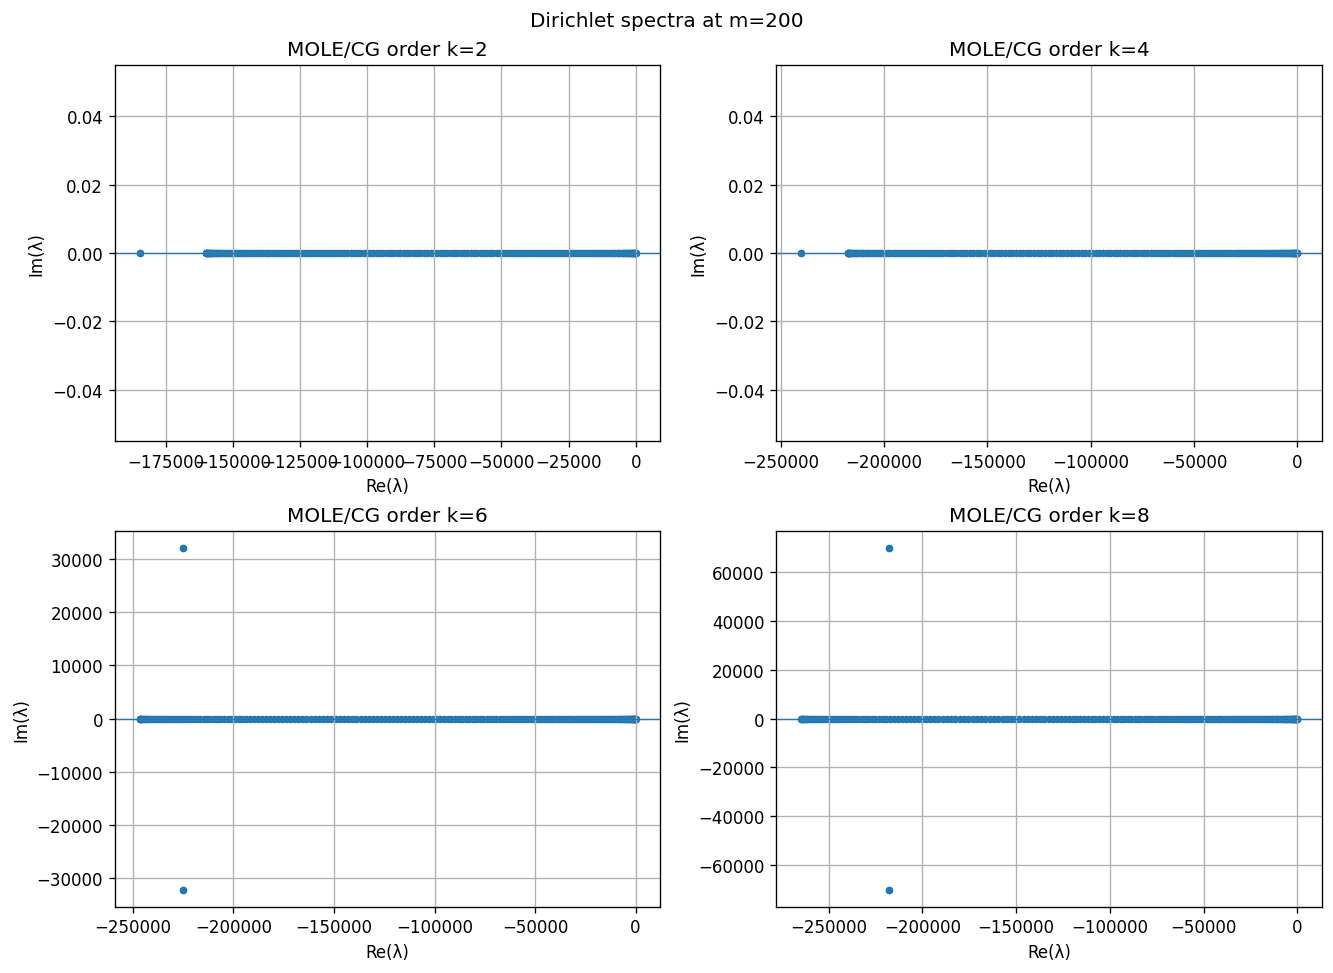

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for ax, order in zip(axes.flat, ORDERS):
    eigvals = np.linalg.eigvals(reference_ops[order].dirichlet_block)
    ax.scatter(eigvals.real, eigvals.imag, s=12)
    ax.axhline(0.0, linewidth=0.8)
    ax.set_title(f"MOLE/CG order k={order}")
    ax.set_xlabel("Re(λ)")
    ax.set_ylabel("Im(λ)")
fig.suptitle(f"Dirichlet spectra at m={CONFIG.reference_mesh}")
fig.savefig(OUTPUT_DIR / "figures" / "reference_spectra.png", bbox_inches="tight")
plt.show()


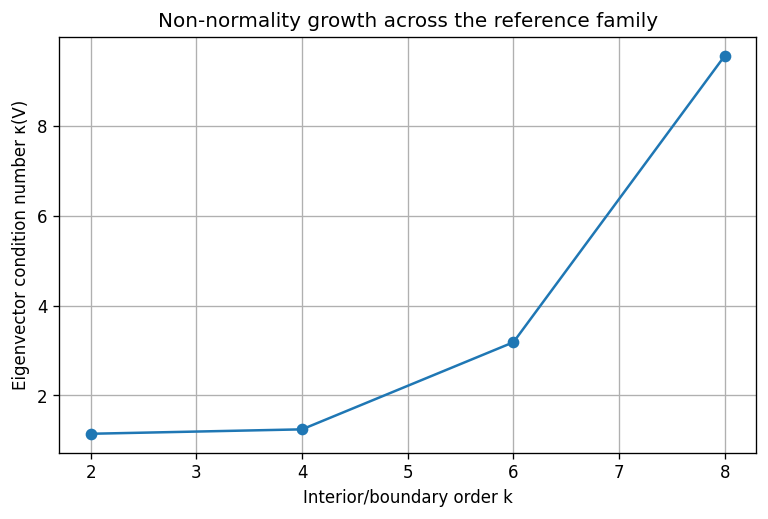

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(reference_table["order"], reference_table["eigenvector_condition_number"], marker="o")
ax.set_xlabel("Interior/boundary order k")
ax.set_ylabel("Eigenvector condition number κ(V)")
ax.set_title("Non-normality growth across the reference family")
fig.savefig(OUTPUT_DIR / "figures" / "reference_eigenvector_conditioning.png", bbox_inches="tight")
plt.show()


## 7 · Mesh refinement: conditioning and eigenvalue convergence

For every order, the notebook measures the spectral condition number and the error in the first five Dirichlet eigenvalues against \(- (n\pi)^2\). Slopes are estimated from the executed data rather than inserted as expected values. First-mode errors at high order can reach the floating-point plateau before the finest mesh; such non-monotone sequences are flagged and their rate is reported as `NaN` rather than fitted misleadingly.


In [12]:
ref_refinement_rows = []
ref_rate_rows = []
for order in ORDERS:
    hs, mean_errors, first_errors, conds = [], [], [], []
    for cells in CONFIG.convergence_meshes:
        op = build_mole_reference(order, cells)
        _, errors = first_eigenvalue_errors(op, modes=5)
        metrics = spectral_metrics(op)
        hs.append(op.grid.h)
        mean_errors.append(float(np.mean(errors)))
        first_errors.append(float(errors[0]))
        conds.append(metrics["spectral_condition_number"])
        ref_refinement_rows.append({
            "order": order,
            "cells": cells,
            "h": op.grid.h,
            "mean_first5_eigenvalue_error": float(np.mean(errors)),
            "first_eigenvalue_error": float(errors[0]),
            "spectral_condition_number": metrics["spectral_condition_number"],
            "scaled_spectral_radius": metrics["scaled_spectral_radius"],
        })
    first_diag = convergence_rate_diagnostic(hs, first_errors)
    ref_rate_rows.append({
        "order": order,
        "mean_first5_eigenvalue_rate_all_meshes": loglog_slope(hs, mean_errors),
        "first_eigenvalue_rate": first_diag["rate"],
        "first_mode_roundoff_or_plateau_limited": first_diag["roundoff_or_plateau_limited"],
        "first_mode_monotone_decrease": first_diag["monotone_decrease"],
        "first_mode_dynamic_range": first_diag["dynamic_range"],
        "condition_exponent_in_h": loglog_slope(hs, conds),
    })

reference_refinement = pd.DataFrame(ref_refinement_rows)
reference_rates = pd.DataFrame(ref_rate_rows)
reference_refinement.to_csv(OUTPUT_DIR / "tables" / "reference_refinement.csv", index=False)
reference_rates.to_csv(OUTPUT_DIR / "tables" / "reference_rates.csv", index=False)
display(reference_rates)
print("NaN first-mode rates are intentional when the error sequence is non-monotone or has insufficient dynamic range.")


,order,mean_first5_eigenvalue_rate_all_meshes,first_eigenvalue_rate,first_mode_roundoff_or_plateau_limited,first_mode_monotone_decrease,first_mode_dynamic_range,condition_exponent_in_h
0,2,1.966730,1.967514,False,True,59.755611,-1.999784
1,4,4.024866,4.054632,False,True,4595.051968,-2.000000
2,6,5.645843,NaN,True,False,6.605816,-2.001508
3,8,5.954892,NaN,True,False,7.330523,-2.001803


NaN first-mode rates are intentional when the error sequence is non-monotone or has insufficient dynamic range.


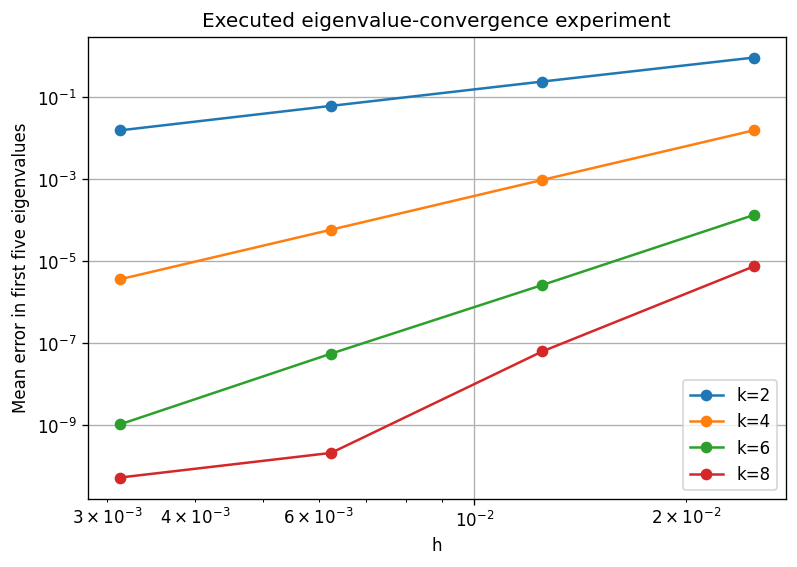

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 5.0))
for order, group in reference_refinement.groupby("order"):
    ax.loglog(group["h"], group["mean_first5_eigenvalue_error"], marker="o", label=f"k={order}")
ax.set_xlabel("h")
ax.set_ylabel("Mean error in first five eigenvalues")
ax.set_title("Executed eigenvalue-convergence experiment")
ax.legend()
fig.savefig(OUTPUT_DIR / "figures" / "reference_eigenvalue_convergence.png", bbox_inches="tight")
plt.show()


## 8 · Norm-matched dense versus boundary-supported perturbations

Each perturbation is scaled so that \(\lVert\Delta L
Vert_2=\gamma\lVert L
Vert_2\). Dense and boundary-supported perturbations therefore have the same operator-norm budget. The response is the worst nearest-neighbour eigenvalue drift, normalized by \(\lVert L
Vert_2\).


In [14]:
perturbation_frames = []
for order in ORDERS:
    op = build_mole_reference(order, CONFIG.perturbation_mesh)
    frame = perturbation_sensitivity(
        op,
        gammas=CONFIG.perturbation_gammas,
        trials=PERTURBATION_TRIALS,
        boundary_width=max(4, 2 * order),
        seed=CONFIG.random_seed + order,
    )
    perturbation_frames.append(frame)
reference_perturbations = pd.concat(perturbation_frames, ignore_index=True)
reference_perturbations.to_csv(OUTPUT_DIR / "tables" / "reference_perturbations.csv", index=False)
perturbation_summary = (
    reference_perturbations
    .groupby(["order", "gamma", "kind"], as_index=False)
    .agg(mean_drift=("relative_worst_eigenvalue_drift", "mean"),
         std_drift=("relative_worst_eigenvalue_drift", "std"),
         mean_relative_norm=("delta_relative_norm", "mean"))
)
display(perturbation_summary)


,order,gamma,kind,mean_drift,std_drift,mean_relative_norm
0,2,0.02,boundary,0.002626,0.001082,0.02
1,2,0.02,dense,0.003039,0.000451,0.02
2,2,0.08,boundary,0.009931,0.003961,0.08
3,2,0.08,dense,0.012282,0.001992,0.08
4,4,0.02,boundary,0.002575,0.000644,0.02
5,4,0.02,dense,0.003173,0.000464,0.02
6,4,0.08,boundary,0.010981,0.002631,0.08
7,4,0.08,dense,0.012955,0.002683,0.08
8,6,0.02,boundary,0.002881,0.000595,0.02
9,6,0.02,dense,0.003141,0.000552,0.02


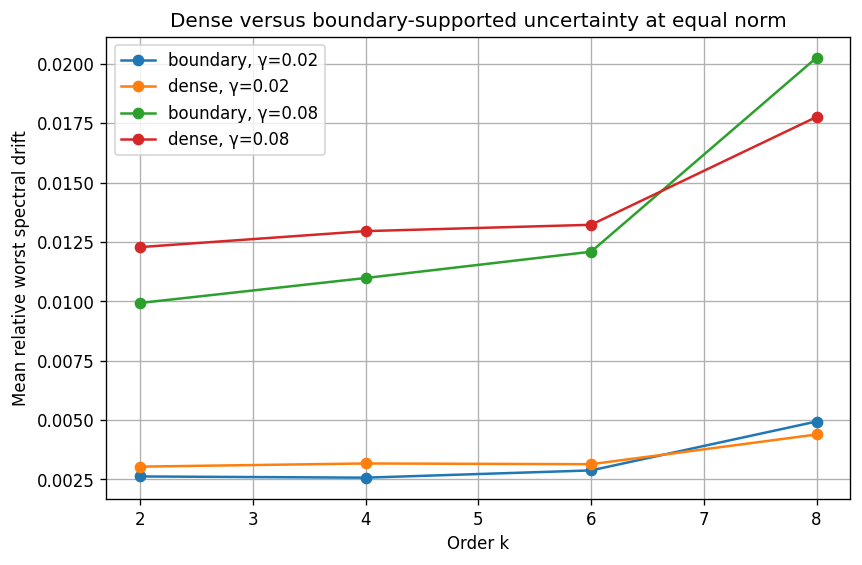

In [15]:
fig, ax = plt.subplots(figsize=(8.0, 5.0))
for (gamma, kind), group in perturbation_summary.groupby(["gamma", "kind"]):
    ax.plot(group["order"], group["mean_drift"], marker="o", label=f"{kind}, γ={gamma}")
ax.set_xlabel("Order k")
ax.set_ylabel("Mean relative worst spectral drift")
ax.set_title("Dense versus boundary-supported uncertainty at equal norm")
ax.legend()
fig.savefig(OUTPUT_DIR / "figures" / "structured_perturbation_comparison.png", bbox_inches="tight")
plt.show()


# Part II · Deterministic operator discovery

## 9 · Structural search space

The quick campaign includes six targeted feasible/near-feasible relaxations and two uniform-boundary-order stress tests. Full mode expands this into a systematic grid. A failed LP is recorded, not discarded, but is interpreted only as infeasibility within this exact template class.


In [16]:
def make_search_specs(config: ExperimentConfig) -> list[SharedTemplateSpec]:
    if config.quick_mode:
        return [
            SharedTemplateSpec(2, 1, 1, 3, config.design_meshes),
            SharedTemplateSpec(4, 2, 4, 7, config.design_meshes),
            SharedTemplateSpec(6, 3, 8, 11, config.design_meshes),
            SharedTemplateSpec(8, 4, 9, 13, tuple(max(m, 38) for m in config.design_meshes)),
            SharedTemplateSpec(6, 6, 6, 13, tuple(max(m, 40) for m in config.design_meshes)),
            SharedTemplateSpec(8, 8, 8, 17, tuple(max(m, 48) for m in config.design_meshes)),
        ]

    specs: list[SharedTemplateSpec] = []
    if config.exhaustive_structure_grid:
        # Reproduces the broad 1008-spec v3 campaign. It is intentionally opt-in:
        # most of those LPs differ only by trailing zero columns and can take a
        # long time in Colab.
        for order in ORDERS:
            boundary_orders = sorted(set([1, 2, 3, 4, order]))
            for boundary_order in (b for b in boundary_orders if b <= order):
                for rows in range(order // 2, order // 2 + 7):
                    lower = max(order + 1, rows + 2)
                    for support in range(lower, lower + 9):
                        minimum = 2 * max(support, rows + order) + 4
                        meshes = tuple(sorted(set(max(m, minimum) for m in config.design_meshes)))
                        specs.append(SharedTemplateSpec(order, boundary_order, rows, support, meshes))
    else:
        # Focused diagonal-norm campaign. For a 2p-order central stencil, p-order
        # boundary closures are the natural SBP/mimetic frontier. We search that
        # level broadly, a compact one-order-lower fallback, and a few uniform-order
        # stress tests. This retains the scientifically relevant space while avoiding
        # hundreds of LPs that collapse to identical trailing-zero families.
        for order in ORDERS:
            primary_bo = max(1, order // 2)
            for rows in range(order // 2, order // 2 + 6):
                lower = max(order + 1, rows + 2)
                for support in range(lower, lower + 5):
                    minimum = 2 * max(support, rows + order) + 4
                    meshes = tuple(sorted(set(max(m, minimum) for m in config.design_meshes)))
                    specs.append(SharedTemplateSpec(order, primary_bo, rows, support, meshes))

            fallback_bo = max(1, primary_bo - 1)
            if fallback_bo != primary_bo:
                for rows in range(order // 2, order // 2 + 3):
                    lower = max(order + 1, rows + 2)
                    for support in range(lower, lower + 3):
                        minimum = 2 * max(support, rows + order) + 4
                        meshes = tuple(sorted(set(max(m, minimum) for m in config.design_meshes)))
                        specs.append(SharedTemplateSpec(order, fallback_bo, rows, support, meshes))

            if order != primary_bo:
                stress = [
                    (max(order // 2, order - 1), max(2 * order + 1, order + 3)),
                    (order, 2 * order + 1),
                    (order + 1, 2 * order + 3),
                ]
                for rows, support in stress:
                    minimum = 2 * max(support, rows + order) + 4
                    meshes = tuple(sorted(set(max(m, minimum) for m in config.design_meshes)))
                    specs.append(SharedTemplateSpec(order, order, rows, support, meshes))

    unique = {spec.candidate_id: spec for spec in specs}
    return list(unique.values())

SEARCH_SPECS = make_search_specs(CONFIG)
print(f"Structural specifications queued: {len(SEARCH_SPECS)} "
      f"({'exhaustive' if CONFIG.exhaustive_structure_grid else 'focused'} campaign)")
pd.DataFrame([asdict(spec) | {"candidate_id": spec.candidate_id} for spec in SEARCH_SPECS])


Structural specifications queued: 159 (focused campaign)


,interior_order,boundary_order,boundary_rows,support_width,design_meshes,weight_floor,candidate_id
0,2,1,1,3,"(32, 48)",1.000000e-08,k2_b1_r1_s3
1,2,1,1,4,"(32, 48)",1.000000e-08,k2_b1_r1_s4
2,2,1,1,5,"(32, 48)",1.000000e-08,k2_b1_r1_s5
3,2,1,1,6,"(32, 48)",1.000000e-08,k2_b1_r1_s6
4,2,1,1,7,"(32, 48)",1.000000e-08,k2_b1_r1_s7
...,...,...,...,...,...,...,...
154,8,3,6,10,"(32, 48)",1.000000e-08,k8_b3_r6_s10
155,8,3,6,11,"(32, 48)",1.000000e-08,k8_b3_r6_s11
156,8,8,7,17,"(38, 48)",1.000000e-08,k8_b8_r7_s17
157,8,8,8,17,"(38, 48)",1.000000e-08,k8_b8_r8_s17


## 10 · Solve, hard-gate and transfer each candidate

A candidate is retained only if every holdout mesh satisfies the declared boundary/interior moments, both vector conservation identities, the sparse matrix identity, positive diagonal weights, a real spectrum and non-positive real part.


In [17]:
search_log = []
templates = {}
SCREEN_MESH = max(CONFIG.holdout_meshes)
for index, spec in enumerate(SEARCH_SPECS):
    started = time.perf_counter()
    try:
        template = design_shared_template(spec)
        templates[spec.candidate_id] = template
        summary = screen_candidate_evaluation(template, SCREEN_MESH)
        search_log.append({
            **summary,
            "status": "screen_pass" if summary["screen_gate_passed"] else "screen_reject",
            "runtime_seconds": time.perf_counter() - started,
            "error": None,
        })
    except Exception as exc:
        search_log.append({
            "candidate_id": spec.candidate_id, **asdict(spec),
            "status": "infeasible_or_error",
            "screen_gate_passed": False,
            "hard_gate_passed_all_holdouts": False,
            "runtime_seconds": time.perf_counter() - started,
            "error": f"{type(exc).__name__}: {exc}",
        })
    if (index + 1) % 100 == 0:
        print(f"screened {index + 1}/{len(SEARCH_SPECS)}")

search_table = pd.DataFrame(search_log)
search_table.to_csv(OUTPUT_DIR / "tables" / "structural_search_screen.csv", index=False)
print("Screen results:")
print(search_table["status"].value_counts().to_string())
display(search_table)


screened 100/159
Screen results:
status
infeasible_or_error    75
screen_pass            51
screen_reject          33


,candidate_id,interior_order,boundary_order,boundary_rows,support_width,design_meshes,weight_floor,LP_minimum_weight_margin,LP_equality_residual,screen_gate_passed,...,max_extra_low_mode_count,max_scaled_condition_number,max_q_similarity_residual,max_EGD_residual,max_mixed_frequency_pde_rms_error,D_bandwidth,G_bandwidth,status,runtime_seconds,error
0,k2_b1_r1_s3,2,1,1,3,"(32, 48)",1.000000e-08,0.5,0.000000e+00,True,...,0.0,0.405308,0.000000e+00,0.000000e+00,NaN,1.0,1.0,screen_pass,0.050128,None
1,k2_b1_r1_s4,2,1,1,4,"(32, 48)",1.000000e-08,0.5,0.000000e+00,True,...,0.0,0.405308,0.000000e+00,0.000000e+00,NaN,1.0,1.0,screen_pass,0.034082,None
2,k2_b1_r1_s5,2,1,1,5,"(32, 48)",1.000000e-08,0.5,0.000000e+00,True,...,0.0,0.405308,0.000000e+00,0.000000e+00,NaN,1.0,1.0,screen_pass,0.037014,None
3,k2_b1_r1_s6,2,1,1,6,"(32, 48)",1.000000e-08,0.5,0.000000e+00,True,...,0.0,0.405308,0.000000e+00,0.000000e+00,NaN,1.0,1.0,screen_pass,0.026843,None
4,k2_b1_r1_s7,2,1,1,7,"(32, 48)",1.000000e-08,0.5,0.000000e+00,True,...,0.0,0.405308,0.000000e+00,0.000000e+00,NaN,1.0,1.0,screen_pass,0.017460,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,k8_b3_r6_s10,8,3,6,10,"(32, 48)",1.000000e-08,0.4,5.684342e-14,False,...,0.0,3.890583,1.811402e-16,2.220446e-16,NaN,6.0,6.0,screen_reject,0.055968,None
155,k8_b3_r6_s11,8,3,6,11,"(32, 48)",1.000000e-08,0.4,5.684342e-14,False,...,0.0,3.890583,1.811402e-16,2.220446e-16,NaN,6.0,6.0,screen_reject,0.031765,None
156,k8_b8_r7_s17,8,8,7,17,"(38, 48)",1.000000e-08,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,infeasible_or_error,0.532911,RuntimeError: LP infeasible: The HiGHS status ...
157,k8_b8_r8_s17,8,8,8,17,"(38, 48)",1.000000e-08,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,infeasible_or_error,0.154600,RuntimeError: LP infeasible: The problem is in...


In [18]:
# Detailed multi-mesh verification is run only at the highest boundary order that
# survives the cheap screen for each interior order. If that level has no strict
# survivor, the code steps down one boundary order and records the frontier.
detailed_rows = []
detailed_mesh_rows = []
verified_boundary_frontier: dict[int, int] = {}
for order in ORDERS:
    screened_order = search_table[
        (search_table["interior_order"] == order) &
        (search_table["status"] == "screen_pass")
    ].copy()
    if screened_order.empty:
        raise RuntimeError(f"No screened candidate for interior order {order}.")
    promoted_level = None
    for boundary_order in sorted(screened_order["boundary_order"].dropna().astype(int).unique(), reverse=True):
        level = screened_order[screened_order["boundary_order"] == boundary_order]
        level_rows = []
        for _, screen_row in level.iterrows():
            candidate_id = screen_row["candidate_id"]
            started = time.perf_counter()
            try:
                summary, per_mesh = candidate_evaluation(templates[candidate_id], CONFIG.holdout_meshes)
                row = {**summary, "status": (
                    "strict_pass" if summary["hard_gate_passed_all_holdouts"] else "detailed_reject"
                ), "detailed_runtime_seconds": time.perf_counter() - started, "error": None}
                level_rows.append(row)
                detailed_mesh_rows.extend(per_mesh)
            except Exception as exc:
                spec = SPEC_BY_ID[candidate_id] if "SPEC_BY_ID" in globals() else next(
                    s for s in SEARCH_SPECS if s.candidate_id == candidate_id
                )
                level_rows.append({
                    "candidate_id": candidate_id, **asdict(spec),
                    "status": "detailed_error", "hard_gate_passed_all_holdouts": False,
                    "detailed_runtime_seconds": time.perf_counter() - started,
                    "error": f"{type(exc).__name__}: {exc}",
                })
        detailed_rows.extend(level_rows)
        if any(bool(row.get("hard_gate_passed_all_holdouts")) for row in level_rows):
            promoted_level = boundary_order
            break
    if promoted_level is None:
        raise RuntimeError(f"No detailed v4 survivor for interior order {order}.")
    verified_boundary_frontier[order] = promoted_level

search_detailed = pd.DataFrame(detailed_rows)
pd.DataFrame(detailed_mesh_rows).to_csv(
    OUTPUT_DIR / "tables" / "candidate_holdout_details.csv", index=False
)
search_detailed.to_csv(OUTPUT_DIR / "tables" / "structural_search_detailed.csv", index=False)
feasible_all = search_detailed[
    (search_detailed["status"] == "strict_pass") &
    (search_detailed["hard_gate_passed_all_holdouts"] == True)
].copy()
if feasible_all.empty:
    raise RuntimeError("No candidate survived the v4 algebraic, spectral-pollution and PDE gates.")

feasible_all["boundary_order_deficit"] = (
    feasible_all["interior_order"] - feasible_all["boundary_order"]
)
feasible_all = feasible_all.sort_values([
    "canonical_family_hash", "effective_support_width", "support_width",
    "boundary_rows", "candidate_id",
])
feasible_all["is_canonical_representative"] = ~feasible_all.duplicated(
    "canonical_family_hash", keep="first"
)
feasible = feasible_all[feasible_all["is_canonical_representative"]].copy()
max_feasible_boundary_order = feasible.groupby("interior_order")["boundary_order"].max()
print("Maximum strictly feasible boundary order in this diagonal-norm class:")
print(max_feasible_boundary_order.to_string())
print(f"Strictly feasible specifications: {len(feasible_all)}; distinct coefficient families: {len(feasible)}")

feasible["pareto"] = False
for order, indices in feasible.groupby("interior_order").groups.items():
    sub = feasible.loc[indices]
    mask = nondominated_mask(
        sub,
        objectives=(
            "boundary_order_deficit", "scaled_spectral_radius",
            "q_similarity_condition_bound", "max_mixed_frequency_pde_rms_error",
            "effective_support_width",
        ),
    )
    feasible.loc[sub.index, "pareto"] = mask

comparison_reference = {}
for order in ORDERS:
    comparison_reference[order] = spectral_metrics(
        build_mole_reference(order, max(CONFIG.holdout_meshes))
    )
feasible["reference_scaled_spectral_radius"] = feasible["interior_order"].map(
    lambda k: comparison_reference[int(k)]["scaled_spectral_radius"]
)
feasible["reference_eigenvector_condition_number"] = feasible["interior_order"].map(
    lambda k: comparison_reference[int(k)]["eigenvector_condition_number"]
)
feasible["delta_scaled_rho_vs_reference"] = (
    feasible["scaled_spectral_radius"] - feasible["reference_scaled_spectral_radius"]
)
feasible["novelty_status"] = "unassessed: canonical literature comparison required"

feasible_all.to_csv(OUTPUT_DIR / "tables" / "feasible_specifications_with_duplicates.csv", index=False)
feasible.to_csv(OUTPUT_DIR / "tables" / "feasible_canonical_families.csv", index=False)
json_dump(OUTPUT_DIR / "tables" / "verified_boundary_frontier.json", verified_boundary_frontier)
display(feasible.sort_values([
    "interior_order", "boundary_order_deficit", "scaled_spectral_radius",
    "q_similarity_condition_bound", "effective_support_width",
]))


Maximum strictly feasible boundary order in this diagonal-norm class:
interior_order
2    1
4    2
6    3
8    4
Strictly feasible specifications: 38; distinct coefficient families: 19


,candidate_id,interior_order,boundary_order,boundary_rows,support_width,design_meshes,weight_floor,LP_minimum_weight_margin,LP_equality_residual,hard_gate_passed_all_holdouts,...,status,detailed_runtime_seconds,error,boundary_order_deficit,is_canonical_representative,pareto,reference_scaled_spectral_radius,reference_eigenvector_condition_number,delta_scaled_rho_vs_reference,novelty_status
10,k2_b1_r3_s5,2,1,3,5,"(32, 48)",1.000000e-08,0.500000,0.000000e+00,True,...,strict_pass,0.074312,None,1,True,True,4.618802,1.146294,-0.619544,unassessed: canonical literature comparison re...
0,k2_b1_r1_s3,2,1,1,3,"(32, 48)",1.000000e-08,0.500000,0.000000e+00,True,...,strict_pass,0.029926,None,1,True,True,4.618802,1.146294,-0.618802,unassessed: canonical literature comparison re...
5,k2_b1_r2_s4,2,1,2,4,"(32, 48)",1.000000e-08,0.500000,0.000000e+00,True,...,strict_pass,0.040902,None,1,True,False,4.618802,1.146294,-0.618802,unassessed: canonical literature comparison re...
15,k2_b1_r4_s6,2,1,4,6,"(32, 48)",1.000000e-08,0.500000,2.220446e-16,True,...,strict_pass,0.068120,None,1,True,False,4.618802,1.146294,2.105951,unassessed: canonical literature comparison re...
12,k2_b1_r3_s7,2,1,3,7,"(32, 48)",1.000000e-08,0.500000,0.000000e+00,True,...,strict_pass,0.067609,None,1,True,False,4.618802,1.146294,6.185289,unassessed: canonical literature comparison re...
23,k4_b2_r5_s7,4,2,5,7,"(32, 48)",1.000000e-08,0.500000,9.853229e-16,True,...,strict_pass,0.063235,None,2,True,True,6.005126,1.231620,-0.562047,unassessed: canonical literature comparison re...
24,k4_b2_r5_s8,4,2,5,8,"(32, 48)",1.000000e-08,0.500000,3.108624e-15,True,...,strict_pass,0.113114,None,2,True,True,6.005126,1.231620,-0.562039,unassessed: canonical literature comparison re...
22,k4_b2_r4_s10,4,2,4,10,"(32, 48)",1.000000e-08,0.500000,6.661338e-16,True,...,strict_pass,0.029112,None,2,True,True,6.005126,1.231620,-0.562002,unassessed: canonical literature comparison re...
19,k4_b2_r4_s7,4,2,4,7,"(32, 48)",1.000000e-08,0.500000,8.881784e-16,True,...,strict_pass,0.032936,None,2,True,True,6.005126,1.231620,-0.561994,unassessed: canonical literature comparison re...
28,k4_b2_r6_s10,4,2,6,10,"(32, 48)",1.000000e-08,0.500000,2.553513e-15,True,...,strict_pass,0.048884,None,2,True,False,6.005126,1.231620,-0.242400,unassessed: canonical literature comparison re...


### Candidate selection policy

One representative per interior order. Candidates are ranked first by boundary-order deficit, then by scaled spectral radius, eigenvector condition number and gradient bandwidth.

The boundary-order term is not cosmetic. Ranking on the spectral radius alone selects the most compact boundary closure available, which minimises the spectral radius while destroying global convergence: in the 2026-08-17 run the resulting order-6 selection had a first-order boundary closure and converged at rate 3.4 against the reference's 6.2. Set `prefer_maximum_boundary_order=False` to recover the earlier spectral-only ranking.


In [19]:
SELECTION_KEYS = [
    "boundary_order_deficit", "rho_equivalence_bucket",
    # Inside the declared rho-equivalence band, prefer the smallest actual
    # closure first. Tiny LP-level differences in the Q bound or PDE error are
    # not meaningful enough to justify extra zero/near-zero columns.
    "effective_support_width", "boundary_rows", "support_width",
    "q_similarity_condition_bound", "max_mixed_frequency_pde_rms_error",
    "candidate_id",
]


def ordered_promotion_candidates(group: pd.DataFrame) -> pd.DataFrame:
    work = group.copy()
    if CONFIG.prefer_maximum_boundary_order:
        work = work[work["boundary_order"] == work["boundary_order"].max()].copy()
    minimum_rho = float(work["scaled_spectral_radius"].min())
    threshold = minimum_rho * (1.0 + CONFIG.spectral_radius_equivalence_relative_tolerance)
    work["rho_equivalence_bucket"] = np.where(
        work["scaled_spectral_radius"] <= threshold, 0, 1
    )
    # Within a numerically indistinguishable spectral-radius band, prefer the
    # better-conditioned, more accurate and smaller closure—not a tiny rho gain.
    return work.sort_values(SELECTION_KEYS).reset_index(drop=True)

preliminary_rows = []
preliminary_templates = {}
promotion_orders: dict[int, list[str]] = {}
for order, group in feasible.groupby("interior_order"):
    ranked = ordered_promotion_candidates(group)
    row = ranked.iloc[0]
    preliminary_rows.append(row)
    preliminary_templates[int(order)] = templates[row["candidate_id"]]
    promotion_orders[int(order)] = ranked["candidate_id"].head(
        CONFIG.exact_candidates_per_order
    ).tolist()

preliminary_selected_candidates = pd.DataFrame(preliminary_rows).reset_index(drop=True)
preliminary_selected_candidates.to_csv(
    OUTPUT_DIR / "tables" / "preliminary_selected_candidates.csv", index=False
)
json_dump(OUTPUT_DIR / "tables" / "selection_policy.json", {
    "hard_gates": {
        "first_mode_relative_tolerance": CONFIG.first_mode_relative_tolerance,
        "max_first_modes_relative_tolerance": CONFIG.max_first_modes_relative_tolerance,
        "extra_low_mode_tolerance": CONFIG.extra_low_mode_tolerance,
        "scaled_condition_tolerance": CONFIG.scaled_condition_tolerance,
        "low_frequency_pde_tolerance": CONFIG.low_frequency_pde_tolerance,
        "mixed_frequency_pde_tolerance": CONFIG.mixed_frequency_pde_tolerance,
    },
    "ranking_keys": SELECTION_KEYS,
    "spectral_radius_equivalence_relative_tolerance": CONFIG.spectral_radius_equivalence_relative_tolerance,
    "prefer_maximum_boundary_order": CONFIG.prefer_maximum_boundary_order,
    "max_feasible_boundary_order": {int(k): int(v) for k, v in max_feasible_boundary_order.items()},
    "exact_certificate_required_for_final_promotion": True,
    "promotion_order": promotion_orders,
})
display(preliminary_selected_candidates[[
    "candidate_id", "interior_order", "boundary_order", "boundary_rows",
    "support_width", "effective_support_width", "scaled_spectral_radius",
    "q_similarity_condition_bound", "max_first_modes_relative_error",
    "max_extra_low_mode_count", "max_mixed_frequency_pde_rms_error",
]])

# These names are finalized after coupled exact reconstruction in Section 11.
selected_candidates = preliminary_selected_candidates.copy()
selected_templates = dict(preliminary_templates)


,candidate_id,interior_order,boundary_order,boundary_rows,support_width,effective_support_width,scaled_spectral_radius,q_similarity_condition_bound,max_first_modes_relative_error,max_extra_low_mode_count,max_mixed_frequency_pde_rms_error
0,k2_b1_r1_s3,2,1,1,3,2,4.000000,1.000000,0.005010,0,0.000714
1,k4_b2_r4_s7,4,2,4,7,6,5.443132,1.306094,0.000203,0,0.000459
2,k6_b3_r8_s11,6,3,8,11,11,8.266454,2.057394,0.000337,0,0.000760
3,k8_b4_r9_s13,8,4,9,13,13,6.615902,2.059491,0.000011,0,0.000023


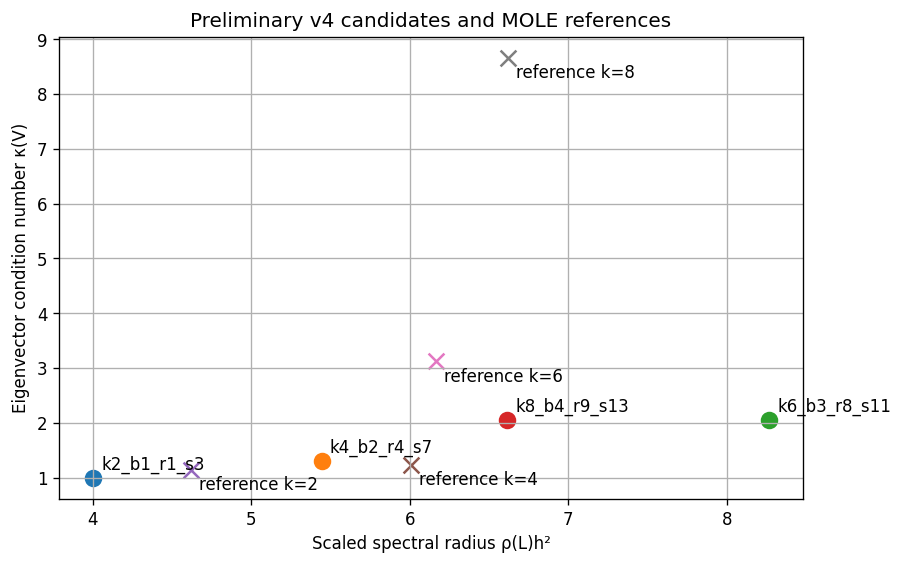

In [20]:
fig, ax = plt.subplots(figsize=(8.0, 5.0))
for _, row in selected_candidates.iterrows():
    ax.scatter(row["scaled_spectral_radius"], row["eigenvector_condition_number"], s=90)
    ax.annotate(row["candidate_id"],
                (row["scaled_spectral_radius"], row["eigenvector_condition_number"]),
                xytext=(5, 5), textcoords="offset points")
for order in ORDERS:
    ref = comparison_reference[order]
    ax.scatter(ref["scaled_spectral_radius"], ref["eigenvector_condition_number"], marker="x", s=90)
    ax.annotate(f"reference k={order}",
                (ref["scaled_spectral_radius"], ref["eigenvector_condition_number"]),
                xytext=(5, -12), textcoords="offset points")
ax.set_xlabel("Scaled spectral radius ρ(L)h²")
ax.set_ylabel("Eigenvector condition number κ(V)")
ax.set_title("Preliminary v4 candidates and MOLE references")
fig.savefig(OUTPUT_DIR / "figures" / "preliminary_candidate_reference_pareto.png", bbox_inches="tight")
plt.show()


## 11 · Rational reconstruction and exact template checks

Each feasible template is reconstructed over a ladder of denominator caps and re-verified exactly. `reconstruction_status` separates a genuine exactness certificate from a candidate whose floating-point LP vertex simply does not determine its rational value precisely enough; the latter needs an exact solve of the active constraint set and must not be reported as exact.

An exact certificate here is an algebraic property of the template, independent of the mesh. It is not a novelty claim.


In [21]:
class RationalEquationBuilder:
    def __init__(self) -> None:
        self.names: list[str] = []
        self.index: dict[str, int] = {}
        self.rows: list[dict[int, Fraction]] = []
        self.rhs: list[Fraction] = []
        self.labels: list[str] = []

    def var(self, name: str) -> int:
        if name not in self.index:
            self.index[name] = len(self.names)
            self.names.append(name)
        return self.index[name]

    def add(self, terms: dict[str, Fraction | int], rhs: Fraction | int = 0, label: str = "") -> None:
        row: dict[int, Fraction] = {}
        for name, value in terms.items():
            value = Fraction(value)
            if value:
                j = self.var(name)
                row[j] = row.get(j, Fraction(0)) + value
        self.rows.append(row)
        self.rhs.append(Fraction(rhs))
        self.labels.append(label)

    def float_matrix(self) -> tuple[np.ndarray, np.ndarray]:
        A = np.zeros((len(self.rows), len(self.names)), dtype=float)
        for i, row in enumerate(self.rows):
            for j, value in row.items():
                A[i, j] = float(value)
        return A, np.asarray([float(x) for x in self.rhs], dtype=float)

    def sympy_augmented_row(self, i: int) -> list[sp.Rational]:
        return [
            sp.Rational(
                self.rows[i].get(j, Fraction(0)).numerator,
                self.rows[i].get(j, Fraction(0)).denominator,
            )
            for j in range(len(self.names))
        ] + [sp.Rational(self.rhs[i].numerator, self.rhs[i].denominator)]


def build_exact_affine_system(spec: SharedTemplateSpec):
    k, bo, r, s = spec.interior_order, spec.boundary_order, spec.boundary_rows, spec.support_width
    eb = RationalEquationBuilder()
    qvars = {0: "q_0"}
    eb.var("q_0")
    eb.add({"q_0": 1}, Fraction(1, 2), "endpoint_scalar_weight")
    for i in range(1, r + 1):
        qvars[i] = f"q_{i}"; eb.var(qvars[i])
    pvars = {j: f"p_{j}" for j in range(r)}
    for name in pvars.values(): eb.var(name)
    Avars = {(i, j): f"A_{i}_{j}" for i in range(1, r + 1) for j in range(s)}
    Cvars = {(j, i): f"C_{j}_{i}" for j in range(r) for i in range(s)}
    for name in [*Avars.values(), *Cvars.values()]: eb.var(name)
    w = CENTRAL_DERIVATIVE_FRACTIONS[k]

    for m in spec.design_meshes:
        ns, nv = m + 2, m + 1
        xs = [Fraction(0)] + [Fraction(2 * i + 1, 2) for i in range(m)] + [Fraction(m)]
        xv = [Fraction(i) for i in range(m + 1)]

        def A_expr(i: int, j: int):
            if i in (0, ns - 1): return {}, Fraction(0)
            if 1 <= i <= r and 0 <= j < s: return {Avars[i, j]: Fraction(1)}, Fraction(0)
            mi, mj = ns - 1 - i, nv - 1 - j
            if 1 <= mi <= r and 0 <= mj < s: return {Avars[mi, mj]: Fraction(-1)}, Fraction(0)
            if r < i < ns - 1 - r:
                start = i - k // 2
                if start <= j < start + k: return {}, w[j - start]
            return {}, Fraction(0)

        def C_expr(j: int, i: int):
            if 0 <= j < r and 0 <= i < s: return {Cvars[j, i]: Fraction(1)}, Fraction(0)
            mj, mi = nv - 1 - j, ns - 1 - i
            if 0 <= mj < r and 0 <= mi < s: return {Cvars[mj, mi]: Fraction(-1)}, Fraction(0)
            if r <= j < nv - r:
                start = j - k // 2 + 1
                if start <= i < start + k: return {}, w[i - start]
            return {}, Fraction(0)

        for i in range(ns):
            for j in range(nv):
                at, ac = A_expr(i, j); ct, cc = C_expr(j, i)
                rhs = Fraction(-1) if (i, j) == (0, 0) else (
                    Fraction(1) if (i, j) == (ns - 1, nv - 1) else Fraction(0)
                )
                if at or ct or ac or cc or rhs:
                    terms = dict(at)
                    for name, value in ct.items():
                        terms[name] = terms.get(name, Fraction(0)) + value
                    eb.add(terms, rhs - ac - cc, f"EGD_m{m}_{i}_{j}")

        for i in range(1, r + 1):
            for degree in range(bo + 1):
                terms = {Avars[i, j]: (xv[j] - xs[i]) ** degree for j in range(s)}
                if degree == 1:
                    terms[qvars[i]] = terms.get(qvars[i], Fraction(0)) - 1
                eb.add(terms, 0, f"Dmoment_m{m}_{i}_{degree}")
        for j in range(r):
            for degree in range(bo + 1):
                terms = {Cvars[j, i]: (xs[i] - xv[j]) ** degree for i in range(s)}
                if degree == 1:
                    terms[pvars[j]] = terms.get(pvars[j], Fraction(0)) - 1
                eb.add(terms, 0, f"Gmoment_m{m}_{j}_{degree}")
    return eb, qvars, pvars, Avars, Cvars


def template_float_vector(template, eb, qvars, pvars, Avars, Cvars) -> np.ndarray:
    r, s = template.spec.boundary_rows, template.spec.support_width
    values: dict[str, float] = {}
    for i, x in enumerate(template.qbar_left): values[qvars[i]] = float(x)
    for j, x in enumerate(template.pbar_left): values[pvars[j]] = float(x)
    for i in range(1, r + 1):
        for j in range(s): values[Avars[i, j]] = float(template.A_left[i - 1, j])
    for j in range(r):
        for i in range(s): values[Cvars[j, i]] = float(template.C_left[j, i])
    return np.asarray([values[name] for name in eb.names], dtype=float)


def rational_pair(value: sp.Rational | Fraction | int) -> dict[str, int]:
    value = sp.Rational(value)
    return {"numerator": int(value.p), "denominator": int(value.q)}


def coupled_exact_reconstruction(template: SharedTemplate, dyadic_power: int) -> dict[str, Any]:
    eb, qvars, pvars, Avars, Cvars = build_exact_affine_system(template.spec)
    A, b = eb.float_matrix()
    x0 = template_float_vector(template, eb, qvars, pvars, Avars, Cvars)
    rank = int(np.linalg.matrix_rank(A))
    _, _, pivot_rows = qr(A.T, pivoting=True, mode="economic")
    independent = [int(i) for i in pivot_rows[:rank]]
    exact_matrix = sp.Matrix([eb.sympy_augmented_row(i) for i in independent])
    rref, pivot_columns = exact_matrix.rref()
    n = len(eb.names)
    if n in pivot_columns:
        raise RuntimeError("Exact affine system is inconsistent.")
    pivot_variables = [int(p) for p in pivot_columns if p < n]
    free_variables = [j for j in range(n) if j not in pivot_variables]
    pivot_row = {p: i for i, p in enumerate(pivot_variables)}

    denominator = 2 ** int(dyadic_power)
    exact_x: list[sp.Rational | None] = [None] * n
    for j in free_variables:
        exact_x[j] = sp.Rational(round(float(x0[j]) * denominator), denominator)
    for p in pivot_variables:
        row = pivot_row[p]
        value = rref[row, n]
        for j in free_variables:
            if rref[row, j]: value -= rref[row, j] * exact_x[j]
        exact_x[p] = sp.cancel(value)

    failures = []
    for i, row in enumerate(eb.rows):
        lhs = sum(sp.Rational(v.numerator, v.denominator) * exact_x[j] for j, v in row.items())
        rhs = sp.Rational(eb.rhs[i].numerator, eb.rhs[i].denominator)
        residual = sp.cancel(lhs - rhs)
        if residual != 0:
            failures.append({"row": i, "label": eb.labels[i], "residual": str(residual)})
            if len(failures) >= 10: break

    values = {name: float(exact_x[i]) for i, name in enumerate(eb.names)}
    r, s = template.spec.boundary_rows, template.spec.support_width
    reconstructed = SharedTemplate(
        spec=template.spec,
        qbar_left=np.asarray([values[qvars[i]] for i in range(r + 1)]),
        pbar_left=np.asarray([values[pvars[j]] for j in range(r)]),
        A_left=np.asarray([[values[Avars[i, j]] for j in range(s)] for i in range(1, r + 1)]),
        C_left=np.asarray([[values[Cvars[j, i]] for i in range(s)] for j in range(r)]),
        central_weights=np.asarray([float(x) for x in CENTRAL_DERIVATIVE_FRACTIONS[template.spec.interior_order]]),
        minimum_weight_margin=min(
            values[name] for name in [*qvars.values(), *pvars.values()]
        ),
        equality_residual=0.0,
    )
    summary, per_mesh = candidate_evaluation(reconstructed, CONFIG.holdout_meshes)
    exact_positive = all(exact_x[eb.index[name]] > 0 for name in [*qvars.values(), *pvars.values()])
    exact_equations = not failures
    exact_pass = bool(exact_equations and exact_positive and summary["hard_gate_passed_all_holdouts"])
    max_displacement = float(np.max(np.abs(np.asarray([float(x) for x in exact_x]) - x0)))

    def matrix_pairs(rows):
        return [[rational_pair(x) for x in row] for row in rows]

    q_exact = [exact_x[eb.index[qvars[i]]] for i in range(r + 1)]
    p_exact = [exact_x[eb.index[pvars[j]]] for j in range(r)]
    A_exact = [[exact_x[eb.index[Avars[i, j]]] for j in range(s)] for i in range(1, r + 1)]
    C_exact = [[exact_x[eb.index[Cvars[j, i]]] for i in range(s)] for j in range(r)]
    return {
        "candidate_id": template.spec.candidate_id,
        "method": "exact affine RREF with dyadic free coordinates",
        "dyadic_power": int(dyadic_power),
        "free_variable_denominator": int(denominator),
        "equation_count": len(eb.rows), "variable_count": n,
        "rank": rank, "free_variable_count": len(free_variables),
        "exact_extended_gauss": exact_equations,
        "exact_boundary_moments": exact_equations,
        "exact_central_moments": True,
        "exact_positive_weights": bool(exact_positive),
        "numerical_unseen_mesh_pass": bool(summary["hard_gate_passed_all_holdouts"]),
        "exact_certificate_pass": exact_pass,
        "maximum_coefficient_displacement": max_displacement,
        "failed_exact_rows": failures,
        "verification_cells": list(CONFIG.holdout_meshes),
        "verification_mesh_is_unseen": not any(m in template.spec.design_meshes for m in CONFIG.holdout_meshes),
        "qbar_left": [rational_pair(x) for x in q_exact],
        "pbar_left": [rational_pair(x) for x in p_exact],
        "A_left": matrix_pairs(A_exact), "C_left": matrix_pairs(C_exact),
        "central_weights": [rational_pair(sp.Rational(x.numerator, x.denominator))
                            for x in CENTRAL_DERIVATIVE_FRACTIONS[template.spec.interior_order]],
        "numerical_summary": summary,
        "numerical_per_mesh": per_mesh,
        "reconstructed_template": reconstructed,
    }


def exactify_candidate(template: SharedTemplate) -> dict[str, Any]:
    attempts = []
    passing = []
    last = None
    for power in CONFIG.exact_dyadic_powers:
        result = coupled_exact_reconstruction(template, power)
        last = result
        attempts.append({
            "dyadic_power": power,
            "exact_certificate_pass": result["exact_certificate_pass"],
            "maximum_coefficient_displacement": result["maximum_coefficient_displacement"],
            "numerical_unseen_mesh_pass": result["numerical_unseen_mesh_pass"],
        })
        if result["exact_certificate_pass"]:
            passing.append(result)
            if result["maximum_coefficient_displacement"] <= CONFIG.exact_reconstruction_displacement_tolerance:
                result["reconstruction_status"] = "exact_with_close_affine_reconstruction"
                result["dyadic_ladder"] = attempts
                return result
    if passing:
        best = min(passing, key=lambda x: x["maximum_coefficient_displacement"])
        best["reconstruction_status"] = (
            "exact_but_displacement_above_preferred_tolerance"
        )
        best["dyadic_ladder"] = attempts
        return best
    last["reconstruction_status"] = "failed_exact_or_numerical_gate"
    last["dyadic_ladder"] = attempts
    return last

certificate_records = []
exact_certificates: dict[str, dict[str, Any]] = {}
selected_templates = {}
selected_rows = []

for order in ORDERS:
    promoted = None
    for candidate_id in promotion_orders.get(order, []):
        certificate = exactify_candidate(templates[candidate_id])
        reconstructed_template = certificate.pop("reconstructed_template")
        exact_certificates[candidate_id] = certificate
        certificate_records.append({
            "candidate_id": candidate_id,
            "interior_order": order,
            "dyadic_power": certificate["dyadic_power"],
            "equation_count": certificate["equation_count"],
            "variable_count": certificate["variable_count"],
            "rank": certificate["rank"],
            "free_variable_count": certificate["free_variable_count"],
            "exact_extended_gauss": certificate["exact_extended_gauss"],
            "exact_boundary_moments": certificate["exact_boundary_moments"],
            "exact_positive_weights": certificate["exact_positive_weights"],
            "numerical_unseen_mesh_pass": certificate["numerical_unseen_mesh_pass"],
            "exact_certificate_pass": certificate["exact_certificate_pass"],
            "maximum_coefficient_displacement": certificate["maximum_coefficient_displacement"],
            "reconstruction_status": certificate["reconstruction_status"],
        })
        json_dump(OUTPUT_DIR / "certificates" / f"{candidate_id}.json", certificate)
        if certificate["exact_certificate_pass"]:
            summary, _ = candidate_evaluation(reconstructed_template, CONFIG.holdout_meshes)
            row = feasible.loc[feasible["candidate_id"] == candidate_id].iloc[0].to_dict()
            row.update(summary)
            row["exact_certificate_pass"] = True
            row["exact_dyadic_power"] = certificate["dyadic_power"]
            row["maximum_coefficient_displacement"] = certificate["maximum_coefficient_displacement"]
            selected_templates[order] = reconstructed_template
            templates[candidate_id] = reconstructed_template
            selected_rows.append(row)
            promoted = candidate_id
            break
    if promoted is None:
        raise RuntimeError(f"No exact-certified v4 candidate could be promoted for order {order}.")

selected_candidates = pd.DataFrame(selected_rows).sort_values("interior_order").reset_index(drop=True)
certificate_table = pd.DataFrame(certificate_records)
certificate_table.to_csv(OUTPUT_DIR / "tables" / "exact_certificates_attempted.csv", index=False)
selected_candidates.to_csv(OUTPUT_DIR / "tables" / "selected_candidates.csv", index=False)
print("Final exact-certified closed-grid candidates:")
display(selected_candidates[[
    "candidate_id", "interior_order", "boundary_order", "boundary_rows",
    "support_width", "effective_support_width", "scaled_spectral_radius",
    "q_similarity_condition_bound", "max_first_modes_relative_error",
    "max_extra_low_mode_count", "max_mixed_frequency_pde_rms_error",
    "exact_dyadic_power", "maximum_coefficient_displacement",
]])


Final exact-certified closed-grid candidates:


,candidate_id,interior_order,boundary_order,boundary_rows,support_width,effective_support_width,scaled_spectral_radius,q_similarity_condition_bound,max_first_modes_relative_error,max_extra_low_mode_count,max_mixed_frequency_pde_rms_error,exact_dyadic_power,maximum_coefficient_displacement
0,k2_b1_r1_s3,2,1,1,3,2,4.000000,1.000000,0.005010,0,0.000714,28,0.000000e+00
1,k4_b2_r4_s7,4,2,4,7,6,5.443132,1.306094,0.000203,0,0.000459,28,3.725290e-09
2,k6_b3_r8_s11,6,3,8,11,11,8.266454,2.057394,0.000337,0,0.000760,40,1.141448e-09
3,k8_b4_r9_s13,8,4,9,13,13,6.615902,2.059491,0.000011,0,0.000023,44,1.313788e-09


In [22]:
def pair_string(pair: dict[str, int]) -> str:
    n, d = pair["numerator"], pair["denominator"]
    return str(n) if d == 1 else f"{n}/{d}"

for order in (6, 8):
    if order not in selected_templates:
        continue
    candidate_id = selected_templates[order].spec.candidate_id
    cert = exact_certificates[candidate_id]
    print(f"\nExact reconstructed template: {candidate_id}")
    print("qbar_left =", [pair_string(x) for x in cert["qbar_left"]])
    print("pbar_left =", [pair_string(x) for x in cert["pbar_left"]])
    display(pd.DataFrame([[pair_string(x) for x in row] for row in cert["A_left"]]))
    display(pd.DataFrame([[pair_string(x) for x in row] for row in cert["C_left"]]))



Exact reconstructed template: k6_b3_r8_s11
qbar_left = ['1/2', '9665061213809416360397/10409917674252486574080', '15229685459768721862247/10409917674252486574080', '1040991767672844590155/2081983534850497314816', '5204958835927721317789/10409917674252486574080', '22031916041229824447443/10409917674252486574080', '1040991767407257561413/2081983534850497314816', '225793135671727/246702921482240', '74446414534353/69131793596416']
pbar_left = ['379630287740686579/689855379340787712', '1149758965677199249/2299517931135959040', '1939899708516764701/1149758965567979520', '7558059994566863843/6898553793407877120', '191626494249992753/383252988522659840', '1708292421621/1786706395136', '109530952340619/82119774699520', '216349727804227/246702921482240']


,0,1,2,3,4,5,6,7,8,9,10
0,-196613160839028618118963/24983802418205967777...,40896105148133201190509/83279341394019892592640,16565160076998673490107/41639670697009946296320,-191429362995058457107/124919012091029838888960,-1267978241496607481/9198071724543836160,121472593323/3573412790272,-4658676774637/1313916395192320,13828672209747/1973623371857920,0,0,0
1,-9671859481160255075387/31229753022757459722240,-4433853824115798441143/9253260154891099176960,5174999534244195875231/9253260154891099176960,-11099557097341/49967604836411935555584,1601674418642130179/6132047816362557440,3/1786706395136,-1943/656958197596160,-31176129919983/986811685928960,0,0,0
2,1040645789147481519707/19218309552466129059840,-520495870307650327411/41639670697009946296320,-17295189557984513869781/20819835348504973148160,230019825871436690346811/249838024182059677777920,-477076199/3066023908181278720,-2381374570195/14293651161088,3407/1313916395192320,51787627842631/1480217528893440,0,0,0
3,8341281085352136841/4804577388116532264960,-62771214436193/83279341394019892592640,19011810223595/16655868278803978518528,-128388984812675992953697/24983802418205967777...,9485511467417436259/18396143449087672320,0,-954437177/274877906944,0,0,0,0
4,8798885790425873486317/249838024182059677777920,2028932016289/3469972558084162191360,-5179886597419/6939945116168324382720,-10947013145881021679407/19218309552466129059840,-135025261729/137438953472,1531114707847/1099511627776,85458500405/1099511627776,25601408265/549755813888,0,0,0
5,-16746759082952160407/1921830955246612905984,-1267455944311/8327934139401989259264,3004587992791/16655868278803978518528,-37149997903/522673690757447024640,363398986983/1099511627776,-1443903615203/1099511627776,82504757695/68719476736,-235144354685/1099511627776,3/640,0,0
6,101301790765043/1973623371857920,-6789/1973623371857920,-886843915372607/2960435057786880,146974662191/549755813888,33419589873/274877906944,0,-1392598182099/1099511627776,1304339429445/1099511627776,-25/384,3/640,0
7,-153697899846317/4147907615784960,164599508623/276527174385664,95782834438685/553054348771328,-442321973/4294967296,-119429866195/1099511627776,58595384039/1099511627776,-33128837/549755813888,-1198262140989/1099511627776,75/64,-25/384,3/640


,0,1,2,3,4,5,6,7,8,9,10
0,-1,196613160839028618118963/249838024182059677777920,9671859481160255075387/31229753022757459722240,-1040645789147481519707/19218309552466129059840,-8341281085352136841/4804577388116532264960,-8798885790425873486317/249838024182059677777920,16746759082952160407/1921830955246612905984,-101301790765043/1973623371857920,153697899846317/4147907615784960,0,0
1,0,-40896105148133201190509/83279341394019892592640,4433853824115798441143/9253260154891099176960,520495870307650327411/41639670697009946296320,62771214436193/83279341394019892592640,-2028932016289/3469972558084162191360,1267455944311/8327934139401989259264,6789/1973623371857920,-164599508623/276527174385664,0,0
2,0,-16565160076998673490107/41639670697009946296320,-5174999534244195875231/9253260154891099176960,17295189557984513869781/20819835348504973148160,-19011810223595/16655868278803978518528,5179886597419/6939945116168324382720,-3004587992791/16655868278803978518528,886843915372607/2960435057786880,-95782834438685/553054348771328,0,0
3,0,191429362995058457107/124919012091029838888960,11099557097341/49967604836411935555584,-230019825871436690346811/24983802418205967777...,128388984812675992953697/249838024182059677777920,10947013145881021679407/19218309552466129059840,37149997903/522673690757447024640,-146974662191/549755813888,442321973/4294967296,0,0
4,0,1267978241496607481/9198071724543836160,-1601674418642130179/6132047816362557440,477076199/3066023908181278720,-9485511467417436259/18396143449087672320,135025261729/137438953472,-363398986983/1099511627776,-33419589873/274877906944,119429866195/1099511627776,0,0
5,0,-121472593323/3573412790272,-3/1786706395136,2381374570195/14293651161088,0,-1531114707847/1099511627776,1443903615203/1099511627776,0,-58595384039/1099511627776,0,0
6,0,4658676774637/1313916395192320,1943/656958197596160,-3407/1313916395192320,954437177/274877906944,-85458500405/1099511627776,-82504757695/68719476736,1392598182099/1099511627776,33128837/549755813888,3/640,0
7,0,-13828672209747/1973623371857920,31176129919983/986811685928960,-51787627842631/1480217528893440,0,-25601408265/549755813888,235144354685/1099511627776,-1304339429445/1099511627776,1198262140989/1099511627776,-25/384,3/640



Exact reconstructed template: k8_b4_r9_s13
qbar_left = ['1/2', '79614369121079004313391/68791173106108465152000', '11849717791633009072597/17197793276527116288000', '205509048591287025301/204735634244370432000', '762676608767408674111/491365522186489036800', '359625453544511022793/982731044372978073600', '963247655716324594571/818942536977481728000', '1419934734954080350027/1228413805466222592000', '14998846229978761169671/17197793276527116288000', '2643339820125183/2572582331088896']
pbar_left = ['1793195978743161769/4900179727613952000', '578065186632378521/535957157707776000', '11988423456542845367/8575314523324416000', '5811283264574027/15880212080230400', '3916254075356250133/3430125809329766400', '1655281409114959151/1071914315415552000', '3138092962792052339/8575314523324416000', '105257932187847/81604378624000', '508046291449267/534912406913024']


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-2924223904031423482657877/2641581047274565061...,13622353073469617116722413/1320790523637282530...,58017347920548899721397/880527015758188353945600,108230622254388451611581/264158104727456506183...,-250730774760710661576107/13207905236372825309...,-45299969010517863091/3292920776956575744000,-7956062192965451519/1097640258985525248000,438718173860429/41781441855488000,-18767235098989/10698248138260480,0,0,0,0
1,118915990757163765942277/165098815454660316364...,-55964849245974481436179/58701801050545890263040,379749386538168102276817/366886256565911814144000,-1105014617820756219155707/6603952618186412654...,46744476703/219528051797105049600,20296760761/1097640258985525248000,28528394661830360291/1646460388478287872000,47/163208757248000,-63555320961197/17117197021216768,0,0,0,0
2,232882996148835469/18294004316425420800,-14132537571811684401799/157236967099676491776000,-1434933241802709882461/1996659899678431641600,6809681819762555279659/11647182748124184576000,151527177858164185384147/628947868398705967104000,-17314679/457350107910635520,14991551041/365880086328508416000,-1074976809511081/20890720927744000,371260815562337/17117197021216768,0,0,0,0
3,77929081110548278882529/1886843605196117901312000,-1198622264909/1986151163364334632960,-305675384037448257506783/62894786839870596710...,-80103236379831598239599/188684360519611790131200,38275620973340848618429/75473744207844716052480,618861493857894100931/1646460388478287872000,-7733642597/219528051797105049600,51741/146235046494208000,-353481186056917/25675795531825152,0,0,0,0
4,-6282272601989239425043/1886843605196117901312000,105927788828149/628947868398705967104000,833379630170289807349/20964928946623532236800,-2850534365389876163639/47171090129902947532800,-49875823658228431634111/125789573679741193420800,547885113321286609457/1097640258985525248000,-94680253475302118641/823230194239143936000,377509782143/8796093022208,-57572736323/8796093022208,0,0,0,0
5,-1537687343158314847909/104824644733117661184000,8479522656766084913629/628947868398705967104000,2428773714781097541251/34941548244372553728000,2503950800633/20964928946623532236800,-275460868027649368421683/62894786839870596710...,-7329036826147/17592186044416,335843279547/549755813888,918882364013/4398046511104,-578283676513/17592186044416,-5/7168,0,0,0
6,-3826994573582676681221/943421802598058950656000,-49788274789793/943421802598058950656000,6499596037313/69883096488745107456000,32402339422726787063201/943421802598058950656000,421639899432347962969/3972302326728669265920,-4274268777661/8796093022208,-10068811624057/17592186044416,7836317626109/8796093022208,388450032365/17592186044416,49/5120,-5/7168,0,0
7,7996904477244386309/27806116287100684861440,5893488331991/1100658769697735442432000,-13344692566271/1467545026263647256576000,-18631766548514877703963/660395261818641265459...,-63344454431/31673633660366487552000,0,1326227813439/17592186044416,-9445344356471/8796093022208,2356995708373/2199023255552,-245/3072,49/5120,-5/7168,0
8,55705661200391/20580658648711168,-990964258422343/617419759461335040,-910956937982461/164645269189689344,-801493520099159/164645269189689344,-6584188121/8796093022208,363017607957/8796093022208,-170691083631/17592186044416,-335883989317/17592186044416,-4960276934913/4398046511104,1225/1024,-245/3072,49/5120,-5/7168


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-1,2924223904031423482657877/26415810472745650618...,-118915990757163765942277/16509881545466031636...,-232882996148835469/18294004316425420800,-77929081110548278882529/188684360519611790131...,6282272601989239425043/1886843605196117901312000,1537687343158314847909/104824644733117661184000,3826994573582676681221/943421802598058950656000,-7996904477244386309/27806116287100684861440,-55705661200391/20580658648711168,0,0,0
1,0,-13622353073469617116722413/132079052363728253...,55964849245974481436179/58701801050545890263040,14132537571811684401799/157236967099676491776000,1198622264909/1986151163364334632960,-105927788828149/628947868398705967104000,-8479522656766084913629/628947868398705967104000,49788274789793/943421802598058950656000,-5893488331991/1100658769697735442432000,990964258422343/617419759461335040,0,0,0
2,0,-58017347920548899721397/880527015758188353945600,-379749386538168102276817/36688625656591181414...,1434933241802709882461/1996659899678431641600,305675384037448257506783/628947868398705967104000,-833379630170289807349/20964928946623532236800,-2428773714781097541251/34941548244372553728000,-6499596037313/69883096488745107456000,13344692566271/1467545026263647256576000,910956937982461/164645269189689344,0,0,0
3,0,-108230622254388451611581/26415810472745650618...,1105014617820756219155707/66039526181864126545...,-6809681819762555279659/11647182748124184576000,80103236379831598239599/188684360519611790131200,2850534365389876163639/47171090129902947532800,-2503950800633/20964928946623532236800,-32402339422726787063201/943421802598058950656000,18631766548514877703963/6603952618186412654592000,801493520099159/164645269189689344,0,0,0
4,0,250730774760710661576107/132079052363728253091...,-46744476703/219528051797105049600,-151527177858164185384147/62894786839870596710...,-38275620973340848618429/75473744207844716052480,49875823658228431634111/125789573679741193420800,275460868027649368421683/628947868398705967104000,-421639899432347962969/3972302326728669265920,63344454431/31673633660366487552000,6584188121/8796093022208,0,0,0
5,0,45299969010517863091/3292920776956575744000,-20296760761/1097640258985525248000,17314679/457350107910635520,-618861493857894100931/1646460388478287872000,-547885113321286609457/1097640258985525248000,7329036826147/17592186044416,4274268777661/8796093022208,0,-363017607957/8796093022208,0,0,0
6,0,7956062192965451519/1097640258985525248000,-28528394661830360291/1646460388478287872000,-14991551041/365880086328508416000,7733642597/219528051797105049600,94680253475302118641/823230194239143936000,-335843279547/549755813888,10068811624057/17592186044416,-1326227813439/17592186044416,170691083631/17592186044416,-5/7168,0,0
7,0,-438718173860429/41781441855488000,-47/163208757248000,1074976809511081/20890720927744000,-51741/146235046494208000,-377509782143/8796093022208,-918882364013/4398046511104,-7836317626109/8796093022208,9445344356471/8796093022208,335883989317/17592186044416,49/5120,-5/7168,0
8,0,18767235098989/10698248138260480,63555320961197/17117197021216768,-371260815562337/17117197021216768,353481186056917/25675795531825152,57572736323/8796093022208,578283676513/17592186044416,-388450032365/17592186044416,-2356995708373/2199023255552,4960276934913/4398046511104,-245/3072,49/5120,-5/7168


## 12 · Candidate refinement and manufactured PDE validation

Two independent numerical tests are run on unseen mesh sizes:

1. convergence of the first five Dirichlet eigenvalues;
2. solution of \(u''=f\) with exact homogeneous-Dirichlet manufactured solutions.

The PDE tests use both a low-frequency mode and a mixed-frequency solution. Every selected candidate is compared with the same-order MOLE reference under the identical mesh sequence. The reported slopes are empirical properties of these experiments, not yet a general convergence theorem.


In [23]:
def manufactured_solution(x: np.ndarray, kind: str) -> tuple[np.ndarray, np.ndarray]:
    return manufactured_solution_for_gate(x, kind)


def solve_manufactured(op: MimeticOperator1D, kind: str) -> dict[str, float]:
    return manufactured_gate_metrics(op, kind)

reference_pde_rows = []
reference_pde_rate_rows = []
for order in ORDERS:
    hs = []
    errors_by_kind = {"low_frequency": [], "mixed_frequency": []}
    for cells in CONFIG.convergence_meshes:
        op = build_mole_reference(order, cells)
        hs.append(op.grid.h)
        row = {
            "family": "MOLE_reference", "operator_id": f"MOLE_k{order}",
            "order": order, "cells": cells, "h": op.grid.h,
        }
        for kind in errors_by_kind:
            result = solve_manufactured(op, kind)
            row[f"{kind}_rms_error"] = result["rms_error"]
            row[f"{kind}_residual_norm"] = result["residual_norm"]
            errors_by_kind[kind].append(result["rms_error"])
        reference_pde_rows.append(row)
    low_diag = convergence_rate_diagnostic(hs, errors_by_kind["low_frequency"])
    mixed_diag = convergence_rate_diagnostic(hs, errors_by_kind["mixed_frequency"])
    reference_pde_rate_rows.append({
        "family": "MOLE_reference", "operator_id": f"MOLE_k{order}",
        "order": order, "boundary_order": order,
        "low_frequency_PDE_rate": low_diag["rate"],
        "low_frequency_roundoff_or_plateau_limited": low_diag["roundoff_or_plateau_limited"],
        "low_frequency_dynamic_range": low_diag["dynamic_range"],
        "mixed_frequency_PDE_rate": mixed_diag["rate"],
        "mixed_frequency_roundoff_or_plateau_limited": mixed_diag["roundoff_or_plateau_limited"],
        "mixed_frequency_dynamic_range": mixed_diag["dynamic_range"],
    })

candidate_refinement_rows = []
candidate_rate_rows = []
for order, template in selected_templates.items():
    hs, eigen_errors = [], []
    pde_errors = {"low_frequency": [], "mixed_frequency": []}
    pollution_flags = []
    for cells in CONFIG.convergence_meshes:
        op = instantiate_shared_template(template, cells)
        diag = physical_mode_diagnostics(op)
        hs.append(op.grid.h)
        eigen_errors.append(diag["mean_first_modes_relative_error"])
        pollution = diag["extra_low_mode_count"] > CONFIG.extra_low_mode_tolerance
        pollution_flags.append(pollution)
        row = {
            "family": "discovered_candidate",
            "operator_id": template.spec.candidate_id,
            "candidate_id": template.spec.candidate_id,
            "order": order, "cells": cells, "h": op.grid.h,
            "mean_first5_relative_eigenvalue_error": diag["mean_first_modes_relative_error"],
            "max_first5_relative_eigenvalue_error": diag["max_first_modes_relative_error"],
            "extra_low_mode_count": diag["extra_low_mode_count"],
            "spectral_pollution": pollution,
            "matched_physical_modes_json": diag["matched_physical_modes_json"],
            "leading_eigenvalues_json": diag["leading_eigenvalues_json"],
        }
        for kind in pde_errors:
            result = solve_manufactured(op, kind)
            row[f"{kind}_rms_error"] = result["rms_error"]
            row[f"{kind}_residual_norm"] = result["residual_norm"]
            pde_errors[kind].append(result["rms_error"])
        candidate_refinement_rows.append(row)

    eig_diag = convergence_rate_diagnostic(hs, eigen_errors)
    low_diag = convergence_rate_diagnostic(hs, pde_errors["low_frequency"])
    mixed_diag = convergence_rate_diagnostic(hs, pde_errors["mixed_frequency"])
    any_pollution = bool(any(pollution_flags))
    candidate_rate_rows.append({
        "family": "discovered_candidate",
        "operator_id": template.spec.candidate_id,
        "candidate_id": template.spec.candidate_id,
        "order": order, "boundary_order": template.spec.boundary_order,
        "spectral_pollution_any_mesh": any_pollution,
        # A fitted rate is not reported as a discovery claim if the tracked branch
        # changes because extra low modes enter or leave the physical window.
        "matched_first5_eigenvalue_rate": float("nan") if any_pollution else eig_diag["rate"],
        "eigenvalue_roundoff_or_plateau_limited": (
            True if any_pollution else eig_diag["roundoff_or_plateau_limited"]
        ),
        "low_frequency_PDE_rate": low_diag["rate"],
        "low_frequency_roundoff_or_plateau_limited": low_diag["roundoff_or_plateau_limited"],
        "low_frequency_dynamic_range": low_diag["dynamic_range"],
        "mixed_frequency_PDE_rate": mixed_diag["rate"],
        "mixed_frequency_roundoff_or_plateau_limited": mixed_diag["roundoff_or_plateau_limited"],
        "mixed_frequency_dynamic_range": mixed_diag["dynamic_range"],
    })

reference_pde_refinement = pd.DataFrame(reference_pde_rows)
reference_pde_rates = pd.DataFrame(reference_pde_rate_rows)
candidate_refinement = pd.DataFrame(candidate_refinement_rows)
candidate_rates = pd.DataFrame(candidate_rate_rows)
pde_refinement = pd.concat([
    reference_pde_refinement,
    candidate_refinement.drop(columns=[
        "mean_first5_relative_eigenvalue_error", "max_first5_relative_eigenvalue_error",
        "extra_low_mode_count", "spectral_pollution", "matched_physical_modes_json",
        "leading_eigenvalues_json",
    ], errors="ignore"),
], ignore_index=True, sort=False)
pde_rates = pd.concat([reference_pde_rates, candidate_rates], ignore_index=True, sort=False)

reference_pde_refinement.to_csv(OUTPUT_DIR / "tables" / "reference_pde_refinement.csv", index=False)
reference_pde_rates.to_csv(OUTPUT_DIR / "tables" / "reference_pde_rates.csv", index=False)
candidate_refinement.to_csv(OUTPUT_DIR / "tables" / "candidate_refinement.csv", index=False)
candidate_rates.to_csv(OUTPUT_DIR / "tables" / "candidate_rates.csv", index=False)
pde_refinement.to_csv(OUTPUT_DIR / "tables" / "pde_refinement_all_operators.csv", index=False)
pde_rates.to_csv(OUTPUT_DIR / "tables" / "pde_rates_all_operators.csv", index=False)
display(pde_rates.sort_values(["order", "family"]))


,family,operator_id,order,boundary_order,low_frequency_PDE_rate,low_frequency_roundoff_or_plateau_limited,low_frequency_dynamic_range,mixed_frequency_PDE_rate,mixed_frequency_roundoff_or_plateau_limited,mixed_frequency_dynamic_range,candidate_id,spectral_pollution_any_mesh,matched_first5_eigenvalue_rate,eigenvalue_roundoff_or_plateau_limited
0,MOLE_reference,MOLE_k2,2,2,1.968048,False,59.825016,2.008621,False,65.525500,NaN,NaN,NaN,NaN
4,discovered_candidate,k2_b1_r1_s3,2,1,2.000140,False,64.019436,2.006612,False,64.926132,k2_b1_r1_s3,False,1.998342,False
1,MOLE_reference,MOLE_k4,4,4,4.055779,False,4609.884508,4.002041,False,4041.514560,NaN,NaN,NaN,NaN
5,discovered_candidate,k4_b2_r4_s7,4,2,3.498479,False,1443.554968,4.111091,False,5056.650798,k4_b2_r4_s7,False,5.199049,False
2,MOLE_reference,MOLE_k6,6,6,NaN,True,121.331512,6.241375,False,398627.864288,NaN,NaN,NaN,NaN
6,discovered_candidate,k6_b3_r8_s11,6,3,5.491744,False,91026.758041,5.160326,False,43176.822571,k6_b3_r8_s11,False,6.277043,False
3,MOLE_reference,MOLE_k8,8,8,NaN,True,15.324186,6.399358,False,426560.740109,NaN,NaN,NaN,NaN
7,discovered_candidate,k8_b4_r9_s13,8,4,5.218081,False,48539.794596,5.500189,False,110140.641962,k8_b4_r9_s13,False,7.462541,False


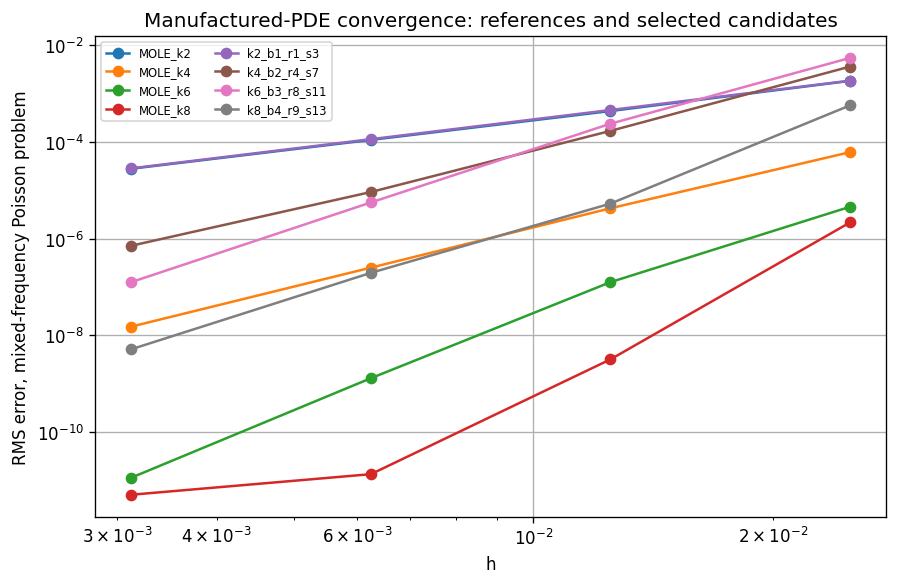

In [24]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
for operator_id, group in pde_refinement.groupby("operator_id"):
    ax.loglog(group["h"], group["mixed_frequency_rms_error"], marker="o", label=operator_id)
ax.set_xlabel("h")
ax.set_ylabel("RMS error, mixed-frequency Poisson problem")
ax.set_title("Manufactured-PDE convergence: references and selected candidates")
ax.legend(fontsize=7, ncol=2)
fig.savefig(OUTPUT_DIR / "figures" / "pde_convergence_references_and_candidates.png", bbox_inches="tight")
plt.show()


## 13 · Structured robustness of the selected candidates

The selected candidate and the same-order MOLE reference are tested under the identical random seeds and relative perturbation norms. This is a numerical sensitivity comparison; it does not claim that arbitrary matrix perturbations preserve the mimetic identities.


In [25]:
robustness_frames = []
for order, template in selected_templates.items():
    for family, op in (
        ("candidate", instantiate_shared_template(template, CONFIG.perturbation_mesh)),
        ("reference", build_mole_reference(order, CONFIG.perturbation_mesh)),
    ):
        frame = perturbation_sensitivity(
            op,
            gammas=CONFIG.perturbation_gammas,
            trials=PERTURBATION_TRIALS,
            boundary_width=max(4, 2 * order),
            seed=CONFIG.random_seed + 1000 + order,
        )
        frame["family"] = family
        frame["candidate_id"] = template.spec.candidate_id
        robustness_frames.append(frame)
selected_robustness = pd.concat(robustness_frames, ignore_index=True)
selected_robustness.to_csv(OUTPUT_DIR / "tables" / "selected_candidate_robustness.csv", index=False)
selected_robustness_summary = (
    selected_robustness
    .groupby(["order", "candidate_id", "family", "gamma", "kind"], as_index=False)
    .agg(mean_drift=("relative_worst_eigenvalue_drift", "mean"),
         std_drift=("relative_worst_eigenvalue_drift", "std"))
)
display(selected_robustness_summary)


,order,candidate_id,family,gamma,kind,mean_drift,std_drift
0,2,k2_b1_r1_s3,candidate,0.02,boundary,0.002055,0.000407
1,2,k2_b1_r1_s3,candidate,0.02,dense,0.003078,0.000395
2,2,k2_b1_r1_s3,candidate,0.08,boundary,0.009178,0.002428
3,2,k2_b1_r1_s3,candidate,0.08,dense,0.011763,0.001691
4,2,k2_b1_r1_s3,reference,0.02,boundary,0.002439,0.000702
5,2,k2_b1_r1_s3,reference,0.02,dense,0.003061,0.000426
6,2,k2_b1_r1_s3,reference,0.08,boundary,0.010438,0.004596
7,2,k2_b1_r1_s3,reference,0.08,dense,0.011900,0.001675
8,4,k4_b2_r4_s7,candidate,0.02,boundary,0.002464,0.000469
9,4,k4_b2_r4_s7,candidate,0.02,dense,0.003158,0.000438


# Part III · Closed-grid Nebius diagnostic (retained, disabled by default)

## 14 · Historical fixed-grid proposal schema and provider-independent logging

The orchestration follows the reproducibility pattern used in the existing Nebius experiments: secret lookup outside the notebook source, endpoint/model namespacing, content-addressed caching and call accounting. It adds a strict structural-proposal schema and retains the complete provider response, prompt hash, token counts, latency, parser outcome and deterministic solver result.

No API call occurs unless `CONFIG.run_nebius=True` **and** the resolution cascade of Section 15 returns at least one model ID served by the endpoint. Automatic selection never invents an identifier: it only intersects the declared `CONFIG.nebius_model_patterns` with the live catalogue, caps the panel at `CONFIG.nebius_max_auto_models`, and prints the authorized panel and the planned generation count before spending. The unresolved case degrades to the offline mock and records `evidence_eligible=False` rather than aborting a completed scientific run.


The scientifically relevant AI experiment is now the open-program archive ablation in Part IV. This section is retained to reproduce the v4 negative control and is disabled by default (`run_matched_budget_ablation=False`, `nebius_samples_per_role=0`).

In [26]:
ALLOWED_ACTIONS = (
    "widen_boundary_closure", "change_boundary_depth", "trade_boundary_order",
    "reduce_support", "increase_support", "explore_structure",
)
ALLOWED_OBJECTIVES = (
    "scaled_spectral_radius", "q_similarity_condition_bound",
    "first_modes_accuracy", "mixed_frequency_pde_error",
    "effective_support_width", "structured_perturbation_robustness",
)
ROLE_INSTRUCTIONS = {
    "architecture_proposer": "Select a structurally distinct candidate likely to satisfy all exact and spectral gates.",
    "spectral_critic": "Prefer candidates that avoid extra low modes and reduce the Q-similarity condition bound.",
    "accuracy_critic": "Prefer physical-mode accuracy and manufactured-PDE accuracy, not only a small spectral radius.",
    "adversarial_verifier": "Select a candidate that tests a plausible failure boundary without repeating an evaluated structure.",
}

OPEN_PROPOSAL_SCHEMA = {
    "type": "object", "additionalProperties": False,
    "required": ["hypothesis", "action", "interior_order", "boundary_order",
                 "boundary_rows", "support_width", "objectives", "rationale"],
    "properties": {
        "hypothesis": {"type": "string", "minLength": 8, "maxLength": 500},
        "action": {"type": "string", "enum": list(ALLOWED_ACTIONS)},
        "interior_order": {"type": "integer", "enum": list(ORDERS)},
        "boundary_order": {"type": "integer", "minimum": 1, "maximum": 8},
        "boundary_rows": {"type": "integer", "minimum": 1, "maximum": 14},
        "support_width": {"type": "integer", "minimum": 3, "maximum": 24},
        "objectives": {"type": "array", "minItems": 1, "maxItems": 4,
                       "items": {"type": "string", "enum": list(ALLOWED_OBJECTIVES)}},
        "rationale": {"type": "string", "minLength": 8, "maxLength": 1000},
    },
}

PROBE_SCHEMA = {
    "type": "object", "additionalProperties": False,
    "required": ["ok"], "properties": {"ok": {"type": "boolean"}},
}


def shortlist_choice_schema(candidate_ids: Sequence[str]) -> dict[str, Any]:
    return {
        "type": "object", "additionalProperties": False,
        "required": ["candidate_id", "hypothesis", "action", "objectives", "rationale"],
        "properties": {
            "candidate_id": {"type": "string", "enum": list(candidate_ids)},
            "hypothesis": {"type": "string", "minLength": 8, "maxLength": 500},
            "action": {"type": "string", "enum": list(ALLOWED_ACTIONS)},
            "objectives": {"type": "array", "minItems": 1, "maxItems": 4,
                           "items": {"type": "string", "enum": list(ALLOWED_OBJECTIVES)}},
            "rationale": {"type": "string", "minLength": 8, "maxLength": 1000},
        },
    }


def get_colab_secret(name: str) -> str | None:
    try:
        from google.colab import userdata
        value = userdata.get(name)
        return value.strip() if value else None
    except Exception:
        return None


def get_nebius_key() -> str | None:
    return get_colab_secret("NEBIUS_API_KEY") or os.environ.get("NEBIUS_API_KEY")


def strip_reasoning_markup(text: str) -> str:
    """Remove chain-of-thought wrappers that precede the JSON object.

    Reasoning-tuned models emit deliberation either inside <think>...</think>
    (or <reasoning>, <analysis>) or as an unterminated block when the completion
    is truncated. Only the markup is removed; the JSON payload is untouched.
    """
    text = (text or "").strip()
    for tag in ("think", "thinking", "reasoning", "analysis", "scratchpad"):
        text = re.sub(rf"<{tag}>.*?</{tag}>", " ", text, flags=re.I | re.S)
        # An unterminated opening tag (truncated deliberation) loses only the
        # marker: the object often still follows it, so the text is kept and the
        # brace scanner below locates the JSON.
        text = re.sub(rf"</?{tag}>", " ", text, flags=re.I)
    return text.strip()


def extract_json_object(text: str) -> dict[str, Any]:
    text = strip_reasoning_markup(text)
    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?\s*|\s*```$", "", text, flags=re.I | re.S).strip()
    try:
        value = json.loads(text)
        if isinstance(value, dict): return value
    except Exception:
        pass
    # Every '{' is tried in order: deliberation left in the text can contain
    # brace-like fragments before the real object, and scanning only from the
    # first one turned a recoverable response into a hard parse failure.
    starts = [i for i, ch in enumerate(text) if ch == "{"]
    if not starts: raise ValueError("no JSON object found")
    unterminated = False
    for start in starts:
        depth = 0; in_string = False; escaped = False; closed = False
        for i in range(start, len(text)):
            ch = text[i]
            if escaped: escaped = False; continue
            if ch == "\\" and in_string: escaped = True; continue
            if ch == '"': in_string = not in_string; continue
            if in_string: continue
            if ch == "{": depth += 1
            elif ch == "}":
                depth -= 1
                if depth == 0:
                    closed = True
                    try:
                        value = json.loads(text[start:i + 1])
                    except Exception:
                        value = None
                    if isinstance(value, dict): return value
                    break
        if not closed: unterminated = True
    raise ValueError("unterminated JSON object" if unterminated else "no JSON object found")


def validate_open_proposal(value: dict[str, Any]) -> dict[str, Any]:
    required = set(OPEN_PROPOSAL_SCHEMA["required"])
    missing = sorted(required - set(value))
    if missing: raise ValueError(f"missing fields: {missing}")
    order = int(value["interior_order"])
    bo = max(1, min(order, int(value["boundary_order"])))
    rows = max(order // 2, min(14, int(value["boundary_rows"])))
    support = max(order + 1, rows + 2, int(value["support_width"]))
    support = min(24, support)
    objectives = [str(x) for x in value["objectives"] if str(x) in ALLOWED_OBJECTIVES]
    if not objectives: objectives = ["first_modes_accuracy"]
    return {
        "hypothesis": str(value["hypothesis"]),
        "action": str(value["action"]) if str(value["action"]) in ALLOWED_ACTIONS else "explore_structure",
        "interior_order": order, "boundary_order": bo,
        "boundary_rows": rows, "support_width": support,
        "objectives": objectives[:4], "rationale": str(value["rationale"]),
    }


def response_text(payload: dict[str, Any]) -> str:
    """Content first, then the fields reasoning models use instead.

    Some providers return an empty ``content`` and place the completion in
    ``reasoning_content``; a truncated reasoning model may leave the JSON only
    there. Every candidate field is tried before giving up.
    """
    try:
        choice = payload["choices"][0]
    except Exception:
        return ""
    message = choice.get("message") or {}
    candidates = [
        message.get("content"), message.get("reasoning_content"),
        message.get("reasoning"), choice.get("text"),
    ]
    for content in candidates:
        if isinstance(content, str) and content.strip():
            return content
        if isinstance(content, list) and content:
            joined = "".join(
                str(x.get("text", "")) if isinstance(x, dict) else str(x) for x in content
            )
            if joined.strip(): return joined
    return ""


def response_finish_reason(payload: dict[str, Any]) -> str | None:
    try:
        return payload["choices"][0].get("finish_reason")
    except Exception:
        return None


def usage_from_payload(payload: dict[str, Any]) -> dict[str, int]:
    usage = payload.get("usage") or {}
    return {
        "input_tokens": int(usage.get("prompt_tokens", usage.get("input_tokens", 0)) or 0),
        "output_tokens": int(usage.get("completion_tokens", usage.get("output_tokens", 0)) or 0),
        "total_tokens": int(usage.get("total_tokens", 0) or 0),
    }


class NebiusJSONClient:
    """OpenAI-compatible Nebius client with verbose discovery and prompt de-duplication."""
    def __init__(self, api_key: str, base_url: str, output_dir: Path):
        self.api_key = api_key
        self.base_url = base_url.rstrip("/") + "/"
        self.output_dir = Path(output_dir)
        self.http = httpx.Client(timeout=httpx.Timeout(120.0, connect=30.0))
        self.capabilities: dict[str, dict[str, Any]] = {}

    @property
    def headers(self) -> dict[str, str]:
        return {"Authorization": f"Bearer {self.api_key}", "Content-Type": "application/json"}

    def list_models_verbose(self) -> list[dict[str, Any]]:
        errors = []
        for suffix in ("models?verbose=true", "models"):
            try:
                response = self.http.get(self.base_url + suffix, headers=self.headers)
                response.raise_for_status()
                payload = response.json()
                data = payload.get("data", payload if isinstance(payload, list) else [])
                if not isinstance(data, list): raise ValueError("model catalogue has no data list")
                normalized = []
                for item in data:
                    if isinstance(item, str): item = {"id": item}
                    if not isinstance(item, dict) or not item.get("id"): continue
                    meta = item.get("metadata") if isinstance(item.get("metadata"), dict) else {}
                    caps = item.get("capabilities") if isinstance(item.get("capabilities"), dict) else {}
                    normalized.append({
                        "id": str(item["id"]),
                        "context_length": item.get("context_length", meta.get("context_length", caps.get("context_length"))),
                        "owned_by": item.get("owned_by"),
                        "raw": item,
                    })
                json_dump(self.output_dir / "llm" / "model_catalog.json", {
                    "endpoint": self.base_url + suffix, "models": normalized,
                })
                return normalized
            except Exception as exc:
                errors.append(f"{suffix}: {type(exc).__name__}: {exc}")
        raise RuntimeError("Could not load Nebius model catalogue: " + " | ".join(errors))

    def _chat(self, body: dict[str, Any]) -> tuple[dict[str, Any], float]:
        started = time.perf_counter()
        response = self.http.post(self.base_url + "chat/completions", headers=self.headers, json=body)
        latency = time.perf_counter() - started
        response.raise_for_status()
        return response.json(), latency

    def probe_model(self, model_id: str) -> dict[str, Any]:
        prompt = (
            "Return exactly one JSON object matching the supplied schema with ok=true. "
            "If you reason first, keep it brief and put the JSON object last."
        )
        base = {
            "model": model_id, "temperature": 0.0,
            "max_tokens": CONFIG.nebius_probe_max_tokens,
            "messages": [{"role": "user", "content": prompt + " Schema: " + json.dumps(PROBE_SCHEMA)}],
        }
        attempts = []
        for mode in ("json_schema", "json_object", "plain_json"):
            body = dict(base)
            if mode == "json_schema":
                body["response_format"] = {
                    "type": "json_schema",
                    "json_schema": {"name": "capability_probe", "strict": True, "schema": PROBE_SCHEMA},
                }
            elif mode == "json_object":
                body["response_format"] = {"type": "json_object"}
            payload = {}
            try:
                payload, latency = self._chat(body)
                parsed = extract_json_object(response_text(payload))
                if parsed.get("ok") is True:
                    result = {"model_id": model_id, "usable": True, "mode": mode,
                              "latency_s": latency, "attempts": attempts}
                    self.capabilities[model_id] = result
                    return result
                raise ValueError(f"probe JSON was {parsed!r}")
            except Exception as exc:
                # Record what actually came back: an empty completion with
                # finish_reason='length' is a token-budget problem, not an
                # incapable model, and the two were indistinguishable before.
                excerpt, finish = "", None
                try:
                    excerpt = (response_text(payload) or "")[:200]
                    finish = response_finish_reason(payload)
                except Exception:
                    pass
                attempts.append({"mode": mode, "error": f"{type(exc).__name__}: {str(exc)[:400]}",
                                 "finish_reason": finish, "response_excerpt": excerpt})
        result = {"model_id": model_id, "usable": False, "mode": None, "attempts": attempts}
        self.capabilities[model_id] = result
        return result

    def complete_json(
        self, *, model_id: str, system: str, prompt: str,
        schema: dict[str, Any], schema_name: str,
        temperature: float | None = None, max_tokens: int | None = None,
        role: str = "", sample_index: int = 0,
        extra_messages: list[dict[str, str]] | None = None,
    ) -> dict[str, Any]:
        capability = self.capabilities.get(model_id) or self.probe_model(model_id)
        if not capability.get("usable"):
            return {"model_id": model_id, "role": role, "sample_index": sample_index,
                    "ok": False, "error": "model failed capability probe", "usage": {},
                    "capability": capability}
        mode = capability["mode"]
        schema_text = json.dumps(schema, sort_keys=True)
        full_prompt = prompt + "\n\nReturn only JSON. The exact JSON Schema is:\n" + schema_text
        prompt_payload = {
            "model_id": model_id, "system": system, "prompt": full_prompt,
            "extra_messages": list(extra_messages or []),
            "schema": schema, "schema_name": schema_name, "mode": mode,
            "temperature": CONFIG.nebius_temperature if temperature is None else temperature,
            "max_tokens": CONFIG.nebius_max_tokens if max_tokens is None else max_tokens,
        }
        prompt_hash = hashlib.sha256(json.dumps(prompt_payload, sort_keys=True).encode()).hexdigest()
        prompt_path = self.output_dir / "llm" / "prompts" / f"{prompt_hash}.json"
        if not prompt_path.exists(): json_dump(prompt_path, prompt_payload)
        cache_path = self.output_dir / "llm" / "cache" / f"{prompt_hash}.json"
        if cache_path.exists():
            record = json.loads(cache_path.read_text(encoding="utf-8"))
            record["cache_hit"] = True
            return record

        body = {
            "model": model_id,
            "temperature": prompt_payload["temperature"],
            "max_tokens": prompt_payload["max_tokens"],
            "messages": [{"role": "system", "content": system},
                         {"role": "user", "content": full_prompt},
                         *(extra_messages or [])],
        }
        if mode == "json_schema":
            body["response_format"] = {
                "type": "json_schema",
                "json_schema": {"name": schema_name, "strict": True, "schema": schema},
            }
        elif mode == "json_object":
            body["response_format"] = {"type": "json_object"}

        record = {
            "model_id": model_id, "role": role, "sample_index": sample_index,
            "prompt_hash": prompt_hash, "capability_mode": mode, "cache_hit": False,
            "is_repair_turn": bool(extra_messages),
        }
        try:
            payload, latency = self._chat(body)
            record["finish_reason"] = response_finish_reason(payload)
            record.update({"latency_s": latency, "usage": usage_from_payload(payload)})
            raw = response_text(payload)
            record["raw_text"] = raw
            try:
                record["parsed"] = extract_json_object(raw); record["ok"] = True
            except Exception as first_exc:
                record["ok"] = False; record["error"] = f"parse: {type(first_exc).__name__}: {first_exc}"
                if CONFIG.nebius_repair_attempts:
                    repair_prompt = (
                        "Repair the following response into one JSON object matching the schema. "
                        "Do not explain.\nSchema: " + schema_text + "\nResponse:\n" + raw[:6000]
                    )
                    repair_body = {
                        "model": model_id, "temperature": 0.0, "max_tokens": prompt_payload["max_tokens"],
                        "messages": [{"role": "user", "content": repair_prompt}],
                    }
                    if mode == "json_schema": repair_body["response_format"] = body["response_format"]
                    elif mode == "json_object": repair_body["response_format"] = {"type": "json_object"}
                    repair_payload, repair_latency = self._chat(repair_body)
                    repair_usage = usage_from_payload(repair_payload)
                    for key in ("input_tokens", "output_tokens", "total_tokens"):
                        record["usage"][key] = record["usage"].get(key, 0) + repair_usage.get(key, 0)
                    record["latency_s"] += repair_latency
                    repair_raw = response_text(repair_payload)
                    record["repair_raw_text"] = repair_raw
                    record["parsed"] = extract_json_object(repair_raw)
                    record["ok"] = True; record["repaired"] = True
        except Exception as exc:
            record.update({"ok": False, "error": f"{type(exc).__name__}: {str(exc)[:1000]}",
                           "usage": record.get("usage", {})})
        json_dump(cache_path, record)
        return record


def _model_score(model_id: str, pattern: str, context_length: Any) -> tuple:
    mid = model_id.lower(); pat = pattern.lower()
    exact = int(mid == pat)
    suffix_exact = int(mid.endswith("/" + pat) or mid.endswith(pat))
    contains = int(pat in mid)
    instruct = int("instruct" in mid or "-it" in mid)
    fast_penalty = int(any(x in mid for x in ("fast", "turbo", "preview")))
    try: context = int(context_length or 0)
    except Exception: context = 0
    return (exact, suffix_exact, contains, instruct,
            -fast_penalty if CONFIG.nebius_prefer_non_fast_variants else 0,
            context, -len(model_id), model_id)


def resolve_model_catalog(catalog: list[dict[str, Any]]) -> dict[str, Any]:
    by_id = {str(x["id"]): x for x in catalog}
    env_ids = get_colab_secret("NEBIUS_MODEL_IDS") or os.environ.get("NEBIUS_MODEL_IDS")
    requested = list(CONFIG.nebius_model_ids)
    source = "config_exact_ids"
    if not requested and env_ids:
        requested = [x.strip() for x in re.split(r"[,\n]", env_ids) if x.strip()]
        source = "NEBIUS_MODEL_IDS"
    resolved, diagnostics = [], []
    if requested:
        missing = [x for x in requested if x not in by_id]
        if missing: raise RuntimeError(f"Explicit Nebius model IDs are not served: {missing}")
        resolved = requested
    else:
        source = "declared_patterns"
        unused = set(by_id)
        for pattern in CONFIG.nebius_model_patterns:
            candidates = [by_id[mid] for mid in unused if pattern.lower() in mid.lower()]
            ranked = sorted(candidates,
                            key=lambda x: _model_score(x["id"], pattern, x.get("context_length")),
                            reverse=True)
            diagnostics.append({"pattern": pattern, "candidates": [x["id"] for x in ranked[:10]]})
            if ranked:
                chosen = ranked[0]["id"]
                resolved.append(chosen); unused.discard(chosen)
            if len(resolved) >= CONFIG.nebius_max_auto_models: break
    return {"source": source, "resolved_model_ids": resolved,
            "pattern_diagnostics": diagnostics, "catalog_size": len(catalog)}


def proposal_to_spec(proposal: dict[str, Any]) -> SharedTemplateSpec:
    value = validate_open_proposal(proposal)
    minimum_mesh = 2 * max(value["support_width"], value["boundary_rows"] + value["interior_order"]) + 4
    meshes = tuple(sorted(set(max(int(m), minimum_mesh) for m in CONFIG.design_meshes)))
    return SharedTemplateSpec(
        value["interior_order"], value["boundary_order"], value["boundary_rows"],
        value["support_width"], meshes,
    )


def proposal_holdout_meshes(spec: SharedTemplateSpec) -> tuple[int, ...]:
    minimum = 2 * max(spec.support_width, spec.boundary_rows + spec.interior_order) + 4
    return tuple(sorted(set(max(int(m), minimum) for m in CONFIG.holdout_meshes)))


def proposal_failure_report(calls: list[dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for call in calls:
        if call.get("ok"):
            continue
        rows.append({"model_id": call.get("model_id"), "role": call.get("role"),
                     "sample_index": call.get("sample_index"), "error": call.get("error")})
    return pd.DataFrame(rows)

PROPOSAL_SYSTEM = (
    "You are proposing search structures for a deterministic mimetic-operator verifier. "
    "You never claim validity. Conservation, exact moments, spectral loading, physical modes, "
    "PDE accuracy and exact rational reconstruction are decided only by the Python verifier."
)
print("Nebius v4 loader ready: verbose catalogue, deterministic resolution and capability probes.")


Nebius v4 loader ready: verbose catalogue, deterministic resolution and capability probes.


## 15 · Offline harness test or live crossed-model panel

The panel is generated under an explicit contract: the system prompt is built from the validator's own constants (`build_proposal_system`), the JSON schema is sent to the provider when `nebius_use_structured_outputs=True`, type-level repairs are applied and logged before validation, and one repair turn quotes the validator's message back to the model. Repair turns are billed and logged as generations and never as solver calls, so the matched-budget unit is unchanged. `panel_failure_report.csv` classifies every rejected generation.


In [27]:
# A compact, predeclared seed archive. The exhaustive search table is deliberately
# excluded: putting all 1008 evaluated outcomes into the prompt would leak the answer
# and was the source of the ~100k-token v3 prompts.
SEED_IDS = [
    "k2_b1_r1_s3", "k2_b1_r3_s5", "k4_b2_r4_s7", "k4_b2_r5_s7",
    "k6_b2_r4_s7", "k6_b3_r8_s11", "k8_b2_r4_s9", "k8_b4_r9_s13",
]
seed_rows = search_table[search_table["candidate_id"].isin(SEED_IDS)].copy()
archive_for_models = {
    "reference_summary": reference_table[[
        "order", "scaled_spectral_radius", "eigenvector_condition_number",
        "nonreal_eigenvalue_count", "max_abs_imaginary_eigenvalue",
    ]].to_dict("records"),
    "verifier_contract": {
        "required": [
            "exact conservation and moments", "positive diagonal weights",
            "Q-symmetric real non-positive spectrum", "no extra low modes",
            "first five physical modes", "scaled inverse condition",
            "low- and mixed-frequency manufactured PDE solves", "exact affine certificate",
        ],
        "note": "A small spectral radius cannot compensate for spectral pollution or PDE failure.",
    },
    "fixed_seed_evaluations": seed_rows[[
        "candidate_id", "interior_order", "boundary_order", "boundary_rows", "support_width",
        "status", "hard_gate_passed_all_holdouts", "scaled_spectral_radius",
        "max_first_modes_relative_error", "max_extra_low_mode_count",
        "max_mixed_frequency_pde_rms_error",
    ]].replace({np.nan: None}).to_dict("records"),
}
archive_text = json.dumps(archive_for_models, sort_keys=True, default=str)
if len(archive_text) > CONFIG.nebius_prompt_archive_max_chars:
    raise RuntimeError(f"Compact model archive is unexpectedly large: {len(archive_text)} characters")
print(f"Compact model archive: {len(archive_text):,} characters (v3 prompts were ~307k characters).")


def open_proposal_prompt(role: str) -> str:
    return (
        ROLE_INSTRUCTIONS[role] + "\n"
        "Propose one structure. Respect the schema bounds. The proposal is only a hypothesis.\n"
        "Compact evidence archive:\n" + archive_text
    )


def build_mock_panel() -> list[dict[str, Any]]:
    proposals = [
        {"hypothesis": "compact second-order control", "action": "reduce_support",
         "interior_order": 2, "boundary_order": 1, "boundary_rows": 1, "support_width": 3,
         "objectives": ["effective_support_width"], "rationale": "offline harness control"},
        {"hypothesis": "fourth-order compact closure", "action": "reduce_support",
         "interior_order": 4, "boundary_order": 2, "boundary_rows": 4, "support_width": 7,
         "objectives": ["first_modes_accuracy"], "rationale": "offline harness control"},
        {"hypothesis": "sixth-order clean low-mode closure", "action": "change_boundary_depth",
         "interior_order": 6, "boundary_order": 3, "boundary_rows": 8, "support_width": 11,
         "objectives": ["first_modes_accuracy", "mixed_frequency_pde_error"],
         "rationale": "offline harness control"},
        {"hypothesis": "eighth-order clean compact closure", "action": "change_boundary_depth",
         "interior_order": 8, "boundary_order": 4, "boundary_rows": 9, "support_width": 13,
         "objectives": ["q_similarity_condition_bound", "mixed_frequency_pde_error"],
         "rationale": "offline harness control"},
    ]
    rows = []
    for i, proposal in enumerate(proposals):
        rows.append({"model_id": "offline-mock", "role": list(ROLE_INSTRUCTIONS)[i % 4],
                     "sample_index": 0, "ok": True, "parsed": proposal,
                     "usage": {"input_tokens": 0, "output_tokens": 0, "total_tokens": 0},
                     "latency_s": 0.0, "evidence_eligible": False})
    return rows

NEBIUS_LIVE = False
NEBIUS_CLIENT = None
MODEL_CATALOG: list[dict[str, Any]] = []
MODEL_RESOLUTION: dict[str, Any] = {"source": "offline", "resolved_model_ids": []}
MODEL_CAPABILITIES: dict[str, Any] = {}
RESOLVED_MODEL_IDS: list[str] = []
panel_calls: list[dict[str, Any]] = []

key = get_nebius_key() if CONFIG.run_nebius else None
if CONFIG.run_nebius and key:
    try:
        NEBIUS_CLIENT = NebiusJSONClient(key, CONFIG.nebius_base_url, OUTPUT_DIR)
        MODEL_CATALOG = NEBIUS_CLIENT.list_models_verbose()
        MODEL_RESOLUTION = resolve_model_catalog(MODEL_CATALOG)
        requested_ids = MODEL_RESOLUTION["resolved_model_ids"]
        for model_id in requested_ids:
            MODEL_CAPABILITIES[model_id] = NEBIUS_CLIENT.probe_model(model_id)
        RESOLVED_MODEL_IDS = [
            model_id for model_id in requested_ids if MODEL_CAPABILITIES[model_id].get("usable")
        ]
        MODEL_RESOLUTION["capabilities"] = MODEL_CAPABILITIES
        MODEL_RESOLUTION["resolved_model_ids"] = RESOLVED_MODEL_IDS
        if not RESOLVED_MODEL_IDS:
            raise RuntimeError("No declared model passed the JSON capability probe.")
        NEBIUS_LIVE = True
        print("Resolved live Nebius models:")
        for model_id in RESOLVED_MODEL_IDS:
            print("  ", model_id, "->", MODEL_CAPABILITIES[model_id]["mode"])
        for model_id in RESOLVED_MODEL_IDS:
            for role in ROLE_INSTRUCTIONS:
                for sample_index in range(CONFIG.nebius_samples_per_role):
                    call = NEBIUS_CLIENT.complete_json(
                        model_id=model_id, system=PROPOSAL_SYSTEM,
                        prompt=open_proposal_prompt(role), schema=OPEN_PROPOSAL_SCHEMA,
                        schema_name="mimetic_structure_proposal",
                        role=role, sample_index=sample_index,
                    )
                    if call.get("ok"):
                        try: call["parsed"] = validate_open_proposal(call["parsed"])
                        except Exception as exc:
                            call["ok"] = False; call["error"] = f"validation: {exc}"
                    call["evidence_eligible"] = True
                    panel_calls.append(call)
    except Exception as exc:
        MODEL_RESOLUTION["degradation_reason"] = f"{type(exc).__name__}: {exc}"
        if not CONFIG.nebius_offline_mock_fallback: raise
        panel_calls = build_mock_panel()
else:
    if CONFIG.run_nebius and not key:
        MODEL_RESOLUTION["degradation_reason"] = "NEBIUS_API_KEY not found"
    panel_calls = build_mock_panel()

if not panel_calls: panel_calls = build_mock_panel()
evidence_eligible = bool(NEBIUS_LIVE and any(bool(x.get("evidence_eligible")) for x in panel_calls))
json_dump(OUTPUT_DIR / "llm" / "model_resolution.json", MODEL_RESOLUTION)
json_dump(OUTPUT_DIR / "llm" / "model_capabilities.json", MODEL_CAPABILITIES)
with (OUTPUT_DIR / "llm" / "panel_calls.jsonl").open("w", encoding="utf-8") as stream:
    for row in panel_calls: stream.write(json.dumps(row, sort_keys=True, default=str) + "\n")

panel_summary = pd.DataFrame([{
    "model_id": row.get("model_id"), "role": row.get("role"),
    "sample_index": row.get("sample_index"), "parsed": bool(row.get("ok")),
    "input_tokens": (row.get("usage") or {}).get("input_tokens", 0),
    "output_tokens": (row.get("usage") or {}).get("output_tokens", 0),
    "latency_s": row.get("latency_s", 0.0), "error": row.get("error"),
    "prompt_hash": row.get("prompt_hash"), "capability_mode": row.get("capability_mode"),
    "evidence_eligible": row.get("evidence_eligible", False),
} for row in panel_calls])
panel_failures = proposal_failure_report(panel_calls)
panel_summary.to_csv(OUTPUT_DIR / "tables" / "nebius_panel_summary.csv", index=False)
panel_failures.to_csv(OUTPUT_DIR / "tables" / "nebius_panel_failures.csv", index=False)
display(panel_summary)


Compact model archive: 3,689 characters (v3 prompts were ~307k characters).
Resolved live Nebius models:
   zai-org/GLM-5.2 -> json_schema
   MiniMaxAI/MiniMax-M3 -> json_schema
   nvidia/Cosmos3-Super-Reasoner -> json_schema


,model_id,role,sample_index,parsed,input_tokens,output_tokens,latency_s,error,prompt_hash,capability_mode,evidence_eligible
0,offline-mock,architecture_proposer,0,True,0,0,0.0,None,None,None,False
1,offline-mock,spectral_critic,0,True,0,0,0.0,None,None,None,False
2,offline-mock,accuracy_critic,0,True,0,0,0.0,None,None,None,False
3,offline-mock,adversarial_verifier,0,True,0,0,0.0,None,None,None,False


## 16 · Deterministic evaluation of model-proposed structures

Only unique, valid proposals consume solver calls. The same hard-gate cascade used for classical search is applied. The default mock run verifies the harness but remains ineligible for any claim that an LLM improved the search.


In [28]:
proposal_solver_log = []
seen_specs = set()
initial_panel_solver_calls = 0
for call in panel_calls:
    if not call.get("ok"):
        continue
    try:
        proposal = validate_open_proposal(call["parsed"])
        spec = proposal_to_spec(proposal)
        if spec.candidate_id in seen_specs:
            proposal_solver_log.append({
                "model_id": call.get("model_id"), "role": call.get("role"),
                "candidate_id": spec.candidate_id, "status": "duplicate_structure",
                "solver_called": False,
            })
            continue
        seen_specs.add(spec.candidate_id)
        initial_panel_solver_calls += 1
        if spec.candidate_id in templates:
            template = templates[spec.candidate_id]
        else:
            template = design_shared_template(spec)
        summary, per_mesh = candidate_evaluation(template, proposal_holdout_meshes(spec))
        proposal_solver_log.append({
            "model_id": call.get("model_id"), "role": call.get("role"),
            "candidate_id": spec.candidate_id, "status": "evaluated",
            "solver_called": True, **summary,
        })
    except Exception as exc:
        proposal_solver_log.append({
            "model_id": call.get("model_id"), "role": call.get("role"),
            "candidate_id": None, "status": "solver_or_validation_failure",
            "solver_called": False, "error": f"{type(exc).__name__}: {exc}",
        })
proposal_solver_table = pd.DataFrame(proposal_solver_log)
proposal_solver_table.to_csv(OUTPUT_DIR / "tables" / "model_proposed_solver_results.csv", index=False)
solver_calls = int(initial_panel_solver_calls)  # compatibility alias; provenance separates campaigns.
print(f"Initial panel: {int(panel_summary['parsed'].sum())}/{len(panel_summary)} valid generations; "
      f"{initial_panel_solver_calls} unique deterministic solver calls.")
display(proposal_solver_table)


Initial panel: 4/4 valid generations; 4 unique deterministic solver calls.


,model_id,role,candidate_id,status,solver_called,interior_order,boundary_order,boundary_rows,support_width,design_meshes,...,max_EGD_residual,max_imaginary_eigenvalue,max_first_mode_relative_error,max_first_modes_relative_error,max_extra_low_mode_count,max_scaled_condition_number,max_low_frequency_pde_rms_error,max_mixed_frequency_pde_rms_error,holdout_leading_eigenvalues_json,holdout_matched_physical_modes_json
0,offline-mock,architecture_proposer,k2_b1_r1_s3,evaluated,True,2,1,1,3,"(32, 48)",...,0.000000e+00,0.0,2.007815e-04,0.005010,0,0.405366,1.420025e-04,0.000714,"[{""real"": -9.86904070394655, ""imag"": 0.0}, {""r...","[{""mode"": 1, ""real"": -9.86904070394655, ""imag""..."
1,offline-mock,spectral_critic,k4_b2_r4_s7,evaluated,True,4,2,4,7,"(32, 48)",...,2.220446e-16,0.0,3.959736e-07,0.000203,0,0.551505,5.523079e-06,0.000459,"[{""real"": -9.86960455042222, ""imag"": 0.0}, {""r...","[{""mode"": 1, ""real"": -9.86960455042222, ""imag""..."
2,offline-mock,accuracy_critic,k6_b3_r8_s11,evaluated,True,6,3,8,11,"(32, 48)",...,1.110223e-16,0.0,3.995386e-08,0.000337,0,0.837567,5.258892e-07,0.000760,"[{""real"": -9.869604396165215, ""imag"": 0.0}, {""...","[{""mode"": 1, ""real"": -9.869604396165215, ""imag..."
3,offline-mock,adversarial_verifier,k8_b4_r9_s13,evaluated,True,8,4,9,13,"(38, 48)",...,1.110223e-16,0.0,6.705719e-11,0.000011,0,0.670331,2.203335e-08,0.000023,"[{""real"": -9.869604401088864, ""imag"": 0.0}, {""...","[{""mode"": 1, ""real"": -9.869604401088864, ""imag..."


## 17 · Matched-budget ablation protocol

The comparison unit is a **unique deterministic solver call**, not a language-model generation. Every arm receives the same solver-call budget. Duplicate or malformed proposals are logged but do not consume that budget. API calls, tokens, latency and cost remain separate outcomes.

The implementation below supports four executable arms:

1. deterministic structural enumeration;
2. one model with verifier feedback;
3. a multi-model panel without feedback;
4. a crossed model-by-role panel with verifier feedback.

Arm 1 costs nothing and therefore runs whenever `run_matched_budget_ablation=True`, including offline. Arms 2–4 execute only when Section 15 resolved a live panel (`NEBIUS_LIVE`); otherwise they are recorded as skipped, with the reason, instead of aborting the run. Comparisons between arms are meaningful only when all four executed in the same run.


In [29]:
matched_budget_protocol = pd.DataFrame([
    {"strategy": "deterministic_enumeration", "feedback": True, "model_diversity": 0},
    {"strategy": "single_model_feedback", "feedback": True, "model_diversity": 1},
    {"strategy": "multi_model_no_feedback", "feedback": False, "model_diversity": "all"},
    {"strategy": "crossed_multi_model_feedback", "feedback": True, "model_diversity": "all"},
])
matched_budget_protocol["unique_solver_budget"] = CONFIG.nebius_solver_budget
matched_budget_protocol.to_csv(OUTPUT_DIR / "tables" / "matched_budget_protocol.csv", index=False)

SPEC_BY_ID = {spec.candidate_id: spec for spec in SEARCH_SPECS}
SEED_ID_SET = set(SEED_IDS)


def evaluate_spec_for_arm(spec: SharedTemplateSpec, strategy: str, generation_index: int) -> dict[str, Any]:
    started = time.perf_counter()
    try:
        template = templates.get(spec.candidate_id)
        if template is None:
            template = design_shared_template(spec)
        summary, _ = candidate_evaluation(template, proposal_holdout_meshes(spec))
        return {"strategy": strategy, "generation_index": generation_index,
                "candidate_id": spec.candidate_id, "solver_status": "evaluated",
                "solver_time_s": time.perf_counter() - started, **summary}
    except Exception as exc:
        return {"strategy": strategy, "generation_index": generation_index,
                "candidate_id": spec.candidate_id, "solver_status": "infeasible_or_error",
                "solver_time_s": time.perf_counter() - started,
                "hard_gate_passed_all_holdouts": False,
                "error": f"{type(exc).__name__}: {str(exc)[:1000]}"}


def compact_feedback(records: list[dict[str, Any]]) -> list[dict[str, Any]]:
    fields = ["candidate_id", "solver_status", "hard_gate_passed_all_holdouts",
              "scaled_spectral_radius", "max_first_modes_relative_error",
              "max_extra_low_mode_count", "max_mixed_frequency_pde_rms_error"]
    return [{k: row.get(k) for k in fields} for row in records[-8:]]


def structural_shortlist(seen: set[str], seed: int, size: int) -> list[SharedTemplateSpec]:
    rng = random.Random(seed)
    available = [s for s in SEARCH_SPECS if s.candidate_id not in seen and s.candidate_id not in SEED_ID_SET]
    if not available: return []
    groups = {order: [s for s in available if s.interior_order == order] for order in ORDERS}
    chosen: list[SharedTemplateSpec] = []
    per_order = max(1, size // len(ORDERS))
    for order in ORDERS:
        group = groups[order]
        rng.shuffle(group)
        # Spread boundary order / depth before random fill.
        group.sort(key=lambda s: (s.boundary_order, s.boundary_rows, s.support_width))
        if group:
            stride = max(1, len(group) // per_order)
            offsets = list(range(0, len(group), stride))[:per_order]
            chosen.extend(group[i] for i in offsets)
    remaining = [s for s in available if s.candidate_id not in {x.candidate_id for x in chosen}]
    rng.shuffle(remaining)
    chosen.extend(remaining[: max(0, size - len(chosen))])
    rng.shuffle(chosen)
    return chosen[:size]


def deterministic_spec_stream() -> list[SharedTemplateSpec]:
    # Predeclared, balanced across orders, with no access to candidate outcomes.
    seen = set(SEED_ID_SET)
    stream = []
    round_index = 0
    while len(stream) < CONFIG.nebius_solver_budget:
        short = structural_shortlist(seen, CONFIG.random_seed + 17 * round_index,
                                     max(CONFIG.nebius_shortlist_size, 8))
        if not short: break
        by_order = {order: [s for s in short if s.interior_order == order] for order in ORDERS}
        for order in ORDERS:
            if by_order[order] and len(stream) < CONFIG.nebius_solver_budget:
                spec = by_order[order][0]
                stream.append(spec); seen.add(spec.candidate_id)
        round_index += 1
    return stream


def run_deterministic_budget_arm(budget: int) -> tuple[list[dict[str, Any]], list[dict[str, Any]]]:
    records, calls = [], []
    for i, spec in enumerate(deterministic_spec_stream()[:budget]):
        records.append(evaluate_spec_for_arm(spec, "deterministic_enumeration", i))
        calls.append({"strategy": "deterministic_enumeration", "generation_index": i,
                      "candidate_id": spec.candidate_id, "solver_called": True,
                      "input_tokens": 0, "output_tokens": 0, "latency_s": 0.0})
    return records, calls


def shortlist_prompt(role: str, shortlist: list[SharedTemplateSpec], feedback: list[dict[str, Any]] | None) -> str:
    payload = {
        "role_instruction": ROLE_INSTRUCTIONS[role],
        "candidate_shortlist": [
            {"candidate_id": s.candidate_id, "interior_order": s.interior_order,
             "boundary_order": s.boundary_order, "boundary_rows": s.boundary_rows,
             "support_width": s.support_width}
            for s in shortlist
        ],
        "own_arm_feedback": feedback or [],
        "fixed_context": archive_for_models,
        "instruction": "Choose exactly one candidate_id from the shortlist. Do not repeat prior IDs.",
    }
    text = json.dumps(payload, sort_keys=True, default=str)
    if len(text) > CONFIG.nebius_prompt_archive_max_chars:
        raise RuntimeError(f"Matched-budget prompt exceeded cap: {len(text)} chars")
    return text


def run_model_budget_arm(strategy: str, model_ids: list[str], feedback_enabled: bool,
                         budget: int) -> tuple[list[dict[str, Any]], list[dict[str, Any]]]:
    records, calls = [], []
    seen = set(SEED_ID_SET)
    maximum_generations = budget * CONFIG.nebius_max_generation_multiplier
    roles = list(ROLE_INSTRUCTIONS)
    for generation in range(maximum_generations):
        if len(records) >= budget: break
        shortlist = structural_shortlist(
            seen, CONFIG.random_seed + int(hashlib.sha256(
                f"{strategy}:{generation}".encode()).hexdigest()[:8], 16),
            CONFIG.nebius_shortlist_size,
        )
        if not shortlist: break
        model_id = model_ids[generation % len(model_ids)]
        role = roles[generation % len(roles)] if strategy == "crossed_multi_model_feedback" else (
            "spectral_critic" if strategy == "single_model_feedback" else "architecture_proposer"
        )
        candidate_ids = [s.candidate_id for s in shortlist]
        call = NEBIUS_CLIENT.complete_json(
            model_id=model_id, system=PROPOSAL_SYSTEM,
            prompt=shortlist_prompt(role, shortlist, compact_feedback(records) if feedback_enabled else None),
            schema=shortlist_choice_schema(candidate_ids), schema_name="mimetic_shortlist_choice",
            role=role, sample_index=generation,
        )
        usage = call.get("usage") or {}
        log = {
            "strategy": strategy, "generation_index": generation, "model_id": model_id,
            "role": role, "prompt_hash": call.get("prompt_hash"),
            "capability_mode": call.get("capability_mode"), "parsed": bool(call.get("ok")),
            "input_tokens": usage.get("input_tokens", 0),
            "output_tokens": usage.get("output_tokens", 0),
            "latency_s": call.get("latency_s", 0.0), "error": call.get("error"),
            "solver_called": False,
        }
        if not call.get("ok"):
            calls.append(log); continue
        choice = call.get("parsed") or {}
        candidate_id = choice.get("candidate_id")
        if candidate_id not in candidate_ids or candidate_id in seen:
            log["error"] = "choice was not an unseen candidate from the declared shortlist"
            calls.append(log); continue
        seen.add(candidate_id)
        spec = SPEC_BY_ID[candidate_id]
        record = evaluate_spec_for_arm(spec, strategy, generation)
        record.update({"model_id": model_id, "role": role,
                       "hypothesis": choice.get("hypothesis"),
                       "rationale": choice.get("rationale")})
        records.append(record)
        log.update({"solver_called": True, "candidate_id": candidate_id})
        calls.append(log)
    return records, calls


def summarize_budget_arm(strategy: str, records: list[dict[str, Any]], calls: list[dict[str, Any]]) -> dict[str, Any]:
    frame = pd.DataFrame(records)
    return {
        "strategy": strategy,
        "solver_calls": int(len(records)),
        "unique_candidate_ids": int(frame["candidate_id"].nunique()) if not frame.empty else 0,
        "budget_exhausted": bool(len(records) == CONFIG.nebius_solver_budget),
        "generations": int(len(calls)),
        "parsed_generations": int(sum(bool(x.get("parsed")) for x in calls)),
        "hard_gate_passes": int(frame.get("hard_gate_passed_all_holdouts", pd.Series(dtype=bool)).fillna(False).sum()) if not frame.empty else 0,
        "distinct_feasible_families": int(frame.loc[
            frame.get("hard_gate_passed_all_holdouts", False) == True,
            "canonical_family_hash",
        ].nunique()) if (not frame.empty and "canonical_family_hash" in frame) else 0,
        "input_tokens": int(sum(int(x.get("input_tokens", 0) or 0) for x in calls)),
        "output_tokens": int(sum(int(x.get("output_tokens", 0) or 0) for x in calls)),
        "api_latency_s": float(sum(float(x.get("latency_s", 0.0) or 0.0) for x in calls)),
        "solver_time_s": float(frame.get("solver_time_s", pd.Series(dtype=float)).sum()) if not frame.empty else 0.0,
    }

matched_budget_results_records = []
matched_budget_calls = []
matched_budget_arms_executed = []
matched_budget_arms_skipped = []

records, calls = run_deterministic_budget_arm(CONFIG.nebius_solver_budget)
matched_budget_results_records.extend(records); matched_budget_calls.extend(calls)
matched_budget_arms_executed.append("deterministic_enumeration")

MODEL_ARMS_EXECUTABLE = bool(
    CONFIG.run_matched_budget_ablation and NEBIUS_LIVE and NEBIUS_CLIENT and RESOLVED_MODEL_IDS
)
if MODEL_ARMS_EXECUTABLE:
    arm_defs = [
        ("single_model_feedback", [RESOLVED_MODEL_IDS[0]], True),
        ("multi_model_no_feedback", RESOLVED_MODEL_IDS, False),
        ("crossed_multi_model_feedback", RESOLVED_MODEL_IDS, True),
    ]
    for strategy, model_ids, feedback_enabled in arm_defs:
        records, calls = run_model_budget_arm(
            strategy, model_ids, feedback_enabled, CONFIG.nebius_solver_budget
        )
        matched_budget_results_records.extend(records); matched_budget_calls.extend(calls)
        matched_budget_arms_executed.append(strategy)
else:
    matched_budget_arms_skipped = [
        "single_model_feedback", "multi_model_no_feedback", "crossed_multi_model_feedback"
    ]

matched_budget_results = pd.DataFrame(matched_budget_results_records)
summary_rows = []
for strategy in matched_budget_arms_executed:
    rec = [x for x in matched_budget_results_records if x["strategy"] == strategy]
    cal = [x for x in matched_budget_calls if x["strategy"] == strategy]
    summary_rows.append(summarize_budget_arm(strategy, rec, cal))
matched_budget_summary = pd.DataFrame(summary_rows)
matched_budget_results.to_csv(OUTPUT_DIR / "tables" / "matched_budget_results.csv", index=False)
matched_budget_summary.to_csv(OUTPUT_DIR / "tables" / "matched_budget_summary.csv", index=False)
with (OUTPUT_DIR / "llm" / "matched_budget_calls.jsonl").open("w", encoding="utf-8") as stream:
    for row in matched_budget_calls:
        stream.write(json.dumps(row, sort_keys=True, default=str) + "\n")

starved = sorted(matched_budget_summary.loc[
    ~matched_budget_summary["budget_exhausted"].astype(bool), "strategy"
].astype(str).tolist()) if not matched_budget_summary.empty else []
comparison_valid = bool(
    NEBIUS_LIVE and not matched_budget_arms_skipped and not starved
    and set(matched_budget_arms_executed) == set(matched_budget_protocol["strategy"])
)
json_dump(OUTPUT_DIR / "tables" / "matched_budget_arm_status.json", {
    "executed": matched_budget_arms_executed, "skipped": matched_budget_arms_skipped,
    "solver_budget": CONFIG.nebius_solver_budget,
    "arms_that_did_not_exhaust_budget": starved,
    "cross_arm_comparison_valid": comparison_valid,
    "fairness_guards": [
        "same unique deterministic-solver budget", "same fixed seed archive",
        "no exhaustive outcome table in prompts", "unseen candidate-id enum per call",
        "own-arm feedback only", "all token usage logged before parsing",
    ],
})
display(matched_budget_summary)
if not comparison_valid:
    print("Matched-budget cross-arm comparison is not valid for this run.")


,strategy,solver_calls,unique_candidate_ids,budget_exhausted,generations,parsed_generations,hard_gate_passes,distinct_feasible_families,input_tokens,output_tokens,api_latency_s,solver_time_s
0,deterministic_enumeration,12,12,True,12,0,4,4,0,0,0.0,0.30276


Matched-budget cross-arm comparison is not valid for this run.


# Part IV · True open-program discovery

## 18 · Program grammar and deterministic compiler

The proposal unit is now a complete construction program. Its continuous weights make the
space non-enumerable, while row-dependent support profiles, norm class, left/right closure
structure, and verifier caps change the mathematical method rather than merely selecting a
point from the old grid.

The first implementation tranche follows the most important recommendations:

- diagonal and block-SPD boundary norms;
- reflection-symmetric or independent left/right closures;
- row-dependent support widths and boundary depths;
- model-proposed LP objectives, extra moment conditions, positivity margins, coefficient
  bounds, and spectral/accuracy caps;
- uniform random, feasibility-informed expert prior, and tree-surrogate controls;
- three-mesh manufactured-PDE accuracy inside every candidate evaluation.

Boundary-graded grids are not silently approximated here. They require a separate
mesh-family parametrization and exact coordinate-dependent moment derivation; the external
program schema is designed so that this can be added without changing the verifier contract.


In [30]:
from __future__ import annotations

import hashlib, json, math, time
from dataclasses import dataclass, asdict, field
from fractions import Fraction
from typing import Any, Iterable, Sequence, Literal

import numpy as np
import pandas as pd
from scipy.optimize import linprog, linear_sum_assignment
from scipy.linalg import cholesky, solve_triangular
from sklearn.ensemble import ExtraTreesRegressor,ExtraTreesClassifier
from scipy.stats import mannwhitneyu

CENTRAL_DERIVATIVE_FRACTIONS: dict[int, tuple[Fraction, ...]] = {
    2: tuple(Fraction(x) for x in (-1, 1)),
    4: tuple(Fraction(x) for x in (Fraction(1,24), Fraction(-9,8), Fraction(9,8), Fraction(-1,24))),
    6: tuple(Fraction(x) for x in (Fraction(-3,640), Fraction(25,384), Fraction(-75,64), Fraction(75,64), Fraction(-25,384), Fraction(3,640))),
    8: tuple(Fraction(x) for x in (Fraction(5,7168), Fraction(-49,5120), Fraction(245,3072), Fraction(-1225,1024), Fraction(1225,1024), Fraction(-245,3072), Fraction(49,5120), Fraction(-5,7168))),
}

@dataclass(frozen=True)
class OpenSearchConfig:
    design_meshes: tuple[int,...]=(36,52)
    holdout_meshes: tuple[int,...]=(64,96)
    accuracy_meshes: tuple[int,...]=(40,80,160)
    physical_modes: int=5
    physical_pool: int=30
    max_first_modes_relative_error: float=0.20
    first_mode_relative_error: float=0.05
    extra_low_modes: int=0
    scaled_condition_max: float=2.0
    low_pde_error_max: float=2e-2
    mixed_pde_error_max: float=1e-1
    min_pde_rate_ratio: float=0.55
    eq_tolerance: float=5e-7
    spectrum_tolerance: float=1e-8
    random_pool_size: int=256
    surrogate_warmup: int=6
    surrogate_beta: float=0.8
    utility_invalid_floor: float=-2.0
    lp_time_limit_s: float=8.0
    # Fixed external thresholds, declared before any model call and identical for every
    # program and arm. The proposer's own caps are scored as self-consistency only.
    external_spectral_radius_cap: float=9.0
    external_q_condition_cap: float=6.0
    external_mixed_pde_error_cap: float=1e-4
    asymptotic_rate_check: bool=True
    asymptotic_rate_factor: float=2.0
    asymptotic_rate_points: int=3
    # A fixed slice of every arm's budget may bypass the empirical boundary-order
    # ceiling. Without it the search cannot discover that the presumed frontier is
    # wrong, and the declared quota in v10 and v11 was never actually consumed.
    frontier_probe_fraction: float=0.10
    max_program_complexity: int=900
    max_design_mesh: int=96
    # Pre-flight screen. Necessary structural conditions established by the audited
    # closed-class search and the v7 open run: no program with a boundary order above
    # k//2+1 has ever compiled (1 of 39 attempts, against 23 of 51 at or below), and a
    # block_psd norm with bandwidth 0 is self-contradictory. Rejected programs never
    # reach the LP and therefore never consume a solver call, in ANY arm.
    preflight_enabled: bool=True
    preflight_boundary_order_slack: int=1
    preflight_frontier_probe_quota: int=1
    preflight_max_resamples: int=60

OPEN_CONFIG=OpenSearchConfig()

@dataclass(frozen=True)
class OpenProgramSpec:
    target_order: int
    norm_class: Literal['diagonal','block_psd']='diagonal'
    closure_symmetry: Literal['reflection','asymmetric']='reflection'
    left_boundary_order: int=2
    right_boundary_order: int=2
    left_rows: int=4
    right_rows: int=4
    left_support_profile: tuple[int,...]=(7,7,7,7)
    right_support_profile: tuple[int,...]=(7,7,7,7)
    norm_bandwidth: int=1
    objective: Literal['max_margin','min_l1','min_next_moment','hybrid']='max_margin'
    l1_weight: float=0.02
    moment_weight: float=1.0
    margin_weight: float=1.0
    min_norm_margin: float=1e-7
    coefficient_bound: float=100.0
    extra_moment_degree: int=1
    design_meshes: tuple[int,...]=(36,52)
    spectral_radius_cap: float=12.0
    q_condition_cap: float=20.0
    mixed_pde_error_cap: float=1e-1
    minimum_rate_ratio: float=0.55

    def normalized(self) -> 'OpenProgramSpec':
        k=int(self.target_order)
        if k not in CENTRAL_DERIVATIVE_FRACTIONS:
            raise ValueError('target_order must be 2,4,6,8')
        lr=max(k//2,min(12,int(self.left_rows))); rr=max(k//2,min(12,int(self.right_rows)))
        lbo=max(1,min(k,int(self.left_boundary_order))); rbo=max(1,min(k,int(self.right_boundary_order)))
        def norm_profile(p,n):
            vals=[max(k+1,min(24,int(x))) for x in p]
            if not vals: vals=[k+1]
            vals=(vals+[vals[-1]]*n)[:n]
            # permit tapered/nonmonotone profiles, but adjacent jumps above 4 are clipped for solvability
            for i in range(1,n):
                vals[i]=max(vals[i-1]-4,min(vals[i-1]+4,vals[i]))
            return tuple(vals)
        lp=norm_profile(self.left_support_profile,lr)
        rp=norm_profile(self.right_support_profile,rr)
        if self.closure_symmetry=='reflection':
            rr=lr; rbo=lbo; rp=lp
        minimum_mesh=2*max(max(lp),max(rp),lr+k,rr+k)+4
        dm=sorted(set(max(int(x),minimum_mesh) for x in self.design_meshes))
        if len(dm)<2: dm=[dm[0],dm[0]+16]
        return OpenProgramSpec(
            target_order=k,norm_class=self.norm_class,closure_symmetry=self.closure_symmetry,
            left_boundary_order=lbo,right_boundary_order=rbo,left_rows=lr,right_rows=rr,
            left_support_profile=lp,right_support_profile=rp,
            norm_bandwidth=max(0,min(4,int(self.norm_bandwidth))),objective=self.objective,
            l1_weight=max(0.0,min(10.0,float(self.l1_weight))),
            moment_weight=max(0.0,min(10.0,float(self.moment_weight))),
            margin_weight=max(0.0,min(10.0,float(self.margin_weight))),
            min_norm_margin=max(1e-10,min(0.25,float(self.min_norm_margin))),
            coefficient_bound=max(2.0,min(1e4,float(self.coefficient_bound))),
            extra_moment_degree=max(1,min(3,int(self.extra_moment_degree))),
            design_meshes=tuple(dm[:2]),
            spectral_radius_cap=max(4.0,min(20.0,float(self.spectral_radius_cap))),
            q_condition_cap=max(1.0,min(100.0,float(self.q_condition_cap))),
            mixed_pde_error_cap=max(1e-12,min(1e-1,float(self.mixed_pde_error_cap))),
            minimum_rate_ratio=max(0.25,min(1.25,float(self.minimum_rate_ratio))),
        )

    @property
    def program_id(self)->str:
        payload=asdict(self.normalized())
        h=hashlib.sha256(json.dumps(payload,sort_keys=True,default=list).encode()).hexdigest()[:12]
        s=self.normalized()
        return f"prog_k{s.target_order}_{s.norm_class}_{s.closure_symmetry}_{s.objective}_{h}"

@dataclass
class OpenTemplate:
    spec: OpenProgramSpec
    Q_left: np.ndarray
    P_left: np.ndarray
    A_left: np.ndarray
    C_left: np.ndarray
    Q_right: np.ndarray
    P_right: np.ndarray
    A_right: np.ndarray
    C_right: np.ndarray
    central_weights: np.ndarray
    objective_value: float
    equality_residual: float
    norm_margin: float
    solver_status: str='optimal'
    variable_count: int=0
    equation_count: int=0
    system: dict[str,Any]=field(default_factory=dict,repr=False)

@dataclass
class GeneralOperator1D:
    cells:int
    D:np.ndarray
    G:np.ndarray
    Q:np.ndarray
    P:np.ndarray
    metadata:dict[str,Any]=field(default_factory=dict)
    @property
    def h(self): return 1.0/self.cells
    @property
    def scalar_nodes(self): return np.r_[0.0,(np.arange(self.cells)+0.5)/self.cells,1.0]
    @property
    def vector_nodes(self): return np.linspace(0.0,1.0,self.cells+1)
    @property
    def scalar_nodes_bar(self): return np.r_[0.0,np.arange(self.cells)+0.5,float(self.cells)]
    @property
    def vector_nodes_bar(self): return np.arange(self.cells+1,dtype=float)
    @property
    def L(self): return self.D@self.G
    @property
    def dirichlet_block(self): return self.L[1:-1,1:-1]
    @property
    def B(self):
        out=np.zeros_like(self.D); out[0,0]=-1.; out[-1,-1]=1.; return out
    def content_hash(self):
        h=hashlib.sha256()
        for x in (self.D,self.G,self.Q,self.P): h.update(np.ascontiguousarray(x).view(np.uint8))
        h.update(json.dumps(self.metadata,sort_keys=True,default=str).encode())
        return h.hexdigest()

class LinearProgramBuilder:
    def __init__(self):
        self.names=[]; self.index={}; self.eq=[]; self.beq=[]; self.ineq=[]; self.bineq=[]
        self.bounds={}; self.objective={}; self.labels=[]
    def var(self,name,lb=None,ub=None):
        if name not in self.index:
            self.index[name]=len(self.names); self.names.append(name); self.bounds[name]=(lb,ub)
        else:
            old=self.bounds[name]
            lo=old[0] if lb is None else (lb if old[0] is None else max(lb,old[0]))
            hi=old[1] if ub is None else (ub if old[1] is None else min(ub,old[1]))
            self.bounds[name]=(lo,hi)
        return name
    def add_eq(self,terms,rhs=0.,label=''):
        self.eq.append(dict(terms)); self.beq.append(float(rhs)); self.labels.append(label)
        for n in terms:self.var(n)
    def add_le(self,terms,rhs=0.):
        self.ineq.append(dict(terms)); self.bineq.append(float(rhs))
        for n in terms:self.var(n)
    def add_obj(self,name,coef): self.var(name); self.objective[name]=self.objective.get(name,0.)+float(coef)
    def add_abs(self,expr:dict[str,float],const:float,prefix:str,weight:float=1.):
        z=self.var(prefix,0.,None)
        t1=dict(expr); t1[z]=t1.get(z,0.)-1.; self.add_le(t1,-const)
        t2={n:-v for n,v in expr.items()}; t2[z]=t2.get(z,0.)-1.; self.add_le(t2,const)
        self.add_obj(z,weight); return z
    def matrices(self):
        n=len(self.names)
        def make(rows):
            M=np.zeros((len(rows),n))
            for i,row in enumerate(rows):
                for name,v in row.items(): M[i,self.index[name]]+=v
            return M
        c=np.zeros(n)
        for name,v in self.objective.items(): c[self.index[name]]+=v
        return c,make(self.eq),np.asarray(self.beq),make(self.ineq),np.asarray(self.bineq),[self.bounds[n] for n in self.names]

Expr=tuple[dict[str,float],float]
# numpy 2.4 removed np.trapz; Colab currently ships 2.0.2 where it is only deprecated.
trapezoid_auc = getattr(np, 'trapezoid', None) or np.trapz

def expr_add(a:Expr,b:Expr,scale=1.0)->Expr:
    t=dict(a[0])
    for n,v in b[0].items():t[n]=t.get(n,0.)+scale*v
    return t,a[1]+scale*b[1]
def expr_scale(a:Expr,s:float)->Expr:return {n:s*v for n,v in a[0].items()},s*a[1]
def expr_value(a:Expr,vals:dict[str,float])->float:return a[1]+sum(vals[n]*v for n,v in a[0].items())
def const_expr(x:float)->Expr:return {},float(x)
def var_expr(name:str)->Expr:return {name:1.},0.

def psd_cone_block(builder:LinearProgramBuilder,size:int,prefix:str,bandwidth:int,margin_name:str|None=None)->list[list[Expr]]:
    """LP-representable SPD cone: tau I + nonnegative sums vv^T, v=e_i and e_i±e_j."""
    M=[[const_expr(0.) for _ in range(size)] for _ in range(size)]
    tau=margin_name or f'{prefix}_tau'; builder.var(tau,0.,None)
    for i in range(size): M[i][i]=expr_add(M[i][i],var_expr(tau))
    basis=[]
    for i in range(size): basis.append(np.eye(size)[i])
    for i in range(size):
        for j in range(i+1,min(size,i+bandwidth+1)):
            v=np.zeros(size);v[i]=1;v[j]=1;basis.append(v)
            v=np.zeros(size);v[i]=1;v[j]=-1;basis.append(v)
    for b,v in enumerate(basis):
        name=f'{prefix}_alpha_{b}';builder.var(name,0.,None)
        for i in range(size):
            for j in range(size):
                if v[i]*v[j]: M[i][j]=expr_add(M[i][j],expr_scale(var_expr(name),v[i]*v[j]))
    return M

def diagonal_block(builder,size,prefix,endpoint_half=False,margin_name=None)->list[list[Expr]]:
    M=[[const_expr(0.) for _ in range(size)] for _ in range(size)]
    for i in range(size):
        if endpoint_half and i==0: M[i][i]=const_expr(.5)
        else:
            name=f'{prefix}_d{i}';builder.var(name,0.,None);M[i][i]=var_expr(name)
            if margin_name: builder.add_le({margin_name:1.,name:-1.},0.)
    return M

def reflect_block(M:list[list[Expr]])->list[list[Expr]]:
    n=len(M);return [[M[n-1-i][n-1-j] for j in range(n)] for i in range(n)]

def build_norm_block(builder,kind,size,prefix,bandwidth,endpoint_half,margin_name):
    if kind=='diagonal':return diagonal_block(builder,size,prefix,endpoint_half,margin_name)
    if endpoint_half:
        # endpoint remains uncoupled, preserving zero endpoint rows of D; interior subblock is SPD.
        M=[[const_expr(0.) for _ in range(size)] for _ in range(size)];M[0][0]=const_expr(.5)
        if size>1:
            S=psd_cone_block(builder,size-1,prefix+'_sub',bandwidth,margin_name)
            for i in range(1,size):
                for j in range(1,size):M[i][j]=S[i-1][j-1]
        return M
    return psd_cone_block(builder,size,prefix,bandwidth,margin_name)

def _eval_matrix(E,vals):return np.asarray([[expr_value(x,vals) for x in row] for row in E],float)

class InfeasibleProgram(RuntimeError):
    """Infeasibility carrying the group that has to give way.

    Through v10 an infeasible compile reported only the message and a least-squares
    equality residual, which says how far the system is from consistent but not what
    is fighting what. Proposals refined against that were worse than fresh ones.
    """
    def __init__(self,message,equality_residual=None,diagnosis=None):
        super().__init__(message)
        self.equality_residual=equality_residual
        self.diagnosis=diagnosis or {}


CONSTRAINT_GROUPS=(
    ('extended_gauss','EGD_'),
    ('derivative_boundary_moments','DM_'),
    ('gradient_boundary_moments','GM_'),
)


def constraint_group_of(label:str,left_rows:int=0,right_rows:int=0,cells:int=0)->str:
    """Group a constraint, splitting the extended-Gauss identity by region.

    In the v11 run 638 of 639 diagnosed programs reported 'extended_gauss' as the
    binding group, which is true but carries no information a proposer can act on.
    EGD labels are 'EGD_{mesh}_{i}_{j}', so the row index locates the violation in the
    left closure block, the interior, or the right closure block.
    """
    if label.startswith('EGD_'):
        parts=label.split('_')
        try:
            mesh=int(parts[1]);row=int(parts[2])
        except (IndexError,ValueError):
            return 'extended_gauss'
        if row<=left_rows: return 'extended_gauss_left_closure'
        if right_rows and row>=mesh+1-right_rows: return 'extended_gauss_right_closure'
        return 'extended_gauss_interior_coupling'
    for name,prefix in CONSTRAINT_GROUPS:
        if label.startswith(prefix):return name
    return 'other'


def diagnose_infeasibility(builder,Aeq,beq,Aub,bub,lp_method='highs-ds',time_limit_s=60.0,
                           left_rows:int=0,right_rows:int=0)->dict:
    """Minimum total violation per constraint group, plus a margin-relaxation test.

    Each equality group gets one non-negative slack; the relaxed program minimises the
    sum of slacks. A group whose slack must be positive is a group that cannot be
    satisfied together with the rest, which is the actionable statement: whether the
    closure order, the extended Gauss identity or the norm positivity is the binding
    requirement. A second solve drops the norm-margin floor to zero and reports
    whether feasibility returns, which separates 'no positive norm exists here' from
    'the algebra itself is inconsistent'.
    """
    try:
        names=list(builder.names);n=len(names)
        label_group={label:constraint_group_of(label,left_rows,right_rows) for label in set(builder.labels)}
        groups=sorted(set(label_group.values()))
        group_index={g:n+i for i,g in enumerate(groups)}
        total=n+len(groups)
        rows=[];rhs=[]
        for i,label in enumerate(builder.labels):
            slot=group_index[label_group[label]]
            up=np.zeros(total);up[:n]=Aeq[i];up[slot]=-1.;rows.append(up);rhs.append(beq[i])
            lo=np.zeros(total);lo[:n]=-Aeq[i];lo[slot]=-1.;rows.append(lo);rhs.append(-beq[i])
        for i in range(len(bub)):
            row=np.zeros(total);row[:n]=Aub[i];rows.append(row);rhs.append(bub[i])
        cost=np.zeros(total)
        for g in groups:cost[group_index[g]]=1.
        bounds=[builder.bounds[name] for name in names]+[(0.,None)]*len(groups)
        relaxed=linprog(cost,A_ub=np.asarray(rows),b_ub=np.asarray(rhs),bounds=bounds,
                        method=lp_method,options={'time_limit':float(time_limit_s)})
        slacks={}
        if relaxed.success:
            slacks={g:float(relaxed.x[group_index[g]]) for g in groups}
        # Does dropping the strict norm-margin floor restore feasibility?
        margin_bounds=[]
        for name in names:
            lo,hi=builder.bounds[name]
            margin_bounds.append((0.,hi) if name=='global_margin' else (lo,hi))
        margin_test=linprog(np.zeros(n),A_ub=Aub if len(Aub) else None,b_ub=bub if len(Aub) else None,
                            A_eq=Aeq,b_eq=beq,bounds=margin_bounds,
                            method=lp_method,options={'time_limit':float(time_limit_s)})
        binding=max(slacks,key=slacks.get) if slacks else None
        return {
            'group_minimum_violation':slacks,
            'binding_group':binding if (binding and slacks.get(binding,0.)>1e-9) else None,
            'feasible_without_positive_norm_margin':bool(margin_test.success),
            'interpretation':(
                'the algebraic system itself is inconsistent for this structure'
                if not margin_test.success else
                'the algebra is satisfiable but no strictly positive norm exists for it'),
        }
    except Exception as exc:
        return {'diagnostic_error':f'{type(exc).__name__}: {exc}'}


def compile_open_program(spec:OpenProgramSpec,lp_method='highs-ds',override_values:dict[str,float]|None=None,time_limit_s:float|None=None)->OpenTemplate:
    s=spec.normalized(); k=s.target_order; w=np.asarray([float(x) for x in CENTRAL_DERIVATIVE_FRACTIONS[k]])
    b=LinearProgramBuilder(); margin=b.var('global_margin',s.min_norm_margin,None)
    QL=build_norm_block(b,s.norm_class,s.left_rows+1,'QL',s.norm_bandwidth,True,margin)
    PL=build_norm_block(b,s.norm_class,s.left_rows,'PL',s.norm_bandwidth,False,margin)
    if s.closure_symmetry=='reflection': QR=reflect_block(QL);PR=reflect_block(PL)
    else:
        # right-local index is ordered from the right endpoint inward; endpoint is local index 0.
        QR=build_norm_block(b,s.norm_class,s.right_rows+1,'QR',s.norm_bandwidth,True,margin)
        PR=build_norm_block(b,s.norm_class,s.right_rows,'PR',s.norm_bandwidth,False,margin)
    maxSL=max(s.left_support_profile);maxSR=max(s.right_support_profile)
    AL=[[const_expr(0.) for _ in range(maxSL)] for _ in range(s.left_rows)]
    CL=[[const_expr(0.) for _ in range(maxSL)] for _ in range(s.left_rows)]
    for i,width in enumerate(s.left_support_profile):
        for j in range(width):
            an=b.var(f'AL_{i}_{j}',-s.coefficient_bound,s.coefficient_bound); AL[i][j]=var_expr(an)
            cn=b.var(f'CL_{i}_{j}',-s.coefficient_bound,s.coefficient_bound); CL[i][j]=var_expr(cn)
    if s.closure_symmetry=='reflection':
        AR=[[expr_scale(AL[s.left_rows-1-i][maxSL-1-j],-1.) for j in range(maxSL)] for i in range(s.left_rows)]
        CR=[[expr_scale(CL[s.left_rows-1-i][maxSL-1-j],-1.) for j in range(maxSL)] for i in range(s.left_rows)]
        # The compact reflected arrays are replaced during global embedding; retain placeholders.
    else:
        AR=[[const_expr(0.) for _ in range(maxSR)] for _ in range(s.right_rows)]
        CR=[[const_expr(0.) for _ in range(maxSR)] for _ in range(s.right_rows)]
        for i,width in enumerate(s.right_support_profile):
            for j in range(width):
                an=b.var(f'AR_{i}_{j}',-s.coefficient_bound,s.coefficient_bound);AR[i][j]=var_expr(an)
                cn=b.var(f'CR_{i}_{j}',-s.coefficient_bound,s.coefficient_bound);CR[i][j]=var_expr(cn)

    def embed(m:int):
        ns,nv=m+2,m+1; xs=np.r_[0.,np.arange(m)+.5,float(m)];xv=np.arange(m+1,dtype=float)
        # Expression matrices Q,P,A,C
        Q=[[const_expr(0.) for _ in range(ns)] for _ in range(ns)]
        P=[[const_expr(0.) for _ in range(nv)] for _ in range(nv)]
        for i in range(ns):Q[i][i]=const_expr(1.)
        for i in range(nv):P[i][i]=const_expr(1.)
        for i in range(s.left_rows+1):
            for j in range(s.left_rows+1):Q[i][j]=QL[i][j]
        for i in range(s.left_rows):
            for j in range(s.left_rows):P[i][j]=PL[i][j]
        if s.closure_symmetry=='reflection':
            qR_global=reflect_block(QL);pR_global=reflect_block(PL); rr=s.left_rows
        else:
            # QR/PR use endpoint-inward local ordering; global slices are inner-to-endpoint.
            qR_global=reflect_block(QR);pR_global=reflect_block(PR);rr=s.right_rows
        qstart=ns-(rr+1);pstart=nv-rr
        for i in range(rr+1):
            for j in range(rr+1):Q[qstart+i][qstart+j]=qR_global[i][j]
        for i in range(rr):
            for j in range(rr):P[pstart+i][pstart+j]=pR_global[i][j]
        A=[[const_expr(0.) for _ in range(nv)] for _ in range(ns)]
        C=[[const_expr(0.) for _ in range(ns)] for _ in range(nv)]
        # left rows
        for ii,width in enumerate(s.left_support_profile):
            i=1+ii
            for j in range(width):A[i][j]=AL[ii][j]
        for jj,width in enumerate(s.left_support_profile):
            j=jj
            for i in range(width):C[j][i]=CL[jj][i]
        # right rows, local support ordered endpoint-inward; global columns reversed
        if s.closure_symmetry=='reflection':
            for ii,width in enumerate(s.left_support_profile):
                gi=ns-2-ii
                for lj in range(width): A[gi][nv-1-lj]=expr_scale(AL[ii][lj],-1.)
            for jj,width in enumerate(s.left_support_profile):
                gj=nv-1-jj
                for li in range(width): C[gj][ns-1-li]=expr_scale(CL[jj][li],-1.)
        else:
            for ii,width in enumerate(s.right_support_profile):
                gi=ns-2-ii
                for lj in range(width):A[gi][nv-1-lj]=AR[ii][lj]
            for jj,width in enumerate(s.right_support_profile):
                gj=nv-1-jj
                for li in range(width):C[gj][ns-1-li]=CR[jj][li]
        # fixed central rows
        for i in range(s.left_rows+1,ns-1-rr):
            start=i-k//2
            for t,coef in enumerate(w):A[i][start+t]=const_expr(coef)
        for j in range(s.left_rows,nv-rr):
            start=j-k//2+1
            for t,coef in enumerate(w):C[j][start+t]=const_expr(coef)
        return xs,xv,Q,P,A,C

    def add_expr_eq(expr:Expr,rhs:float,label:str): b.add_eq(expr[0],rhs-expr[1],label)
    next_moment_exprs=[]
    for m in s.design_meshes:
        if m<2*max(maxSL,maxSR,s.left_rows+k,s.right_rows+k)+4:raise ValueError('design mesh too small')
        xs,xv,Q,P,A,C=embed(m);ns,nv=m+2,m+1
        # EGD
        for i in range(ns):
            for j in range(nv):
                e=expr_add(A[i][j],C[j][i]);rhs=-1. if (i,j)==(0,0) else (1. if (i,j)==(ns-1,nv-1) else 0.)
                if e[0] or e[1] or rhs:add_expr_eq(e,rhs,f'EGD_{m}_{i}_{j}')
        # General weighted moments for boundary rows
        sides=[('L',s.left_rows,s.left_boundary_order,list(range(1,s.left_rows+1)),list(range(s.left_rows))),
               ('R',s.right_rows,s.right_boundary_order,list(range(ns-2,ns-2-s.right_rows,-1)),list(range(nv-1,nv-1-s.right_rows,-1)))]
        for side,rows,bo,drows,grows in sides:
            for i in drows:
                for degree in range(bo+1):
                    e=const_expr(0.)
                    for j in range(nv): e=expr_add(e,expr_scale(A[i][j],(xv[j]-xs[i])**degree))
                    if degree>=1:
                        for l in range(ns):e=expr_add(e,expr_scale(Q[i][l],-degree*(xs[l]-xs[i])**(degree-1)))
                    add_expr_eq(e,0.,f'DM_{side}_{m}_{i}_{degree}')
                for degree in range(bo+1,bo+1+s.extra_moment_degree):
                    e=const_expr(0.)
                    for j in range(nv):e=expr_add(e,expr_scale(A[i][j],(xv[j]-xs[i])**degree))
                    for l in range(ns):e=expr_add(e,expr_scale(Q[i][l],-degree*(xs[l]-xs[i])**(degree-1)))
                    next_moment_exprs.append((e,f'Dnext_{side}_{m}_{i}_{degree}'))
            for j in grows:
                for degree in range(bo+1):
                    e=const_expr(0.)
                    for i in range(ns):e=expr_add(e,expr_scale(C[j][i],(xs[i]-xv[j])**degree))
                    if degree>=1:
                        for l in range(nv):e=expr_add(e,expr_scale(P[j][l],-degree*(xv[l]-xv[j])**(degree-1)))
                    add_expr_eq(e,0.,f'GM_{side}_{m}_{j}_{degree}')
                for degree in range(bo+1,bo+1+s.extra_moment_degree):
                    e=const_expr(0.)
                    for i in range(ns):e=expr_add(e,expr_scale(C[j][i],(xs[i]-xv[j])**degree))
                    for l in range(nv):e=expr_add(e,expr_scale(P[j][l],-degree*(xv[l]-xv[j])**(degree-1)))
                    next_moment_exprs.append((e,f'Gnext_{side}_{m}_{j}_{degree}'))

    # Objective compiler
    if s.objective in ('max_margin','hybrid'): b.add_obj(margin,-s.margin_weight)
    if s.objective in ('min_l1','hybrid','max_margin'):
        # A tiny L1 tie-break prevents the max-margin LP from selecting a numerically
        # extreme vertex in an otherwise flat affine family.
        l1w=(s.l1_weight if s.objective=='hybrid' else (1.0 if s.objective=='min_l1' else 1e-6))
        for name in list(b.names):
            if name.startswith(('AL_','AR_','CL_','CR_')):
                b.add_abs(var_expr(name)[0],0.,'abs_'+name,l1w)
    if s.objective in ('min_next_moment','hybrid'):
        wt=s.moment_weight if s.objective=='hybrid' else 1.
        for idx,(e,label) in enumerate(next_moment_exprs):b.add_abs(e[0],e[1],f'next_abs_{idx}',wt/max(1,len(next_moment_exprs)))
    if not b.objective:b.add_obj(margin,-1.)
    c,Aeq,beq,Aub,bub,bounds=b.matrices()
    if override_values is None:
        options={"time_limit":float(time_limit_s)} if time_limit_s is not None else None
        res=linprog(c,A_ub=Aub if len(Aub) else None,b_ub=bub if len(Aub) else None,
                    A_eq=Aeq,b_eq=beq,bounds=bounds,method=lp_method,options=options)
        if not res.success:
            ls=np.linalg.lstsq(Aeq,beq,rcond=None)[0] if Aeq.size else np.zeros(len(b.names))
            eqres=float(np.max(np.abs(Aeq@ls-beq))) if Aeq.size else 0.
            diagnosis=diagnose_infeasibility(b,Aeq,beq,Aub,bub,lp_method,
                                             left_rows=s.left_rows,right_rows=s.right_rows)
            raise InfeasibleProgram(
                f'LP infeasible: {res.message}; equality residual {eqres:.3e}',
                equality_residual=eqres,diagnosis=diagnosis)
        x=np.asarray(res.x,float);status=str(res.message);fun=float(res.fun)
    else:
        x=np.asarray([float(override_values[name]) for name in b.names],float)
        status='exact-reconstruction override';fun=float(c@x)
        eqres=float(np.max(np.abs(Aeq@x-beq))) if Aeq.size else 0.
        if eqres>1e-7: raise RuntimeError(f'override violates equality system: {eqres:.3e}')
    vals={n:x[i] for i,n in enumerate(b.names)}
    # Build canonical boundary arrays by evaluating one design mesh and extracting blocks.
    m=s.design_meshes[0];xs,xv,Q,P,A,C=embed(m);Qv=_eval_matrix(Q,vals);Pv=_eval_matrix(P,vals);Av=_eval_matrix(A,vals);Cv=_eval_matrix(C,vals)
    maxSL=max(s.left_support_profile);maxSR=max(s.right_support_profile)
    Qleft=Qv[:s.left_rows+1,:s.left_rows+1];Pleft=Pv[:s.left_rows,:s.left_rows]
    Aleft=Av[1:s.left_rows+1,:maxSL];Cleft=Cv[:s.left_rows,:maxSL]
    Qright=Qv[-s.right_rows-1:,-s.right_rows-1:];Pright=Pv[-s.right_rows:,-s.right_rows:]
    Aright=np.zeros((s.right_rows,maxSR));Cright=np.zeros((s.right_rows,maxSR))
    for ii,width in enumerate(s.right_support_profile):Aright[ii,:width]=Av[-2-ii,-width:][::-1]
    for jj,width in enumerate(s.right_support_profile):Cright[jj,:width]=Cv[-1-jj,-width:][::-1]
    eqres=float(np.max(np.abs(Aeq@x-beq))) if Aeq.size else 0.
    output_exprs={
        'Q_left':[row[:s.left_rows+1] for row in Q[:s.left_rows+1]],
        'P_left':[row[:s.left_rows] for row in P[:s.left_rows]],
        'Q_right':[row[-s.right_rows-1:] for row in Q[-s.right_rows-1:]],
        'P_right':[row[-s.right_rows:] for row in P[-s.right_rows:]],
    }
    system={'names':tuple(b.names),'solution':x,'Aeq':Aeq,'beq':beq,'Aub':Aub,'bub':bub,'bounds':tuple(bounds),'objective':c,'status':status,
            'output_exprs':output_exprs}
    return OpenTemplate(s,Qleft,Pleft,Aleft,Cleft,Qright,Pright,Aright,Cright,w,fun,eqres,float(vals[margin]),
                        solver_status=status,variable_count=len(b.names),equation_count=len(beq),system=system)

def instantiate_open_template(t:OpenTemplate,cells:int)->GeneralOperator1D:
    s=t.spec.normalized();k=s.target_order;m=cells;ns,nv=m+2,m+1
    maxSL=max(s.left_support_profile);maxSR=max(s.right_support_profile)
    if m<2*max(maxSL,maxSR,s.left_rows+k,s.right_rows+k)+4:raise ValueError('mesh too small')
    Qb=np.eye(ns);Pb=np.eye(nv);A=np.zeros((ns,nv));C=np.zeros((nv,ns))
    Qb[:s.left_rows+1,:s.left_rows+1]=t.Q_left;Pb[:s.left_rows,:s.left_rows]=t.P_left
    Qb[-s.right_rows-1:,-s.right_rows-1:]=t.Q_right;Pb[-s.right_rows:,-s.right_rows:]=t.P_right
    for ii,width in enumerate(s.left_support_profile):A[1+ii,:width]=t.A_left[ii,:width]
    for jj,width in enumerate(s.left_support_profile):C[jj,:width]=t.C_left[jj,:width]
    for ii,width in enumerate(s.right_support_profile):A[-2-ii,-width:]=t.A_right[ii,:width][::-1]
    for jj,width in enumerate(s.right_support_profile):C[-1-jj,-width:]=t.C_right[jj,:width][::-1]
    for i in range(s.left_rows+1,ns-1-s.right_rows):
        st=i-k//2;A[i,st:st+k]=t.central_weights
    for j in range(s.left_rows,nv-s.right_rows):
        st=j-k//2+1;C[j,st:st+k]=t.central_weights
    h=1./m
    D=np.linalg.solve(Qb,A)/h;G=np.linalg.solve(Pb,C)/h
    return GeneralOperator1D(m,D,G,h*Qb,h*Pb,{'program_id':s.program_id,**asdict(s)})

def _endpoint(n):x=np.zeros(n);x[0]=-1;x[-1]=1;return x

def moment_residual(matrix,source,target,max_degree,rows):
    out=0.
    for i in rows:
        off=source-target[i]
        for d in range(max_degree+1):out=max(out,abs(float(matrix[i]@(off**d)-(1. if d==1 else 0.))))
    return out

def q_similarity_general(op:GeneralOperator1D):
    L=op.dirichlet_block;QI=op.Q[1:-1,1:-1]
    try:
        R=cholesky(QI,lower=False)
        H=R@L@np.linalg.inv(R)
        scale=max(1.,float(np.max(np.abs(H))));res=float(np.max(np.abs(H-H.T))/scale)
        if res<5e-7:ev=np.linalg.eigvalsh((H+H.T)/2).astype(complex);sym=True
        else:ev=np.linalg.eigvals(L);sym=False
        return ev,res,float(np.sqrt(np.linalg.cond(QI))),sym
    except Exception:
        ev=np.linalg.eigvals(L);return ev,float('inf'),float('inf'),False

def manufactured(op,kind):
    x=op.scalar_nodes
    if kind=='low_frequency':u=np.sin(np.pi*x);f=-(np.pi**2)*np.sin(np.pi*x)
    else:u=np.sin(np.pi*x)+.1*np.sin(7*np.pi*x);f=-(np.pi**2)*np.sin(np.pi*x)-.1*(7*np.pi)**2*np.sin(7*np.pi*x)
    L=op.L;rhs=f[1:-1]-L[1:-1,0]*u[0]-L[1:-1,-1]*u[-1]
    try:
        uh=np.linalg.solve(op.dirichlet_block,rhs);e=uh-u[1:-1]
        return float(np.sqrt(np.mean(e*e))),float(np.linalg.norm(op.dirichlet_block@uh-rhs)/max(np.linalg.norm(rhs),1e-30))
    except Exception:return float('inf'),float('inf')

def rate(hs,errs):
    hs=np.asarray(hs,float);er=np.asarray(errs,float)
    ok=np.isfinite(er)&(er>1e-14)
    if ok.sum()<2:return float('nan')
    return float(np.polyfit(np.log(hs[ok]),np.log(er[ok]),1)[0])

def evaluate_open_template(t:OpenTemplate,config:OpenSearchConfig=OPEN_CONFIG,cheap=False):
    s=t.spec.normalized();details=[];hard=True
    minimum_mesh=2*max(max(s.left_support_profile),max(s.right_support_profile),s.left_rows+s.target_order,s.right_rows+s.target_order)+4
    holdouts=tuple(sorted(set(max(int(x),minimum_mesh+8*i) for i,x in enumerate(config.holdout_meshes))))
    abase=max(int(config.accuracy_meshes[0]),minimum_mesh)
    accuracies=(abase,max(int(config.accuracy_meshes[1]),abase+16),max(int(config.accuracy_meshes[2]),2*abase))
    meshes=tuple(sorted(set(holdouts+accuracies)))
    hs=[];mixed=[]
    for m in meshes:
        op=instantiate_open_template(t,m);h=op.h;Dbar=h*op.D;Gbar=h*op.G;xs=op.scalar_nodes_bar;xv=op.vector_nodes_bar
        dL=range(1,1+s.left_rows);dR=range(m,m-s.right_rows,-1);gL=range(s.left_rows);gR=range(m,m-s.right_rows,-1)
        Qeig=np.linalg.eigvalsh((op.Q+op.Q.T)/2);Peig=np.linalg.eigvalsh((op.P+op.P.T)/2)
        div=float(np.max(np.abs(np.ones(m+2)@op.Q@op.D-_endpoint(m+1))))
        grad=float(np.max(np.abs(np.ones(m+1)@op.P@op.G-_endpoint(m+2))))
        egd=float(np.max(np.abs(op.Q@op.D+(op.P@op.G).T-op.B)))
        mom=max(moment_residual(Dbar,xv,xs,s.left_boundary_order,dL),moment_residual(Dbar,xv,xs,s.right_boundary_order,dR),
                moment_residual(Gbar,xs,xv,s.left_boundary_order,gL),moment_residual(Gbar,xs,xv,s.right_boundary_order,gR))
        ev,qres,qcond,sym=q_similarity_general(op);rho=float(np.max(np.abs(ev)));ordered=ev[np.argsort(-ev.real)]
        exact=-(np.arange(1,config.physical_modes+1)*np.pi)**2;pool=ordered[:min(config.physical_pool,len(ordered))]
        rr,cc=linear_sum_assignment(np.abs(pool[:,None]-exact[None,:]));rel=np.full(len(exact),np.inf)
        for a,c in zip(rr,cc):rel[c]=abs(pool[a]-exact[c])/abs(exact[c])
        cutoff=-((config.physical_modes+.5)*np.pi)**2;extra=max(0,int(np.count_nonzero(ordered.real>cutoff))-config.physical_modes)
        nonreal=int(np.count_nonzero(np.abs(ev.imag)>max(1e-9,1e-10*rho)));pos=float(np.max(ev.real))
        nz=np.abs(ev[np.abs(ev)>max(1e-12*rho,1e-12)]);cond=rho/np.min(nz) if len(nz) else np.inf
        low,lowres=manufactured(op,'low_frequency');mix,mixres=manufactured(op,'mixed_frequency')
        structural=max(div,grad,egd,mom)<=config.eq_tolerance and min(Qeig)>0 and min(Peig)>0 and np.max(np.abs(op.D[[0,-1]]))<config.eq_tolerance
        spectral=(nonreal==0 and pos<=config.spectrum_tolerance*max(1.,rho)
                  and rel[0]<=config.first_mode_relative_error
                  and np.max(rel)<=config.max_first_modes_relative_error
                  and extra<=config.extra_low_modes
                  and cond*h*h<=config.scaled_condition_max
                  and qres<config.eq_tolerance)
        # The proposer's own caps are scored separately. A program cannot make itself
        # pass the study's primary endpoint by declaring a permissive threshold.
        spectral_external=spectral and rho*h*h<=config.external_spectral_radius_cap and qcond<=config.external_q_condition_cap
        spectral_self=spectral and rho*h*h<=s.spectral_radius_cap and qcond<=s.q_condition_cap
        pde_external=(low<=config.low_pde_error_max
             and mix<=config.external_mixed_pde_error_cap
             and max(lowres,mixres)<1e-8)
        pde_self=(low<=config.low_pde_error_max
             and mix<=min(config.mixed_pde_error_max,s.mixed_pde_error_cap)
             and max(lowres,mixres)<1e-8)
        spectral=spectral_external;pde=pde_external
        passed=structural and spectral_external and pde_external
        passed_self=structural and spectral_self and pde_self
        # Every mesh that contributes to the convergence fit must also be free of
        # spectral pollution: in v10 a promoted candidate carried two extra low modes
        # at the coarsest rate mesh because only the holdouts were gated.
        if m in accuracies and (extra>config.extra_low_modes or nonreal>0): hard=False
        if m in holdouts: hard=hard and passed
        details.append({'program_id':s.program_id,'cells':m,'structural_pass':structural,'spectral_pass':spectral,'pde_pass':pde,'hard_pass':passed,
                        'hard_pass_self_declared':passed_self,
                        'egd_residual':egd,'moment_residual':mom,'minimum_Q_eigenvalue':float(min(Qeig)),'minimum_P_eigenvalue':float(min(Peig)),
                        'scaled_spectral_radius':rho*h*h,'q_condition_bound':qcond,'scaled_condition':cond*h*h,'first_mode_rel_error':float(rel[0]),
                        'max_first_modes_rel_error':float(np.max(rel)),'extra_low_modes':extra,'nonreal':nonreal,'low_pde_error':low,'mixed_pde_error':mix})
        if m in accuracies:hs.append(h);mixed.append(mix)
    pderate=rate(hs,mixed)
    ratepass=bool(np.isfinite(pderate) and pderate>=config.min_pde_rate_ratio*min(s.left_boundary_order,s.right_boundary_order))
    ratepass_self=bool(np.isfinite(pderate) and pderate>=max(config.min_pde_rate_ratio,s.minimum_rate_ratio)*min(s.left_boundary_order,s.right_boundary_order))
    hard=hard and ratepass
    self_declared=all(bool(d.get('hard_pass_self_declared')) for d in details if d['cells'] in holdouts) and ratepass_self
    # Late-window rate. The three-point fit over the design accuracy meshes is
    # pre-asymptotic: in v10 a candidate fitted at 6.36 over (40, 80, 160) settled near
    # 4.6 over (160, 320, 640). Only errors are recomputed here, no eigen-decomposition.
    late_rate=float('nan');late_meshes=()
    if config.asymptotic_rate_check and hard:
        late_meshes=tuple(int(round(x*config.asymptotic_rate_factor**i)) for i,x in
                          enumerate((accuracies[-1],)*config.asymptotic_rate_points))
        late_meshes=tuple(sorted({accuracies[-1]}|{int(accuracies[-1]*config.asymptotic_rate_factor**i)
                                                    for i in range(1,config.asymptotic_rate_points)}))
        lh=[];lm=[]
        for m in late_meshes:
            op=instantiate_open_template(t,m);mix_late,res_late=manufactured(op,'mixed_frequency')
            if res_late>=1e-8: continue
            lh.append(op.h);lm.append(mix_late)
        if len(lh)>=3: late_rate=rate(lh,lm)
    last=details[-1]
    utility=program_utility({**last,'mixed_pde_rate':pderate,'hard_pass_all':hard},s,config)
    summary={**asdict(s),'program_id':s.program_id,'hard_pass_all':hard,'mixed_pde_rate':pderate,'rate_pass':ratepass,
             'hard_pass_self_declared':bool(self_declared),'rate_pass_self_declared':ratepass_self,
             'mixed_pde_rate_asymptotic':late_rate,'asymptotic_rate_meshes':json.dumps(list(late_meshes)),
             'utility':utility,'objective_value':t.objective_value,'LP_norm_margin':t.norm_margin,'LP_equality_residual':t.equality_residual,
             'variable_count':t.variable_count,'equation_count':t.equation_count,**{k:v for k,v in last.items() if k not in ('program_id','hard_pass')}}
    return summary,details

def program_utility(row,spec,config=OPEN_CONFIG):
    # Predeclared bounded utility. Invalid candidates retain graded diagnostic value but cannot exceed zero.
    structural=float(row.get('egd_residual',1e3))<config.eq_tolerance and float(row.get('moment_residual',1e3))<config.eq_tolerance
    spectral=int(row.get('nonreal',99))==0 and int(row.get('extra_low_modes',99))==0
    pde=np.isfinite(row.get('mixed_pde_error',np.inf))
    if not bool(row.get('hard_pass_all',False)):
        # Invalid candidates remain below zero; no soft objective can compensate for a failed gate.
        return min(-1e-6, config.utility_invalid_floor + .3*structural+.3*spectral+.2*pde)
    b=min(spec.left_boundary_order,spec.right_boundary_order)/spec.target_order
    rho=max(0.,1.-max(0.,float(row['scaled_spectral_radius'])-4.)/8.)
    q=max(0.,1.-math.log10(max(1.,float(row['q_condition_bound'])))/2.)
    e=max(0.,1.+math.log10(max(float(row['mixed_pde_error']),1e-14))/12.)
    r=max(0.,min(1.,float(row.get('mixed_pde_rate',0.))/max(1.,spec.target_order)))
    support=1.-(max(spec.left_support_profile+spec.right_support_profile)-spec.target_order)/(24.-spec.target_order)
    return float(.8*b+.5*r+.5*e+.3*rho+.25*q+.15*max(0.,support))

def score_mechanism_calibration(frame:pd.DataFrame)->pd.DataFrame:
    """Did the stated mechanism predict its own verifier outcome?

    Two separable questions: whether the proposer knew the program would pass, and
    whether the metric it named landed near the value it claimed. Both are scored
    only where the program compiled, since an infeasible LP reports no metric.
    """
    if frame.empty or 'predicted_hard_pass' not in frame:return pd.DataFrame()
    rows=[]
    for (strategy,),g in frame.groupby(['strategy']):
        pred=g['predicted_hard_pass'].astype('boolean')
        actual=g['hard_pass_all'].fillna(False).astype(bool)
        known=pred.notna()
        accuracy=float((pred[known].astype(bool)==actual[known]).mean()) if known.any() else np.nan
        base=float(actual.mean())
        ratios=[]
        for row in g.to_dict('records'):
            metric=row.get('predicted_primary_metric');claim=row.get('predicted_primary_value')
            got=row.get(metric) if metric else None
            if got is None or claim is None or not np.isfinite(float(got or np.nan)):continue
            if not bool(row.get('hard_pass_all',False)):continue
            got=float(got);claim=float(claim)
            if metric in ('mixed_pde_error',) and got>0 and claim>0:
                ratios.append(abs(math.log10(got)-math.log10(claim)))
            elif got!=0:
                ratios.append(abs(got-claim)/abs(got))
        brier=float(np.mean((pred[known].astype(float)-actual[known].astype(float))**2)) if known.any() else np.nan
        reference_brier=float(base*(1-base))
        rows.append({'strategy':strategy,'n':len(g),'predictions_supplied':int(known.sum()),
                     'brier_score':brier,'brier_skill_vs_base_rate':(1-brier/reference_brier) if reference_brier>0 else np.nan,
                     'overconfidence':(float(pred[known].astype(bool).mean())-base) if known.any() else np.nan,
                     'predicted_pass_rate':float(pred[known].astype(bool).mean()) if known.any() else np.nan,
                     'actual_pass_rate':base,'pass_prediction_accuracy':accuracy,
                     'skill_over_always_predicting_pass':accuracy-max(base,1-base) if np.isfinite(accuracy) else np.nan,
                     'metric_predictions_scored':len(ratios),
                     'median_metric_error':float(np.median(ratios)) if ratios else np.nan})
    return pd.DataFrame(rows)


NORM_MAP={'diagonal':0,'block_psd':1};SYM_MAP={'reflection':0,'asymmetric':1};OBJ_MAP={'max_margin':0,'min_l1':1,'min_next_moment':2,'hybrid':3}
def encode_program(s:OpenProgramSpec):
    s=s.normalized();lp=list(s.left_support_profile);rp=list(s.right_support_profile)
    return np.asarray([s.target_order,NORM_MAP[s.norm_class],SYM_MAP[s.closure_symmetry],s.left_boundary_order,s.right_boundary_order,s.left_rows,s.right_rows,
                       np.mean(lp),np.std(lp),np.min(lp),np.max(lp),np.mean(rp),np.std(rp),np.min(rp),np.max(rp),s.norm_bandwidth,OBJ_MAP[s.objective],
                       math.log10(s.l1_weight+1e-6),math.log10(s.moment_weight+1e-6),math.log10(s.margin_weight+1e-6),math.log10(s.min_norm_margin),
                       math.log10(s.coefficient_bound),s.extra_moment_degree,s.spectral_radius_cap,s.q_condition_cap,
                       math.log10(s.mixed_pde_error_cap),s.minimum_rate_ratio],float)

def uniform_random_program(rng:np.random.Generator,target_orders=(6,8),design_meshes=(36,52)):
    """Uniform/log-uniform sampling over the declared bounded program grammar."""
    k=int(rng.choice(target_orders));norm=str(rng.choice(['diagonal','block_psd']));sym=str(rng.choice(['reflection','asymmetric']))
    lr=int(rng.integers(k//2,13));rr=lr if sym=='reflection' else int(rng.integers(k//2,13))
    lbo=int(rng.integers(2,k+1));rbo=lbo if sym=='reflection' else int(rng.integers(2,k+1))
    def profile(n):return tuple(int(rng.integers(k+1,25)) for _ in range(n))
    lp=profile(lr);rp=lp if sym=='reflection' else profile(rr)
    return OpenProgramSpec(
        target_order=k,norm_class=norm,closure_symmetry=sym,left_boundary_order=lbo,right_boundary_order=rbo,
        left_rows=lr,right_rows=rr,left_support_profile=lp,right_support_profile=rp,norm_bandwidth=int(rng.integers(0,5)),
        objective=str(rng.choice(list(OBJ_MAP))),l1_weight=float(10**rng.uniform(-3,1)),moment_weight=float(10**rng.uniform(-2,1)),
        margin_weight=float(10**rng.uniform(-2,1)),min_norm_margin=float(10**rng.uniform(-10,-1)),coefficient_bound=float(10**rng.uniform(.31,4)),
        extra_moment_degree=int(rng.integers(1,4)),design_meshes=design_meshes,spectral_radius_cap=float(rng.uniform(4,20)),
        q_condition_cap=float(10**rng.uniform(0,2)),mixed_pde_error_cap=float(10**rng.uniform(-12,-1)),
        minimum_rate_ratio=float(rng.uniform(.25,1.25))).normalized()

def random_program(rng:np.random.Generator,target_orders=(6,8),design_meshes=(36,52)):
    k=int(rng.choice(target_orders));sym=str(rng.choice(['reflection','asymmetric']));norm=str(rng.choice(['diagonal','block_psd']))
    lr=int(rng.integers(k//2,min(11,k+5)));rr=lr if sym=='reflection' else int(rng.integers(k//2,min(11,k+5)))
    bchoices=np.asarray(sorted(set([max(1,k//2-1),k//2,min(k,k//2+1),k])))
    weights=np.asarray([0.15 if x<k//2 else (0.55 if x==k//2 else (0.20 if x==k//2+1 else 0.10)) for x in bchoices],float);weights/=weights.sum()
    lbo=int(rng.choice(bchoices,p=weights));rbo=lbo if sym=='reflection' else int(rng.choice(bchoices,p=weights))
    def profile(n):
        base=int(rng.integers(k+1,min(21,k+10)));return tuple(int(np.clip(base+rng.integers(-3,4),k+1,24)) for _ in range(n))
    lp=profile(lr);rp=lp if sym=='reflection' else profile(rr)
    return OpenProgramSpec(k,norm,sym,lbo,rbo,lr,rr,lp,rp,int(rng.integers(0,4)),str(rng.choice(list(OBJ_MAP))),
                           float(10**rng.uniform(-2.5,-.2)),float(10**rng.uniform(-1,1)),float(10**rng.uniform(-1,1)),
                           float(10**rng.uniform(-8,-3)),float(10**rng.uniform(1,2.5)),int(rng.integers(1,3)),design_meshes,
                           spectral_radius_cap=float(rng.uniform(6.1,11.0)),
                           q_condition_cap=float(10**rng.uniform(.2,1.2)),
                           mixed_pde_error_cap=float(10**rng.uniform(-6,-1)),
                           minimum_rate_ratio=float(rng.uniform(.45,.85))).normalized()

def preflight_program(spec,config=OPEN_CONFIG,allow_frontier_probe:bool=False) -> list[str]:
    """Predeclared necessary-condition screen, identical for every search arm.

    These are not quality heuristics and they are not outcome feedback: each is a
    structural precondition without which the equality system is unsatisfiable by
    construction or by uniform evidence from every previous run. Returning a
    non-empty list means the program is rejected before the LP, so it costs no
    solver call. The screen is deliberately permissive at the boundary-order
    frontier (k//2 + slack) so that a genuine frontier probe remains possible.
    """
    if not config.preflight_enabled: return []
    s=spec.normalized(); k=s.target_order; violations=[]
    ceiling=k//2+max(0,config.preflight_boundary_order_slack)
    for side,order in (('left',s.left_boundary_order),('right',s.right_boundary_order)):
        if order>ceiling and allow_frontier_probe:
            continue
        if order>ceiling:
            violations.append(
                f'{side}_boundary_order={order} exceeds the empirical feasibility ceiling '
                f'{ceiling} for target_order={k}: no diagonal or block program above '
                f'k//2+1 has ever compiled in this class')
    for side,rows,order in (('left',s.left_rows,s.left_boundary_order),
                            ('right',s.right_rows,s.right_boundary_order)):
        if rows<order+1:
            violations.append(f'{side}_rows={rows} is below left/right boundary_order+1={order+1}')
    for side,profile,order in (('left',s.left_support_profile,s.left_boundary_order),
                               ('right',s.right_support_profile,s.right_boundary_order)):
        if min(profile)<max(k+1,order+2):
            violations.append(
                f'{side}_support_profile minimum {min(profile)} is below '
                f'max(target_order+1, boundary_order+2)={max(k+1,order+2)}')
    if s.norm_class=='block_psd' and s.norm_bandwidth<1:
        violations.append('norm_class=block_psd requires norm_bandwidth>=1')
    complexity=(s.left_rows*max(s.left_support_profile)+s.right_rows*max(s.right_support_profile)
                +(s.left_rows+1)**2+(s.right_rows+1)**2)
    if complexity>config.max_program_complexity:
        violations.append(f'program complexity {complexity} exceeds cap {config.max_program_complexity}')
    if max(s.design_meshes)>config.max_design_mesh:
        violations.append(f'design mesh {max(s.design_meshes)} exceeds cap {config.max_design_mesh}')
    return violations


def preflight_record(spec,violations,config=OPEN_CONFIG) -> dict:
    s=spec.normalized()
    return {'program_id':s.program_id,**asdict(s),'compile_success':False,'hard_pass_all':False,
            'preflight_reject':True,'preflight_violations':'; '.join(violations),
            'utility':config.utility_invalid_floor,'solver_time_s':0.0,
            'error':f'preflight: {violations[0]}','canonical_hash':None}


def compile_evaluate(spec,config=OPEN_CONFIG):
    started=time.perf_counter()
    try:
        normalized=spec.normalized()
        complexity=(normalized.left_rows*max(normalized.left_support_profile)
                    + normalized.right_rows*max(normalized.right_support_profile)
                    + (normalized.left_rows+1)**2 + (normalized.right_rows+1)**2)
        if complexity>config.max_program_complexity:
            raise RuntimeError(f'program complexity {complexity} exceeds cap {config.max_program_complexity}')
        if max(normalized.design_meshes)>config.max_design_mesh:
            raise RuntimeError(f'design mesh {max(normalized.design_meshes)} exceeds cap {config.max_design_mesh}')
        t=compile_open_program(normalized,time_limit_s=config.lp_time_limit_s);solve=time.perf_counter()-started
        summary,details=evaluate_open_template(t,config,cheap=True);summary.update({'compile_success':True,'preflight_reject':False,'solver_time_s':solve,'error':None,'canonical_hash':instantiate_open_template(t,config.holdout_meshes[-1]).content_hash()})
        return summary,details,t
    except Exception as exc:
        diagnosis=getattr(exc,'diagnosis',None) or {}
        return {'program_id':spec.normalized().program_id,**asdict(spec.normalized()),'compile_success':False,'hard_pass_all':False,
                'preflight_reject':False,'preflight_violations':'','utility':config.utility_invalid_floor,
                'solver_time_s':time.perf_counter()-started,'error':f'{type(exc).__name__}: {exc}','canonical_hash':None,
                'binding_group':diagnosis.get('binding_group'),
                'group_minimum_violation':json.dumps(diagnosis.get('group_minimum_violation',{})),
                'feasible_without_positive_norm_margin':diagnosis.get('feasible_without_positive_norm_margin'),
                'infeasibility_interpretation':diagnosis.get('interpretation'),
                'infeasibility_diagnostic_error':diagnosis.get('diagnostic_error')},[],None

def run_search_arm(strategy,seed,budget,config=OPEN_CONFIG,proposal_fn=None):
    rng=np.random.default_rng(seed);records=[];seen=set();pool=[];rejected=[]
    frontier_quota=int(math.ceil(config.frontier_probe_fraction*budget));frontier_used=0
    strategy='expert_prior' if strategy=='heuristic' else strategy
    if strategy=='expert_prior':
        for k in (8,6):
            for norm in ('block_psd','diagonal'):
                for sym in ('asymmetric','reflection'):
                    for obj in ('hybrid','min_next_moment','max_margin'):
                        r=k//2+2; sup=tuple(k+3+i%2 for i in range(r))
                        pool.append(OpenProgramSpec(k,norm,sym,k//2,k//2,r,r,sup,sup,2,obj,.03,1.,1.,1e-6,100.,1,config.design_meshes).normalized())
        rng.shuffle(pool)
    for step in range(budget):
        if strategy=='uniform_random':candidate=uniform_random_program(rng,design_meshes=config.design_meshes)
        elif strategy=='random':candidate=random_program(rng,design_meshes=config.design_meshes)
        elif strategy in ('expert_prior','heuristic'):candidate=pool[step%len(pool)]
        elif strategy=='surrogate':
            if len(records)<config.surrogate_warmup:candidate=uniform_random_program(rng,design_meshes=config.design_meshes)
            else:
                # Two stages. Most candidates in this grammar fail, so a single regressor
                # spends its capacity separating grades of failure; a classifier for
                # feasibility and a regressor conditioned on the feasible set is the
                # standard remedy, and the acquisition multiplies the two.
                candidates=[uniform_random_program(rng,design_meshes=config.design_meshes) for _ in range(config.random_pool_size)]
                X=np.vstack([encode_program(program_from_record(r)) for r in records])
                passed=np.asarray([bool(r.get('hard_pass_all')) for r in records])
                Xc=np.vstack([encode_program(x) for x in candidates])
                if passed.any() and not passed.all():
                    clf=ExtraTreesClassifier(n_estimators=128,min_samples_leaf=1,random_state=seed+step,n_jobs=-1).fit(X,passed.astype(int))
                    p_pass=clf.predict_proba(Xc)[:,list(clf.classes_).index(1)]
                else:
                    p_pass=np.full(len(candidates),float(passed.mean()) if len(passed) else .5)
                if passed.sum()>=2:
                    reg=ExtraTreesRegressor(n_estimators=128,min_samples_leaf=1,random_state=seed+step,n_jobs=-1).fit(
                        X[passed],np.asarray([r['utility'] for r,ok in zip(records,passed) if ok]))
                    trees=np.vstack([tr.predict(Xc) for tr in reg.estimators_])
                    mean,std=trees.mean(0),trees.std(0)
                else:
                    reg=ExtraTreesRegressor(n_estimators=128,min_samples_leaf=2,random_state=seed+step,n_jobs=-1).fit(
                        X,np.asarray([r['utility'] for r in records]))
                    trees=np.vstack([tr.predict(Xc) for tr in reg.estimators_])
                    mean,std=trees.mean(0),trees.std(0)
                acq=p_pass*(mean+config.surrogate_beta*std)
                candidate=candidates[int(np.argmax(acq))]
        elif strategy=='llm':
            if proposal_fn is None:raise ValueError('proposal_fn required')
            candidate=proposal_fn(rng,records,step)
        else:raise ValueError(strategy)
        tries=0
        def _resample():
            return (uniform_random_program(rng,design_meshes=config.design_meshes)
                    if strategy in ('uniform_random','surrogate','expert_prior','heuristic')
                    else random_program(rng,design_meshes=config.design_meshes))
        # A duplicate or a pre-flight rejection is not a deterministic evaluation, so it
        # does not consume the matched budget. Every arm resamples under the same rule.
        probe_allowed=frontier_used<frontier_quota
        while tries<config.preflight_max_resamples:
            violations=preflight_program(candidate,config,allow_frontier_probe=probe_allowed)
            if candidate.program_id in seen:
                candidate=_resample();tries+=1;continue
            if violations:
                row=preflight_record(candidate,violations,config)
                row.update({'strategy':strategy,'seed':seed,'attempted_at_step':step+1})
                rejected.append(row);seen.add(candidate.program_id)
                candidate=_resample();tries+=1;continue
            break
        seen.add(candidate.program_id)
        is_probe=bool(probe_allowed and preflight_program(candidate,config))
        if is_probe: frontier_used+=1
        summary,_,_=compile_evaluate(candidate,config)
        summary.update({'strategy':strategy,'seed':seed,'budget_step':step+1,
                        'preflight_resamples':tries,'frontier_probe':is_probe})
        records.append(summary)
    best=-np.inf;curve=[]
    for r in records:best=max(best,float(r['utility']));curve.append(best)
    auc=float(trapezoid_auc(curve,dx=1)/max(1,budget-1)) if budget>1 else float(curve[0])
    for r,bv in zip(records,curve):
        r['best_so_far']=bv;r['seed_auc']=auc
        r['preflight_rejections_in_arm']=len(rejected)
    if rejected:
        OPEN_PREFLIGHT_REJECTIONS.extend(rejected)
    return records


OPEN_PREFLIGHT_REJECTIONS: list[dict]=[]

def program_from_record(r):
    fields={f.name:r[f.name] for f in OpenProgramSpec.__dataclass_fields__.values()}
    for k in ('left_support_profile','right_support_profile','design_meshes'):
        if isinstance(fields[k],list):fields[k]=tuple(fields[k])
    return OpenProgramSpec(**fields).normalized()

def compare_auc(frame:pd.DataFrame,reference='random'):
    seed_auc=frame.groupby(['strategy','seed'],as_index=False)['seed_auc'].first();rows=[]
    base=seed_auc[seed_auc.strategy==reference].seed_auc.to_numpy()
    for strategy,g in seed_auc.groupby('strategy'):
        vals=g.seed_auc.to_numpy();p=np.nan
        if strategy!=reference and len(vals)>=2 and len(base)>=2:p=float(mannwhitneyu(vals,base,alternative='two-sided').pvalue)
        rows.append({'strategy':strategy,'n_seeds':len(vals),'mean_auc':float(np.mean(vals)),'std_auc':float(np.std(vals,ddof=1)) if len(vals)>1 else np.nan,
                     'median_auc':float(np.median(vals)),'p_vs_random':p})
    return pd.DataFrame(rows)

# Partial novelty library: same-topology references only. External SBP entries must declare topology.
@dataclass
class NoveltyEntry:
    name:str;topology:str;order:int;Dbar:np.ndarray;Gbar:np.ndarray;source:str

def canonical_operator_distance(op:GeneralOperator1D,entry:NoveltyEntry,tol=1e-12):
    if entry.topology!='staggered_scalar_face' or entry.Dbar.shape!=op.D.shape or entry.Gbar.shape!=op.G.shape:
        return {'comparable':False,'distance':np.inf,'relative_distance':np.inf,'matched_transform':None,'scale':None,'equivalent':False}
    D=op.h*op.D;G=op.h*op.G
    candidates=[('direct',entry.Dbar,entry.Gbar),('sign',-entry.Dbar,-entry.Gbar),
                ('reflection',-np.rot90(entry.Dbar,2),-np.rot90(entry.Gbar,2)),
                ('reflection_sign',np.rot90(entry.Dbar,2),np.rot90(entry.Gbar,2))]
    scored=[]
    x=np.r_[D.ravel(),G.ravel()]
    for name,a,b in candidates:
        y=np.r_[a.ravel(),b.ravel()]
        scale=float(np.dot(x,y)/max(np.dot(y,y),np.finfo(float).tiny))
        aa=scale*a;bb=scale*b
        dist=max(float(np.max(np.abs(D-aa))),float(np.max(np.abs(G-bb))))
        rel=dist/max(float(np.max(np.abs(D))),float(np.max(np.abs(G))),np.finfo(float).tiny)
        scored.append((rel,dist,name,scale))
    rel,dist,name,scale=min(scored,key=lambda z:z[0])
    return {'comparable':True,'distance':dist,'relative_distance':rel,'matched_transform':name,'scale':scale,'equivalent':bool(rel<=tol)}

OPEN_PROGRAM_JSON_SCHEMA={
 'type':'object','additionalProperties':False,
 # Back in 'required'. Making them optional in v11 dropped supply from nearly every
 # generation to 8 of 480: the models simply stopped committing to a prediction, and
 # the calibration result could not be replicated. Models that cannot satisfy the
 # extra fields are handled by a fallback retry against PREDICTION_FREE_SCHEMA rather
 # than by weakening the contract for everyone.
 'required':['hypothesis','predicted_hard_pass','predicted_primary_metric','predicted_primary_value','target_order','norm_class','closure_symmetry','left_boundary_order','right_boundary_order','left_rows','right_rows','left_support_profile','right_support_profile','norm_bandwidth','objective','l1_weight','moment_weight','margin_weight','min_norm_margin','coefficient_bound','extra_moment_degree','spectral_radius_cap','q_condition_cap','mixed_pde_error_cap','minimum_rate_ratio','rationale'],
 'properties':{
  'hypothesis':{'type':'string','minLength':10,'maxLength':500},'target_order':{'type':'integer','enum':[6,8]},
  # Mechanism calibration: the proposer must commit to an outcome before the
  # verifier runs. A high hit rate with uncorrelated predictions is sampling; a
  # mechanism that predicts its own result is the thing worth reporting.
  'predicted_hard_pass':{'type':'boolean'},
  'predicted_primary_metric':{'type':'string','enum':['scaled_spectral_radius','q_condition_bound','mixed_pde_error','mixed_pde_rate']},
  'predicted_primary_value':{'type':'number'},
  'norm_class':{'type':'string','enum':['diagonal','block_psd']},'closure_symmetry':{'type':'string','enum':['reflection','asymmetric']},
  'left_boundary_order':{'type':'integer','minimum':2,'maximum':8},'right_boundary_order':{'type':'integer','minimum':2,'maximum':8},
  'left_rows':{'type':'integer','minimum':3,'maximum':12},'right_rows':{'type':'integer','minimum':3,'maximum':12},
  'left_support_profile':{'type':'array','minItems':3,'maxItems':12,'items':{'type':'integer','minimum':7,'maximum':24}},
  'right_support_profile':{'type':'array','minItems':3,'maxItems':12,'items':{'type':'integer','minimum':7,'maximum':24}},
  'norm_bandwidth':{'type':'integer','minimum':0,'maximum':4},'objective':{'type':'string','enum':['max_margin','min_l1','min_next_moment','hybrid']},
  'l1_weight':{'type':'number','minimum':0,'maximum':10},'moment_weight':{'type':'number','minimum':0,'maximum':10},'margin_weight':{'type':'number','minimum':0,'maximum':10},
  'min_norm_margin':{'type':'number','exclusiveMinimum':0,'maximum':0.25},'coefficient_bound':{'type':'number','minimum':2,'maximum':10000},
  'extra_moment_degree':{'type':'integer','minimum':1,'maximum':3},
  'spectral_radius_cap':{'type':'number','minimum':4.0,'maximum':20.0},
  'q_condition_cap':{'type':'number','minimum':1.0,'maximum':100.0},
  'mixed_pde_error_cap':{'type':'number','exclusiveMinimum':0.0,'maximum':0.1},
  'minimum_rate_ratio':{'type':'number','minimum':0.25,'maximum':1.25},
  'rationale':{'type':'string','minLength':10,'maxLength':1000}
 }
}

PREDICTION_FIELDS=('predicted_hard_pass','predicted_primary_metric','predicted_primary_value')

# Same contract minus the commitment fields, used only after a schema failure so that a
# model which cannot produce them still contributes programs. Which schema was used is
# recorded per generation, so calibration is scored on supply rather than assumed.
PREDICTION_FREE_SCHEMA=json.loads(json.dumps(OPEN_PROGRAM_JSON_SCHEMA))
PREDICTION_FREE_SCHEMA['required']=[f for f in PREDICTION_FREE_SCHEMA['required'] if f not in PREDICTION_FIELDS]
for _field in PREDICTION_FIELDS: PREDICTION_FREE_SCHEMA['properties'].pop(_field,None)


def proposal_to_spec(v,design_meshes=(36,52)):
    return OpenProgramSpec(target_order=int(v['target_order']),norm_class=v['norm_class'],closure_symmetry=v['closure_symmetry'],
        left_boundary_order=int(v['left_boundary_order']),right_boundary_order=int(v['right_boundary_order']),left_rows=int(v['left_rows']),right_rows=int(v['right_rows']),
        left_support_profile=tuple(v['left_support_profile']),right_support_profile=tuple(v['right_support_profile']),norm_bandwidth=int(v['norm_bandwidth']),objective=v['objective'],
        l1_weight=float(v['l1_weight']),moment_weight=float(v['moment_weight']),margin_weight=float(v['margin_weight']),min_norm_margin=float(v['min_norm_margin']),
        coefficient_bound=float(v['coefficient_bound']),extra_moment_degree=int(v['extra_moment_degree']),design_meshes=design_meshes,
        spectral_radius_cap=float(v.get('spectral_radius_cap',12.0)),q_condition_cap=float(v.get('q_condition_cap',20.0)),
        mixed_pde_error_cap=float(v.get('mixed_pde_error_cap',1e-1)),minimum_rate_ratio=float(v.get('minimum_rate_ratio',.55))).normalized()

# Coupled exactification for promoted LP candidates. The equality matrix is rebuilt
# from rationalized dyadic/half-grid coefficients; only free coordinates are rounded.
def coupled_exactify_open_template(template:OpenTemplate,dyadic_powers=(28,36,44),max_denominator=2**20,config:OpenSearchConfig=OPEN_CONFIG,displacement_tolerance=1e-8):
    import sympy as sp
    from scipy.linalg import qr
    sysd=template.system;A=np.asarray(sysd['Aeq']);b=np.asarray(sysd['beq']);x0=np.asarray(sysd['solution']);names=list(sysd['names'])
    active=np.flatnonzero(np.any(np.abs(A)>1e-15,axis=0))
    Aa=A[:,active]
    rank=int(np.linalg.matrix_rank(Aa,tol=1e-10))
    _,_,pivrows=qr(Aa.T,pivoting=True,mode='economic');ind=[int(i) for i in pivrows[:rank]]
    def rat(v):return sp.Rational(Fraction(float(v)).limit_denominator(max_denominator).numerator,Fraction(float(v)).limit_denominator(max_denominator).denominator)
    aug=sp.Matrix([[rat(A[i,j]) for j in active]+[rat(b[i])] for i in ind])
    rref,pivots=aug.rref();n=len(active)
    if n in pivots:raise RuntimeError('exact affine system inconsistent')
    piv=[int(p) for p in pivots if p<n];free=[j for j in range(n) if j not in piv];prow={p:i for i,p in enumerate(piv)}
    attempts=[]
    for power in dyadic_powers:
        den=2**int(power);xe=[None]*n
        for j in free:xe[j]=sp.Rational(round(float(x0[active[j]])*den),den)
        for p in piv:
            v=rref[prow[p],n]
            for j in free:
                if rref[prow[p],j]:v-=rref[prow[p],j]*xe[j]
            xe[p]=sp.cancel(v)
        # Check all original equalities exactly after rationalizing their known coefficients.
        failures=0
        for i in range(A.shape[0]):
            lhs=sum(rat(A[i,active[j]])*xe[j] for j in range(n) if A[i,active[j]]!=0)
            if sp.cancel(lhs-rat(b[i]))!=0:failures+=1;break
        x=x0.copy()
        for j,col in enumerate(active):x[col]=float(xe[j])
        eqres=float(np.max(np.abs(A@x-b))) if A.size else 0.
        aub=np.asarray(sysd['Aub']);bub=np.asarray(sysd['bub']);ineq=float(np.max(aub@x-bub)) if len(aub) else -np.inf
        bound_violation=0.
        for value,(lo,hi) in zip(x,sysd['bounds']):
            if lo is not None:bound_violation=max(bound_violation,lo-value)
            if hi is not None:bound_violation=max(bound_violation,value-hi)
        vals={name:x[i] for i,name in enumerate(names)}
        rebuilt=compile_open_program(template.spec,override_values=vals)
        summary,_=evaluate_open_template(rebuilt,config,cheap=True)
        displacement=float(np.max(np.abs(x-x0)))
        exact_by_name={names[active[j]]:xe[j] for j in range(n)}
        for i,nm in enumerate(names):
            if nm not in exact_by_name: exact_by_name[nm]=sp.Rational(str(float(x0[i])))
        def exact_expr_value(expr):
            terms,const=expr;return sp.Rational(str(const))+sum(sp.Rational(str(coef))*exact_by_name[nm] for nm,coef in terms.items())
        exact_spd=True;spd_minors={}
        for block_name,E in sysd.get('output_exprs',{}).items():
            M=sp.Matrix([[sp.cancel(exact_expr_value(e)) for e in row] for row in E])
            minors=[]
            for kk in range(1,M.rows+1):
                det=sp.cancel(M[:kk,:kk].det());minors.append(det)
                if det<=0:exact_spd=False
            spd_minors[block_name]=[str(v) for v in minors]
        # The LP contains non-mathematical objective auxiliaries (absolute-value slacks
        # and a sufficient PSD-cone coordinate system). After reconstruction we certify
        # the operator directly: exact affine identities, exact Sylvester positivity of
        # Q/P, derivative-coefficient bounds, and the independent numerical holdout gates.
        derivative_bound_violation=0.0
        for i,nm in enumerate(names):
            if nm.startswith(('AL_','AR_','CL_','CR_')):
                lo,hi=sysd['bounds'][i]
                if lo is not None: derivative_bound_violation=max(derivative_bound_violation,lo-x[i])
                if hi is not None: derivative_bound_violation=max(derivative_bound_violation,x[i]-hi)
        ok=bool(not failures and eqres<1e-8 and exact_spd and derivative_bound_violation<=1e-8
                and displacement<=displacement_tolerance and summary['hard_pass_all'])
        attempt={'dyadic_power':power,'exact_equalities':not failures,'equality_residual':eqres,'inequality_violation':ineq,'bound_violation':bound_violation,
                 'exact_positive_definite_norm_blocks':exact_spd,'maximum_displacement':displacement,'numerical_gate_pass':bool(summary['hard_pass_all']),
                 'lp_coordinate_inequality_violation':ineq,'lp_coordinate_bound_violation':bound_violation,
                 'derivative_coefficient_bound_violation':derivative_bound_violation,'certificate_pass':ok}
        attempts.append(attempt)
        if ok:
            return {'certificate_pass':True,'method':'exact affine RREF with dyadic free coordinates and direct Sylvester SPD certificate','attempts':attempts,
                    'dyadic_power':power,'rank':rank,'active_variables':n,'free_variables':len(free),'maximum_displacement':displacement,
                    'exact_spd_leading_principal_minors':spd_minors,
                    'exact_solution':{names[active[j]]:{'numerator':int(sp.Rational(xe[j]).p),'denominator':int(sp.Rational(xe[j]).q)} for j in range(n)},
                    'reconstructed_template':rebuilt,'numerical_summary':summary}
    return {'certificate_pass':False,'method':'exact affine RREF with dyadic free coordinates and direct Sylvester SPD certificate','attempts':attempts,
            'rank':rank,'active_variables':n,'free_variables':len(free),'reconstructed_template':template}

def holm_adjust(pvalues:Sequence[float])->list[float]:
    p=np.asarray(pvalues,float);out=np.full(len(p),np.nan);valid=np.flatnonzero(np.isfinite(p))
    order=valid[np.argsort(p[valid])]
    running=0.
    for rank,idx in enumerate(order):
        value=min(1.,(len(order)-rank)*p[idx]);running=max(running,value);out[idx]=running
    return out.tolist()

def paired_auc_comparison(frame:pd.DataFrame,reference='random')->pd.DataFrame:
    from scipy.stats import wilcoxon
    seed_auc=frame.groupby(['strategy','seed'],as_index=False)['seed_auc'].first()
    base=seed_auc[seed_auc.strategy==reference].set_index('seed').seed_auc
    rows=[]
    for strategy,g in seed_auc.groupby('strategy'):
        vals=g.set_index('seed').seed_auc;common=base.index.intersection(vals.index);p=np.nan;effect=np.nan
        if strategy!=reference and len(common)>=2:
            delta=(vals.loc[common]-base.loc[common]).to_numpy();effect=float(np.median(delta))
            try:p=float(wilcoxon(delta,zero_method='wilcox',alternative='two-sided').pvalue)
            except ValueError:p=1.0
        rows.append({'strategy':strategy,'n_seeds':len(vals),'mean_auc':float(vals.mean()),'std_auc':float(vals.std(ddof=1)) if len(vals)>1 else np.nan,
                     'median_auc':float(vals.median()),'median_paired_delta_vs_random':effect,'p_vs_random':p})
    adj=holm_adjust([r['p_vs_random'] for r in rows])
    for r,a in zip(rows,adj):r['holm_p_vs_random']=a
    return pd.DataFrame(rows)

ILLUMINATION_SUPPORT_BUCKETS=((0,10),(11,14),(15,18),(19,24))


def support_bucket(width:int)->str:
    for lo,hi in ILLUMINATION_SUPPORT_BUCKETS:
        if lo<=width<=hi:return f'{lo}-{hi}'
    return f'{ILLUMINATION_SUPPORT_BUCKETS[-1][0]}-{ILLUMINATION_SUPPORT_BUCKETS[-1][1]}'


def program_descriptor(spec)->tuple:
    """Behaviour descriptor of a program: the cell it occupies in the archive.

    Deliberately coarse and structural. Two programs in the same cell are the same
    kind of construction; filling a new cell is new territory regardless of score.
    """
    s=spec.normalized()
    return (int(s.target_order),s.norm_class,s.closure_symmetry,
            int(min(s.left_boundary_order,s.right_boundary_order)),
            support_bucket(int(max(s.left_support_profile+s.right_support_profile))))


def illumination_cells()->list[tuple]:
    cells=[]
    for order in (6,8):
        for norm in ('diagonal','block_psd'):
            for symmetry in ('reflection','asymmetric'):
                for boundary in range(2,order//2+2):
                    for lo,hi in ILLUMINATION_SUPPORT_BUCKETS:
                        cells.append((order,norm,symmetry,boundary,f'{lo}-{hi}'))
    return cells


ILLUMINATION_CELLS=illumination_cells()


def illumination_archive(frame:pd.DataFrame)->pd.DataFrame:
    """Best verified program per descriptor cell: the elites map."""
    rows=[]
    if frame.empty:return pd.DataFrame(columns=['cell','target_order','norm_class','closure_symmetry',
                                                'boundary_order','support_bucket','elite_program_id',
                                                'elite_utility','elite_strategy','elite_seed','visits'])
    frame=frame.copy()
    frame['descriptor']=[program_descriptor(program_from_record(r)) for r in frame.to_dict('records')]
    for descriptor,g in frame.groupby('descriptor'):
        passing=g[g.hard_pass_all.fillna(False)]
        best=passing.utility.idxmax() if not passing.empty else None
        rows.append({'cell':'|'.join(str(x) for x in descriptor),
                     'target_order':descriptor[0],'norm_class':descriptor[1],
                     'closure_symmetry':descriptor[2],'boundary_order':descriptor[3],
                     'support_bucket':descriptor[4],
                     'elite_program_id':None if best is None else g.loc[best,'program_id'],
                     'elite_utility':None if best is None else float(g.loc[best,'utility']),
                     'elite_strategy':None if best is None else g.loc[best,'strategy'],
                     'elite_seed':None if best is None else int(g.loc[best,'seed']),
                     'visits':int(len(g))})
    return pd.DataFrame(rows).sort_values(['target_order','norm_class','boundary_order'])


def illumination_scores(frame:pd.DataFrame)->pd.DataFrame:
    """Coverage and QD-score per arm, alongside the scalar best-utility view.

    Coverage is the fraction of reachable descriptor cells in which the arm found a
    verified operator; the QD-score sums the elite utility over filled cells. An arm
    that repeatedly refines one corner scores high on utility and low here.
    """
    total=len(ILLUMINATION_CELLS);rows=[]
    for (strategy,seed),g in frame.groupby(['strategy','seed']):
        descriptors=[program_descriptor(program_from_record(r)) for r in g.to_dict('records')]
        g=g.assign(descriptor=descriptors)
        visited={d for d in descriptors}
        passing=g[g.hard_pass_all.fillna(False)]
        filled=passing.groupby('descriptor').utility.max()
        rows.append({'strategy':strategy,'seed':seed,
                     'cells_visited':len(visited),'cells_filled':int(len(filled)),
                     'coverage':float(len(filled)/total),
                     'qd_score':float(filled.clip(lower=0).sum()) if len(filled) else 0.,
                     'best_utility':float(g.utility.max())})
    return pd.DataFrame(rows)


def grammar_diversity(frame:pd.DataFrame)->dict[str,float]:
    if frame.empty:return {'unique_program_rate':0.,'unique_family_rate':0.,'mean_pairwise_program_distance':0.,'categorical_entropy':0.}
    X=np.vstack([encode_program(program_from_record(r)) for r in frame.to_dict('records')]);scale=np.ptp(X,axis=0);scale[scale==0]=1.;Z=(X-X.min(0))/scale
    if len(Z)>1:
        dif=[]
        for i in range(len(Z)):
            for j in range(i):dif.append(float(np.linalg.norm(Z[i]-Z[j])/math.sqrt(Z.shape[1])))
        pair=float(np.mean(dif))
    else:pair=0.
    ent=[]
    for col in ('norm_class','closure_symmetry','objective','target_order'):
        p=frame[col].value_counts(normalize=True).to_numpy();ent.append(float(-(p*np.log2(p)).sum()))
    fam=frame.get('canonical_hash',pd.Series(dtype=object)).dropna().nunique()
    return {'unique_program_rate':float(frame.program_id.nunique()/len(frame)),'unique_family_rate':float(fam/len(frame)),
            'mean_pairwise_program_distance':pair,'categorical_entropy':float(np.mean(ent))}

def summarize_search_arms(frame:pd.DataFrame)->pd.DataFrame:
    rows=[]
    for (strategy,seed),g in frame.groupby(['strategy','seed']):
        d=grammar_diversity(g);tokens=float(g.get('input_tokens',0).fillna(0).sum()+g.get('output_tokens',0).fillna(0).sum()) if 'input_tokens' in g else 0.
        api=float(g.get('api_latency_s',0).fillna(0).sum()) if 'api_latency_s' in g else 0.;solver=float(g.solver_time_s.fillna(0).sum())
        best=float(g.best_so_far.iloc[-1]);rows.append({'strategy':strategy,'seed':seed,'solver_calls':len(g),'hard_passes':int(g.hard_pass_all.sum()),
            'distinct_feasible_families':int(g.loc[g.hard_pass_all,'canonical_hash'].dropna().nunique()),'final_best_utility':best,'auc':float(g.seed_auc.iloc[0]),
            'tokens':int(tokens),'api_latency_s':api,'solver_time_s':solver,'utility_per_1k_tokens':best/(tokens/1000) if tokens>0 else np.nan,
            'utility_per_total_second':best/(api+solver) if api+solver>0 else np.nan,**d})
    return pd.DataFrame(rows)

def truncate_to_common_budget(frame:pd.DataFrame,budget:int|None=None)->pd.DataFrame:
    """Restrict every arm to the same number of solver calls and recompute AUC.

    The v9 paper run integrated LLM AUC over 12 calls and control AUC over 24 and
    then compared them pairwise, which is not like for like: an arm with twice the
    budget has twice the opportunity to raise its best-so-far curve. The common
    budget is the smallest per-arm budget present unless one is given.
    """
    if frame.empty:return frame
    per_arm=frame.groupby(['strategy','seed']).size()
    budget=int(per_arm.min()) if budget is None else int(budget)
    out=[]
    for (strategy,seed),g in frame.groupby(['strategy','seed']):
        g=g.sort_values('budget_step').head(budget).copy()
        best=-np.inf;curve=[]
        for u in g.utility.to_numpy(float):
            best=max(best,float(u));curve.append(best)
        g['best_so_far']=curve
        g['seed_auc']=float(trapezoid_auc(curve,dx=1)/max(1,budget-1)) if budget>1 else float(curve[0])
        g['matched_budget']=budget
        out.append(g)
    return pd.concat(out,ignore_index=True)


def hit_rate_comparison(frame:pd.DataFrame,reference='uniform_random',n_boot=20000,seed=0)->pd.DataFrame:
    """Per-solver-call hard-pass rate, bootstrapped over whole arms.

    AUC is a trajectory statistic: one arm that never compiles floors at the invalid
    utility and dominates the mean, and an arm whose good candidate arrives late
    scores below one that starts well and never improves. The hit rate answers the
    separate and simpler question of how often a solver call bought a verified
    operator. Resampling is over arms, not calls, because calls within an arm are
    not independent.
    """
    rng=np.random.default_rng(seed)
    arms={s:[g.hard_pass_all.fillna(False).to_numpy(bool) for _,g in gg.groupby('seed')]
          for s,gg in frame.groupby('strategy')}
    def rate(sample):
        total=sum(len(a) for a in sample)
        return float(sum(a.sum() for a in sample)/total) if total else np.nan
    rows=[];base=arms.get(reference,[])
    for strategy,sample in arms.items():
        observed=rate(sample)
        lo=hi=p=np.nan;delta=np.nan
        if sample:
            boot=np.array([rate([sample[i] for i in rng.integers(0,len(sample),len(sample))])
                           for _ in range(max(200,n_boot//10))])
            lo,hi=(float(np.quantile(boot,.025)),float(np.quantile(boot,.975)))
        if strategy!=reference and base:
            delta=observed-rate(base)
            pooled=sample+base;n=len(sample);count=0;trials=max(200,n_boot//10)
            for _ in range(trials):
                idx=rng.permutation(len(pooled))
                a=[pooled[i] for i in idx[:n]];b=[pooled[i] for i in idx[n:]]
                if abs(rate(a)-rate(b))>=abs(delta):count+=1
            p=float((count+1)/(trials+1))
        rows.append({'strategy':strategy,'arms':len(sample),
                     'solver_calls':int(sum(len(a) for a in sample)),
                     'hard_passes':int(sum(a.sum() for a in sample)),
                     'hit_rate':observed,'ci_low':lo,'ci_high':hi,
                     'delta_vs_reference':delta,'permutation_p':p})
    out=pd.DataFrame(rows).sort_values('hit_rate',ascending=False)
    adj=holm_adjust(out['permutation_p'].tolist())
    out['holm_p']=adj
    return out.reset_index(drop=True)


def time_to_first_pass(frame:pd.DataFrame)->pd.DataFrame:
    """Which solver call first bought a verified operator, censored at the budget.

    This is the quantity AUC was implicitly measuring; reporting it directly keeps
    "found it late" distinguishable from "never found it".
    """
    rows=[]
    for (strategy,seed),g in frame.groupby(['strategy','seed']):
        g=g.sort_values('budget_step');hits=g.index[g.hard_pass_all.fillna(False)]
        step=int(g.loc[hits[0],'budget_step']) if len(hits) else None
        rows.append({'strategy':strategy,'seed':seed,'first_pass_step':step,
                     'censored':step is None,'budget':int(len(g))})
    frame_out=pd.DataFrame(rows)
    agg=frame_out.groupby('strategy').agg(
        arms=('seed','size'),arms_with_a_pass=('censored',lambda s:int((~s).sum())),
        median_first_pass=('first_pass_step','median'),mean_first_pass=('first_pass_step','mean')).reset_index()
    return agg


def best_so_far_curve(frame:pd.DataFrame)->pd.DataFrame:
    rows=[]
    for (strategy,step),g in frame.groupby(['strategy','budget_step']):
        vals=g.best_so_far.to_numpy(float);rows.append({'strategy':strategy,'budget_step':int(step),'mean_best':float(vals.mean()),
            'median_best':float(np.median(vals)),'q025':float(np.quantile(vals,.025)),'q975':float(np.quantile(vals,.975)),'n_seeds':len(vals)})
    return pd.DataFrame(rows)


## 19 · Open-experiment configuration

`paper_mode=False` is a low-cost pilot. Set `paper_mode=True` for ten non-LLM seeds and five
LLM seeds. Live open-program inference is enabled only when both the switch below and a valid
Nebius credential are present. The historical fixed-grid panel remains off.


In [31]:
@dataclass(frozen=True)
class OpenExperimentSettings:
    paper_mode: bool = True
    run_live_llm: bool = True
    non_llm_strategies: tuple[str, ...] = ("uniform_random", "surrogate", "expert_prior")
    pilot_seeds: tuple[int, ...] = (0, 1, 2)
    paper_seeds: tuple[int, ...] = tuple(range(10))
    pilot_solver_budget: int = 8
    paper_solver_budget: int = 24
    # 'illumination' is a fourth, additive condition: it sees the full metric archive
    # plus the unfilled descriptor cells, and is scored on coverage as well as
    # utility. The three original conditions are untouched so that the v9 ablation
    # remains comparable across runs.
    llm_archive_conditions: tuple[str, ...] = (
        "cold", "archive_only", "diagnostic_only", "full_feedback", "two_stage")
    # In v10 and v11 the arm with the worst hit rate produced the best single artifact,
    # twice. 'two_stage' tests that directly: the first half of the budget runs without
    # metrics, the second half sees the full archive and the diagnostic.
    two_stage_explore_fraction: float = 0.5
    # After a failed compile, the next generation in a feedback-bearing condition is
    # a refinement of the same program against the solver's own diagnostic. It is not
    # an extra solver call; it only changes what the next proposal is anchored to.
    llm_certificate_refinement: bool = True
    # Refinement is now assigned at random per generation rather than applied to every
    # failure. In v10 it was applied whenever the previous program failed, so the
    # refined and fresh proposals were not comparable: refinement was conditioned on
    # failure and then blamed for a lower pass rate. Randomised assignment makes the
    # within-arm contrast an estimate rather than an artefact.
    llm_refinement_probability: float = 0.5
    llm_max_consecutive_refinements: int = 1
    # Conditions are now a 2x2 of archive metrics against diagnostic refinement, so
    # that the v10 'full metrics' effect can be attributed. 'illumination' and
    # 'structure_only' are retained in the code and can be re-enabled, but are not run
    # by default: holding the token budget roughly constant matters more here than
    # breadth.
    archive_refinement_design: tuple[tuple[str, bool], ...] = (
        ("cold", False), ("archive_only", True), ("diagnostic_only", False), ("full_feedback", True))
    # Three pilot seeds so the LLM arms enter the paired seed-level tests at all;
    # note that with n=3 the smallest attainable Wilcoxon p is 0.25, so paper_mode
    # remains the only configuration that can produce a significant comparison.
    pilot_llm_seeds: tuple[int, ...] = (0, 1, 2)
    # Ten LLM seeds, matching the controls. At five seeds the two-sided Wilcoxon
    # cannot go below 0.0625, so the v9 paper run could not have produced a
    # significant LLM comparison whatever the data showed.
    paper_llm_seeds: tuple[int, ...] = tuple(range(10))
    pilot_llm_solver_budget: int = 6
    paper_llm_solver_budget: int = 12
    llm_max_generation_multiplier: int = 5
    exactify_top_n: int = 2
    run_cold_recall_audit: bool = True
    history_items: int = 8
    # A schema-valid but pre-flight-rejected program is returned to the proposer with
    # the violated precondition. Repair turns cost tokens and never a solver call.
    llm_repair_attempts: int = 2
    prompt_character_cap: int = 18_000

OPEN_SETTINGS = OpenExperimentSettings()

KNOWN_NON_LLM_STRATEGIES = {"uniform_random", "random", "surrogate", "expert_prior", "heuristic"}
unknown_strategies = sorted(set(OPEN_SETTINGS.non_llm_strategies) - KNOWN_NON_LLM_STRATEGIES)
if unknown_strategies:
    raise ValueError(
        f"Unknown control strategies {unknown_strategies}. Known: {sorted(KNOWN_NON_LLM_STRATEGIES)}. "
        "This check exists because a rename of the expert prior arm previously surfaced only "
        "after every other control arm had already run."
    )
OPEN_NON_LLM_SEEDS = OPEN_SETTINGS.paper_seeds if OPEN_SETTINGS.paper_mode else OPEN_SETTINGS.pilot_seeds
OPEN_NON_LLM_BUDGET = OPEN_SETTINGS.paper_solver_budget if OPEN_SETTINGS.paper_mode else OPEN_SETTINGS.pilot_solver_budget
OPEN_LLM_SEEDS = OPEN_SETTINGS.paper_llm_seeds if OPEN_SETTINGS.paper_mode else OPEN_SETTINGS.pilot_llm_seeds
OPEN_LLM_BUDGET = OPEN_SETTINGS.paper_llm_solver_budget if OPEN_SETTINGS.paper_mode else OPEN_SETTINGS.pilot_llm_solver_budget

OPEN_VERIFIER_CONFIG = OpenSearchConfig(
    design_meshes=(36, 52), holdout_meshes=(64, 96), accuracy_meshes=(40, 80, 160),
    physical_modes=5, physical_pool=30, random_pool_size=192,
    surrogate_warmup=6 if OPEN_SETTINGS.paper_mode else 4,
)

for subdir in (
    "open_program", "open_program/certificates", "open_program/operators",
    "open_program/llm", "open_program/novelty_library_external",
):
    (OUTPUT_DIR / subdir).mkdir(parents=True, exist_ok=True)

print(json.dumps({
    "paper_mode": OPEN_SETTINGS.paper_mode,
    "non_llm_seeds": OPEN_NON_LLM_SEEDS,
    "non_llm_budget": OPEN_NON_LLM_BUDGET,
    "run_live_llm": OPEN_SETTINGS.run_live_llm,
    "llm_seeds": OPEN_LLM_SEEDS,
    "llm_budget_per_archive_condition": OPEN_LLM_BUDGET,
    "proposal_space": "continuous open-program grammar; not exhaustive",
    "preflight_enabled": OPEN_VERIFIER_CONFIG.preflight_enabled,
    "llm_repair_attempts": OPEN_SETTINGS.llm_repair_attempts,
}, indent=2))


{
  "paper_mode": true,
  "non_llm_seeds": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9
  ],
  "non_llm_budget": 24,
  "run_live_llm": true,
  "llm_seeds": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9
  ],
  "llm_budget_per_archive_condition": 12,
  "proposal_space": "continuous open-program grammar; not exhaustive",
  "preflight_enabled": true,
  "llm_repair_attempts": 2
}


## 20 · Predeclared compiler regression probes

These two block-norm programs are engineering regression probes, not search-arm observations.
They are excluded from AUC comparisons. Their purpose is to prove that the expanded compiler
can produce and exactly certify operators outside the old diagonal-norm class before any
claim is made about search efficiency.


In [32]:
OPEN_REGRESSION_PROGRAMS = [
    OpenProgramSpec(
        target_order=6, norm_class="block_psd", closure_symmetry="reflection",
        left_boundary_order=3, right_boundary_order=3, left_rows=5, right_rows=5,
        left_support_profile=(9, 10, 9, 10, 9), right_support_profile=(9, 10, 9, 10, 9),
        norm_bandwidth=2, objective="hybrid", l1_weight=0.03, moment_weight=1.0,
        margin_weight=1.0, min_norm_margin=1e-6, coefficient_bound=100.0,
        extra_moment_degree=1, design_meshes=OPEN_VERIFIER_CONFIG.design_meshes,
        spectral_radius_cap=7.5, q_condition_cap=4.0,
        mixed_pde_error_cap=1e-3, minimum_rate_ratio=0.50,
    ).normalized(),
    OpenProgramSpec(
        target_order=8, norm_class="block_psd", closure_symmetry="asymmetric",
        left_boundary_order=4, right_boundary_order=4, left_rows=6, right_rows=6,
        left_support_profile=(11, 12, 11, 12, 11, 12),
        right_support_profile=(11, 12, 11, 12, 11, 12),
        norm_bandwidth=2, objective="hybrid", l1_weight=0.03, moment_weight=1.0,
        margin_weight=1.0, min_norm_margin=1e-6, coefficient_bound=100.0,
        extra_moment_degree=1, design_meshes=OPEN_VERIFIER_CONFIG.design_meshes,
        spectral_radius_cap=8.0, q_condition_cap=4.0,
        mixed_pde_error_cap=1e-4, minimum_rate_ratio=0.55,
    ).normalized(),
]

open_regression_rows = []
open_regression_details = []
open_regression_templates = {}
open_regression_certificates = {}
for spec in OPEN_REGRESSION_PROGRAMS:
    summary, details, template = compile_evaluate(spec, OPEN_VERIFIER_CONFIG)
    summary.update({"source": "predeclared_regression_probe", "excluded_from_search_statistics": True})
    open_regression_rows.append(summary)
    open_regression_details.extend(details)
    if template is not None:
        open_regression_templates[spec.program_id] = template
        cert = coupled_exactify_open_template(
            template, dyadic_powers=(28, 36, 44),
            config=OPEN_VERIFIER_CONFIG, displacement_tolerance=1e-8,
        )
        open_regression_certificates[spec.program_id] = cert
        serial = {k: v for k, v in cert.items() if k not in ("reconstructed_template",)}
        json_dump(OUTPUT_DIR / "open_program" / "certificates" / f"regression_{spec.program_id}.json", serial)
        certified = cert.get("reconstructed_template", template)
        op = instantiate_open_template(certified, 200)
        np.savez_compressed(
            OUTPUT_DIR / "open_program" / "operators" / f"regression_{spec.program_id}_m200.npz",
            D=op.D, G=op.G, Q=op.Q, P=op.P, cells=op.cells,
            metadata_json=json.dumps(op.metadata, sort_keys=True, default=str),
        )

open_regression_table = pd.DataFrame(open_regression_rows)
open_regression_detail_table = pd.DataFrame(open_regression_details)
open_regression_table.to_csv(OUTPUT_DIR / "tables" / "open_regression_programs.csv", index=False)
open_regression_detail_table.to_csv(OUTPUT_DIR / "tables" / "open_regression_holdouts.csv", index=False)
display(open_regression_table[[
    "program_id", "target_order", "norm_class", "closure_symmetry", "hard_pass_all",
    "utility", "scaled_spectral_radius", "q_condition_bound", "mixed_pde_error",
    "mixed_pde_rate",
]])


,program_id,target_order,norm_class,closure_symmetry,hard_pass_all,utility,scaled_spectral_radius,q_condition_bound,mixed_pde_error,mixed_pde_rate
0,prog_k6_block_psd_reflection_hybrid_7380717ca753,6,block_psd,reflection,True,1.625420,6.165974,1.699044,2.212951e-07,5.352546
1,prog_k8_block_psd_asymmetric_hybrid_5499c4ce8cfa,8,block_psd,asymmetric,True,1.525161,6.617517,2.028803,3.386011e-08,6.567770


## 21 · Repeated budget-matched non-LLM controls

Every strategy receives the same number of complete deterministic program compilations.
`uniform_random` samples the bounded grammar without a feasibility prior. `surrogate` is a
SMAC-style tree-ensemble optimizer with uniform warm-up and a mean-plus-uncertainty
acquisition rule. `expert prior` is a predeclared structured baseline. Best-so-far utility is
integrated over solver calls, and paired Wilcoxon tests compare seed-level AUC against uniform
random with Holm correction.

All arms, including the live panel, pass through the same pre-flight screen: a program that
violates a necessary structural precondition is resampled or repaired rather than sent to the
linear program, and does not consume the budget. Without this, three quarters of every arm's
budget was spent proving that infeasible closure orders are infeasible, which is a property of
the grammar's bounds rather than of any search strategy. Rejections are reported separately in
`open_preflight_rejections.csv`.


open control: uniform_random, seed=0
open control: uniform_random, seed=1
open control: uniform_random, seed=2
open control: uniform_random, seed=3
open control: uniform_random, seed=4
open control: uniform_random, seed=5
open control: uniform_random, seed=6
open control: uniform_random, seed=7
open control: uniform_random, seed=8
open control: uniform_random, seed=9
open control: surrogate, seed=0
open control: surrogate, seed=1
open control: surrogate, seed=2
open control: surrogate, seed=3
open control: surrogate, seed=4
open control: surrogate, seed=5
open control: surrogate, seed=6
open control: surrogate, seed=7
open control: surrogate, seed=8
open control: surrogate, seed=9
open control: expert_prior, seed=0
open control: expert_prior, seed=1
open control: expert_prior, seed=2
open control: expert_prior, seed=3
open control: expert_prior, seed=4
open control: expert_prior, seed=5
open control: expert_prior, seed=6
open control: expert_prior, seed=7
open control: expert_prior, se

,strategy,seed,solver_calls,hard_passes,distinct_feasible_families,final_best_utility,auc,tokens,api_latency_s,solver_time_s,utility_per_1k_tokens,utility_per_total_second,unique_program_rate,unique_family_rate,mean_pairwise_program_distance,categorical_entropy
0,expert_prior,0,24,8,8,1.651764,1.465344,0,0.0,5.692076,NaN,0.290187,1.0,0.500000,0.487314,1.146241
1,expert_prior,1,24,8,8,1.651764,1.601971,0,0.0,4.639900,NaN,0.355991,1.0,0.500000,0.487314,1.146241
2,expert_prior,2,24,8,8,1.651764,1.117898,0,0.0,5.717531,NaN,0.288895,1.0,0.500000,0.487314,1.146241
3,expert_prior,3,24,8,8,1.651764,1.649382,0,0.0,4.639926,NaN,0.355989,1.0,0.500000,0.487314,1.146241
4,expert_prior,4,24,8,8,1.651764,1.603103,0,0.0,6.131428,NaN,0.269393,1.0,0.500000,0.487314,1.146241
5,expert_prior,5,24,8,8,1.651764,1.214827,0,0.0,5.656279,NaN,0.292023,1.0,0.500000,0.487314,1.146241
6,expert_prior,6,24,8,8,1.651764,1.203887,0,0.0,4.818886,NaN,0.342769,1.0,0.500000,0.487314,1.146241
7,expert_prior,7,24,8,8,1.651764,1.646609,0,0.0,5.414479,NaN,0.305064,1.0,0.500000,0.487314,1.146241
8,expert_prior,8,24,8,8,1.651764,1.517329,0,0.0,6.504780,NaN,0.253931,1.0,0.500000,0.487314,1.146241
9,expert_prior,9,24,8,8,1.651764,1.208164,0,0.0,6.788085,NaN,0.243333,1.0,0.500000,0.487314,1.146241


,strategy,n_seeds,mean_auc,std_auc,median_auc,median_paired_delta_vs_random,p_vs_random,holm_p_vs_random
0,expert_prior,10,1.422851,0.212654,1.491336,1.340261,0.001953,0.003906
1,surrogate,10,-0.089045,0.989085,-0.012540,-0.015407,0.578125,0.578125
2,uniform_random,10,-0.072705,1.049845,0.041993,NaN,NaN,NaN


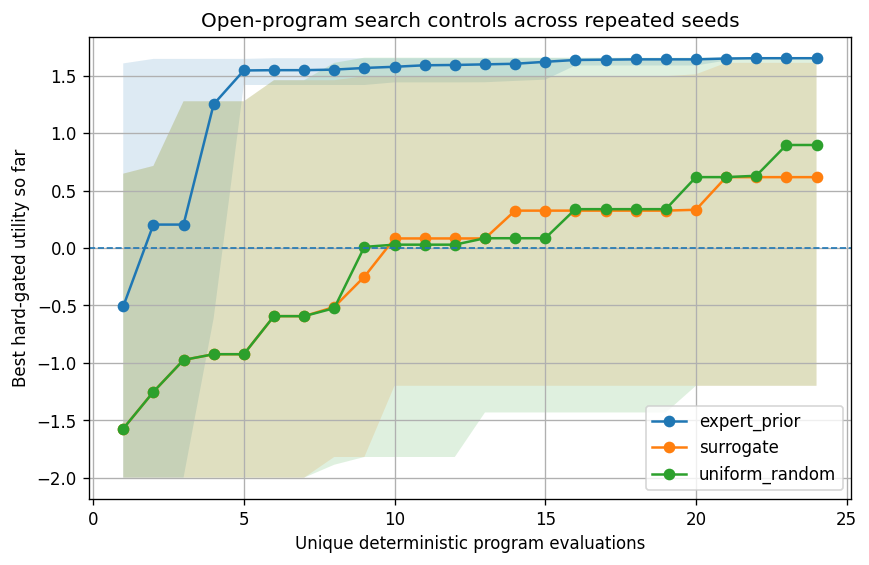

In [33]:
open_non_llm_records = []
for strategy in OPEN_SETTINGS.non_llm_strategies:
    for seed in OPEN_NON_LLM_SEEDS:
        print(f"open control: {strategy}, seed={seed}")
        open_non_llm_records.extend(
            run_search_arm(strategy, seed, OPEN_NON_LLM_BUDGET, OPEN_VERIFIER_CONFIG)
        )

open_non_llm_results = pd.DataFrame(open_non_llm_records)
open_non_llm_summary = summarize_search_arms(open_non_llm_results)
open_non_llm_auc_tests = paired_auc_comparison(open_non_llm_results, reference="uniform_random")
open_non_llm_curves = best_so_far_curve(open_non_llm_results)

open_non_llm_results.to_csv(OUTPUT_DIR / "tables" / "open_non_llm_results.csv", index=False)
open_non_llm_summary.to_csv(OUTPUT_DIR / "tables" / "open_non_llm_summary.csv", index=False)
open_non_llm_auc_tests.to_csv(OUTPUT_DIR / "tables" / "open_non_llm_auc_tests.csv", index=False)
open_non_llm_curves.to_csv(OUTPUT_DIR / "tables" / "open_non_llm_best_so_far.csv", index=False)

display(open_non_llm_summary)
display(open_non_llm_auc_tests)

fig, ax = plt.subplots(figsize=(8.2, 5.0))
for strategy, group in open_non_llm_curves.groupby("strategy"):
    group = group.sort_values("budget_step")
    ax.plot(group["budget_step"], group["mean_best"], marker="o", label=strategy)
    ax.fill_between(group["budget_step"], group["q025"], group["q975"], alpha=0.15)
ax.axhline(0.0, linewidth=1.0, linestyle="--")
ax.set_xlabel("Unique deterministic program evaluations")
ax.set_ylabel("Best hard-gated utility so far")
ax.set_title("Open-program search controls across repeated seeds")
ax.legend()
fig.savefig(OUTPUT_DIR / "figures" / "open_search_best_so_far_controls.png", bbox_inches="tight")
plt.show()


## 22 · Nebius open-program panel and archive ablation

The live panel proposes the full program JSON. It never emits coefficients and never selects
from an enumerated candidate-ID list. Three matched conditions isolate verifier feedback:

- `no_archive`: no prior proposals or outcomes;
- `structure_only`: recent own-arm structures, without scores;
- `full_metrics`: recent own-arm structures and verifier outcomes.

Every condition receives the same feasibility contract, because those preconditions are
constraints of the equality system rather than outcomes of this arm's search. In the v7 run
ten of eighteen model programs requested a closure of order six, which is infeasible in this
class at any target order tested, so the ablation was measuring knowledge of one undisclosed
fact instead of the value of feedback.

A schema-valid program that fails the pre-flight screen is returned to the proposer with the
violated precondition and re-proposed. Repair turns consume tokens and wall time but never a
deterministic solver call, so the matched budget is unchanged.

Seeds are independent by construction: the model and role for each generation are drawn from a
generator keyed on the condition and the seed, and the seed enters the prompt as a declared
nonce so that two seeds cannot share a prompt hash. In the v8 run, modular model/role offsets
made seed 2 identical to seed 0 for every condition, the prompt cache replayed it exactly, and
the paired tests were computed over a duplicated observation. The comparison now fails closed
when any two seeds produce the same program sequence.


In [34]:
OPEN_PROGRAM_ROLES = {
    "architecture_proposer": (
        "Propose a genuinely different operator-construction program. Use norm class, support profile, "
        "left/right structure and objective design as mathematical choices, not cosmetic variations."
    ),
    "spectral_critic": (
        "Propose a program likely to retain a real non-positive spectrum, correct low Dirichlet modes, "
        "small Q-conditioning and a competitive spectral-radius constant."
    ),
    "accuracy_critic": (
        "Propose a program whose closure and objective should reduce manufactured-PDE error and preserve "
        "the declared boundary order; do not optimize only spectral radius."
    ),
    "adversarial_verifier": (
        "Probe a plausible boundary of feasibility while respecting the schema. State which verifier gate "
        "is most likely to fail and why the attempt is still informative."
    ),
}

OPEN_PROGRAM_SYSTEM = (
    "You are a structural proposer in a verifier-driven numerical-analysis experiment. "
    "You propose one operator-construction PROGRAM, never matrix coefficients and never a validity claim. "
    "The deterministic LP compiler, exact identities, SPD proof, spectral loading, physical-mode matching, "
    "manufactured PDE tests and exact rational reconstruction are authoritative. "
    "Use the feedback supplied in this call only; do not assume unreported search outcomes."
)

OPEN_PROGRAM_FIXED_CONTEXT = {
    "goal": (
        "Find order-6 or order-8 staggered mimetic derivative/Laplacian constructions that preserve the "
        "extended Gauss identity and improve the accuracy--conditioning--bandwidth trade-off."
    ),
    "program_choices": {
        "norm_class": ["diagonal", "block_psd"],
        "closure_symmetry": ["reflection", "asymmetric"],
        "supports": "one integer width per boundary row, independently on left and right",
        "objectives": ["max_margin", "min_l1", "min_next_moment", "hybrid"],
        "extra_constraints": [
            "extra_moment_degree", "minimum norm margin", "coefficient bound",
            "scaled spectral-radius cap", "Q-condition cap", "mixed-PDE error cap",
            "minimum observed-rate ratio",
        ],
    },
    "hard_rule": "A failed algebraic, SPD, spectral, physical-mode or PDE gate cannot be offset by a soft score.",
    "feasibility_contract": {
        "note": (
            "Necessary structural preconditions of the equality system. These are constraints, "
            "not outcome scores, and they are supplied identically in every archive condition "
            "so that the ablation isolates verifier feedback rather than knowledge of this list. "
            "A program violating any of them is rejected before the linear program and returns "
            "no mathematical information."
        ),
        "boundary_order_ceiling": (
            "left_boundary_order and right_boundary_order must not exceed target_order // 2 + 1. "
            "Closures of order target_order have never been feasible in this operator class: the "
            "extended Gauss identity and a positive norm cannot both hold at that closure order."
        ),
        "rows": "left_rows >= left_boundary_order + 1, and likewise on the right.",
        "supports": "every support width >= max(target_order + 1, boundary_order + 2).",
        "norm_bandwidth": "norm_class 'block_psd' requires norm_bandwidth >= 1.",
        "complexity": "rows x max support plus (rows+1)^2 per side must stay under the declared cap.",
    },
}


def _program_fields_from_record(row: dict[str, Any]) -> dict[str, Any]:
    fields = {}
    for name in OpenProgramSpec.__dataclass_fields__:
        value = row.get(name)
        if isinstance(value, np.ndarray): value = value.tolist()
        if isinstance(value, tuple): value = list(value)
        fields[name] = value
    return fields


def open_archive_for_prompt(condition: str, records: list[dict[str, Any]]) -> dict[str, Any]:
    recent = records[-OPEN_SETTINGS.history_items:]
    if condition == "no_archive":
        return {"condition": condition, "own_arm_history": []}
    if condition == "structure_only":
        return {
            "condition": condition,
            "own_arm_history": [
                {"program_id": r.get("program_id"), "program": _program_fields_from_record(r)}
                for r in recent
            ],
        }
    if condition in ("cold", "diagnostic_only"):
        # No archive of any kind; 'diagnostic_only' differs solely by the refinement
        # note, which is attached outside this function.
        return {"condition": condition, "own_arm_history": []}
    if condition in ("archive_only", "full_feedback"):
        condition = "full_metrics"
    if condition == "illumination":
        archive = illumination_archive(pd.DataFrame(records)) if records else pd.DataFrame()
        filled = set(archive["cell"]) if not archive.empty else set()
        unfilled = ['|'.join(str(x) for x in cell) for cell in ILLUMINATION_CELLS
                    if '|'.join(str(x) for x in cell) not in filled]
        return {
            "condition": condition,
            "own_arm_history": [
                {
                    "program_id": r.get("program_id"), "program": _program_fields_from_record(r),
                    "hard_pass": bool(r.get("hard_pass_all", False)), "utility": r.get("utility"),
                    "error": r.get("error"),
                }
                for r in recent
            ],
            "descriptor_cell_format": "target_order|norm_class|closure_symmetry|boundary_order|max_support_bucket",
            "cells_already_filled_by_this_arm": sorted(filled),
            "unfilled_cells_worth_attempting": unfilled[:24],
            "objective_note": (
                "This arm is scored on how many distinct descriptor cells it fills with a "
                "verified operator, not only on the best utility found. Prefer an unfilled "
                "cell over a further refinement of a filled one."
            ),
        }
    if condition == "full_metrics":
        return {
            "condition": condition,
            "own_arm_history": [
                {
                    "program_id": r.get("program_id"), "program": _program_fields_from_record(r),
                    "hard_pass": bool(r.get("hard_pass_all", False)),
                    "utility": r.get("utility"), "error": r.get("error"),
                    "scaled_spectral_radius": r.get("scaled_spectral_radius"),
                    "q_condition_bound": r.get("q_condition_bound"),
                    "mixed_pde_error": r.get("mixed_pde_error"),
                    "mixed_pde_rate": r.get("mixed_pde_rate"),
                }
                for r in recent
            ],
        }
    raise ValueError(condition)


# The 2x2: archive metrics and diagnostic refinement vary independently, so the v10
# 'full metrics' effect can be attributed to one, the other, or their interaction.
ARCHIVE_BEARING_CONDITIONS = ("full_metrics", "illumination", "archive_only", "full_feedback")
FEEDBACK_CONDITIONS = ("full_metrics", "illumination", "diagnostic_only", "full_feedback")


def effective_condition(condition: str, solver_step: int, budget: int) -> str:
    """Resolve a staged condition to the condition in force at this solver step."""
    if condition != "two_stage": return condition
    boundary = max(1, int(round(OPEN_SETTINGS.two_stage_explore_fraction * budget)))
    return "cold" if solver_step < boundary else "full_feedback"


def model_role_schedule(seed: int, budget: int) -> list[tuple[str, str]]:
    """Deterministic (model, role) pairing per solver step, identical across conditions."""
    stream = np.random.default_rng(np.random.SeedSequence([int(seed), 0x5CED]))
    roles = list(OPEN_PROGRAM_ROLES)
    return [(str(stream.choice(RESOLVED_MODEL_IDS)), str(stream.choice(roles)))
            for _ in range(max(1, budget))]


def certificate_refinement_note(record: dict[str, Any]) -> dict[str, Any] | None:
    """The solver's own diagnostic for the previous program, for one refinement.

    Every failed compile already produces an infeasibility status and an equality
    residual; through v9 these were logged and discarded. Handing them back lets the
    proposer revise the same construction instead of guessing again, which is what
    the refinement half of exploration actually requires. It costs no extra solver
    call: it only anchors the next proposal.
    """
    if not record or bool(record.get("hard_pass_all")): return None
    group_violation = record.get("group_minimum_violation")
    if isinstance(group_violation, str):
        try: group_violation = json.loads(group_violation)
        except Exception: group_violation = None
    return {
        "previous_program": {k: record.get(k) for k in OpenProgramSpec.__dataclass_fields__},
        "compiled": bool(record.get("compile_success")),
        "solver_diagnostic": record.get("error"),
        "equality_residual": record.get("egd_residual"),
        "moment_residual": record.get("moment_residual"),
        # Which constraint group had to give way, and whether a strictly positive norm
        # is the obstruction rather than the algebra. Without this the proposer was
        # iterating against an undifferentiated 'infeasible'.
        "binding_constraint_group": record.get("binding_group"),
        "group_minimum_violation": group_violation,
        "feasible_without_positive_norm_margin": record.get("feasible_without_positive_norm_margin"),
        "infeasibility_interpretation": record.get("infeasibility_interpretation"),
        "failed_gates": [name for name, ok in (
            ("algebraic", record.get("structural_pass")), ("spectral", record.get("spectral_pass")),
            ("pde", record.get("pde_pass")), ("rate", record.get("rate_pass"))) if ok is False],
        "instruction": (
            "Revise this same construction against the diagnostic above rather than "
            "starting from an unrelated program, unless the diagnostic shows the "
            "direction itself is exhausted."
        ),
    }


def preflight_repair_messages(proposal: dict[str, Any], violations: list[str]) -> list[dict[str, str]]:
    """Return the violated preconditions to the proposer, verbatim.

    The repair turn is billed and logged as a generation. It never consumes a
    deterministic solver call, so the matched budget across arms is unchanged.
    """
    return [
        {"role": "assistant", "content": json.dumps(proposal, sort_keys=True, default=str)[:2000]},
        {"role": "user", "content":
            "That program was rejected by the deterministic pre-flight screen before the "
            "linear program, so it produced no mathematical information:\n"
            + "\n".join(f"- {v}" for v in violations)
            + "\nReturn one corrected program. Keep the scientific intent and change only "
              "what the screen rejected. Lowering the boundary order is a legitimate "
              "correction; the closure order is bounded by target_order // 2 + 1."},
    ]


def open_program_prompt(condition: str, role: str, records: list[dict[str, Any]],
                        seen: set[str], seed: int = 0,
                        refinement: dict[str, Any] | None = None) -> str:
    payload = {
        # The seed is a declared nonce. It carries no scientific content, but it
        # makes the prompt hash seed-dependent: in v8 seeds 0 and 2 selected the
        # same model and role, hit the prompt cache and replayed byte-identical
        # arms, so the paired seed-level tests were run over a duplicated pair.
        "experiment_seed": int(seed),
        "role_instruction": OPEN_PROGRAM_ROLES[role],
        "fixed_context": OPEN_PROGRAM_FIXED_CONTEXT,
        "archive_ablation": open_archive_for_prompt(condition, records),
        "already_used_program_ids": sorted(seen)[-30:],
        # Only feedback-bearing conditions receive the solver diagnostic; supplying
        # it in no_archive or structure_only would leak outcomes into the arms whose
        # definition is that they have none.
        "refinement_target": refinement if condition in FEEDBACK_CONDITIONS else None,
        "staged_condition_note": (
            "This arm explores without verifier metrics for the first half of its budget "
            "and receives the full archive and solver diagnostics for the second half."
            if condition == "two_stage" else None),
        "instruction": (
            "Return one program. Continuous objective/constraint values should be deliberate. "
            "Do not reproduce an already-used program ID by making a vacuous textual change."
        ),
    }
    text = json.dumps(payload, sort_keys=True, default=str)
    if len(text) > OPEN_SETTINGS.prompt_character_cap:
        raise RuntimeError(f"Open-program prompt exceeded cap: {len(text)} characters")
    return text


def finalize_open_arm_records(records: list[dict[str, Any]], budget: int) -> list[dict[str, Any]]:
    if not records: return records
    best = -np.inf; curve = []
    for row in records:
        best = max(best, float(row["utility"])); curve.append(best)
    auc = float(trapezoid_auc(curve, dx=1) / max(1, budget - 1)) if budget > 1 else float(curve[0])
    for row, best_value in zip(records, curve):
        row["best_so_far"] = best_value; row["seed_auc"] = auc
    return records


def run_open_nebius_arm(condition: str, seed: int, budget: int):
    if not (OPEN_SETTINGS.run_live_llm and NEBIUS_LIVE and NEBIUS_CLIENT and RESOLVED_MODEL_IDS):
        return [], [], {"condition": condition, "seed": seed, "completed": False, "reason": "live Nebius unavailable or disabled"}
    records: list[dict[str, Any]] = []
    calls: list[dict[str, Any]] = []
    rejections: list[dict[str, Any]] = []
    seen: set[str] = set()
    roles = list(OPEN_PROGRAM_ROLES)
    max_generations = budget * OPEN_SETTINGS.llm_max_generation_multiplier
    attempt = 0
    # Model and role are drawn from a seeded generator rather than from modular
    # offsets of the attempt index: with two usable models the old rule made
    # seed 2 identical to seed 0 for every condition.
    # One schedule per seed, shared by every archive condition, indexed by the solver
    # step rather than by the generation attempt: retries, duplicates, repairs and
    # pre-flight rejections must not advance it. Python's hash() is process-randomised
    # unless PYTHONHASHSEED is set, so the stream is derived from SeedSequence instead
    # and is reproducible across kernels.
    schedule = model_role_schedule(seed, budget)
    selection_rng = np.random.default_rng(
        np.random.SeedSequence([int(seed), 0x5EED, 11]).generate_state(2)
    )
    consecutive_refinements = 0
    while len(records) < budget and attempt < max_generations:
        model_id, role = schedule[len(records) % len(schedule)]
        # Eligibility requires that there is something to refine: the previous program
        # exists and failed. Including generations that follow a success would put
        # never-refinable rows in the control group and bias the contrast.
        stage = effective_condition(condition, len(records), budget)
        refinement_eligible = bool(
            OPEN_SETTINGS.llm_certificate_refinement and records
            and stage in FEEDBACK_CONDITIONS
            and not bool(records[-1].get("hard_pass_all"))
            and consecutive_refinements < OPEN_SETTINGS.llm_max_consecutive_refinements
        )
        refinement_assigned = bool(
            refinement_eligible
            and selection_rng.random() < OPEN_SETTINGS.llm_refinement_probability
        )
        refinement = certificate_refinement_note(records[-1]) if refinement_assigned else None
        consecutive_refinements = consecutive_refinements + 1 if refinement else 0
        prompt = open_program_prompt(stage, role, records, seen, seed=seed,
                                     refinement=refinement)
        repair_messages: list[dict[str, str]] = []
        spec = None
        # One generation plus up to llm_repair_attempts pre-flight repairs. Only a
        # program that reaches the linear program consumes the solver budget.
        for repair_index in range(OPEN_SETTINGS.llm_repair_attempts + 1):
            call = NEBIUS_CLIENT.complete_json(
                model_id=model_id, system=OPEN_PROGRAM_SYSTEM, prompt=prompt,
                schema=OPEN_PROGRAM_JSON_SCHEMA, schema_name="mimetic_open_program_v12",
                role=role, sample_index=attempt,
                temperature=CONFIG.nebius_temperature, max_tokens=max(1200, CONFIG.nebius_max_tokens),
                extra_messages=repair_messages or None,
            )
            call["prediction_fields_requested"] = True
            if not call.get("ok"):
                # One retry without the commitment fields, so a model that cannot emit
                # them still contributes programs. Calibration is then scored on the
                # generations that did supply a prediction, not on an assumption.
                fallback = NEBIUS_CLIENT.complete_json(
                    model_id=model_id, system=OPEN_PROGRAM_SYSTEM, prompt=prompt,
                    schema=PREDICTION_FREE_SCHEMA, schema_name="mimetic_open_program_v12_no_prediction",
                    role=role, sample_index=attempt,
                    temperature=CONFIG.nebius_temperature, max_tokens=max(1200, CONFIG.nebius_max_tokens),
                    extra_messages=repair_messages or None,
                )
                fallback.update({"archive_condition": condition, "seed": seed,
                                 "attempt": attempt + 1, "repair_index": repair_index,
                                 "prediction_fields_requested": False,
                                 "prediction_schema_fallback": True})
                calls.append(call)
                attempt += 1
                call = fallback
            call.update({"archive_condition": condition, "seed": seed,
                         "attempt": attempt + 1, "repair_index": repair_index})
            attempt += 1
            if not call.get("ok"):
                calls.append(call); spec = None; break
            try:
                spec = proposal_to_spec(call["parsed"], design_meshes=OPEN_VERIFIER_CONFIG.design_meshes)
                call["normalized_program_id"] = spec.program_id
            except Exception as exc:
                call["ok"] = False; call["error"] = f"program validation: {type(exc).__name__}: {exc}"
                calls.append(call); spec = None; break
            if spec.program_id in seen:
                call["duplicate_program"] = True
                calls.append(call); spec = None; break
            violations = preflight_program(spec, OPEN_VERIFIER_CONFIG)
            call["preflight_violations"] = violations
            calls.append(call)
            if not violations:
                break
            row = preflight_record(spec, violations, OPEN_VERIFIER_CONFIG)
            row.update({"strategy": f"llm_{condition}", "archive_condition": condition,
                        "seed": seed, "model_id": model_id, "role": role,
                        "repair_index": repair_index})
            rejections.append(row); seen.add(spec.program_id); spec = None
            repair_messages = preflight_repair_messages(call["parsed"], violations)
        if spec is None:
            continue
        seen.add(spec.program_id)
        summary, _, _ = compile_evaluate(spec, OPEN_VERIFIER_CONFIG)
        usage = call.get("usage") or {}
        summary.update({
            "strategy": f"llm_{condition}", "archive_condition": condition,
            "seed": seed, "budget_step": len(records) + 1,
            "model_id": model_id, "role": role,
            "hypothesis": str(call["parsed"].get("hypothesis", "")),
            "rationale": str(call["parsed"].get("rationale", "")),
            "input_tokens": int(usage.get("input_tokens", 0) or 0),
            "output_tokens": int(usage.get("output_tokens", 0) or 0),
            "api_latency_s": float(call.get("latency_s", 0.0) or 0.0),
            "repair_index": int(call.get("repair_index", 0) or 0),
            "refined_previous": bool(refinement),
            "refinement_eligible": bool(refinement_eligible),
            "stage_in_force": stage,
            **{field: (call.get("parsed") or {}).get(field) for field in PREDICTION_FIELDS},
            "evidence_eligible": True,
        })
        records.append(summary)
    finalize_open_arm_records(records, budget)
    for row in records:
        row["preflight_rejections_in_arm"] = len(rejections)
    OPEN_PREFLIGHT_REJECTIONS.extend(rejections)
    return records, calls, {
        "condition": condition, "seed": seed, "completed": len(records) == budget,
        "solver_calls": len(records), "generations": attempt, "budget": budget,
        "preflight_rejections": len(rejections),
        "repair_generations": sum(1 for c in calls if c.get("repair_index", 0)),
    }

open_llm_records: list[dict[str, Any]] = []
open_llm_calls: list[dict[str, Any]] = []
open_llm_status_rows: list[dict[str, Any]] = []
for condition in OPEN_SETTINGS.llm_archive_conditions:
    for seed in OPEN_LLM_SEEDS:
        records, calls, status = run_open_nebius_arm(condition, seed, OPEN_LLM_BUDGET)
        open_llm_records.extend(records); open_llm_calls.extend(calls); open_llm_status_rows.append(status)

open_llm_results = pd.DataFrame(open_llm_records)
open_llm_status = pd.DataFrame(open_llm_status_rows)
open_llm_results.to_csv(OUTPUT_DIR / "tables" / "open_llm_archive_ablation_results.csv", index=False)
open_llm_status.to_csv(OUTPUT_DIR / "tables" / "open_llm_archive_ablation_status.csv", index=False)
with (OUTPUT_DIR / "open_program" / "llm" / "open_program_calls.jsonl").open("w", encoding="utf-8") as stream:
    for row in open_llm_calls:
        stream.write(json.dumps(row, sort_keys=True, default=str) + "\n")

# Guard against the v8 failure mode: two seeds that produce the same program
# sequence are one observation, not two, and must not enter a paired test.
schedule_mismatches = []
if not open_llm_results.empty and "model_id" in open_llm_results:
    keyed = {}
    for row in open_llm_results.to_dict("records"):
        key = (int(row.get("seed", -1)), int(row.get("budget_step", 0)))
        entry = (row.get("model_id"), row.get("role"))
        keyed.setdefault(key, {})[row.get("archive_condition")] = entry
    for key, per_condition in keyed.items():
        if len(set(per_condition.values())) > 1:
            schedule_mismatches.append({"seed": key[0], "solver_step": key[1],
                                        "assignments": {k: list(v) for k, v in per_condition.items()}})
if schedule_mismatches:
    print("WARNING: archive conditions did not share a model/role schedule at",
          len(schedule_mismatches), "solver steps; the archive comparison is not paired.")

duplicate_seed_pairs = []
if not open_llm_results.empty:
    for condition in OPEN_SETTINGS.llm_archive_conditions:
        sequences = {}
        subset = open_llm_results[open_llm_results["archive_condition"] == condition]
        for seed_value, group in subset.groupby("seed"):
            sequences[int(seed_value)] = tuple(group.sort_values("budget_step")["program_id"])
        seeds_sorted = sorted(sequences)
        for a_index, seed_a in enumerate(seeds_sorted):
            for seed_b in seeds_sorted[a_index + 1:]:
                if sequences[seed_a] and sequences[seed_a] == sequences[seed_b]:
                    duplicate_seed_pairs.append(
                        {"condition": condition, "seed_a": seed_a, "seed_b": seed_b})
if duplicate_seed_pairs:
    print("WARNING: identical program sequences across seeds; these are not independent "
          "observations and the paired seed-level tests are not valid for this run:")
    for pair in duplicate_seed_pairs: print("  ", pair)

open_llm_comparison_valid = bool(
    not open_llm_status.empty and open_llm_status["completed"].astype(bool).all()
    and len(open_llm_status) == len(OPEN_SETTINGS.llm_archive_conditions) * len(OPEN_LLM_SEEDS)
    and not duplicate_seed_pairs
    and not schedule_mismatches
)
json_dump(OUTPUT_DIR / "tables" / "open_llm_archive_ablation_validity.json", {
    "comparison_valid": open_llm_comparison_valid,
    "live_evidence": bool(NEBIUS_LIVE and OPEN_SETTINGS.run_live_llm),
    "conditions": list(OPEN_SETTINGS.llm_archive_conditions),
    "seeds": list(OPEN_LLM_SEEDS), "solver_budget_per_condition_seed": OPEN_LLM_BUDGET,
    "duplicate_seed_pairs": duplicate_seed_pairs,
    "schedule_mismatches": schedule_mismatches[:20],
    "paired_model_role_schedule": not schedule_mismatches,
    "reason_if_invalid": (
        None if open_llm_comparison_valid else
        "identical program sequences across seeds" if duplicate_seed_pairs else
        "one or more live arms were unavailable or failed to exhaust the unique-program budget"
    ),
})
def true_generation_costs(calls: list[dict[str, Any]], records: pd.DataFrame) -> pd.DataFrame:
    """Every generation billed, not only the ones that became solver records.

    Malformed outputs, repair turns, duplicates and pre-flight rejections all cost
    tokens and wall time. Summing only accepted rows understated v10's cost by roughly
    a third and mis-ranked the conditions on tokens per verified operator.
    """
    if not calls: return pd.DataFrame()
    frame = pd.DataFrame([{
        "archive_condition": c.get("archive_condition"), "model_id": c.get("model_id"),
        "ok": bool(c.get("ok")), "is_repair_turn": bool(c.get("is_repair_turn")),
        "duplicate": bool(c.get("duplicate_program")),
        "preflight_rejected": bool(c.get("preflight_violations")),
        "input_tokens": float((c.get("usage") or {}).get("input_tokens") or 0),
        "output_tokens": float((c.get("usage") or {}).get("output_tokens") or 0),
        "latency_s": float(c.get("latency_s") or 0.0),
    } for c in calls])
    grouped = frame.groupby("archive_condition").agg(
        generations=("ok", "size"), schema_valid=("ok", "sum"),
        repair_turns=("is_repair_turn", "sum"), duplicates=("duplicate", "sum"),
        preflight_rejected=("preflight_rejected", "sum"),
        input_tokens=("input_tokens", "sum"), output_tokens=("output_tokens", "sum"),
        api_seconds=("latency_s", "sum")).reset_index()
    passes = (records.assign(passed=records["hard_pass_all"].fillna(False).astype(bool))
              .groupby("archive_condition")["passed"].sum().reset_index(name="hard_passes")
              if not records.empty else pd.DataFrame(columns=["archive_condition", "hard_passes"]))
    merged = grouped.merge(passes, on="archive_condition", how="left")
    merged["total_tokens"] = merged["input_tokens"] + merged["output_tokens"]
    merged["passes_per_million_tokens"] = merged["hard_passes"] / (merged["total_tokens"] / 1e6)
    merged["passes_per_api_hour"] = merged["hard_passes"] / (merged["api_seconds"] / 3600.0)
    return merged


if NEBIUS_LIVE and len(RESOLVED_MODEL_IDS) < CONFIG.nebius_max_auto_models:
    print(f"NOTE: {len(RESOLVED_MODEL_IDS)} of {CONFIG.nebius_max_auto_models} requested models "
          f"resolved and passed the capability probe: {RESOLVED_MODEL_IDS}. "
          "Per-model comparisons are not comparable with runs that resolved a different roster.")

open_true_costs = true_generation_costs(open_llm_calls, open_llm_results)
if not open_true_costs.empty:
    open_true_costs.to_csv(OUTPUT_DIR / "tables" / "open_llm_true_costs.csv", index=False)
    display(open_true_costs)

open_preflight_frame = pd.DataFrame(OPEN_PREFLIGHT_REJECTIONS)
if not open_preflight_frame.empty:
    open_preflight_frame.to_csv(OUTPUT_DIR / "tables" / "open_preflight_rejections.csv", index=False)

display(open_llm_status)
if not open_llm_results.empty:
    display(summarize_search_arms(open_llm_results))
    # Per-model report. The panel mixes models within an arm, so arm-level rows cannot
    # answer which model proposes compilable programs; this table can.
    per_model_rows = []
    for model_id in sorted(set(open_llm_results["model_id"].dropna().astype(str))):
        model_records = open_llm_results[open_llm_results["model_id"] == model_id]
        model_calls = [c for c in open_llm_calls if c.get("model_id") == model_id]
        model_rejects = (open_preflight_frame[open_preflight_frame["model_id"] == model_id]
                         if not open_preflight_frame.empty and "model_id" in open_preflight_frame
                         else pd.DataFrame())
        per_model_rows.append({
            "model_id": model_id,
            "generations": len(model_calls),
            "schema_valid": sum(1 for c in model_calls if c.get("ok")),
            "prediction_schema_fallbacks": sum(1 for c in model_calls if c.get("prediction_schema_fallback")),
            "predictions_supplied": int(model_records["predicted_hard_pass"].notna().sum())
            if "predicted_hard_pass" in model_records else 0,
            "repair_generations": sum(1 for c in model_calls if c.get("repair_index", 0)),
            "preflight_rejections": int(len(model_rejects)),
            "solver_calls": int(len(model_records)),
            "compiled": int(model_records["compile_success"].fillna(False).astype(bool).sum()),
            "hard_passes": int(model_records["hard_pass_all"].fillna(False).astype(bool).sum()),
            "best_utility": float(model_records["utility"].max()),
            "input_tokens": int(model_records["input_tokens"].fillna(0).sum()),
            "output_tokens": int(model_records["output_tokens"].fillna(0).sum()),
            "mean_latency_s": float(model_records["api_latency_s"].fillna(0).mean()),
        })
    open_llm_per_model = pd.DataFrame(per_model_rows)
    open_llm_per_model.to_csv(OUTPUT_DIR / "tables" / "open_llm_per_model_report.csv", index=False)
    display(open_llm_per_model)
    if not open_preflight_frame.empty:
        print("Pre-flight rejections by violated precondition:")
        display(open_preflight_frame["preflight_violations"].str.split(":").str[0].value_counts())
    unusable = {mid: cap for mid, cap in (NEBIUS_CLIENT.capabilities or {}).items()
                if not cap.get("usable")}
    if unusable:
        print("Models excluded by the capability probe (panel is smaller than the roster):")
        for model_id, capability in unusable.items():
            first = (capability.get("attempts") or [{}])[0]
            print(f"   {model_id}: {first.get('error', 'unknown')} "
                  f"[finish_reason={first.get('finish_reason')}]")
else:
    print("No live open-program LLM evidence in this run. The schema and deterministic compiler remain fully testable offline.")


NOTE: 3 of 4 requested models resolved and passed the capability probe: ['zai-org/GLM-5.2', 'MiniMaxAI/MiniMax-M3', 'nvidia/Cosmos3-Super-Reasoner']. Per-model comparisons are not comparable with runs that resolved a different roster.


,archive_condition,generations,schema_valid,repair_turns,duplicates,preflight_rejected,input_tokens,output_tokens,api_seconds,hard_passes,total_tokens,passes_per_million_tokens,passes_per_api_hour
0,archive_only,358,213,2,158,2,839677.0,146351.0,1589.888346,19,986028.0,19.269230,43.021889
1,cold,179,119,11,0,11,483354.0,424339.0,2540.549943,17,907693.0,18.728799,24.089273
2,diagnostic_only,306,8,0,0,0,26295.0,24096.0,312.191559,1,50391.0,19.844814,11.531382
3,full_feedback,342,83,3,50,3,322374.0,76587.0,865.159375,9,398961.0,22.558596,37.449747
4,two_stage,368,72,5,0,5,415983.0,381862.0,2129.896422,14,797845.0,17.547268,23.663123


,condition,seed,completed,solver_calls,generations,budget,preflight_rejections,repair_generations
0,cold,0,True,12,15,12,3,3
1,cold,1,True,12,12,12,0,0
2,cold,2,True,12,13,12,1,1
3,cold,3,True,12,13,12,0,0
4,cold,4,True,12,12,12,0,0
5,cold,5,True,12,15,12,2,2
6,cold,6,True,12,13,12,1,1
7,cold,7,True,12,16,12,4,4
8,cold,8,True,12,12,12,0,0
9,cold,9,False,0,60,12,0,0


,strategy,seed,solver_calls,hard_passes,distinct_feasible_families,final_best_utility,auc,tokens,api_latency_s,solver_time_s,utility_per_1k_tokens,utility_per_total_second,unique_program_rate,unique_family_rate,mean_pairwise_program_distance,categorical_entropy
0,llm_archive_only,0,12,7,7,1.293202,0.953219,59400,101.357378,2.294330,0.021771,0.012476,1.0,0.750000,0.395622,0.594899
1,llm_archive_only,1,8,0,0,-1.200000,-0.763636,48020,127.648064,1.285770,-0.024990,-0.009307,1.0,0.375000,0.508415,0.588711
2,llm_archive_only,2,8,6,6,1.637931,0.999711,26503,41.928380,1.094745,0.061802,0.038071,1.0,0.875000,0.447889,0.477217
3,llm_archive_only,4,5,2,2,1.190265,0.432824,14194,23.819863,1.029448,0.083857,0.047899,1.0,1.000000,0.420412,0.423220
4,llm_archive_only,5,5,0,0,-1.200000,-0.545455,25362,129.068969,1.019163,-0.047315,-0.009225,1.0,0.400000,0.351380,0.180482
5,llm_archive_only,6,12,4,4,1.654597,-0.546289,71126,134.983896,2.646071,0.023263,0.012022,1.0,0.583333,0.476418,0.891018
6,llm_archive_only,8,2,0,0,-2.000000,-0.181818,16912,46.353970,0.270421,-0.118259,-0.042896,1.0,0.000000,0.693889,0.000000
7,llm_archive_only,9,1,0,0,-2.000000,0.000000,3299,40.219690,0.248043,-0.606244,-0.049422,1.0,0.000000,0.000000,0.000000
8,llm_cold,0,12,2,2,1.456852,-0.466865,36405,94.902183,3.134765,0.040018,0.014860,1.0,0.416667,0.480365,0.908287
9,llm_cold,1,12,0,0,-1.200000,-1.200000,48872,185.353138,2.458548,-0.024554,-0.006389,1.0,0.166667,0.463881,0.999666


,model_id,generations,schema_valid,prediction_schema_fallbacks,predictions_supplied,repair_generations,preflight_rejections,solver_calls,compiled,hard_passes,best_utility,input_tokens,output_tokens,mean_latency_s
0,MiniMaxAI/MiniMax-M3,1870,216,828,107,5,5,109,57,28,1.654597,225909,56948,6.035761
1,nvidia/Cosmos3-Super-Reasoner,207,207,0,86,15,15,86,43,27,1.654509,209151,38607,6.675070
2,zai-org/GLM-5.2,425,72,121,62,1,1,71,17,5,1.623066,279392,273492,29.753412


Pre-flight rejections by violated precondition:


,count
preflight_violations,
left_boundary_order=6 exceeds the empirical feasibility ceiling 4 for target_order=6,79
left_boundary_order=5 exceeds the empirical feasibility ceiling 4 for target_order=6,73
left_boundary_order=6 exceeds the empirical feasibility ceiling 5 for target_order=8,56
left_boundary_order=8 exceeds the empirical feasibility ceiling 5 for target_order=8,49
norm_class=block_psd requires norm_bandwidth>=1,47
...,...
left_rows=3 is below left/right boundary_order+1=6; right_rows=5 is below left/right boundary_order+1=6,1
left_rows=4 is below left/right boundary_order+1=6; norm_class=block_psd requires norm_bandwidth>=1,1
right_rows=3 is below left/right boundary_order+1=5; norm_class=block_psd requires norm_bandwidth>=1,1


Models excluded by the capability probe (panel is smaller than the roster):
   Qwen/Qwen3.5-397B-A17B: ValueError: probe JSON was {'type': 'object', 'additionalProperties': False, 'required': ['ok'], 'properties': {'ok': {'type': 'boolean'}}} [finish_reason=length]


## 23 · Cold coefficient-recall control

This audit is intentionally isolated from the discovery prompt. Each live model is asked,
without an archive or coefficient hints, to reproduce the order-6 MOLE/Castillo–Grone left
boundary blocks. Coincidence with the embedded reference table is a **recall-risk indicator**,
not proof of memorization: a model could derive, approximate, or have encountered the table.


In [35]:
COLD_RECALL_SCHEMA = {
    "type": "object", "additionalProperties": False,
    "required": ["divergence_left_2x7", "gradient_left_3x7", "method_note"],
    "properties": {
        "divergence_left_2x7": {
            "type": "array", "minItems": 2, "maxItems": 2,
            "items": {"type": "array", "minItems": 7, "maxItems": 7, "items": {"type": "number"}},
        },
        "gradient_left_3x7": {
            "type": "array", "minItems": 3, "maxItems": 3,
            "items": {"type": "array", "minItems": 7, "maxItems": 7, "items": {"type": "number"}},
        },
        "method_note": {"type": "string", "minLength": 1, "maxLength": 300},
    },
}

cold_recall_rows = []
cold_recall_calls = []
D6_target = _mole_divergence_bar(6, 40)[1:3, :7]
G6_target = _mole_gradient_bar(6, 40)[:3, :7]
if OPEN_SETTINGS.run_cold_recall_audit and OPEN_SETTINGS.run_live_llm and NEBIUS_LIVE:
    prompt = (
        "Cold recall/derivation control. Without tools, archives, or explanatory prose, return the dimensionless "
        "left-boundary coefficient blocks used by the order-6 staggered MOLE/Castillo-Grone divergence "
        "(2 by 7) and gradient (3 by 7). Return decimal numbers in the supplied schema."
    )
    for model_id in RESOLVED_MODEL_IDS:
        call = NEBIUS_CLIENT.complete_json(
            model_id=model_id,
            system="This is an isolated coefficient-recall audit. Do not use results from other calls.",
            prompt=prompt, schema=COLD_RECALL_SCHEMA, schema_name="mole_order6_cold_recall",
            role="cold_recall", sample_index=0, temperature=0.0, max_tokens=1200,
        )
        cold_recall_calls.append(call)
        row = {"model_id": model_id, "ok": bool(call.get("ok"))}
        usage = call.get("usage") or {}
        row.update({"input_tokens": usage.get("input_tokens", 0), "output_tokens": usage.get("output_tokens", 0), "latency_s": call.get("latency_s", 0.0)})
        if call.get("ok"):
            try:
                D = np.asarray(call["parsed"]["divergence_left_2x7"], float)
                G = np.asarray(call["parsed"]["gradient_left_3x7"], float)
                dmax = float(np.max(np.abs(D - D6_target))); gmax = float(np.max(np.abs(G - G6_target)))
                row.update({
                    "D_max_abs_error": dmax, "G_max_abs_error": gmax,
                    "D_relative_frobenius_error": float(np.linalg.norm(D-D6_target)/np.linalg.norm(D6_target)),
                    "G_relative_frobenius_error": float(np.linalg.norm(G-G6_target)/np.linalg.norm(G6_target)),
                    "coincides_with_known_table_1e-8": bool(max(dmax, gmax) <= 1e-8),
                    "recall_risk_interpretation": "high" if max(dmax, gmax) <= 1e-8 else "not_detected",
                })
            except Exception as exc:
                row["ok"] = False; row["error"] = f"shape/value validation: {exc}"
        else:
            row["error"] = call.get("error")
        cold_recall_rows.append(row)

cold_recall_table = pd.DataFrame(cold_recall_rows)
cold_recall_table.to_csv(OUTPUT_DIR / "tables" / "open_cold_coefficient_recall.csv", index=False)
with (OUTPUT_DIR / "open_program" / "llm" / "cold_recall_calls.jsonl").open("w", encoding="utf-8") as stream:
    for row in cold_recall_calls: stream.write(json.dumps(row, sort_keys=True, default=str) + "\n")
if not cold_recall_table.empty: display(cold_recall_table)
else: print("Cold recall audit skipped: no eligible live Nebius panel in this run.")


,model_id,ok,input_tokens,output_tokens,latency_s,D_max_abs_error,G_max_abs_error,D_relative_frobenius_error,G_relative_frobenius_error,coincides_with_known_table_1e-8,recall_risk_interpretation,error
0,zai-org/GLM-5.2,True,1708,2120,20.929026,1.229167,5.414062,1.0,1.0,False,not_detected,NaN
1,MiniMaxAI/MiniMax-M3,False,0,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,HTTPStatusError: Server error '503 Service Una...
2,nvidia/Cosmos3-Super-Reasoner,True,292,240,3.437323,1.229167,5.414062,1.0,1.0,False,not_detected,NaN


## 24 · Partial novelty library and topology-aware matching

The notebook loads all same-topology coefficients that are actually available in the run:
MOLE/Castillo–Grone references and the exact diagonal candidates from Part II. It compares
operators after dimensionless scaling, sign, reflection, and an optimal scalar alignment.

Metadata placeholders for Strand/Mattsson–Nordström collocated SBP families and the
Corbino–Castillo extended-Gauss family are deliberately marked **not loaded**. Collocated
operators are not silently compared to staggered scalar/face matrices. Additional `.npz`
entries can be placed in `open_program/novelty_library_external`; a novelty claim remains
blocked while relevant same-topology entries are missing.


In [36]:
NOVELTY_MESH = 96

def base_to_general(op: MimeticOperator1D) -> GeneralOperator1D:
    return GeneralOperator1D(op.grid.cells, op.D, op.G, op.Q, op.P, dict(op.metadata))

loaded_novelty_entries: list[NoveltyEntry] = []
novelty_coverage = []
for order in ORDERS:
    op = build_mole_reference(order, NOVELTY_MESH)
    loaded_novelty_entries.append(NoveltyEntry(
        name=f"MOLE_Castillo_Grone_k{order}", topology="staggered_scalar_face", order=order,
        Dbar=op.grid.h * op.D, Gbar=op.grid.h * op.G,
        source="embedded MOLE translation",
    ))
    novelty_coverage.append({"name": f"MOLE_Castillo_Grone_k{order}", "topology": "staggered_scalar_face", "arrays_loaded": True})

for order, template in selected_templates.items():
    op = instantiate_shared_template(template, NOVELTY_MESH)
    loaded_novelty_entries.append(NoveltyEntry(
        name=f"v4_diagonal_candidate_k{order}", topology="staggered_scalar_face", order=int(order),
        Dbar=op.grid.h * op.D, Gbar=op.grid.h * op.G,
        source="current notebook exact diagonal candidate",
    ))
    novelty_coverage.append({"name": f"v4_diagonal_candidate_k{order}", "topology": "staggered_scalar_face", "arrays_loaded": True})

# Optional external entries: Dbar and Gbar are required; metadata_json may supply name/topology/order/source.
external_dir = OUTPUT_DIR / "open_program" / "novelty_library_external"
for path in sorted(external_dir.glob("*.npz")):
    try:
        data = np.load(path, allow_pickle=False)
        meta = json.loads(str(data["metadata_json"])) if "metadata_json" in data else {}
        entry = NoveltyEntry(
            name=str(meta.get("name", path.stem)), topology=str(meta.get("topology", "staggered_scalar_face")),
            order=int(meta["order"]), Dbar=np.asarray(data["Dbar"], float), Gbar=np.asarray(data["Gbar"], float),
            source=str(meta.get("source", path.name)),
        )
        loaded_novelty_entries.append(entry)
        novelty_coverage.append({"name": entry.name, "topology": entry.topology, "arrays_loaded": True, "external_path": path.name})
    except Exception as exc:
        novelty_coverage.append({"name": path.name, "arrays_loaded": False, "load_error": f"{type(exc).__name__}: {exc}"})

novelty_coverage.extend([
    {"name": "Strand_1994_diagonal_norm_SBP", "topology": "collocated", "arrays_loaded": False, "reason": "different topology; adapter/reference arrays required"},
    {"name": "Mattsson_Nordstrom_SBP_families", "topology": "collocated", "arrays_loaded": False, "reason": "different topology; adapter/reference arrays required"},
    {"name": "Corbino_Castillo_2020_extended_Gauss", "topology": "staggered_scalar_face", "arrays_loaded": False, "reason": "same-topology coefficient tables not bundled in the supplied materials"},
])

novelty_rows = []
for program_id, template in open_regression_templates.items():
    cert = open_regression_certificates.get(program_id, {})
    candidate_template = cert.get("reconstructed_template", template)
    op = instantiate_open_template(candidate_template, NOVELTY_MESH)
    for entry in loaded_novelty_entries:
        if entry.order != candidate_template.spec.target_order: continue
        result = canonical_operator_distance(op, entry, tol=1e-10)
        novelty_rows.append({"program_id": program_id, "reference_name": entry.name, "reference_source": entry.source, **result})

novelty_comparisons = pd.DataFrame(novelty_rows)
novelty_comparisons.to_csv(OUTPUT_DIR / "tables" / "open_novelty_comparisons_partial.csv", index=False)
json_dump(OUTPUT_DIR / "tables" / "open_novelty_library_coverage.json", {
    "coverage_complete": False,
    "entries": novelty_coverage,
    "claim_rule": "No novelty claim while a relevant same-topology family is not loaded.",
})
if not novelty_comparisons.empty: display(novelty_comparisons.sort_values(["program_id", "relative_distance"]))
print("Novelty status: partial-library non-match only; literature novelty remains unresolved.")


,program_id,reference_name,reference_source,comparable,distance,relative_distance,matched_transform,scale,equivalent
1,prog_k6_block_psd_reflection_hybrid_7380717ca753,v4_diagonal_candidate_k6,current notebook exact diagonal candidate,True,1.888571,0.578481,direct,0.962300,False
0,prog_k6_block_psd_reflection_hybrid_7380717ca753,MOLE_Castillo_Grone_k6,embedded MOLE translation,True,2.387450,0.731290,direct,0.880994,False
3,prog_k8_block_psd_asymmetric_hybrid_5499c4ce8cfa,v4_diagonal_candidate_k8,current notebook exact diagonal candidate,True,1.284798,0.305652,direct,1.024704,False
2,prog_k8_block_psd_asymmetric_hybrid_5499c4ce8cfa,MOLE_Castillo_Grone_k8,embedded MOLE translation,True,3.484130,0.828872,direct,0.722897,False


Novelty status: partial-library non-match only; literature novelty remains unresolved.


## 25 · Promote and exactly certify the best search-origin programs

Regression probes remain excluded. This stage considers only budgeted random, surrogate,
expert prior, and eligible live-LLM records. It deduplicates coefficient families, exactifies the
best survivors, reruns the verifier, and compares them to the v4 diagonal candidate and MOLE
reference on the same mesh.


In [37]:
all_open_search_frames = [open_non_llm_results]
if not open_llm_results.empty: all_open_search_frames.append(open_llm_results)
open_search_all = pd.concat(all_open_search_frames, ignore_index=True, sort=False)
open_search_all.to_csv(OUTPUT_DIR / "tables" / "open_search_all_budgeted_records.csv", index=False)

eligible = open_search_all[open_search_all["hard_pass_all"].astype(bool)].copy()
if not eligible.empty:
    eligible = eligible.sort_values("utility", ascending=False).drop_duplicates("canonical_hash")
    promotion_source = eligible.head(OPEN_SETTINGS.exactify_top_n)
else:
    promotion_source = pd.DataFrame()

open_promoted_rows = []
open_promoted_templates = {}
for _, row in promotion_source.iterrows():
    spec = program_from_record(row.to_dict())
    summary, _, template = compile_evaluate(spec, OPEN_VERIFIER_CONFIG)
    if template is None: continue
    cert = coupled_exactify_open_template(
        template, dyadic_powers=(28, 36, 44), config=OPEN_VERIFIER_CONFIG,
        displacement_tolerance=1e-8,
    )
    disk_cert = {k: v for k, v in cert.items() if k not in ("reconstructed_template",)}
    json_dump(OUTPUT_DIR / "open_program" / "certificates" / f"search_{spec.program_id}.json", disk_cert)
    promoted = cert.get("reconstructed_template", template)
    open_promoted_templates[spec.program_id] = promoted
    final_summary, _ = evaluate_open_template(promoted, OPEN_VERIFIER_CONFIG, cheap=False)
    final_summary.update({
        "source_strategy": row.get("strategy"), "source_seed": row.get("seed"),
        "exact_certificate_pass": bool(cert.get("certificate_pass")),
        "exact_dyadic_power": cert.get("dyadic_power"),
        "exact_maximum_displacement": cert.get("maximum_displacement"),
    })
    open_promoted_rows.append(final_summary)
    op = instantiate_open_template(promoted, 200)
    np.savez_compressed(
        OUTPUT_DIR / "open_program" / "operators" / f"search_{spec.program_id}_m200.npz",
        D=op.D, G=op.G, Q=op.Q, P=op.P, cells=op.cells,
        metadata_json=json.dumps(op.metadata, sort_keys=True, default=str),
    )

open_promoted = pd.DataFrame(open_promoted_rows)
open_promoted.to_csv(OUTPUT_DIR / "tables" / "open_promoted_exact_candidates.csv", index=False)
if not open_promoted.empty: display(open_promoted)
else: print("No budgeted search-origin candidate passed every gate in this pilot; regression probes remain available only as compiler tests.")

# Same-mesh comparison of the regression leads, exact v4 diagonal candidates, and MOLE.
def same_mesh_metrics_general(op: GeneralOperator1D, label: str, order: int) -> dict[str, Any]:
    ev, qres, qcond, _ = q_similarity_general(op)
    rho = float(np.max(np.abs(ev))) * op.h**2
    low, _ = manufactured(op, "low_frequency"); mixed, _ = manufactured(op, "mixed_frequency")
    return {"label": label, "order": order, "cells": op.cells, "scaled_spectral_radius": rho,
            "q_condition_bound": qcond, "q_similarity_residual": qres,
            "low_frequency_pde_error": low, "mixed_frequency_pde_error": mixed}

same_mesh_rows = []
comparison_mesh = 160
for order in (6, 8):
    ref = base_to_general(build_mole_reference(order, comparison_mesh))
    same_mesh_rows.append(same_mesh_metrics_general(ref, "MOLE_reference", order))
    if order in selected_templates:
        diag = base_to_general(instantiate_shared_template(selected_templates[order], comparison_mesh))
        same_mesh_rows.append(same_mesh_metrics_general(diag, "v4_diagonal_candidate", order))
    for program_id, template in open_regression_templates.items():
        if template.spec.target_order == order:
            cert = open_regression_certificates.get(program_id, {})
            exact_template = cert.get("reconstructed_template", template)
            same_mesh_rows.append(same_mesh_metrics_general(
                instantiate_open_template(exact_template, comparison_mesh),
                f"open_block_regression:{program_id}", order,
            ))
open_same_mesh_comparison = pd.DataFrame(same_mesh_rows)
open_same_mesh_comparison.to_csv(OUTPUT_DIR / "tables" / "open_same_mesh_comparison.csv", index=False)
display(open_same_mesh_comparison)


,target_order,norm_class,closure_symmetry,left_boundary_order,right_boundary_order,left_rows,right_rows,left_support_profile,right_support_profile,norm_bandwidth,...,max_first_modes_rel_error,extra_low_modes,nonreal,low_pde_error,mixed_pde_error,source_strategy,source_seed,exact_certificate_pass,exact_dyadic_power,exact_maximum_displacement
0,6,block_psd,reflection,4,4,5,5,"(12, 8, 8, 12, 10)","(12, 8, 8, 12, 10)",4,...,2.440334e-09,0,0,8.290240e-12,5.702445e-09,uniform_random,4,True,36,2.233719e-10
1,6,diagonal,asymmetric,3,3,6,6,"(12, 12, 11, 11, 11, 11)","(12, 12, 11, 11, 11, 11)",0,...,5.963348e-08,0,0,1.791712e-10,3.042189e-07,llm_archive_only,6,True,36,7.931004e-10


,label,order,cells,scaled_spectral_radius,q_condition_bound,q_similarity_residual,low_frequency_pde_error,mixed_frequency_pde_error
0,MOLE_reference,6,160,6.165968,1.897312,4.814900e-01,8.409208e-13,1.296572e-09
1,v4_diagonal_candidate,6,160,8.266454,2.057394,2.251966e-16,3.424734e-09,5.587842e-06
2,open_block_regression:prog_k6_block_psd_reflec...,6,160,6.165974,1.699044,1.409330e-16,1.226075e-10,2.212951e-07
3,MOLE_reference,8,160,6.617173,inf,inf,1.295915e-12,1.344489e-11
4,v4_diagonal_candidate,8,160,6.617068,2.059491,1.893329e-16,1.461741e-10,1.958601e-07
5,open_block_regression:prog_k8_block_psd_asymme...,8,160,6.617517,2.028803,1.941466e-16,3.267649e-11,3.386012e-08


## 27 · Unified cost, diversity and statistical report

The primary endpoint is hard passes per solver call, resampled over whole arms, because an arm's
calls are not independent and because a single arm that never compiles floors the trajectory
statistics. Best-so-far AUC is retained as a secondary endpoint, now computed at a budget matched
across strategies: through v9 the LLM arms were integrated over twelve calls and the controls over
twenty-four, and compared pairwise. Time to first pass is reported directly rather than left
implicit inside the AUC.

The illumination view scores the same records on how much of the descriptor space each arm filled
with verified operators, which is the quantity a discovery claim rests on. Mechanism calibration
compares each proposal's committed prediction against what the verifier measured, separating a
proposer that knows why a construction works from one that samples a productive region.


Matched-budget AUC uses 24 solver calls per arm.


,strategy,arms,solver_calls,hard_passes,hit_rate,ci_low,ci_high,delta_vs_reference,permutation_p,holm_p
0,expert_prior,10,240,80,0.333333,0.333333,0.333333,0.283333,0.001000,0.001999
1,uniform_random,10,240,12,0.050000,0.029167,0.070833,NaN,NaN,NaN
2,surrogate,10,240,9,0.037500,0.020833,0.054167,-0.012500,0.556722,0.556722


,strategy,n_seeds,mean_auc,std_auc,median_auc,median_paired_delta_vs_random,p_vs_random,holm_p_vs_random
0,expert_prior,10,1.422851,0.212654,1.491336,1.340261,0.001953,0.003906
1,surrogate,10,-0.089045,0.989085,-0.012540,-0.015407,0.578125,0.578125
2,uniform_random,10,-0.072705,1.049845,0.041993,NaN,NaN,NaN


,strategy,arms,arms_with_a_pass,median_first_pass,mean_first_pass
0,expert_prior,10,10,2.0,2.500000
1,surrogate,10,7,9.0,9.142857
2,uniform_random,10,8,9.0,10.875000


,coverage,qd_score,cells_filled
strategy,,,
expert_prior,0.036,6.323,4.0
surrogate,0.008,1.244,0.9
uniform_random,0.011,1.663,1.2


Pass rate under the proposer's own caps minus the fixed external standard:


,strategy,self_declared_minus_external
0,expert_prior,0.666667
1,surrogate,0.044133
2,uniform_random,0.055263


,strategy,seed,solver_calls,hard_passes,distinct_feasible_families,final_best_utility,auc,tokens,api_latency_s,solver_time_s,utility_per_1k_tokens,utility_per_total_second,unique_program_rate,unique_family_rate,mean_pairwise_program_distance,categorical_entropy
0,expert_prior,0,24,8,8,1.651764,1.465344,0,0.0,5.692076,NaN,0.290187,1.0,0.500000,0.487314,1.146241
1,expert_prior,1,24,8,8,1.651764,1.601971,0,0.0,4.639900,NaN,0.355991,1.0,0.500000,0.487314,1.146241
2,expert_prior,2,24,8,8,1.651764,1.117898,0,0.0,5.717531,NaN,0.288895,1.0,0.500000,0.487314,1.146241
3,expert_prior,3,24,8,8,1.651764,1.649382,0,0.0,4.639926,NaN,0.355989,1.0,0.500000,0.487314,1.146241
4,expert_prior,4,24,8,8,1.651764,1.603103,0,0.0,6.131428,NaN,0.269393,1.0,0.500000,0.487314,1.146241
5,expert_prior,5,24,8,8,1.651764,1.214827,0,0.0,5.656279,NaN,0.292023,1.0,0.500000,0.487314,1.146241
6,expert_prior,6,24,8,8,1.651764,1.203887,0,0.0,4.818886,NaN,0.342769,1.0,0.500000,0.487314,1.146241
7,expert_prior,7,24,8,8,1.651764,1.646609,0,0.0,5.414479,NaN,0.305064,1.0,0.500000,0.487314,1.146241
8,expert_prior,8,24,8,8,1.651764,1.517329,0,0.0,6.504780,NaN,0.253931,1.0,0.500000,0.487314,1.146241
9,expert_prior,9,24,8,8,1.651764,1.208164,0,0.0,6.788085,NaN,0.243333,1.0,0.500000,0.487314,1.146241


,strategy,n_seeds,mean_auc,std_auc,median_auc,median_paired_delta_vs_random,p_vs_random,holm_p_vs_random
0,expert_prior,10,1.422851,0.212654,1.491336,1.340261,0.001953,0.003906
1,surrogate,10,-0.089045,0.989085,-0.012540,-0.015407,0.578125,0.578125
2,uniform_random,10,-0.072705,1.049845,0.041993,NaN,NaN,NaN


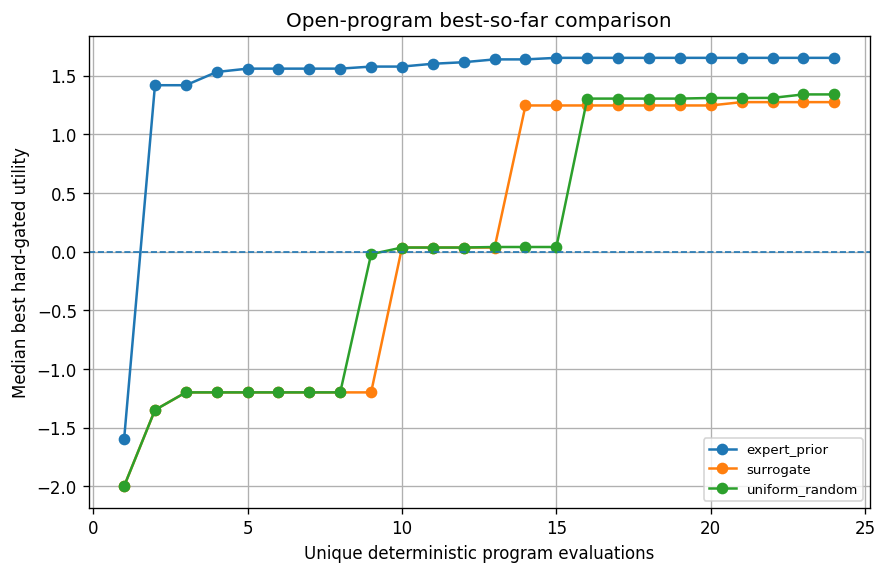

PosixPath('mimetic_operator_discovery_results_v12/tables/open_program_status.json')

In [38]:
open_statistics_frame = open_non_llm_results.copy()
if open_llm_comparison_valid and not open_llm_results.empty:
    open_statistics_frame = pd.concat([open_statistics_frame, open_llm_results], ignore_index=True, sort=False)

open_arm_summary = summarize_search_arms(open_statistics_frame)
open_auc_tests = paired_auc_comparison(open_statistics_frame, reference="uniform_random")

# Primary endpoint: hard passes per solver call, bootstrapped over whole arms.
# AUC stays as a secondary trajectory statistic, now at a matched budget.
open_hit_rates = hit_rate_comparison(open_statistics_frame, reference="uniform_random")
open_matched = truncate_to_common_budget(open_statistics_frame)
open_matched_auc_tests = paired_auc_comparison(open_matched, reference="uniform_random")
open_first_pass = time_to_first_pass(open_statistics_frame)
open_illumination = illumination_scores(open_statistics_frame)
open_elites = illumination_archive(open_statistics_frame)
open_calibration = score_mechanism_calibration(open_statistics_frame)


def refinement_effect(frame: pd.DataFrame) -> pd.DataFrame:
    """Within-arm contrast between randomly assigned refined and fresh proposals.

    Restricted to generations that were eligible for refinement, so the two groups
    differ only by the coin flip. The v10 table compared refined proposals against all
    other proposals, including ones made when nothing had failed yet.
    """
    if "refinement_eligible" not in frame: return pd.DataFrame()
    eligible = frame[frame["refinement_eligible"].fillna(False).astype(bool)]
    if eligible.empty: return pd.DataFrame()
    rows = []
    for (strategy, refined), group in eligible.groupby(["strategy", eligible["refined_previous"].fillna(False).astype(bool)]):
        rows.append({
            "strategy": strategy, "refined": bool(refined), "n": len(group),
            "compile_rate": float(group["compile_success"].fillna(False).mean()),
            "hard_pass_rate": float(group["hard_pass_all"].fillna(False).mean()),
            "mean_utility": float(group["utility"].mean()),
        })
    return pd.DataFrame(rows).sort_values(["strategy", "refined"])


def archive_refinement_factors(frame: pd.DataFrame) -> pd.DataFrame:
    """Marginal effects of the two feedback factors and their interaction."""
    design = {name: (name in ARCHIVE_BEARING_CONDITIONS, name in FEEDBACK_CONDITIONS)
              for name, _ in OPEN_SETTINGS.archive_refinement_design}
    design.setdefault("two_stage", (None, None))
    rows = []
    for name, (archive, diagnostic) in design.items():
        subset = frame[frame["strategy"] == f"llm_{name}"]
        if subset.empty: continue
        rows.append({"condition": name, "archive_metrics": archive, "diagnostic_refinement": diagnostic,
                     "solver_calls": len(subset),
                     "hard_pass_rate": float(subset["hard_pass_all"].fillna(False).mean()),
                     "self_declared_pass_rate": float(subset.get("hard_pass_self_declared",
                                                                 pd.Series(dtype=float)).fillna(False).mean())
                     if "hard_pass_self_declared" in subset else np.nan,
                     "mean_utility": float(subset["utility"].mean())})
    return pd.DataFrame(rows)


open_factor_table = archive_refinement_factors(open_statistics_frame)
if not open_factor_table.empty:
    open_factor_table.to_csv(OUTPUT_DIR / "tables" / "open_archive_refinement_factors.csv", index=False)

# The staged arm is summarised by the stage that was actually in force, so its two
# halves are not averaged into a single uninterpretable row.
if "stage_in_force" in open_statistics_frame:
    staged = open_statistics_frame[open_statistics_frame["strategy"] == "llm_two_stage"]
    if not staged.empty:
        stage_table = staged.groupby("stage_in_force").agg(
            solver_calls=("program_id", "size"),
            hard_pass_rate=("hard_pass_all", lambda s: float(s.fillna(False).mean())),
            best_utility=("utility", "max")).reset_index()
        stage_table.to_csv(OUTPUT_DIR / "tables" / "open_two_stage_by_phase.csv", index=False)
        print("Two-stage arm, by the stage in force:")
        display(stage_table)

open_refinement_effect = refinement_effect(open_statistics_frame)
if not open_refinement_effect.empty:
    open_refinement_effect.to_csv(OUTPUT_DIR / "tables" / "open_refinement_effect.csv", index=False)

# Why infeasible programs were infeasible, aggregated over every arm.
if "binding_group" in open_statistics_frame:
    open_infeasibility = (open_statistics_frame[open_statistics_frame["binding_group"].notna()]
                          .groupby(["strategy", "binding_group"]).size()
                          .reset_index(name="programs"))
    if not open_infeasibility.empty:
        open_infeasibility.to_csv(OUTPUT_DIR / "tables" / "open_infeasibility_groups.csv", index=False)

open_hit_rates.to_csv(OUTPUT_DIR / "tables" / "open_hit_rate_comparison.csv", index=False)
open_matched_auc_tests.to_csv(OUTPUT_DIR / "tables" / "open_matched_budget_auc_tests.csv", index=False)
open_first_pass.to_csv(OUTPUT_DIR / "tables" / "open_time_to_first_pass.csv", index=False)
open_illumination.to_csv(OUTPUT_DIR / "tables" / "open_illumination_scores.csv", index=False)
open_elites.to_csv(OUTPUT_DIR / "tables" / "open_illumination_elites.csv", index=False)
if not open_calibration.empty:
    open_calibration.to_csv(OUTPUT_DIR / "tables" / "open_mechanism_calibration.csv", index=False)

print(f"Matched-budget AUC uses {int(open_matched['matched_budget'].iloc[0])} solver calls per arm.")
display(open_hit_rates)
display(open_matched_auc_tests)
display(open_first_pass)
display(open_illumination.groupby("strategy")[["coverage", "qd_score", "cells_filled"]].mean().round(3))
if not open_calibration.empty: display(open_calibration)
if not open_factor_table.empty:
    print("Archive metrics x diagnostic refinement, marginal cells:")
    display(open_factor_table)
if not open_refinement_effect.empty:
    print("Randomised refinement contrast, restricted to refinement-eligible generations:")
    display(open_refinement_effect)
if "hard_pass_self_declared" in open_statistics_frame:
    external = open_statistics_frame.groupby("strategy")["hard_pass_all"].mean()
    declared = open_statistics_frame.groupby("strategy")["hard_pass_self_declared"].mean()
    gap = (declared - external).rename("self_declared_minus_external").reset_index()
    gap.to_csv(OUTPUT_DIR / "tables" / "open_gate_standard_gap.csv", index=False)
    print("Pass rate under the proposer's own caps minus the fixed external standard:")
    display(gap)
open_best_curves = best_so_far_curve(open_statistics_frame)
open_arm_summary.to_csv(OUTPUT_DIR / "tables" / "open_all_arm_summary.csv", index=False)
open_auc_tests.to_csv(OUTPUT_DIR / "tables" / "open_all_auc_tests.csv", index=False)
open_best_curves.to_csv(OUTPUT_DIR / "tables" / "open_all_best_so_far.csv", index=False)

display(open_arm_summary)
display(open_auc_tests)

fig, ax = plt.subplots(figsize=(8.4, 5.1))
for strategy, group in open_best_curves.groupby("strategy"):
    group = group.sort_values("budget_step")
    ax.plot(group["budget_step"], group["median_best"], marker="o", label=strategy)
ax.axhline(0.0, linewidth=1.0, linestyle="--")
ax.set_xlabel("Unique deterministic program evaluations")
ax.set_ylabel("Median best hard-gated utility")
ax.set_title("Open-program best-so-far comparison")
ax.legend(fontsize=8)
fig.savefig(OUTPUT_DIR / "figures" / "open_search_best_so_far_all_valid_arms.png", bbox_inches="tight")
plt.show()

open_program_status = {
    "proposal_space_exhaustive": False,
    "continuous_program_fields": ["l1_weight", "moment_weight", "margin_weight", "min_norm_margin", "coefficient_bound", "spectral_radius_cap", "q_condition_cap", "mixed_pde_error_cap", "minimum_rate_ratio"],
    "implemented_norm_classes": ["diagonal", "block_psd"],
    "implemented_closure_symmetries": ["reflection", "asymmetric"],
    "row_dependent_supports": True,
    "pde_accuracy_inside_loop": True,
    "random_control": "uniform_random",
    "surrogate_control": "ExtraTrees mean-plus-uncertainty",
    "repeated_seeds": list(OPEN_NON_LLM_SEEDS),
    "live_llm_evidence": bool(NEBIUS_LIVE and OPEN_SETTINGS.run_live_llm),
    "llm_archive_ablation_valid": open_llm_comparison_valid,
    "primary_endpoint": "hard passes per solver call, bootstrapped over arms",
    "secondary_endpoint": "best-so-far AUC at matched budget",
    "illumination_cells_total": len(ILLUMINATION_CELLS),
    "mechanism_calibration_scored": bool(not open_calibration.empty),
    "novelty_library_complete": False,
    "graded_grid_programs_implemented": False,
    "graded_grid_reason": "requires a separate exact mesh-family and coordinate-dependent moment construction",
}
json_dump(OUTPUT_DIR / "tables" / "open_program_status.json", open_program_status)


## 26b · Cross-order transfer of verified constructions

A construction that works at one target order because the proposer understood the mechanism
should survive being re-posed at the next order. One that works because it matched a pattern in
the archive should not. Every order-6 elite is re-instantiated at order 8 with the same norm
class, closure symmetry, objective and relative structure, supports widened by the order
difference, and sent through the identical compiler and gates. No model call is involved, so
this is a free deterministic test of the mechanisms the search actually found.


In [39]:
def transfer_variants(spec, new_order: int):
    """Several faithful re-posings of the same construction at a new order.

    A single mapping conflates "the mechanism does not generalise" with "this one
    arithmetic rule for widening supports was wrong". The ladder keeps norm class,
    closure symmetry, objective and all continuous fields fixed, and varies only the
    structural quantities that must change with the order.
    """
    s = spec.normalized(); shift = new_order - s.target_order
    variants = []
    for boundary_delta in (0, 1):
        for support_delta in (shift, shift + 2, shift + 4):
            for row_delta in (shift // 2, shift // 2 + 1):
                fields = {name: getattr(s, name) for name in OpenProgramSpec.__dataclass_fields__}
                fields["target_order"] = new_order
                ceiling = new_order // 2 + 1
                fields["left_boundary_order"] = max(2, min(ceiling, s.left_boundary_order + boundary_delta))
                fields["right_boundary_order"] = max(2, min(ceiling, s.right_boundary_order + boundary_delta))
                fields["left_rows"] = max(fields["left_boundary_order"] + 1, s.left_rows + row_delta)
                fields["right_rows"] = max(fields["right_boundary_order"] + 1, s.right_rows + row_delta)
                for side in ("left", "right"):
                    profile = [min(24, max(new_order + 1, w + support_delta))
                               for w in getattr(s, f"{side}_support_profile")]
                    rows = fields[f"{side}_rows"]
                    while len(profile) < rows: profile.append(profile[-1])
                    fields[f"{side}_support_profile"] = tuple(profile[:rows])
                try:
                    variants.append(OpenProgramSpec(**fields))
                except Exception:
                    continue
    unique = {}
    for variant in variants:
        unique.setdefault(variant.normalized().program_id, variant)
    return list(unique.values())


def attempt_transfer(spec, new_order: int, config, max_variants: int = 6) -> dict:
    """Best re-posing found within the variant ladder, with the reason if none works."""
    attempts = []
    for variant in transfer_variants(spec, new_order)[:max_variants]:
        violations = preflight_program(variant, config)
        if violations:
            attempts.append({"program_id": variant.normalized().program_id,
                             "compile_success": False, "hard_pass_all": False,
                             "error": f"preflight: {violations[0]}"})
            continue
        try:
            summary, _, _ = compile_evaluate(variant, config)
        except Exception as exc:
            attempts.append({"program_id": variant.normalized().program_id,
                             "compile_success": False, "hard_pass_all": False,
                             "error": f"{type(exc).__name__}: {exc}"})
            continue
        attempts.append(summary)
        if bool(summary.get("hard_pass_all")): break
    if not attempts:
        return {"transfer_attempts": 0, "hard_pass_all": False, "error": "no admissible variant"}
    best = max(attempts, key=lambda row: (bool(row.get("hard_pass_all")),
                                          bool(row.get("compile_success")),
                                          float(row.get("utility", -np.inf) or -np.inf)))
    return {
        "transfer_attempts": len(attempts),
        "transferred_program_id": best.get("program_id"),
        "compile_success": bool(best.get("compile_success")),
        "hard_pass_all": bool(best.get("hard_pass_all")),
        "binding_group": best.get("binding_group"),
        "scaled_spectral_radius": best.get("scaled_spectral_radius"),
        "q_condition_bound": best.get("q_condition_bound"),
        "mixed_pde_error": best.get("mixed_pde_error"),
        "mixed_pde_rate": best.get("mixed_pde_rate"),
        "utility": best.get("utility"), "error": best.get("error"),
    }


transfer_rows = []
source_elites = open_elites[open_elites["target_order"] == 6].dropna(subset=["elite_program_id"])
for row in source_elites.to_dict("records"):
    source = open_statistics_frame[open_statistics_frame["program_id"] == row["elite_program_id"]]
    if source.empty: continue
    outcome = attempt_transfer(program_from_record(source.iloc[0].to_dict()), 8, OPEN_VERIFIER_CONFIG)
    transfer_rows.append({"arm": "elite", "source_program_id": row["elite_program_id"],
                          "source_strategy": row["elite_strategy"],
                          "source_utility": row["elite_utility"], **outcome})

# Base-rate control: order-6 programs that merely passed the gates, not elites. Without
# this, a low elite transfer rate cannot be distinguished from a low transfer rate for
# any order-6 construction whatsoever.
control_pool = open_statistics_frame[
    (open_statistics_frame["target_order"] == 6)
    & (open_statistics_frame["hard_pass_all"].fillna(False).astype(bool))
    & (~open_statistics_frame["program_id"].isin(source_elites["elite_program_id"]))
]
if not control_pool.empty:
    control_rng = np.random.default_rng(CONFIG.random_seed)
    picks = control_rng.choice(len(control_pool), size=min(len(source_elites), len(control_pool)), replace=False)
    for position in picks:
        record = control_pool.iloc[int(position)].to_dict()
        outcome = attempt_transfer(program_from_record(record), 8, OPEN_VERIFIER_CONFIG)
        transfer_rows.append({"arm": "control", "source_program_id": record["program_id"],
                              "source_strategy": record["strategy"],
                              "source_utility": record.get("utility"), **outcome})

open_transfer_results = pd.DataFrame(transfer_rows)
if not open_transfer_results.empty:
    open_transfer_results.to_csv(OUTPUT_DIR / "tables" / "open_cross_order_transfer.csv", index=False)
    print("Order-6 constructions that still pass every gate when re-posed at order 8:")
    print(open_transfer_results.groupby(["arm"])["hard_pass_all"].agg(["sum", "size"]).to_string())
    print(open_transfer_results.groupby(["arm", "source_strategy"])["hard_pass_all"].agg(["sum", "size"]).to_string())
    if open_transfer_results["binding_group"].notna().any():
        print("\nWhere the failed transfers broke:")
        print(open_transfer_results["binding_group"].value_counts().to_string())
    display(open_transfer_results)
else:
    print("No order-6 construction was available to transfer.")


Order-6 constructions that still pass every gate when re-posed at order 8:
         sum  size
arm               
control    0     8
elite      5     8
                         sum  size
arm     source_strategy           
control expert_prior       0     8
elite   expert_prior       2     2
        surrogate          1     2
        uniform_random     2     4


,arm,source_program_id,source_strategy,source_utility,transfer_attempts,transferred_program_id,compile_success,hard_pass_all,binding_group,scaled_spectral_radius,q_condition_bound,mixed_pde_error,mixed_pde_rate,utility,error
0,elite,prog_k6_block_psd_asymmetric_hybrid_3c9bd27b3d99,expert_prior,1.651764,1,prog_k8_block_psd_asymmetric_hybrid_97c69b4c32fb,True,True,None,6.617156e+00,1.791360,1.752115e-07,5.673069,1.405757,None
1,elite,prog_k6_block_psd_reflection_hybrid_2627dda00f9e,expert_prior,1.625420,1,prog_k8_block_psd_reflection_hybrid_0862f6a44de2,True,True,None,6.617157e+00,1.736245,2.386867e-07,5.594103,1.408113,None
2,elite,prog_k6_block_psd_reflection_hybrid_3e44b8c5c92b,uniform_random,1.479418,1,prog_k8_block_psd_reflection_hybrid_4b232474319d,True,True,None,6.617278e+00,1.484075,4.072398e-07,4.214375,1.311937,None
3,elite,prog_k6_block_psd_reflection_hybrid_381152476671,surrogate,1.509247,1,prog_k8_block_psd_reflection_hybrid_c4d1e94ef60f,True,True,None,6.617373e+00,1.637168,6.200512e-07,4.461340,1.301522,None
4,elite,prog_k6_block_psd_reflection_max_margin_2ad411...,uniform_random,1.512849,6,prog_k8_block_psd_reflection_max_margin_12cea4...,True,False,None,6.617183e+00,2.406182,1.777883e-06,4.957211,-1.200000,None
5,elite,prog_k6_block_psd_reflection_min_next_moment_2...,uniform_random,1.707953,1,prog_k8_block_psd_reflection_min_next_moment_2...,True,True,None,8.149438e+00,1.770569,1.880245e-07,4.804149,1.377150,None
6,elite,prog_k6_block_psd_reflection_min_next_moment_f...,surrogate,1.640223,6,prog_k8_block_psd_reflection_min_next_moment_3...,True,False,None,8.782722e+07,3.252690,1.605793e-07,4.907936,-1.200000,None
7,elite,prog_k6_diagonal_reflection_hybrid_8be062b84c8e,uniform_random,1.289412,6,prog_k8_diagonal_reflection_hybrid_28c51ee33ee4,True,False,None,6.617127e+00,1.208662,1.159329e-06,4.010850,-1.200000,None
8,control,prog_k6_block_psd_asymmetric_min_next_moment_8...,expert_prior,1.542218,6,prog_k8_block_psd_asymmetric_min_next_moment_e...,True,False,None,3.772460e+05,3.451203,3.741147e-07,4.617021,-1.200000,None
9,control,prog_k6_block_psd_reflection_min_next_moment_f...,expert_prior,1.577327,6,prog_k8_block_psd_reflection_min_next_moment_d...,True,False,None,2.697802e+05,3.126104,1.613114e-07,5.494687,-1.200000,None


# Part V · Export, audit and machine-readable conclusion

## 27 · Save operators, tables, exact certificates and provenance

Every selected operator is stored as compressed arrays with metadata. The release bundle includes hashes of every artifact and a secret scan. No API key is written to disk.


In [40]:
# Save reference and final exact-certified candidate operators.
for order, op in reference_ops.items():
    op.save_npz(OUTPUT_DIR / "operators" / f"reference_mole_k{order}_m{CONFIG.reference_mesh}.npz")
for order, template in selected_templates.items():
    op = instantiate_shared_template(template, CONFIG.reference_mesh)
    op.save_npz(OUTPUT_DIR / "operators" / f"candidate_{template.spec.candidate_id}_m{CONFIG.reference_mesh}.npz")
    json_dump(OUTPUT_DIR / "operators" / f"template_{template.spec.candidate_id}.json", template.to_serializable())

coefficient_fingerprint_payload = {
    str(order): [str(x) for x in CENTRAL_DERIVATIVE_FRACTIONS[order]] for order in ORDERS
}
matched_solver_calls = int(len(matched_budget_results)) if isinstance(matched_budget_results, pd.DataFrame) else 0
provenance = {
    "notebook_schema_version": NOTEBOOK_SCHEMA_VERSION,
    "run_started_utc": RUN_STARTED_UTC,
    "run_finished_utc": datetime.now(timezone.utc).isoformat(),
    "configuration": asdict(CONFIG), "random_seed": CONFIG.random_seed,
    "python": sys.version, "platform": platform.platform(),
    "packages": {
        "numpy": np.__version__, "scipy": __import__("scipy").__version__,
        "pandas": pd.__version__, "matplotlib": __import__("matplotlib").__version__,
        "httpx": httpx.__version__, "sympy": sp.__version__,
        "scikit_learn": __import__("sklearn").__version__,
    },
    "reference_source": {
        "project": "MOLE: Mimetic Operators Library Enhanced",
        "translated_files": ["divNonPeriodic.m", "gradNonPeriodic.m", "weightsP.m", "weightsQ.m"],
        "upstream_license": "GPL-3.0-or-later", "accessed_date": "2026-08-17",
        "coefficient_table_sha256": hashlib.sha256(
            json.dumps(coefficient_fingerprint_payload, sort_keys=True).encode()
        ).hexdigest(),
    },
    "closed_grid_diagnostic_search": {
        "lp_method": CONFIG.lp_method,
        "specifications": int(len(SEARCH_SPECS)),
        "strictly_feasible_specifications": int(len(feasible_all)),
        "distinct_feasible_coefficient_families": int(len(feasible)),
        "selection_keys": SELECTION_KEYS,
        "exact_certificate_required": True,
        "final_candidate_ids": selected_candidates["candidate_id"].tolist(),
    },
    "open_program_search": {
        "settings": asdict(OPEN_SETTINGS),
        "verifier_config": asdict(OPEN_VERIFIER_CONFIG),
        "proposal_space_exhaustive": False,
        "non_llm_records": int(len(open_non_llm_results)),
        "non_llm_strategies": list(OPEN_SETTINGS.non_llm_strategies),
        "non_llm_seeds": list(OPEN_NON_LLM_SEEDS),
        "solver_budget_per_seed": OPEN_NON_LLM_BUDGET,
        "regression_program_ids": open_regression_table["program_id"].tolist(),
        "regression_exact_certificates": {k: bool(v.get("certificate_pass")) for k, v in open_regression_certificates.items()},
        "live_llm_archive_ablation_valid": open_llm_comparison_valid,
        "live_llm_records": int(len(open_llm_results)),
        "novelty_library_complete": False,
        "promoted_search_program_ids": open_promoted["program_id"].tolist() if not open_promoted.empty else [],
    },
    "nebius": {
        "enabled": CONFIG.run_nebius, "live": NEBIUS_LIVE,
        "base_url": CONFIG.nebius_base_url if CONFIG.run_nebius else None,
        "evidence_eligible": evidence_eligible,
        "model_resolution": MODEL_RESOLUTION,
        "resolved_model_ids": RESOLVED_MODEL_IDS,
        "model_capabilities": MODEL_CAPABILITIES,
        "initial_panel_solver_calls": int(initial_panel_solver_calls),
        "matched_budget_solver_calls": matched_solver_calls,
        "matched_budget_arms_executed": matched_budget_arms_executed,
        "matched_budget_arms_skipped": matched_budget_arms_skipped,
        "compact_archive_characters": len(archive_text),
        "prompt_archive_character_cap": CONFIG.nebius_prompt_archive_max_chars,
    },
}
json_dump(OUTPUT_DIR / "provenance.json", provenance)

mode_text = "LIVE Nebius calls were executed" if NEBIUS_LIVE else "No live Nebius calls were executed"
readme = f"""# Mimetic operator discovery v7 open-program run

Schema: {NOTEBOOK_SCHEMA_VERSION}
Started: {RUN_STARTED_UTC}

{mode_text}. Mock outputs, when present, are harness checks only and are not scientific evidence.

The closed-grid promoted candidates pass their v4 gates. The open-program section additionally
supports exact block-SPD norms, independent closures, repeated controls, and PDE-in-loop evaluation.
All promoted open candidates require exact coupled affine reconstruction, direct Sylvester SPD proof, conservation and moment identities, Q-symmetry, a real non-positive spectrum,
physical low-mode assignment with no extra low modes, scaled inverse conditioning, two
manufactured-PDE gates, and unseen-mesh transfer.

The bundled novelty library is explicitly partial. Novelty remains unassessed until all relevant
same-topology mimetic/SBP coefficient families are loaded and canonically compared.
"""
(OUTPUT_DIR / "README.md").write_text(readme, encoding="utf-8")

manifest_rows = []
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file() and path.name != "MANIFEST.sha256":
        manifest_rows.append((sha256_file(path), str(path.relative_to(OUTPUT_DIR))))
(OUTPUT_DIR / "MANIFEST.sha256").write_text(
    "\n".join(f"{digest}  {name}" for digest, name in manifest_rows) + "\n", encoding="utf-8"
)
secret_findings = scan_for_secrets(OUTPUT_DIR)
json_dump(OUTPUT_DIR / "secret_scan.json", {"findings": secret_findings, "passed": not secret_findings})
if secret_findings: raise RuntimeError(f"Secret scan failed: {secret_findings}")

zip_path = Path(shutil.make_archive(str(OUTPUT_DIR), "zip", root_dir=OUTPUT_DIR.parent, base_dir=OUTPUT_DIR.name))
print("Release bundle:", zip_path.resolve())
print("Secret scan: PASS")
print("Artifacts hashed:", len(manifest_rows))


Release bundle: /content/mimetic_operator_discovery_results_v12.zip
Secret scan: PASS
Artifacts hashed: 725


## 28 · Machine-generated result synopsis

This final cell reports only statements computed during the current run. It deliberately avoids a novelty claim and distinguishes offline mock orchestration from scientific model evidence.


In [41]:
nonreal_orders = reference_table.loc[
    reference_table["nonreal_eigenvalue_count"] > 0, "order"
].astype(int).tolist()
exact_promoted = selected_candidates["candidate_id"].tolist()

print("Reference orders with non-real Dirichlet modes:", nonreal_orders)
print("Final exact-certified v4 candidates:", exact_promoted)
print("Candidate physical-mode / PDE rates:")
display(candidate_rates)
print("Nebius evidence status:", "LIVE / eligible" if evidence_eligible else "OFFLINE MOCK / not scientific evidence")
print("Model resolution source:", MODEL_RESOLUTION.get("source"))
print("Resolved model IDs:", RESOLVED_MODEL_IDS or "none")
print(f"Panel proposal validity: {int(panel_summary['parsed'].sum())}/{len(panel_summary)}")
print("Initial-panel solver calls:", initial_panel_solver_calls)
print("Matched-budget arms executed:", matched_budget_arms_executed or "none")
status_path = OUTPUT_DIR / "tables" / "matched_budget_arm_status.json"
if status_path.exists():
    status = json.loads(status_path.read_text())
    print("Matched-budget comparison valid:", status["cross_arm_comparison_valid"])
print("Novelty status: unassessed; coefficient-family equivalence review is required.")
print("\nDownloadable run bundle inside this environment:")
display(FileLink(str(zip_path)))
print("\nOpen-program regression probes (excluded from AUC):")
display(open_regression_table[["program_id", "hard_pass_all", "utility", "scaled_spectral_radius", "q_condition_bound", "mixed_pde_error", "mixed_pde_rate"]])
print("Open non-LLM repeated-arm summary:")
display(open_non_llm_summary)
print("Open LLM archive-ablation comparison valid:", open_llm_comparison_valid)
print("Open proposal space exhaustive:", False)
print("Open novelty library complete:", False)


Reference orders with non-real Dirichlet modes: [6, 8]
Final exact-certified v4 candidates: ['k2_b1_r1_s3', 'k4_b2_r4_s7', 'k6_b3_r8_s11', 'k8_b4_r9_s13']
Candidate physical-mode / PDE rates:


,family,operator_id,candidate_id,order,boundary_order,spectral_pollution_any_mesh,matched_first5_eigenvalue_rate,eigenvalue_roundoff_or_plateau_limited,low_frequency_PDE_rate,low_frequency_roundoff_or_plateau_limited,low_frequency_dynamic_range,mixed_frequency_PDE_rate,mixed_frequency_roundoff_or_plateau_limited,mixed_frequency_dynamic_range
0,discovered_candidate,k2_b1_r1_s3,k2_b1_r1_s3,2,1,False,1.998342,False,2.000140,False,64.019436,2.006612,False,64.926132
1,discovered_candidate,k4_b2_r4_s7,k4_b2_r4_s7,4,2,False,5.199049,False,3.498479,False,1443.554968,4.111091,False,5056.650798
2,discovered_candidate,k6_b3_r8_s11,k6_b3_r8_s11,6,3,False,6.277043,False,5.491744,False,91026.758041,5.160326,False,43176.822571
3,discovered_candidate,k8_b4_r9_s13,k8_b4_r9_s13,8,4,False,7.462541,False,5.218081,False,48539.794596,5.500189,False,110140.641962


Nebius evidence status: OFFLINE MOCK / not scientific evidence
Model resolution source: declared_patterns
Resolved model IDs: ['zai-org/GLM-5.2', 'MiniMaxAI/MiniMax-M3', 'nvidia/Cosmos3-Super-Reasoner']
Panel proposal validity: 4/4
Initial-panel solver calls: 4
Matched-budget arms executed: ['deterministic_enumeration']
Matched-budget comparison valid: False
Novelty status: unassessed; coefficient-family equivalence review is required.

Downloadable run bundle inside this environment:


/content/mimetic_operator_discovery_results_v12.zip


Open-program regression probes (excluded from AUC):


,program_id,hard_pass_all,utility,scaled_spectral_radius,q_condition_bound,mixed_pde_error,mixed_pde_rate
0,prog_k6_block_psd_reflection_hybrid_7380717ca753,True,1.625420,6.165974,1.699044,2.212951e-07,5.352546
1,prog_k8_block_psd_asymmetric_hybrid_5499c4ce8cfa,True,1.525161,6.617517,2.028803,3.386011e-08,6.567770


Open non-LLM repeated-arm summary:


,strategy,seed,solver_calls,hard_passes,distinct_feasible_families,final_best_utility,auc,tokens,api_latency_s,solver_time_s,utility_per_1k_tokens,utility_per_total_second,unique_program_rate,unique_family_rate,mean_pairwise_program_distance,categorical_entropy
0,expert_prior,0,24,8,8,1.651764,1.465344,0,0.0,5.692076,NaN,0.290187,1.0,0.500000,0.487314,1.146241
1,expert_prior,1,24,8,8,1.651764,1.601971,0,0.0,4.639900,NaN,0.355991,1.0,0.500000,0.487314,1.146241
2,expert_prior,2,24,8,8,1.651764,1.117898,0,0.0,5.717531,NaN,0.288895,1.0,0.500000,0.487314,1.146241
3,expert_prior,3,24,8,8,1.651764,1.649382,0,0.0,4.639926,NaN,0.355989,1.0,0.500000,0.487314,1.146241
4,expert_prior,4,24,8,8,1.651764,1.603103,0,0.0,6.131428,NaN,0.269393,1.0,0.500000,0.487314,1.146241
5,expert_prior,5,24,8,8,1.651764,1.214827,0,0.0,5.656279,NaN,0.292023,1.0,0.500000,0.487314,1.146241
6,expert_prior,6,24,8,8,1.651764,1.203887,0,0.0,4.818886,NaN,0.342769,1.0,0.500000,0.487314,1.146241
7,expert_prior,7,24,8,8,1.651764,1.646609,0,0.0,5.414479,NaN,0.305064,1.0,0.500000,0.487314,1.146241
8,expert_prior,8,24,8,8,1.651764,1.517329,0,0.0,6.504780,NaN,0.253931,1.0,0.500000,0.487314,1.146241
9,expert_prior,9,24,8,8,1.651764,1.208164,0,0.0,6.788085,NaN,0.243333,1.0,0.500000,0.487314,1.146241


Open LLM archive-ablation comparison valid: False
Open proposal space exhaustive: False
Open novelty library complete: False


## 29 · Download the complete v7 run bundle

The archive is rebuilt after all cells finish, every artifact is re-hashed, and export is
refused if the secret scan finds a credential-like value. In Colab, the file is downloaded
automatically; in local Jupyter a clickable link is displayed.


In [42]:
# --- 20 · Rebuild and download the complete run bundle -----------------------
SAVE_TO_DRIVE = False
DRIVE_TARGET = "/content/drive/MyDrive/mimetic_operator_discovery"

def build_release_archive(output_dir: Path) -> Path:
    """Re-hash every artifact, re-scan for secrets and rebuild the zip."""
    manifest_rows = [
        (sha256_file(path), str(path.relative_to(output_dir)))
        for path in sorted(output_dir.rglob("*"))
        if path.is_file() and path.name != "MANIFEST.sha256"
    ]
    (output_dir / "MANIFEST.sha256").write_text(
        "\n".join(f"{digest}  {name}" for digest, name in manifest_rows) + "\n",
        encoding="utf-8",
    )
    findings = scan_for_secrets(output_dir)
    json_dump(output_dir / "secret_scan.json",
              {"findings": findings, "passed": not findings})
    if findings:
        raise RuntimeError(f"Export refused; secret scan failed: {findings}")
    stamp = RUN_STARTED_UTC.replace("-", "").replace(":", "")[:15]
    base = output_dir.parent / f"{output_dir.name}_{stamp}"
    return Path(shutil.make_archive(
        str(base), "zip", root_dir=output_dir.parent, base_dir=output_dir.name
    )), len(manifest_rows)

archive_path, artifact_count = build_release_archive(OUTPUT_DIR)
print(f"Bundle:        {archive_path.resolve()}")
print(f"Size:          {archive_path.stat().st_size / 1e6:.2f} MB")
print(f"Artifacts:     {artifact_count}")
print(f"Archive sha256:{sha256_file(archive_path)}")
print("Secret scan:   PASS")
for subdir in sorted(x for x in OUTPUT_DIR.iterdir() if x.is_dir()):
    print(f"  {subdir.name:<14} {sum(1 for f in subdir.rglob('*') if f.is_file())} files")

if SAVE_TO_DRIVE:
    try:
        from google.colab import drive
        if not Path("/content/drive/MyDrive").exists():
            drive.mount("/content/drive")
        target = Path(DRIVE_TARGET)
        target.mkdir(parents=True, exist_ok=True)
        shutil.copy2(archive_path, target / archive_path.name)
        print("Copied to Drive:", target / archive_path.name)
    except Exception as exc:
        print(f"Drive copy skipped: {type(exc).__name__}: {exc}")

try:
    from google.colab import files
    files.download(str(archive_path))
except Exception:
    # Local Jupyter / VS Code: click the link, or copy the path printed above.
    try:
        display(FileLink(str(archive_path.relative_to(Path.cwd()))))
    except Exception:
        print("Download the archive from the path above.")


Bundle:        /content/mimetic_operator_discovery_results_v12_20260819T094447.zip
Size:          3.31 MB
Artifacts:     726
Archive sha256:b84e6067aae941e68309e30bf66e60127ff048c7be18b4f4d87b6c25a32e0f69
Secret scan:   PASS
  certificates   4 files
  figures        8 files
  llm            631 files
  logs           0 files
  open_program   10 files
  operators      12 files
  tables         58 files


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>